# Treino de modelos de série temporal — incidentes P2/P3/P4, D+1 e D+7

Notebook de modelagem escrito a partir do que a **análise exploratória** já estabeleceu
(`data_exploration.ipynb` → `2_silver_data/s_fato_diario_prioridade.csv`). Não repete diagnóstico
de qualidade de dado, quebra estrutural ou dimensionamento — parte deles como dado.

## O que este notebook entrega

| Seção | Entrega |
|---|---|
| §2 | Carga das **9 séries** (3 grupos × 3 prioridades), a **série agregada** do D+7 e as janelas de treino/teste com embargo |
| §3 | Série + **ACF/PACF** + **decomposição STL**, com as observações ao fim da seção |
| §4 | Correlação das séries contra **todas as features disponíveis** nas camadas silver |
| §5 | **Método embedded (XGBoost)** — quais features além da autocorrelação explicam o volume |
| §5.6 | **Ablação das exógenas** nos dois horizontes — quanto sinal elas carregam |
| §5.7 | **Time responsável e descrição resumida** — os dois encodings testados, e por que ficaram fora |
| §6 | Desenho do treino: **dois modelos por série**, um por horizonte, e o que cada um recebe |
| §7 | Treino e previsão **D+1** (série diária) e **D+7** (série agregada), os dois **diretos** |
| §7.7 | A ablação das exógenas **no modelo que compete**, com o efeito mínimo detectável |
| §8 | Avaliação: métricas dos 4 modelos entre si e contra o **baseline ingênuo** |
| §9 | Escolha do modelo — o menos complexo com maior ganho |
| §10 | **Volumetria total**: soma(com+sem) contra um modelo treinado sem o grão de tipo |
| §11 | Tabelas gold |
| §12.4 | Exportação dos **modelos vencedores** para `models/` |

## Os 3 grupos de série

| Grupo | Grão | Janela | Dias | Teste |
|---|---|---|---|---|
| `com_intervencao` | prioridade × tipo | 2025-01-01 → 2025-12-31 | 365 | últimas **6 semanas** (42 d) |
| `sem_intervencao` | prioridade × tipo | 2025-09-01 → 2025-12-31 | 122 | últimas **4 semanas** (28 d) |
| `total` | prioridade (sem tipo) | 2025-09-01 → 2025-12-31 | 122 | últimas **4 semanas** (28 d) |

O grupo `total` existe para responder uma pergunta específica (§10): **separar por tipo valeu a
pena?** Se um único modelo sobre o total previr melhor do que a soma dos dois modelos por tipo, a
separação custou mais do que rendeu.

Os tamanhos de teste não são arbitrários: foram dimensionados em §2.1 pelo **efeito mínimo
detectável**, para que a pergunta central do notebook — as exógenas ajudam? — pudesse ser
respondida com um número em vez de com uma impressão.

## O desenho, em uma frase

Cada série é prevista por **dois modelos, um por horizonte, e os dois diretos**: o de D+1 prevê a
contagem do dia seguinte; o de D+7 prevê a soma móvel de 7 dias sete passos à frente, que por uma
identidade exata (§2.3) **é** o acumulado de D+1 a D+7.

A alternativa seria derivar o D+7 por recursão — aplicar o modelo de D+1 sete vezes,
realimentando a própria previsão. Ela cobra duas coisas que o desenho direto não paga: o **erro
composto** dos sete passos, e a proibição de usar qualquer feature exógena (para prever D+2 seria
preciso conhecer as features de D+1, que ainda não aconteceu). Sem recursão não há valor futuro
para inventar, e as exógenas medidas em D são admissíveis nos dois horizontes. §6.3 traz a
comparação com número.

Duas consequências do desenho, registradas no lugar certo: o **piso ingênuo do D+7** é a melhor de
duas regras plausíveis, escolhida dentro do treino (§7.1), e a avaliação carrega **embargo** e
correção por **sobreposição de janelas** (§2.4) — os dois obrigatórios quando o alvo é uma janela
de sete dias.

## Três respostas que costumam ficar enterradas

Estão aqui em cima de propósito.

**1. As features de `Grupo designado` e `Descrição Resumida` melhoram a previsão? Não.** Foram
codificadas de duas formas (share em janela e *frequency encoding*), em três janelas, e testadas
uma a uma em §5.7. Nenhuma configuração reduz o erro além do ruído entre sementes do próprio
XGBoost. Elas ficam no painel de §4, que descreve o que existe; fora do modelo.

**2. Normalizar contagem em proporção ajuda? Sim — mas só um tipo.** `inc_por_ic`,
`inc_por_descricao` e `inc_por_time` (`abertos` sobre cada contagem de diversidade) reduzem o MAE
em **4,8 %**, com `t = −5,4` em teste pareado de 30 sementes. É o único ganho sólido de todo o
estudo. O que as separa das que falharam: numerador e denominador **já estavam** no modelo — a
razão expõe uma relação que a árvore só aproximaria com muitos cortes, em vez de trazer colunas
novas e ruidosas. **Elas entram nos modelos de §7.**

**3. Algum dos 4 modelos supera o baseline ingênuo?** A resposta está em §8 e §9, medida contra o
piso de §7.1 — a mais dura das duas regras plausíveis, escolhida dentro do treino. Leia-a junto
com §7.7: o que decide não é só quem ganha, é se a diferença medida é maior que o efeito mínimo
detectável do teste.

---

# 1. Ambiente, imports e padrão visual

In [1]:
import warnings
warnings.filterwarnings("ignore")

import logging
from pathlib import Path

# torch PRIMEIRO, e não é estilo: o prophet carrega uma runtime TBB própria que,
# se vier antes, faz a inicialização das DLLs do torch falhar (WinError 1114) neste ambiente.
import torch
import torch.nn as nn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

import xgboost as xgb
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler

from prophet import Prophet

# Prophet e cmdstanpy logam uma linha por ajuste; com ~150 reajustes em §7.3 o notebook
# fica ilegível. Desabilitar o logger não basta — o cmdstanpy instala handler próprio.
for nome_logger in ("prophet", "cmdstanpy"):
    lg = logging.getLogger(nome_logger)
    lg.setLevel(logging.CRITICAL)
    lg.handlers.clear()
    lg.propagate = False
    lg.disabled = True

SEMENTE = 42
np.random.seed(SEMENTE)
torch.manual_seed(SEMENTE)

print(f"pandas {pd.__version__} | numpy {np.__version__} | xgboost {xgb.__version__} | torch {torch.__version__}")

pandas 2.2.2 | numpy 2.0.2 | xgboost 3.4.1 | torch 2.13.0+cpu


In [2]:
# Padrão visual do projeto (replicado localmente — este notebook não importa o de exploração).
PALETA = {
    "p2": "#C0392B", "p3": "#E67E22", "p4": "#F1C40F",
    "total": "#2C3E50", "neutro": "#95A5A6", "destaque": "#2980B9",
    "real": "#2C3E50", "treino": "#BDC3C7", "teste": "#E8DAEF",
}
COR_PRIORIDADE = {2: PALETA["p2"], 3: PALETA["p3"], 4: PALETA["p4"]}
COR_MODELO = {
    "SARIMAX": "#2980B9", "ETS": "#16A085", "Theta": "#27AE60",
    "Prophet": "#8E44AD", "LSTM": "#D35400", "Ingênuo": PALETA["neutro"],
    "ARIMA": "#2980B9", "SARIMA": "#16A085",     # nomes da safra 1, para gráficos antigos
}

sns.set_theme(
    style="whitegrid",
    rc={
        "figure.figsize": (12, 4.5), "figure.dpi": 110,
        "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
        "axes.labelsize": 10, "axes.edgecolor": "#DDDDDD",
        "grid.color": "#EEEEEE", "grid.linewidth": 0.8,
        "legend.frameon": False, "xtick.labelsize": 9, "ytick.labelsize": 9,
    },
)


def novo_grafico(titulo, subtitulo=None, figsize=(12, 4.5), nrows=1, ncols=1):
    """Cria figura/eixos já titulados. Retorna (fig, ax) ou (fig, array de ax)."""
    fig, axes = plt.subplots(nrows, ncols, figsize=figsize)
    ax0 = axes if (nrows == 1 and ncols == 1) else np.ravel(axes)[0]
    ax0.set_title(titulo, pad=14 if subtitulo else 8)
    if subtitulo:
        ax0.text(0, 1.02, subtitulo, transform=ax0.transAxes,
                 fontsize=9, color="#666666", va="bottom")
    return fig, axes


def finalizar(fig, fonte=None):
    """Aplica layout e uma nota de rodapé opcional."""
    if fonte:
        fig.text(0.005, -0.04, fonte, fontsize=8, color="#888888")
    fig.tight_layout()
    plt.show()


def tabela(df, titulo=None, casas=2):
    """Exibe um DataFrame como markdown — nunca to_string() cru."""
    from IPython.display import Markdown, display
    saida = df.copy()
    for c in saida.select_dtypes(include=[float]).columns:
        saida[c] = saida[c].round(casas)
    texto = (f"**{titulo}**\n\n" if titulo else "") + saida.to_markdown(index=False)
    display(Markdown(texto))

---

# 2. Carga e construção das séries

## 2.1 Configuração

As janelas são **literais**, vindas da decisão de negócio registrada na exploração — não são
recalculadas aqui:

- `com_intervencao` atravessa 2025 inteiro sem quebra estrutural → **365 dias**;
- `sem_intervencao` só existe depois da mudança de instrumentação de setembro → **122 dias**;
- `total` (soma dos dois tipos) fica restrito à mesma janela de 122 dias, senão a comparação
  de §10 seria contra um modelo com o triplo de histórico — e o ganho viria da janela, não do grão.

O **tamanho do teste**, esse sim, foi dimensionado com número. A pergunta que este notebook
precisa responder — "as features exógenas ajudam?" — é uma comparação **pareada entre dois
modelos quase idênticos**, e o efeito que se busca é o **+22,5 %** medido na ablação de §5.6.
Medindo em `g_previsoes` o desvio-padrão da diferença pareada de erro absoluto, e corrigindo pela
autocorrelação que a sobreposição de janelas introduz (§2.4), sai o efeito mínimo detectável a
80 % de poder para cada tamanho de teste:

| grupo | horizonte | 21 d | 28 d | 42 d | 56 d |
|---|---|---|---|---|---|
| `com_intervencao` | D+1 | 29,0 % | 25,1 % | **20,5 %** | 17,8 % |
| `com_intervencao` | D+7 | 24,6 % | 20,3 % | **15,9 %** | 13,5 % |
| `sem_intervencao` | D+1 | 23,3 % | **20,2 %** | 16,5 % | 14,3 % |
| `sem_intervencao` | D+7 | 15,2 % | **12,6 %** | 10,9 % | 8,3 % |
| `total` | D+1 | 17,7 % | **15,4 %** | 12,5 % | 10,9 % |
| `total` | D+7 | 10,5 % | **8,7 %** | 6,8 % | 5,8 % |

Em `com_intervencao`, 28 dias dariam um MDE de 25,1 % — **acima do efeito procurado**, ou seja o
teste não conseguiria enxergá-lo. Ali esticar não custa nada (365 dias de janela; o treino cai de
336 para 323 linhas), então o teste é de **42 dias**. Nos outros dois grupos só existem 122 dias
desde a quebra de 2025-09-03 e cada dia de teste sai do treino, então ficam **28 dias**.

O que nenhum corte resolve: em `sem_intervencao` e `total` o **D+1** não fica decisivo abaixo de
~15–20 %. Backtest de origem móvel não ajudaria — reusaria o mesmo dado finito. A saída é reportar
o MDE ao lado do resultado (§7.7), para que "não deu diferença" seja lido como "o teste não tinha
tamanho para ver", e não como "as exógenas não servem".

In [3]:
CAMINHO_SILVER = Path("../2_silver_data")
CAMINHO_GOLD = Path("../3_gold_data")

PRIORIDADES = [2, 3, 4]
GRUPOS = ["com_intervencao", "sem_intervencao", "total"]

JANELA = {
    "com_intervencao": {"inicio": "2025-01-01", "fim": "2025-12-31", "dias_teste": 42},
    "sem_intervencao": {"inicio": "2025-09-01", "fim": "2025-12-31", "dias_teste": 28},
    "total":           {"inicio": "2025-09-01", "fim": "2025-12-31", "dias_teste": 28},
}

# Os dois horizontes são dois problemas de aprendizado distintos, cada um com o seu modelo (§6).
# Cada um tem a sua própria série alvo: o D+1 prevê a contagem do dia, o D+7 prevê a soma móvel
# de 7 dias — e prever `soma7` sete passos à frente É o acumulado de D+1..D+7 (§2.3).
HORIZONTES = {"D+1": 1, "D+7": 7}
COLUNA_SERIE = {"D+1": "abertos", "D+7": "soma7"}
PASSO_MAXIMO = HORIZONTES["D+7"]     # tamanho da janela acumulada do horizonte longo
PERIODO_SAZONAL = 7                  # sazonalidade semanal

# Origens de treino descartadas na fronteira do corte (*purged split*). A origem D do D+7 tem
# alvo cobrindo D+1..D+7; se qualquer um desses dias já caiu no teste, treinar nessa origem é
# vazamento — e vazamento que não aparece como erro, aparece como resultado bom demais. Só são
# válidas as origens com D+passos dentro do treino, o que descarta as `passos - 1` últimas,
# comparado ao horizonte curto. Ver §2.4.
EMBARGO = {h: passos - 1 for h, passos in HORIZONTES.items()}

# Features de calendário — conhecidas para qualquer data futura, hoje e sempre.
FEATURES_CALENDARIO = [
    "dia_semana", "fim_de_semana", "dia_util", "feriado",
    "vespera_feriado", "pos_feriado", "dia_mes",
    "sen_semana", "cos_semana", "sen_ano", "cos_ano",
]

# Agregados da janela FUTURA D+1..D+7, também conhecidos em D para qualquer data (§2.2). São o
# que o modelo direto de D+7 recebe sobre o período que está prevendo.
FEATURES_JANELA = ["feriados_j7", "dias_uteis_j7", "vesperas_j7", "sen_ano_j7", "cos_ano_j7"]

# --- Features exógenas ----------------------------------------------------------------------
# Medidas em D, e admissíveis nos dois horizontes porque os dois são previstos de forma DIRETA
# (§6.2): um modelo direto lê o que existe em D e responde numa aplicação só, sem precisar do
# valor futuro de feature nenhuma. Num desenho recursivo nenhuma delas poderia entrar.
#
# O conjunto é PRÉ-REGISTRADO e pequeno de propósito, por duas razões:
#   1. seleção — escolher pelo ranking de permutação de §5.3 vazaria o teste para dentro do
#      modelo, porque aquele ranking é calculado NO TESTE. Estas 10 colunas saem da leitura por
#      FAMÍLIA de §5.5/§5.6, que é uma leitura de estrutura, não de linha do teste;
#   2. tamanho — o treino do `sem_intervencao` tem 87 amostras de D+7, e a sobreposição das
#      janelas faz elas valerem por ~14 semanas independentes (§2.4). 10 colunas já é generoso.
#
# As três razões `inc_por_*` são o único ganho com significância estatística do projeto
# (−4,8 % de MAE, t = −5,38, ajuda em 26 de 30 sementes); as demais representam as duas famílias
# de topo do ranking por permutação — fluxo/backlog (25–31 %) e contexto do dia.
FEATURES_EXOGENAS_MODELO = [
    "inc_por_ic", "inc_por_descricao", "inc_por_time",
    "fechados", "backlog", "saldo_aberto_fechado",
    "abertos_sem_classificacao",
    "ics_distintos", "times_distintos", "descricoes_distintas",
]

# Como cada razão é reconstruída no grupo `total` — numerador e denominador somados ANTES de
# dividir. Somar duas razões não significa nada: dois valores de 0,8 incidente por IC não somam
# 1,6. Mesma regra que `completar_total_texto` aplica às features de texto em §4.
COMPONENTES_RAZAO = {
    "inc_por_ic": ("abertos", "ics_distintos"),
    "inc_por_descricao": ("abertos", "descricoes_distintas"),
    "inc_por_time": ("abertos", "times_distintos"),
}

In [4]:
fato = pd.read_csv(CAMINHO_SILVER / "s_fato_diario_prioridade.csv", sep=";", parse_dates=["data"])
calendario = pd.read_csv(CAMINHO_SILVER / "s_dim_calendario.csv", sep=";", parse_dates=["data"])

print(f"fato       {fato.shape[0]:>6,} x {fato.shape[1]:>3}   "
      f"{fato.data.min():%Y-%m-%d} -> {fato.data.max():%Y-%m-%d}")
print(f"calendario {calendario.shape[0]:>6,} x {calendario.shape[1]:>3}")
print(f"grão do fato: {sorted(fato.prioridade.unique())} x {sorted(fato.tipo_tratamento.unique())}")

fato        6,570 x  56   2023-01-02 -> 2025-12-31
calendario  1,460 x  23
grão do fato: [np.int64(2), np.int64(3), np.int64(4)] x ['com_intervencao', 'sem_intervencao']


## 2.2 O grupo `total` e o calendário da janela futura

`total` não é uma terceira categoria no dado — é a **soma** de `com_intervencao` e
`sem_intervencao` por `data × prioridade`. Construir aqui, uma vez, evita reagregação espalhada
pelo notebook.

O calendário da janela responde à pergunta que o modelo direto de D+7 precisa fazer: *como são os
sete dias que vêm pela frente?* Diferente das exógenas, ele é conhecido para qualquer data — o
feriado de daqui a cinco dias já está na tabela. E ele revela um fato estrutural que muda o
desenho do horizonte longo: **sete dias consecutivos contêm sempre exatamente um de cada dia da
semana**. A composição semanal da janela é constante, logo a sazonalidade de período 7 — que
domina a série diária em §3.3 — **desaparece do alvo acumulado**. O que varia de uma janela para
outra é só o feriado e a posição no ano.

In [5]:
def agregar_total(fato):
    """Acrescenta o grupo `total`, somando os componentes ANTES de dividir as razões.

    Contagem soma. Razão não: `inc_por_ic` do total é (abertos_com + abertos_sem) dividido por
    (ics_com + ics_sem), reconstruído a partir dos componentes — ver `COMPONENTES_RAZAO`.

    Ressalva honesta sobre `ics_distintos` / `times_distintos` / `descricoes_distintas`: somar as
    contagens distintas dos dois tipos conta duas vezes um IC que apareceu nos dois no mesmo dia.
    A contagem exata exigiria voltar ao grão do incidente. A soma é um limite superior, e o que
    a feature carrega — "quantas frentes distintas estavam ativas hoje" — sobrevive à aproximação.
    """
    componentes = ["abertos"] + [c for c in FEATURES_EXOGENAS_MODELO if c not in COMPONENTES_RAZAO]
    total = fato.groupby(["data", "prioridade"], as_index=False)[componentes].sum()
    for razao, (num, den) in COMPONENTES_RAZAO.items():
        total[razao] = total[num] / total[den].where(total[den] > 0)
    total["tipo_tratamento"] = "total"

    colunas = ["data", "prioridade", "tipo_tratamento", "abertos"] + FEATURES_EXOGENAS_MODELO
    return pd.concat([fato[colunas], total[colunas]], ignore_index=True)


JANELAS_CALENDARIO = [("feriado", "feriados"), ("dia_util", "dias_uteis"),
                      ("vespera_feriado", "vesperas")]


def calendario_janela(cal, passos=PASSO_MAXIMO):
    """Agregados de calendário de duas janelas de 7 dias, ambos conhecidos em D.

    - sufixo `_7d` — janela **retroativa** D-6..D. É a exógena da série agregada: `soma7[D]` cobre
      exatamente esses dias, então é esse o calendário que lhe corresponde.
    - sufixo `_j7` — janela **futura** D+1..D+7. É o que o modelo direto de D+7 recebe sobre o
      período que ele está prevendo.

    As duas se encontram: `feriados_7d[D+7]` é, por construção, `feriados_j7[D]`. O assert abaixo
    usa essa identidade para provar que nenhuma das duas está deslocada por um dia — o tipo de
    erro que passa despercebido e contamina tudo a jusante.

    A soma é escrita como soma explícita de `shift` em vez de um `rolling` invertido: são sete
    termos, e a versão literal não tem como estar deslocada sem que se veja.

    `sen_ano` / `cos_ano` são tomados no CENTRO da janela futura (D+4), não em D — a janela
    inteira é o objeto previsto, e a posição dela no ano é a do meio.
    """
    c = cal.sort_values("data").reset_index(drop=True)
    janela = pd.DataFrame({"data": c.data})
    for coluna, nome in JANELAS_CALENDARIO:
        s = c[coluna].astype(float)
        janela[f"{nome}_7d"] = sum(s.shift(k) for k in range(0, passos))
        janela[f"{nome}_j7"] = sum(s.shift(-k) for k in range(1, passos + 1))
    meio = passos // 2 + 1
    janela["sen_ano_j7"] = c.sen_ano.shift(-meio)
    janela["cos_ano_j7"] = c.cos_ano.shift(-meio)
    return janela


CALENDARIO_J7 = calendario_janela(calendario)

for _, nome in JANELAS_CALENDARIO:
    a = CALENDARIO_J7[f"{nome}_7d"].shift(-PASSO_MAXIMO)
    b = CALENDARIO_J7[f"{nome}_j7"]
    dif = (a - b).abs().max()
    assert dif == 0, f"{nome}: a janela retroativa e a futura não se encontram (max {dif})"
print("OK — `x_7d` deslocada de 7 dias é idêntica a `x_j7`: nenhuma das duas janelas está torta.")

# A composição semanal da janela é constante — é o que autoriza desligar o bloco sazonal do
# SARIMA e a sazonalidade semanal do Prophet na série agregada (§7.2, §7.3). Constatação, não
# suposição: aqui está o número.
_dias_uteis = CALENDARIO_J7.dias_uteis_j7.dropna()
print(f"dias úteis na janela de 7 dias: min {_dias_uteis.min():.0f}, max {_dias_uteis.max():.0f} "
      f"— varia só por feriado; a composição de dias da semana é sempre 5 + 2, sempre.")
tabela(CALENDARIO_J7[CALENDARIO_J7.data.between('2025-12-18', '2025-12-27')],
       "Calendário das duas janelas — a virada do ano, onde o feriado pesa", casas=3)

OK — `x_7d` deslocada de 7 dias é idêntica a `x_j7`: nenhuma das duas janelas está torta.
dias úteis na janela de 7 dias: min 2, max 5 — varia só por feriado; a composição de dias da semana é sempre 5 + 2, sempre.


**Calendário das duas janelas — a virada do ano, onde o feriado pesa**

| data                |   feriados_7d |   feriados_j7 |   dias_uteis_7d |   dias_uteis_j7 |   vesperas_7d |   vesperas_j7 |   sen_ano_j7 |   cos_ano_j7 |
|:--------------------|--------------:|--------------:|----------------:|----------------:|--------------:|--------------:|-------------:|-------------:|
| 2025-12-18 00:00:00 |             0 |             1 |               5 |               4 |             0 |             1 |       -0.158 |        0.987 |
| 2025-12-19 00:00:00 |             0 |             1 |               5 |               4 |             0 |             1 |       -0.141 |        0.99  |
| 2025-12-20 00:00:00 |             0 |             1 |               5 |               4 |             0 |             1 |       -0.124 |        0.992 |
| 2025-12-21 00:00:00 |             0 |             1 |               5 |               4 |             0 |             1 |       -0.107 |        0.994 |
| 2025-12-22 00:00:00 |             0 |             1 |               5 |               4 |             0 |             1 |       -0.09  |        0.996 |
| 2025-12-23 00:00:00 |             0 |             1 |               5 |               4 |             0 |             1 |       -0.073 |        0.997 |
| 2025-12-24 00:00:00 |             0 |             1 |               5 |               4 |             1 |             1 |       -0.056 |        0.998 |
| 2025-12-25 00:00:00 |             1 |             1 |               4 |               4 |             1 |             1 |       -0.039 |        0.999 |
| 2025-12-26 00:00:00 |             1 |             1 |               4 |               4 |             1 |             1 |       -0.022 |        1     |
| 2025-12-27 00:00:00 |             1 |             1 |               4 |               4 |             1 |             1 |       -0.004 |        1     |

## 2.3 As 9 séries — diária e acumulada

Cada série carrega dois alvos, um por horizonte, e as features de que cada um precisa:

- **`abertos`** — a contagem do dia. É o alvo do D+1.
- **`soma7`** — a soma móvel de 7 dias fechando em D, na mesma convenção de `abertos_soma_7d` na
  silver. É a **série agregada** que o modelo de D+7 prevê, e ela existe por causa de uma
  identidade exata:

  ```
  soma7(D)   = abertos[D-6] + ... + abertos[D]
  soma7(D+7) = abertos[D+1] + ... + abertos[D+7] = y_abertos_acum_1a7(D)
  ```

  Prever `soma7` sete passos à frente **é** o alvo acumulado de D+7 — sem recursão diária e sem
  precisar de nenhum valor real entre D+1 e D+7. É essa propriedade que libera as exógenas
  medidas em D para o horizonte longo, e é o motivo de §6 ter sido redesenhado.

A soma móvel é calculada sobre o **histórico inteiro** e só depois recortada na janela; do
contrário `soma7` nasceria com 6 dias nulos e a janela perderia a primeira semana.

In [6]:
def montar_series(fato, calendario):
    """Devolve {(grupo, prioridade): DataFrame diário} com os dois alvos e todas as features.

    Colunas: `data`, `abertos` (alvo do D+1), `soma7` (série agregada), `y_acum_1a7` (alvo do
    D+7), as 11 de calendário, as 5 da janela futura e as 10 exógenas de §2.1.
    """
    base = agregar_total(fato)
    cal = calendario[["data"] + FEATURES_CALENDARIO]

    series = {}
    for grupo in GRUPOS:
        ini, fim = JANELA[grupo]["inicio"], JANELA[grupo]["fim"]
        for p in PRIORIDADES:
            s = (base[(base.tipo_tratamento == grupo) & (base.prioridade == p)]
                 .sort_values("data").reset_index(drop=True))

            # No histórico inteiro, antes do recorte — ver a nota da seção.
            s["soma7"] = s.abertos.rolling(PASSO_MAXIMO, min_periods=PASSO_MAXIMO).sum()
            s["y_acum_1a7"] = s.soma7.shift(-PASSO_MAXIMO)

            s = s[(s.data >= ini) & (s.data <= fim)]
            s = (s.drop(columns=["prioridade", "tipo_tratamento"])
                 .merge(cal, on="data", how="left")
                 .merge(CALENDARIO_J7, on="data", how="left")
                 .sort_values("data").reset_index(drop=True))

            assert s.data.is_unique, f"{grupo} P{p}: data duplicada"
            assert (s.data.diff().dropna() == pd.Timedelta(days=1)).all(), \
                f"{grupo} P{p}: grade de datas com buraco"
            assert s.soma7.notna().all(), f"{grupo} P{p}: soma7 nula dentro da janela"
            series[(grupo, p)] = s
    return series


SERIES = montar_series(fato, calendario)

# Conferência independente: o alvo acumulado construído aqui tem de ser idêntico ao
# `y_abertos_acum_1a7` já validado na exploração. Se a soma móvel estivesse deslocada por um dia,
# é aqui que apareceria — e em nenhum outro lugar, porque nada mais compara com a silver.
_conf = []
for (g, p), s in SERIES.items():
    if g == "total":
        continue                       # não existe na silver: é construído aqui, em `agregar_total`
    ref = fato[(fato.tipo_tratamento == g) & (fato.prioridade == p)][["data", "y_abertos_acum_1a7"]]
    j = s[["data", "y_acum_1a7"]].merge(ref, on="data", how="inner").dropna()
    _conf.append((j.y_acum_1a7 - j.y_abertos_acum_1a7).abs().max())
print(f"maior divergência entre `soma7.shift(-7)` e `y_abertos_acum_1a7` da silver: {max(_conf):.6f}")
assert max(_conf) < 1e-6, "a série agregada não reproduz o alvo já validado na exploração"
print("OK — a série agregada é o mesmo alvo de D+7 que a exploração validou.\n")

resumo = pd.DataFrame([
    {"grupo": g, "prioridade": p, "dias": len(s),
     "inicio": s.data.min().date(), "fim": s.data.max().date(),
     "media_dia": s.abertos.mean(), "desvio_dia": s.abertos.std(),
     "media_semana": s.soma7.mean(), "desvio_semana": s.soma7.std(),
     "cv_dia": s.abertos.std() / max(s.abertos.mean(), 1e-9),
     "cv_semana": s.soma7.std() / max(s.soma7.mean(), 1e-9)}
    for (g, p), s in SERIES.items()
])
tabela(resumo, "As 9 séries — o dia e a semana lado a lado")
print("O `cv_semana` menor que o `cv_dia` em toda série é a acumulação fazendo a média do ruído "
      "diário: é por isso que o teste do D+7 tem mais poder que o do D+1 (§2.1).")

maior divergência entre `soma7.shift(-7)` e `y_abertos_acum_1a7` da silver: 0.000000
OK — a série agregada é o mesmo alvo de D+7 que a exploração validou.



**As 9 séries — o dia e a semana lado a lado**

| grupo           |   prioridade |   dias | inicio     | fim        |   media_dia |   desvio_dia |   media_semana |   desvio_semana |   cv_dia |   cv_semana |
|:----------------|-------------:|-------:|:-----------|:-----------|------------:|-------------:|---------------:|----------------:|---------:|------------:|
| com_intervencao |            2 |    365 | 2025-01-01 | 2025-12-31 |       25.71 |        30.7  |         179.31 |           94.64 |     1.19 |        0.53 |
| com_intervencao |            3 |    365 | 2025-01-01 | 2025-12-31 |       63.82 |        33.27 |         447.28 |          108.96 |     0.52 |        0.24 |
| com_intervencao |            4 |    365 | 2025-01-01 | 2025-12-31 |       23.12 |        11.55 |         162.56 |           37.47 |     0.5  |        0.23 |
| sem_intervencao |            2 |    122 | 2025-09-01 | 2025-12-31 |       51.33 |        70.31 |         355.29 |          169.85 |     1.37 |        0.48 |
| sem_intervencao |            3 |    122 | 2025-09-01 | 2025-12-31 |      147.19 |       126.1  |         955.82 |          669.12 |     0.86 |        0.7  |
| sem_intervencao |            4 |    122 | 2025-09-01 | 2025-12-31 |      459.57 |       118.51 |        3152.25 |          602.54 |     0.26 |        0.19 |
| total           |            2 |    122 | 2025-09-01 | 2025-12-31 |       82.01 |        83.12 |         571.3  |          201.35 |     1.01 |        0.35 |
| total           |            3 |    122 | 2025-09-01 | 2025-12-31 |      201.62 |       125.65 |        1347.29 |          624.31 |     0.62 |        0.46 |
| total           |            4 |    122 | 2025-09-01 | 2025-12-31 |      481.97 |       123.62 |        3313.86 |          613.95 |     0.26 |        0.19 |

O `cv_semana` menor que o `cv_dia` em toda série é a acumulação fazendo a média do ruído diário: é por isso que o teste do D+7 tem mais poder que o do D+1 (§2.1).


## 2.4 Split treino × teste, com embargo

Corte **único e cronológico** por grupo: o teste é sempre a fatia mais recente da janela, nunca
uma amostra embaralhada. O corte é o mesmo para as 3 prioridades e o mesmo para os dois
horizontes, para que tudo continue comparável.

Há duas coisas diferentes sendo cortadas aqui, e confundi-las é o erro fácil:

- **A série observada** — o que o modelo pode olhar. É `data < corte`, igual para os dois
  horizontes. Vale também para `soma7`, porque `soma7(D)` só soma dias até D: observá-la até a
  véspera do corte não toca o teste.
- **As amostras supervisionadas** — os pares (entrada em D, alvo em D+1..D+h) com que a rede
  treina. Aqui o alvo é uma **janela**, e ela precisa caber inteira antes do corte.

É na segunda que mora o **embargo** (*purged split*). Ele existe porque o D+7 passou a ter alvo
próprio: as amostras do horizonte longo são **origens diárias com janelas sobrepostas** — uma
linha por dia, cada uma olhando os 7 dias seguintes. A origem `corte−1` teria alvo cobrindo
`corte .. corte+6`, que já é teste; treinar nela é vazamento direto, do tipo que não aparece como
falha e sim como um resultado bom demais. Sobram as origens com `D + h ≤ último dia de treino`,
o que descarta as **6 últimas** no D+7 e nenhuma no D+1 (lá o alvo é um dia só).

Origens semanais não sobrepostas evitariam o assunto, mas seriam 52 linhas em `com_intervencao`
e **17** em `sem_intervencao` — não se treina nada com 17 exemplos. A sobreposição fica, e cobra
mais dois cuidados:

1. **No treino ela ajuda, mas não cria informação.** É a mesma janela deslizante que o LSTM já
   usava para D+1: expõe a rede a todas as fases da semana em vez de a uma só. A autocorrelação
   do alvo acumulado é 0,90 no lag 1 e cai a ~0 no lag 7 — `n_efetivo / n ≈ 0,17`. As ~317 linhas
   de `com_intervencao` valem por ~54 semanas independentes, e é esse número, não o 317, que
   dita o tamanho do modelo — daí as 10 exógenas de §2.1, e não as 64.
2. **Na avaliação ela infla o `n` aparente — bem menos do que o alvo sugere.** Medido em
   `g_previsoes`: o *nível* do alvo tem VIF ≈ 6, mas o *erro absoluto* e a *diferença pareada
   entre modelos* têm **VIF ≈ 2**. O modelo absorve o nível autocorrelacionado e o resíduo fica
   perto de ruído. É esse VIF = 2 que está embutido nos MDE de §2.1, e §8.6 refaz a leitura
   principal restrita às origens não sobrepostas.

In [7]:
def definir_corte(grupo):
    """Primeira data do teste = fim da janela - (dias_teste - 1)."""
    fim = pd.Timestamp(JANELA[grupo]["fim"])
    return fim - pd.Timedelta(days=JANELA[grupo]["dias_teste"] - 1)


CORTE = {g: definir_corte(g) for g in GRUPOS}

# 1. O split da SÉRIE — o que o modelo pode observar. Um só, comum aos dois horizontes.
SPLIT = {}
for (g, p), s in SERIES.items():
    SPLIT[(g, p)] = {"treino": s[s.data < CORTE[g]].reset_index(drop=True),
                     "teste": s[s.data >= CORTE[g]].reset_index(drop=True)}


# 2. O split das AMOSTRAS — onde vive o embargo.
def origens_treino(grupo, prioridade, horizonte):
    """Índices de origem cujo alvo INTEIRO cai dentro do treino (*purged split*).

    Origem `i` tem alvo cobrindo `i+1 .. i+h`; ela só é de treino se `i + h` ainda for um dia de
    treino. Para o D+1 isso não descarta nada além do último dia; para o D+7 descarta as 6
    últimas origens, que é exatamente o embargo de §2.4.
    """
    n_treino = len(SPLIT[(grupo, prioridade)]["treino"])
    return list(range(0, n_treino - HORIZONTES[horizonte]))


tabela(pd.DataFrame([
    {"grupo": g, "horizonte": h, "dias_totais": len(SERIES[(g, 2)]),
     "dias_treino": len(SPLIT[(g, 2)]["treino"]),
     "amostras_treino": len(origens_treino(g, 2, h)),
     "origens_perdidas_no_embargo": EMBARGO[h],
     "treino_fim": SPLIT[(g, 2)]["treino"].data.max().date(),
     "teste_inicio": SPLIT[(g, 2)]["teste"].data.min().date(),
     "teste_fim": SPLIT[(g, 2)]["teste"].data.max().date(),
     "dias_teste": len(SPLIT[(g, 2)]["teste"])}
    for g in GRUPOS for h in HORIZONTES
]), "Split por grupo e horizonte — idêntico para P2, P3 e P4")

# O embargo tem de valer por construção, não por confiança na aritmética acima: a última origem
# de treino de cada horizonte não pode ter NENHUM dia do alvo dentro do teste.
for g in GRUPOS:
    for p in PRIORIDADES:
        s = SERIES[(g, p)]
        for h, passos in HORIZONTES.items():
            ultima = origens_treino(g, p, h)[-1]
            ultimo_dia_do_alvo = s.data.iloc[ultima + passos]
            assert ultimo_dia_do_alvo < CORTE[g], (
                f"{g} P{p} {h}: o alvo da última origem de treino vai até "
                f"{ultimo_dia_do_alvo.date()}, dentro do teste (corte {CORTE[g].date()})")
print("OK — nenhuma amostra de treino tem alvo tocando o período de teste, nos dois horizontes.")

**Split por grupo e horizonte — idêntico para P2, P3 e P4**

| grupo           | horizonte   |   dias_totais |   dias_treino |   amostras_treino |   origens_perdidas_no_embargo | treino_fim   | teste_inicio   | teste_fim   |   dias_teste |
|:----------------|:------------|--------------:|--------------:|------------------:|------------------------------:|:-------------|:---------------|:------------|-------------:|
| com_intervencao | D+1         |           365 |           323 |               322 |                             0 | 2025-11-19   | 2025-11-20     | 2025-12-31  |           42 |
| com_intervencao | D+7         |           365 |           323 |               316 |                             6 | 2025-11-19   | 2025-11-20     | 2025-12-31  |           42 |
| sem_intervencao | D+1         |           122 |            94 |                93 |                             0 | 2025-12-03   | 2025-12-04     | 2025-12-31  |           28 |
| sem_intervencao | D+7         |           122 |            94 |                87 |                             6 | 2025-12-03   | 2025-12-04     | 2025-12-31  |           28 |
| total           | D+1         |           122 |            94 |                93 |                             0 | 2025-12-03   | 2025-12-04     | 2025-12-31  |           28 |
| total           | D+7         |           122 |            94 |                87 |                             6 | 2025-12-03   | 2025-12-04     | 2025-12-31  |           28 |

OK — nenhuma amostra de treino tem alvo tocando o período de teste, nos dois horizontes.


---

# 3. Visualização das séries

Três leituras por série, sempre nesta ordem:

1. **A série** dentro da janela, com o corte treino/teste marcado — mostra nível, tendência e
   choques.
2. **ACF e PACF**, calculados **só na fatia de treino** — dizem quanta memória a série tem e de
   que tipo. Espiar o teste, mesmo num gráfico diagnóstico, contaminaria a escolha de modelo.
3. **Decomposição STL** (período 7) — separa tendência, sazonalidade semanal e resíduo, e é o que
   permite dizer quanto do movimento é estrutura e quanto é ruído.

As observações consolidadas estão em **§3.4**, ao fim da seção.

## 3.1 As séries e o corte treino/teste

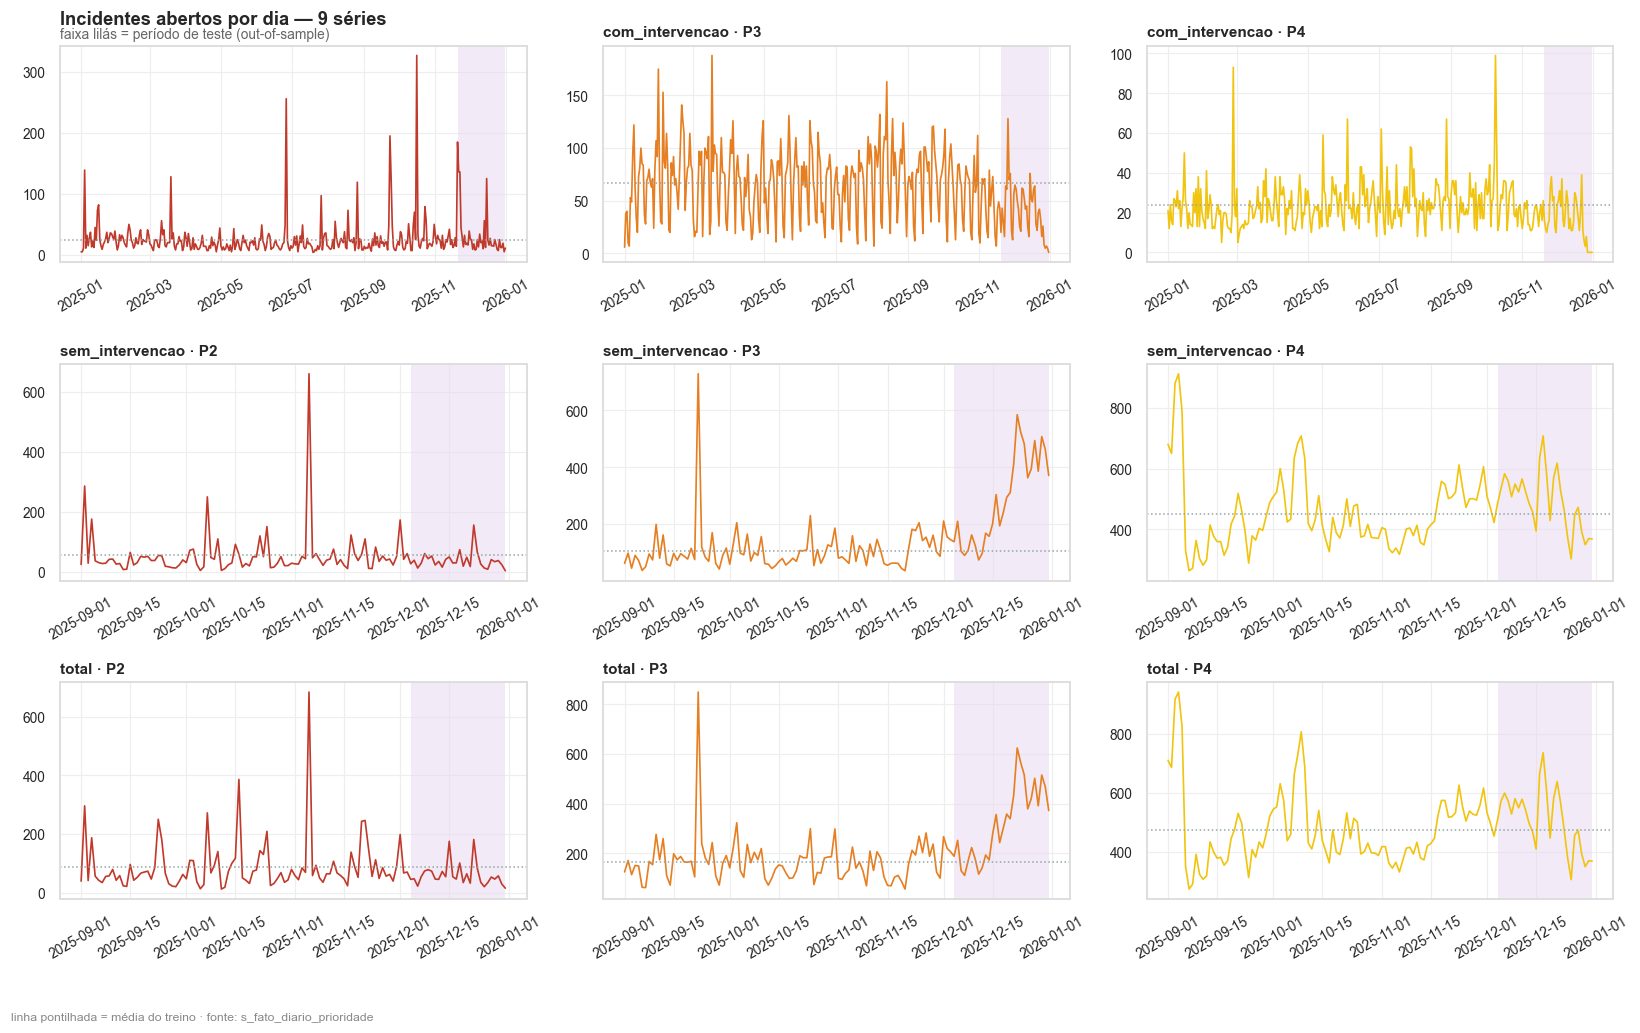

In [8]:
fig, axes = novo_grafico(
    "Incidentes abertos por dia — 9 séries",
    "faixa lilás = período de teste (out-of-sample)",
    figsize=(15, 9), nrows=3, ncols=3,
)
for i, g in enumerate(GRUPOS):
    for j, p in enumerate(PRIORIDADES):
        ax = axes[i, j]
        s = SERIES[(g, p)]
        ax.plot(s.data, s.abertos, color=COR_PRIORIDADE[p], lw=1.1)
        ax.axvspan(CORTE[g], s.data.max(), color=PALETA["teste"], alpha=0.55, lw=0)
        media = SPLIT[(g, p)]["treino"].abertos.mean()
        ax.axhline(media, color=PALETA["neutro"], ls=":", lw=1)
        if i or j:
            ax.set_title(f"{g} · P{p}", fontsize=10)
        ax.tick_params(axis="x", rotation=30)
finalizar(fig, "linha pontilhada = média do treino · fonte: s_fato_diario_prioridade")

## 3.2 Autocorrelação (ACF) e autocorrelação parcial (PACF)

**Como ler.** A **ACF** mede a correlação da série com ela mesma defasada de *k* dias, incluindo
o efeito indireto que passa pelos lags intermediários — um pico em 7, 14, 21 é assinatura de
sazonalidade semanal. A **PACF** mede a mesma correlação *descontando* os lags intermediários —
é ela que diz quantos termos autorregressivos a série realmente precisa. A faixa sombreada é o
intervalo de confiança de 95%: barra dentro da faixa é ruído.

Ambas calculadas apenas no treino, com `method="ywm"` na PACF.

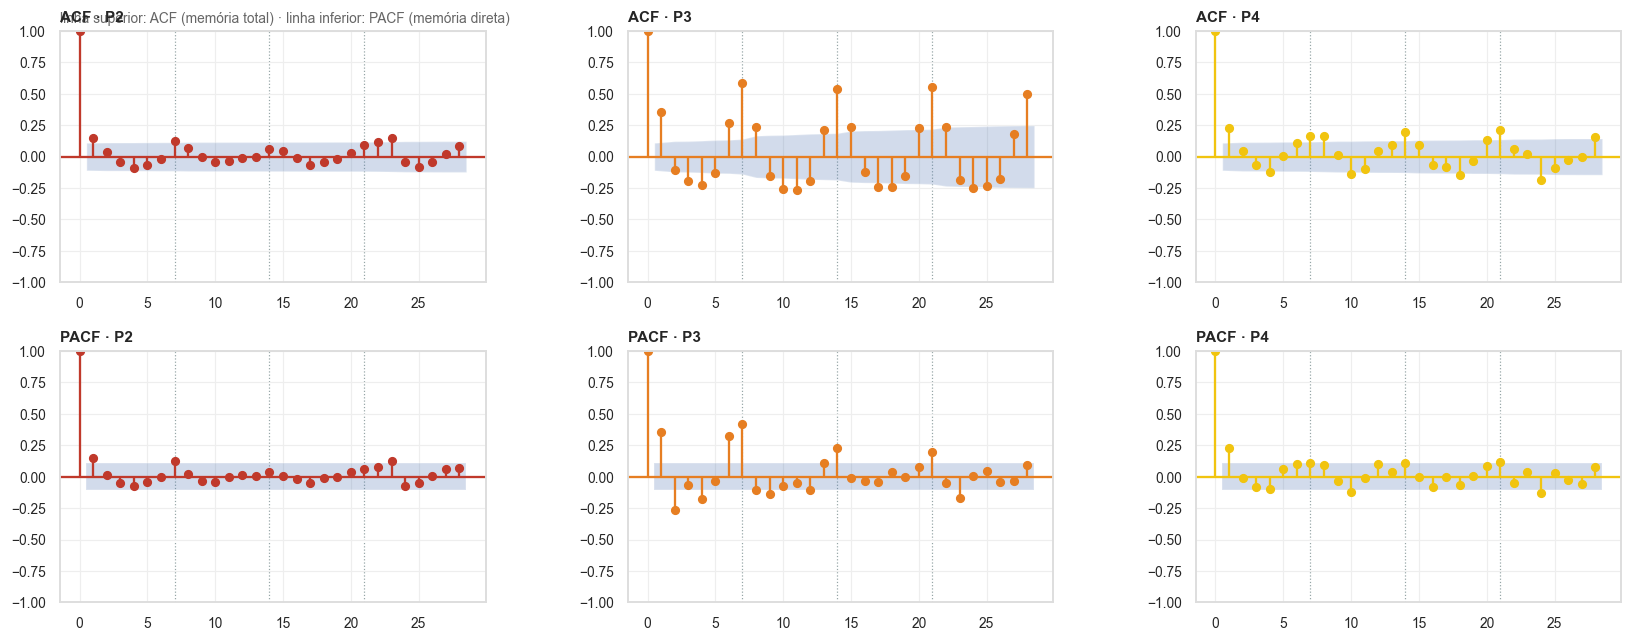

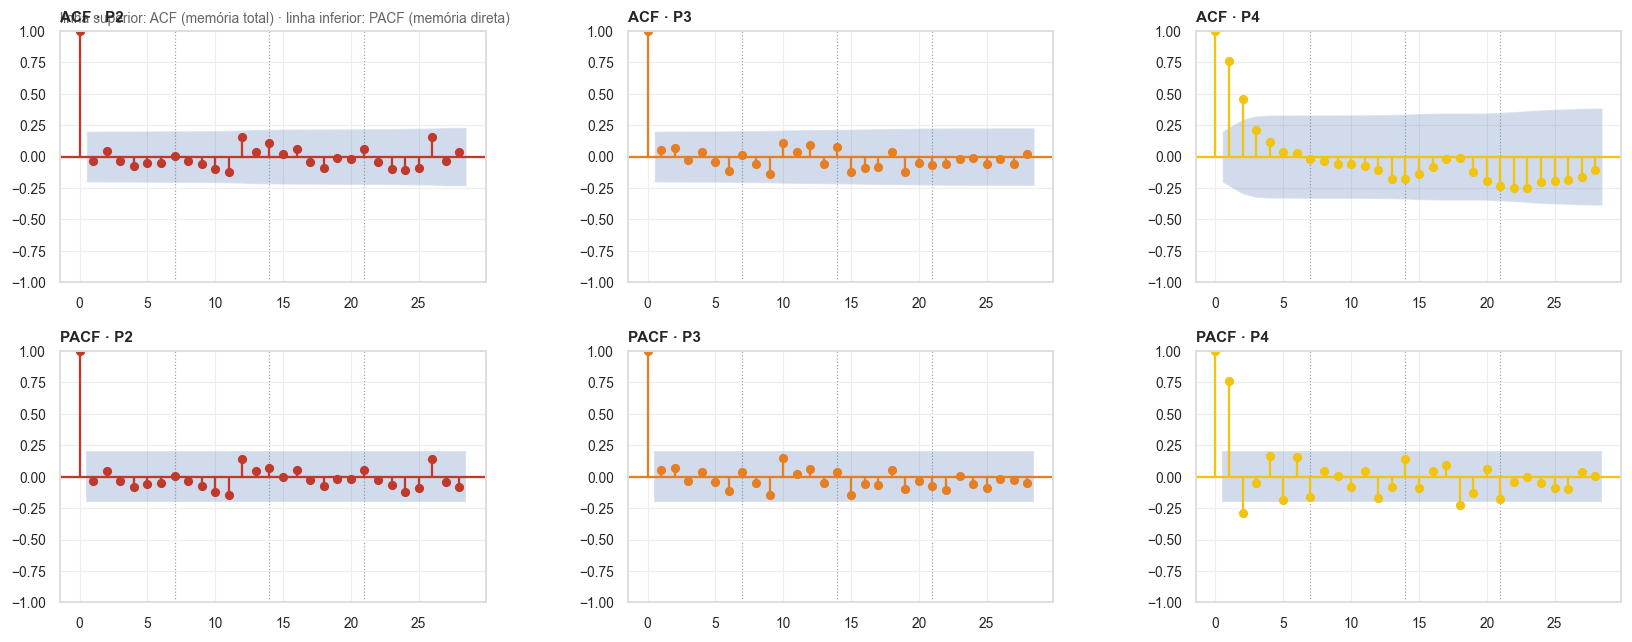

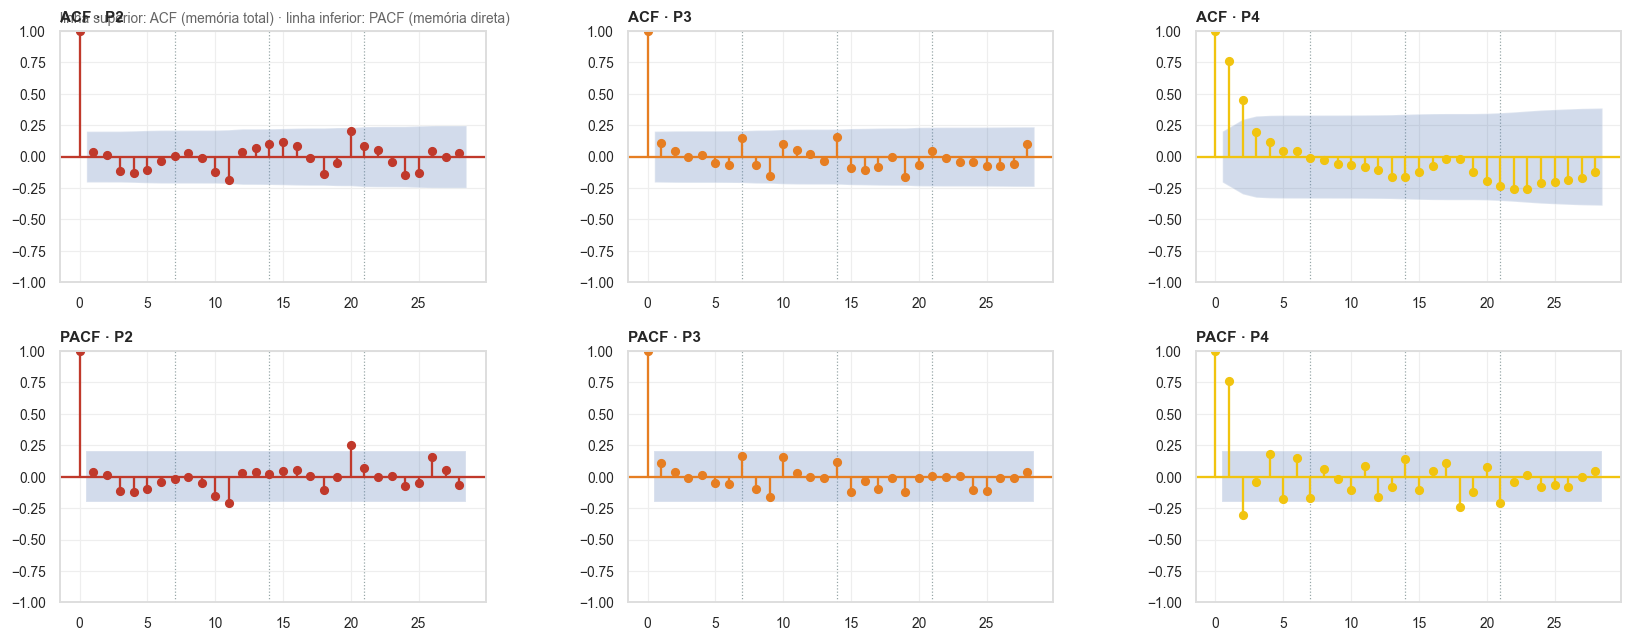

In [9]:
for g in GRUPOS:
    fig, axes = novo_grafico(
        f"ACF e PACF — {g} (só na fatia de treino)",
        "linha superior: ACF (memória total) · linha inferior: PACF (memória direta)",
        figsize=(15, 6), nrows=2, ncols=3,
    )
    for j, p in enumerate(PRIORIDADES):
        y = SPLIT[(g, p)]["treino"].abertos
        n_lags = min(28, len(y) // 2 - 1)
        plot_acf(y, lags=n_lags, ax=axes[0, j], color=COR_PRIORIDADE[p],
                 vlines_kwargs={"colors": COR_PRIORIDADE[p]})
        plot_pacf(y, lags=n_lags, ax=axes[1, j], method="ywm", color=COR_PRIORIDADE[p],
                  vlines_kwargs={"colors": COR_PRIORIDADE[p]})
        axes[0, j].set_title(f"ACF · P{p}", fontsize=10)
        axes[1, j].set_title(f"PACF · P{p}", fontsize=10)
        for ax in (axes[0, j], axes[1, j]):
            for k in (7, 14, 21):
                if k <= n_lags:
                    ax.axvline(k, color=PALETA["neutro"], ls=":", lw=0.8, zorder=0)
    finalizar(fig)

In [10]:
def resumo_autocorrelacao(y, lags=(1, 2, 3, 7, 14)):
    """ACF e PACF nos lags de interesse + o limite de significância de 95%."""
    from statsmodels.tsa.stattools import acf, pacf
    n = len(y)
    maximo = max(lags)
    a = acf(y, nlags=maximo, fft=False)
    pa = pacf(y, nlags=maximo, method="ywm")
    limite = 1.96 / np.sqrt(n)
    return {f"acf_{k}": a[k] for k in lags} | {f"pacf_{k}": pa[k] for k in lags} | {"limite_95": limite}


diag_acf = pd.DataFrame([
    {"grupo": g, "prioridade": p, **resumo_autocorrelacao(SPLIT[(g, p)]["treino"].abertos)}
    for g in GRUPOS for p in PRIORIDADES
])
tabela(diag_acf, "ACF/PACF nos lags relevantes — valor acima de `limite_95` é sinal, não ruído", casas=3)

**ACF/PACF nos lags relevantes — valor acima de `limite_95` é sinal, não ruído**

| grupo           |   prioridade |   acf_1 |   acf_2 |   acf_3 |   acf_7 |   acf_14 |   pacf_1 |   pacf_2 |   pacf_3 |   pacf_7 |   pacf_14 |   limite_95 |
|:----------------|-------------:|--------:|--------:|--------:|--------:|---------:|---------:|---------:|---------:|---------:|----------:|------------:|
| com_intervencao |            2 |   0.151 |   0.034 |  -0.041 |   0.121 |    0.061 |    0.151 |    0.011 |   -0.049 |    0.125 |     0.04  |       0.109 |
| com_intervencao |            3 |   0.357 |  -0.103 |  -0.194 |   0.585 |    0.535 |    0.357 |   -0.264 |   -0.066 |    0.422 |     0.226 |       0.109 |
| com_intervencao |            4 |   0.228 |   0.045 |  -0.069 |   0.163 |    0.194 |    0.228 |   -0.007 |   -0.082 |    0.11  |     0.108 |       0.109 |
| sem_intervencao |            2 |  -0.038 |   0.046 |  -0.038 |   0.008 |    0.11  |   -0.038 |    0.045 |   -0.035 |    0.003 |     0.067 |       0.202 |
| sem_intervencao |            3 |   0.053 |   0.071 |  -0.024 |   0.015 |    0.076 |    0.053 |    0.069 |   -0.031 |    0.036 |     0.04  |       0.202 |
| sem_intervencao |            4 |   0.76  |   0.456 |   0.208 |  -0.017 |   -0.179 |    0.76  |   -0.288 |   -0.048 |   -0.165 |     0.142 |       0.202 |
| total           |            2 |   0.034 |   0.016 |  -0.112 |   0.009 |    0.104 |    0.034 |    0.015 |   -0.113 |   -0.016 |     0.022 |       0.202 |
| total           |            3 |   0.11  |   0.045 |  -0.004 |   0.147 |    0.153 |    0.11  |    0.034 |   -0.012 |    0.168 |     0.116 |       0.202 |
| total           |            4 |   0.759 |   0.448 |   0.198 |  -0.012 |   -0.162 |    0.759 |   -0.303 |   -0.039 |   -0.17  |     0.144 |       0.202 |

## 3.3 Decomposição STL

STL (*Seasonal-Trend decomposition using Loess*) quebra a série em **tendência + sazonalidade +
resíduo**. Uso período 7 (semana), não 365: com 122 dias na janela mais curta não há dois ciclos
anuais para estimar sazonalidade anual — pedir isso ao STL produziria uma componente inventada.

A métrica que resume cada painel é a **força da componente**, no sentido de Hyndman:

`força = max(0, 1 - Var(resíduo) / Var(resíduo + componente))`

Perto de 1, a componente domina; perto de 0, ela é irrelevante diante do ruído.

In [11]:
def forca_componente(residuo, componente):
    """Força da componente (Hyndman): 1 - Var(R) / Var(R + componente)."""
    denominador = np.var(residuo + componente)
    if denominador <= 0:
        return 0.0
    return float(max(0.0, 1 - np.var(residuo) / denominador))


DECOMPOSICAO = {}
linhas_stl = []
for g in GRUPOS:
    for p in PRIORIDADES:
        s = SERIES[(g, p)]
        y = pd.Series(s.abertos.values, index=pd.DatetimeIndex(s.data), name="abertos")
        res = STL(y, period=PERIODO_SAZONAL, robust=True).fit()
        DECOMPOSICAO[(g, p)] = res
        linhas_stl.append({
            "grupo": g, "prioridade": p,
            "forca_tendencia": forca_componente(res.resid, res.trend),
            "forca_sazonal": forca_componente(res.resid, res.seasonal),
            "dp_residuo": float(np.std(res.resid)),
            "residuo_sobre_media": float(np.std(res.resid) / y.mean()),
        })

tabela(pd.DataFrame(linhas_stl),
       "Força das componentes STL — quanto de cada série é estrutura e quanto é ruído", casas=3)

**Força das componentes STL — quanto de cada série é estrutura e quanto é ruído**

| grupo           |   prioridade |   forca_tendencia |   forca_sazonal |   dp_residuo |   residuo_sobre_media |
|:----------------|-------------:|------------------:|----------------:|-------------:|----------------------:|
| com_intervencao |            2 |             0.04  |           0.128 |       28.124 |                 1.094 |
| com_intervencao |            3 |             0.407 |           0.653 |       17.606 |                 0.276 |
| com_intervencao |            4 |             0.231 |           0.257 |        8.992 |                 0.389 |
| sem_intervencao |            2 |             0.014 |           0.128 |       65.011 |                 1.267 |
| sem_intervencao |            3 |             0.654 |           0.085 |       73.55  |                 0.5   |
| sem_intervencao |            4 |             0.44  |           0.069 |       89.623 |                 0.195 |
| total           |            2 |             0.047 |           0.133 |       75.369 |                 0.919 |
| total           |            3 |             0.58  |           0.209 |       77.902 |                 0.386 |
| total           |            4 |             0.429 |           0.06  |       94.381 |                 0.196 |

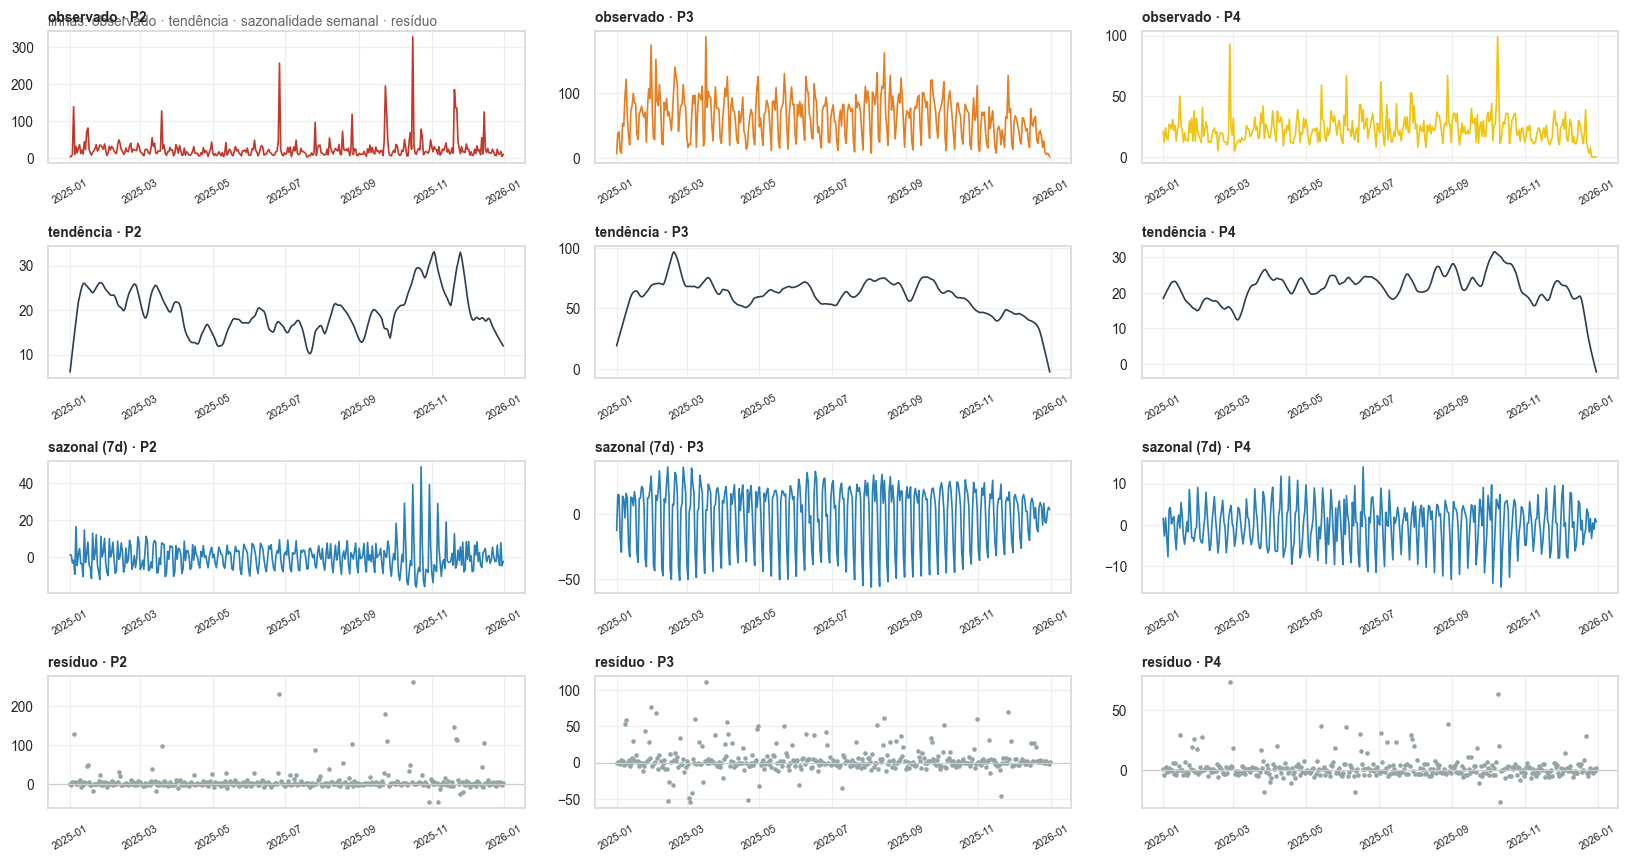

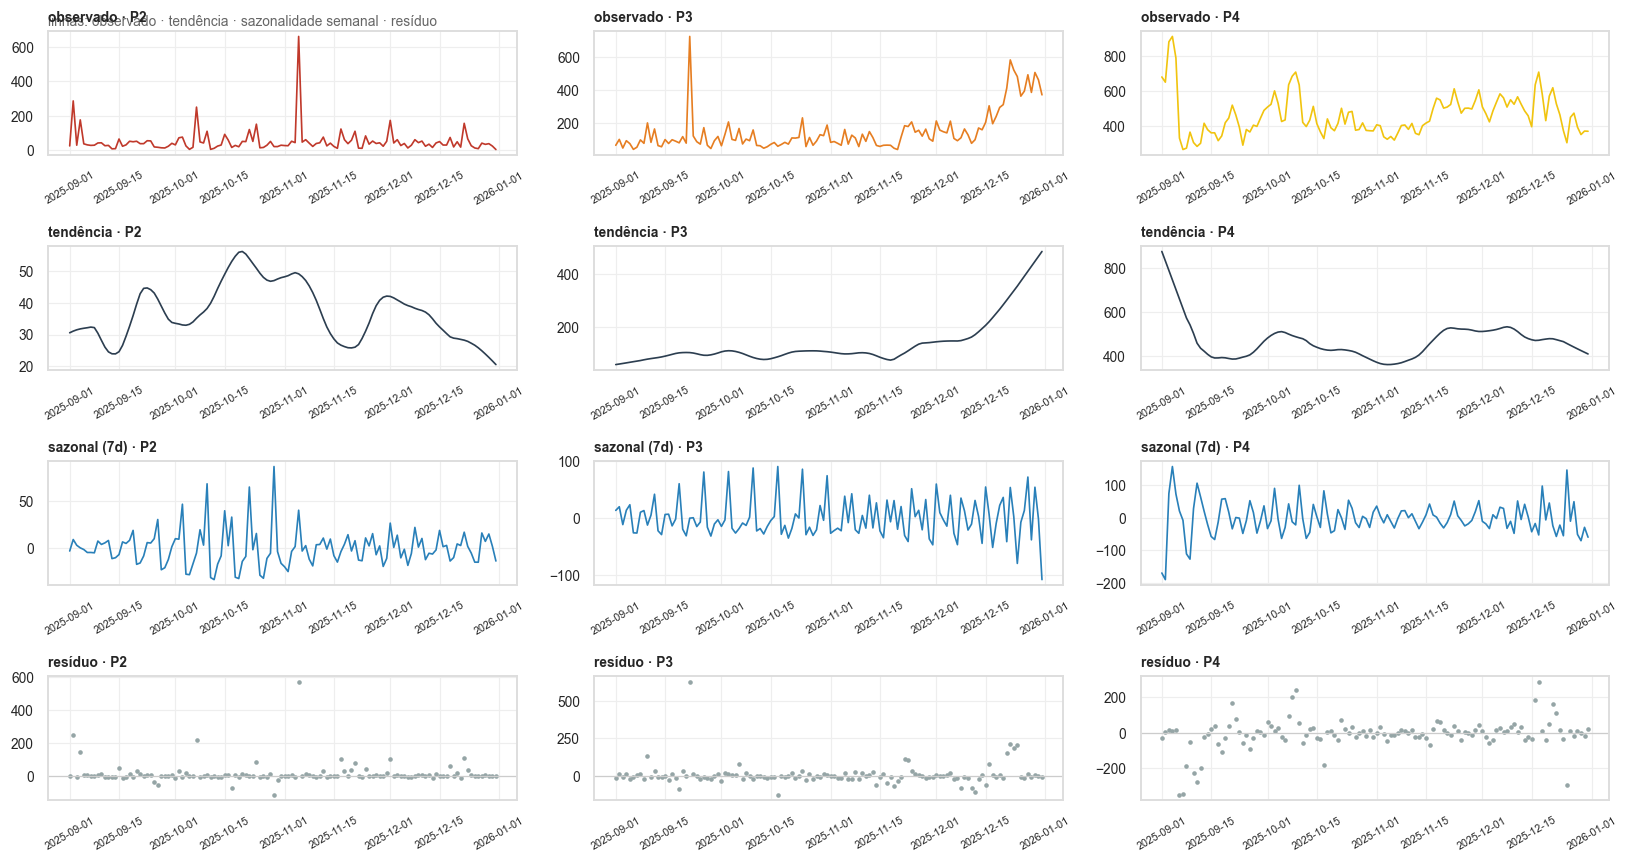

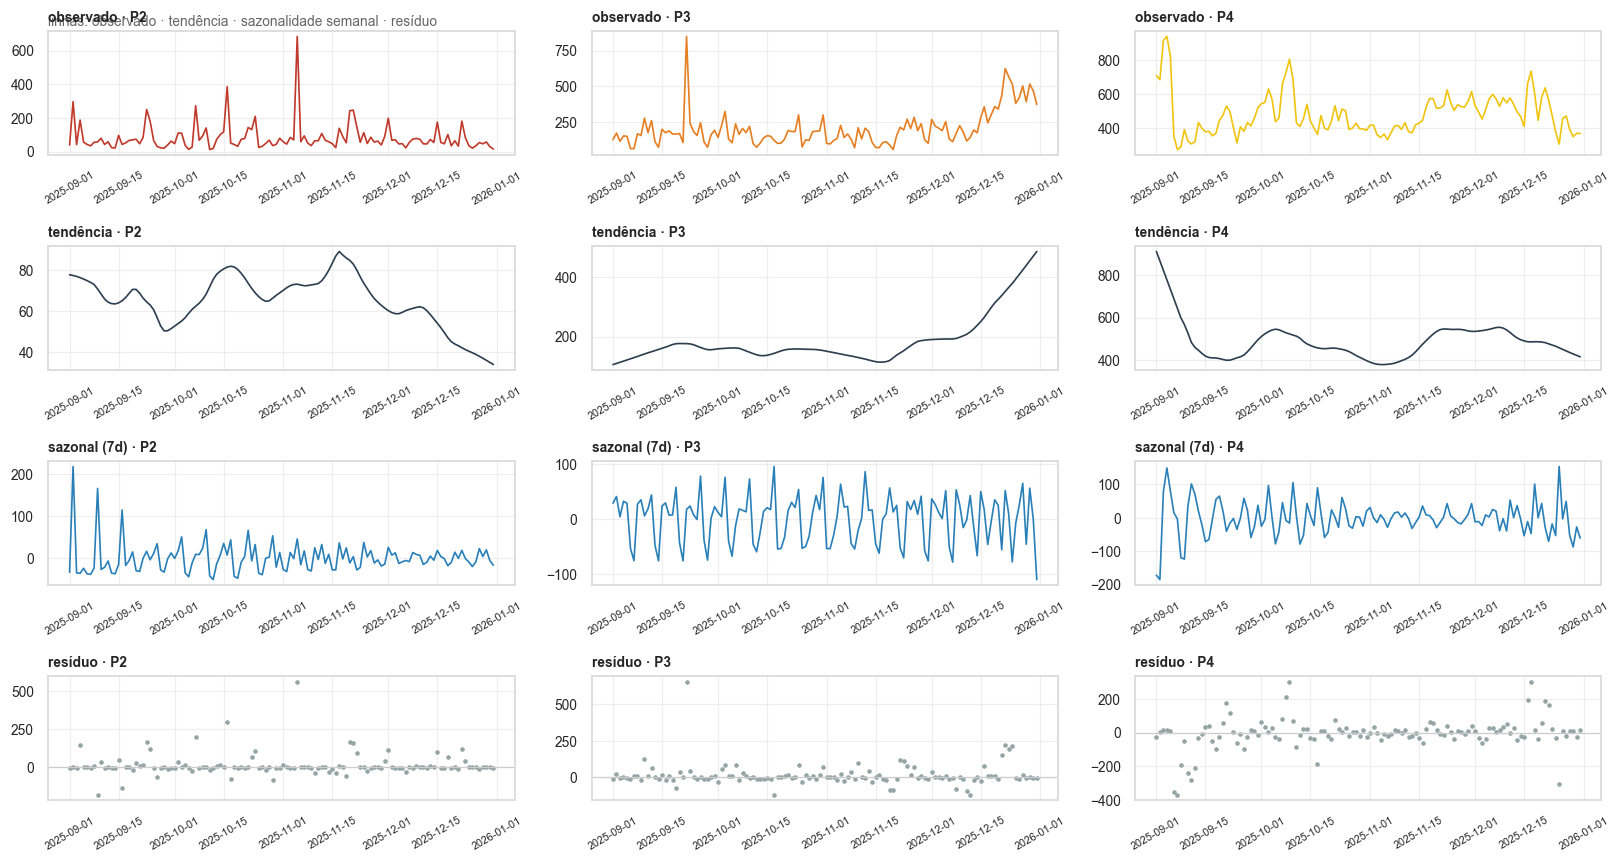

In [12]:
for g in GRUPOS:
    fig, axes = novo_grafico(
        f"Decomposição STL (período 7) — {g}",
        "linhas: observado · tendência · sazonalidade semanal · resíduo",
        figsize=(15, 8), nrows=4, ncols=3,
    )
    for j, p in enumerate(PRIORIDADES):
        res = DECOMPOSICAO[(g, p)]
        componentes = [
            ("observado", res.observed, COR_PRIORIDADE[p]),
            ("tendência", res.trend, PALETA["total"]),
            ("sazonal (7d)", res.seasonal, PALETA["destaque"]),
            ("resíduo", res.resid, PALETA["neutro"]),
        ]
        for i, (nome, serie, cor) in enumerate(componentes):
            ax = axes[i, j]
            if nome == "resíduo":
                ax.axhline(0, color="#CCCCCC", lw=0.8)
                ax.scatter(serie.index, serie.values, s=4, color=cor)
            else:
                ax.plot(serie.index, serie.values, color=cor, lw=1.1)
            ax.set_title(f"{nome} · P{p}" if i or j else f"observado · P{p}", fontsize=9)
            ax.tick_params(axis="x", rotation=30, labelsize=7)
    finalizar(fig)

## 3.4 Observações — o que cada gráfico permite constatar

A célula abaixo lê os números que acabaram de ser calculados e escreve as observações a partir
deles, em vez de deixá-las escritas à mão num markdown que envelhece se o dado mudar.

In [13]:
from IPython.display import Markdown, display

stl = pd.DataFrame(linhas_stl).set_index(["grupo", "prioridade"])
acf_idx = diag_acf.set_index(["grupo", "prioridade"])

partes = ["### Observações lidas dos gráficos de §3\n"]

# --- 1. nível e escala
partes.append("**1. Nível e escala separam os grupos antes de qualquer modelo.**\n")
for g in GRUPOS:
    medias = ", ".join(f"P{p} ≈ {SERIES[(g, p)].abertos.mean():.0f}/dia" for p in PRIORIDADES)
    partes.append(f"- `{g}`: {medias}.")
maior = resumo.loc[resumo.media_dia.idxmax()]
menor = resumo.loc[resumo.media_dia.idxmin()]
partes.append(
    f"\nA série mais volumosa (`{maior.grupo}` P{int(maior.prioridade)}, {maior.media_dia:.0f}/dia) tem "
    f"**{maior.media_dia / menor.media_dia:.0f}×** o volume da menor (`{menor.grupo}` "
    f"P{int(menor.prioridade)}, {menor.media_dia:.0f}/dia). Consequência prática: **MAE não é "
    "comparável entre séries** — só dentro da mesma série. Por isso §8 reporta MASE ao lado do "
    "MAE, que é escala-livre e não quebra nos dias de contagem zero.\n"
)

# --- 2. ACF
partes.append("**2. ACF — a memória é curta e a sazonalidade semanal é fraca.**\n")
for g in GRUPOS:
    for p in PRIORIDADES:
        r = acf_idx.loc[(g, p)]
        lag1 = "significativo" if abs(r.acf_1) > r.limite_95 else "dentro do ruído"
        lag7 = "significativo" if abs(r.acf_7) > r.limite_95 else "dentro do ruído"
        partes.append(
            f"- `{g}` P{p}: ACF(1) = {r.acf_1:.2f} ({lag1}), ACF(7) = {r.acf_7:.2f} ({lag7}) "
            f"— limite de 95% em ±{r.limite_95:.2f}."
        )
n_sig7 = int((acf_idx.acf_7.abs() > acf_idx.limite_95).sum())
partes.append(
    f"\nEm **{n_sig7} das 9 séries** o lag 7 passa do limite de significância. "
    + ("Sazonalidade semanal existe mas é modesta — justifica *testar* SARIMA contra ARIMA, não "
       "assumir que o termo sazonal vai valer o custo.\n"
       if n_sig7 <= 6 else
       "Sazonalidade semanal presente na maioria das séries — o termo sazonal do SARIMA e a "
       "sazonalidade semanal do Prophet têm o que capturar.\n")
)

# --- 3. PACF
partes.append("**3. PACF — corte rápido: pouca ordem autorregressiva.**\n")
maior_ordem = {}
for g in GRUPOS:
    for p in PRIORIDADES:
        r = acf_idx.loc[(g, p)]
        sig = [k for k in (1, 2, 3, 7, 14) if abs(r[f"pacf_{k}"]) > r.limite_95]
        maior_ordem[(g, p)] = max(sig) if sig else 0
        partes.append(f"- `{g}` P{p}: lags com PACF significativa = {sig if sig else 'nenhum'}.")
partes.append(
    "\nA PACF cortando cedo é o argumento a favor de **ordens baixas** no ARIMA/SARIMA: uma "
    "estrutura autorregressiva longa gastaria parâmetros em lags que não carregam sinal — caro "
    "sobretudo nas séries de 122 dias.\n"
)

# --- 4. STL
partes.append("**4. Decomposição — o resíduo domina, e é isso que limita o teto de acerto.**\n")
for g in GRUPOS:
    for p in PRIORIDADES:
        r = stl.loc[(g, p)]
        partes.append(
            f"- `{g}` P{p}: força da tendência = {r.forca_tendencia:.2f}, "
            f"força sazonal = {r.forca_sazonal:.2f}, "
            f"desvio do resíduo = {r.residuo_sobre_media * 100:.0f}% da média da série."
        )
partes.append(
    f"\nA sazonalidade semanal média das 9 séries é **{stl.forca_sazonal.mean():.2f}** contra "
    f"**{stl.forca_tendencia.mean():.2f}** de tendência. O resíduo responde, em média, por "
    f"**{stl.residuo_sobre_media.mean() * 100:.0f}%** da média do nível — é a **componente "
    "estocástica** que a instrução de §5 quer entender. Nenhum dos modelos de §7 explica essa "
    "parcela a partir do próprio passado; se algo a explica, tem de vir de fora da série, e é "
    "exatamente isso que o XGBoost de §5 vai procurar.\n"
)

# --- 5. o que isso decide
partes.append("**5. O que essas três leituras decidem para o resto do notebook.**\n")
partes.append(
    "- Memória curta (PACF) + sazonalidade semanal fraca a moderada (ACF/STL) → **ARIMA de ordem "
    "baixa é um candidato competitivo**, e o SARIMA precisa provar que o termo sazonal paga o "
    "custo em parâmetro.\n"
    "- Tendência fraca em quase todas as séries → o componente de tendência do Prophet tem pouco "
    "a capturar; o valor dele aqui vem de feriados e sazonalidade, não de trend.\n"
    "- Resíduo alto → **o baseline ingênuo vai ser um adversário duro**. Numa série dominada por "
    "ruído, repetir o último valor é difícil de bater, e §8 leva isso a sério em vez de tratá-lo "
    "como formalidade.\n"
    "- Escalas muito diferentes entre séries → cada série ganha o seu próprio modelo e o seu "
    "próprio escalonamento no LSTM."
)

display(Markdown("\n".join(partes)))

### Observações lidas dos gráficos de §3

**1. Nível e escala separam os grupos antes de qualquer modelo.**

- `com_intervencao`: P2 ≈ 26/dia, P3 ≈ 64/dia, P4 ≈ 23/dia.
- `sem_intervencao`: P2 ≈ 51/dia, P3 ≈ 147/dia, P4 ≈ 460/dia.
- `total`: P2 ≈ 82/dia, P3 ≈ 202/dia, P4 ≈ 482/dia.

A série mais volumosa (`total` P4, 482/dia) tem **21×** o volume da menor (`com_intervencao` P4, 23/dia). Consequência prática: **MAE não é comparável entre séries** — só dentro da mesma série. Por isso §8 reporta MASE ao lado do MAE, que é escala-livre e não quebra nos dias de contagem zero.

**2. ACF — a memória é curta e a sazonalidade semanal é fraca.**

- `com_intervencao` P2: ACF(1) = 0.15 (significativo), ACF(7) = 0.12 (significativo) — limite de 95% em ±0.11.
- `com_intervencao` P3: ACF(1) = 0.36 (significativo), ACF(7) = 0.58 (significativo) — limite de 95% em ±0.11.
- `com_intervencao` P4: ACF(1) = 0.23 (significativo), ACF(7) = 0.16 (significativo) — limite de 95% em ±0.11.
- `sem_intervencao` P2: ACF(1) = -0.04 (dentro do ruído), ACF(7) = 0.01 (dentro do ruído) — limite de 95% em ±0.20.
- `sem_intervencao` P3: ACF(1) = 0.05 (dentro do ruído), ACF(7) = 0.02 (dentro do ruído) — limite de 95% em ±0.20.
- `sem_intervencao` P4: ACF(1) = 0.76 (significativo), ACF(7) = -0.02 (dentro do ruído) — limite de 95% em ±0.20.
- `total` P2: ACF(1) = 0.03 (dentro do ruído), ACF(7) = 0.01 (dentro do ruído) — limite de 95% em ±0.20.
- `total` P3: ACF(1) = 0.11 (dentro do ruído), ACF(7) = 0.15 (dentro do ruído) — limite de 95% em ±0.20.
- `total` P4: ACF(1) = 0.76 (significativo), ACF(7) = -0.01 (dentro do ruído) — limite de 95% em ±0.20.

Em **3 das 9 séries** o lag 7 passa do limite de significância. Sazonalidade semanal existe mas é modesta — justifica *testar* SARIMA contra ARIMA, não assumir que o termo sazonal vai valer o custo.

**3. PACF — corte rápido: pouca ordem autorregressiva.**

- `com_intervencao` P2: lags com PACF significativa = [1, 7].
- `com_intervencao` P3: lags com PACF significativa = [1, 2, 7, 14].
- `com_intervencao` P4: lags com PACF significativa = [1, 7].
- `sem_intervencao` P2: lags com PACF significativa = nenhum.
- `sem_intervencao` P3: lags com PACF significativa = nenhum.
- `sem_intervencao` P4: lags com PACF significativa = [1, 2].
- `total` P2: lags com PACF significativa = nenhum.
- `total` P3: lags com PACF significativa = nenhum.
- `total` P4: lags com PACF significativa = [1, 2].

A PACF cortando cedo é o argumento a favor de **ordens baixas** no ARIMA/SARIMA: uma estrutura autorregressiva longa gastaria parâmetros em lags que não carregam sinal — caro sobretudo nas séries de 122 dias.

**4. Decomposição — o resíduo domina, e é isso que limita o teto de acerto.**

- `com_intervencao` P2: força da tendência = 0.04, força sazonal = 0.13, desvio do resíduo = 109% da média da série.
- `com_intervencao` P3: força da tendência = 0.41, força sazonal = 0.65, desvio do resíduo = 28% da média da série.
- `com_intervencao` P4: força da tendência = 0.23, força sazonal = 0.26, desvio do resíduo = 39% da média da série.
- `sem_intervencao` P2: força da tendência = 0.01, força sazonal = 0.13, desvio do resíduo = 127% da média da série.
- `sem_intervencao` P3: força da tendência = 0.65, força sazonal = 0.09, desvio do resíduo = 50% da média da série.
- `sem_intervencao` P4: força da tendência = 0.44, força sazonal = 0.07, desvio do resíduo = 20% da média da série.
- `total` P2: força da tendência = 0.05, força sazonal = 0.13, desvio do resíduo = 92% da média da série.
- `total` P3: força da tendência = 0.58, força sazonal = 0.21, desvio do resíduo = 39% da média da série.
- `total` P4: força da tendência = 0.43, força sazonal = 0.06, desvio do resíduo = 20% da média da série.

A sazonalidade semanal média das 9 séries é **0.19** contra **0.32** de tendência. O resíduo responde, em média, por **58%** da média do nível — é a **componente estocástica** que a instrução de §5 quer entender. Nenhum dos modelos de §7 explica essa parcela a partir do próprio passado; se algo a explica, tem de vir de fora da série, e é exatamente isso que o XGBoost de §5 vai procurar.

**5. O que essas três leituras decidem para o resto do notebook.**

- Memória curta (PACF) + sazonalidade semanal fraca a moderada (ACF/STL) → **ARIMA de ordem baixa é um candidato competitivo**, e o SARIMA precisa provar que o termo sazonal paga o custo em parâmetro.
- Tendência fraca em quase todas as séries → o componente de tendência do Prophet tem pouco a capturar; o valor dele aqui vem de feriados e sazonalidade, não de trend.
- Resíduo alto → **o baseline ingênuo vai ser um adversário duro**. Numa série dominada por ruído, repetir o último valor é difícil de bater, e §8 leva isso a sério em vez de tratá-lo como formalidade.
- Escalas muito diferentes entre séries → cada série ganha o seu próprio modelo e o seu próprio escalonamento no LSTM.

---

# 4. Visualização das features

Pergunta desta seção: **das features disponíveis nas camadas silver, quais têm relação com o
volume de incidentes?**

Duas leituras diferentes, que respondem a coisas diferentes:

| Leitura | Correlação de… | Serve para |
|---|---|---|
| **Contemporânea** | feature em D × `abertos` em D | descrever o que acompanha o volume |
| **Preditiva** | feature em D × `abertos` em **D+1** | descobrir o que pode virar feature de modelo |

Só a segunda tem valor para previsão. A primeira entra porque expõe um problema que
contaminaria a leitura: várias colunas do fato são **decomposições do próprio alvo**
(`abertos_monitoramento + abertos_manual = abertos`) e por isso correlacionam quase 1 com ele —
sem serem informativas. Elas ficam marcadas na tabela.

Uso **Spearman**, não Pearson: as séries têm picos fortes (P2 chega a 660 num dia de média 51) e
Pearson seria sequestrado por esses pontos.

In [14]:
concentracao = pd.read_csv(CAMINHO_SILVER / "s_ft_concentracao.csv", sep=";", parse_dates=["data"])
features_ic = pd.read_csv(CAMINHO_SILVER / "s_ft_ic.csv", sep=";", parse_dates=["data"])
diario = pd.read_csv(CAMINHO_SILVER / "s_fato_diario.csv", sep=";", parse_dates=["data"])

# Time responsável e descrição resumida — as duas dimensões que a silver descreve e que este
# notebook nunca tinha carregado. Vêm no grão dia × valor × tipo_tratamento, o mesmo das séries.
fato_time = pd.read_csv(CAMINHO_SILVER / "s_fato_diario_time.csv", sep=";", parse_dates=["data"])
fato_classe = pd.read_csv(CAMINHO_SILVER / "s_fato_diario_classe.csv", sep=";", parse_dates=["data"])
ft_texto = pd.read_csv(CAMINHO_SILVER / "s_ft_texto.csv", sep=";", parse_dates=["data"])

# Colunas do fato diário que não são calendário (o calendário já entra por s_dim_calendario).
cols_diario = [c for c in diario.columns
               if c not in calendario.columns and c != "data"]

# Colunas do próprio grão (data × prioridade × tipo) que não são o alvo nem chave.
NAO_FEATURE = {"data", "prioridade", "tipo_tratamento", "abertos", "regime",
               "y_abertos_d1", "y_abertos_d7", "y_abertos_acum_1a7"}
cols_grao = [c for c in fato.columns if c not in NAO_FEATURE]

# Decomposições do alvo: somam de volta em `abertos` no mesmo dia.
TAUTOLOGICAS = {
    "abertos_monitoramento", "abertos_manual",
    "abertos_hor_comercial", "abertos_fora_hor_comercial",
}

# --- Times que viram coluna própria ---------------------------------------------------------
# 17 times, mas a distribuição é brutalmente desigual: um deles concentra ~3/4 do volume e a
# cauda tem times com um punhado de incidentes no ano. Uma coluna por time seria quase toda
# ruído, então só os que sustentam o volume viram coluna; o resto vira o bucket `outros`.
# O corte sai do **treino** de todos os grupos (data < menor CORTE) — escolher a lista olhando
# o volume total seria deixar o teste opinar sobre quais features existem.
CORTE_FEATURE = min(CORTE.values())
COBERTURA_TIME = 0.95

_vol_treino = (fato_time[fato_time.data < CORTE_FEATURE]
               .groupby("time")[[f"abertos_p{p}" for p in PRIORIDADES]].sum().sum(axis=1)
               .sort_values(ascending=False))
_share = _vol_treino / _vol_treino.sum()
TIMES_COLUNA = list(_share.index[:max(1, int((_share.cumsum() < COBERTURA_TIME).sum() + 1))])
CLASSES_COLUNA = sorted(fato_classe.classe_descricao.dropna().unique())

print(f"features do grão (data x prioridade x tipo): {len(cols_grao)}")
print(f"features do dia (s_fato_diario):             {len(cols_diario)}")
print(f"features de IC (s_ft_ic):                    {len(features_ic.columns) - 1}")
print(f"features de concentração:                    {len(concentracao.columns) - 1}")
print(f"features de calendário:                      {len(FEATURES_CALENDARIO)}")
print(f"features de texto (s_ft_texto):              {len(ft_texto.columns) - 3}")
print()
print(f"corte de referência para escolher features:  {CORTE_FEATURE:%Y-%m-%d}")
print(f"times com coluna própria ({_share[TIMES_COLUNA].sum():.1%} do volume de treino): "
      f"{TIMES_COLUNA}")
print(f"classes de descrição:                        {len(CLASSES_COLUNA)} — {CLASSES_COLUNA}")


features do grão (data x prioridade x tipo): 48
features do dia (s_fato_diario):             20
features de IC (s_ft_ic):                    13
features de concentração:                    3
features de calendário:                      11
features de texto (s_ft_texto):              11

corte de referência para escolher features:  2025-11-20
times com coluna própria (95.0% do volume de treino): ['Team14', 'Team11', 'Team05', 'Team09', 'Team12']
classes de descrição:                        11 — ['armazenamento_disco', 'backup_replicacao', 'banco_de_dados', 'certificado_seguranca', 'disponibilidade_servico', 'erro_aplicacao', 'infraestrutura_rede', 'job_processamento', 'nao_rotulado', 'outros', 'performance_degradada']


In [15]:
CHAVES_PAINEL = ["data", "prioridade", "tipo_tratamento"]

# Janelas em que a composição é medida. Um share de um único dia é instável onde o volume é
# baixo — `com_intervencao` P2 tem média de ~5 incidentes/dia, então UM incidente desloca a
# participação de um time em 20 pontos percentuais. Medir a composição em janela troca esse
# ruído amostral por uma estimativa do mix corrente.
#   lag1 = ontem (D−1);  7d/30d = janelas fechando em D, inclusive.
# Mesma convenção de `abertos_lag_1` / `abertos_media_7d` na silver.
JANELAS_MIX = {"lag1": 1, "7d": 7, "30d": 30}


def share_em_janela(largo, janela, nome):
    """Participação de cada coluna de `largo` na janela, dentro de cada série.

    `largo` chega indexado por (data, prioridade, tipo_tratamento), uma coluna por bucket, com a
    CONTAGEM de incidentes do dia. Devolve as mesmas colunas como proporção da janela.

    É **razão de somas** (soma do bucket na janela ÷ soma total na janela), não média das razões
    diárias. As duas divergem quando o volume oscila, e é a razão de somas que responde "que
    fração da carga da semana foi deste time" — a média das razões daria o mesmo peso a um
    domingo de 3 incidentes e a uma terça de 400.

    O `rolling` corre dentro de cada série. A silver garante grade de datas completa, então
    janela de 7 dias é 7 *dias* e não 7 *registros* — sem isso o resultado seria silenciosamente
    errado nos trechos em que a série tem dias vazios.
    """
    g = largo.groupby(level=["prioridade", "tipo_tratamento"], observed=True)
    if nome == "lag1":
        somas = g.shift(1)
    else:
        somas = g.rolling(janela, min_periods=1).sum().reset_index(level=[0, 1], drop=True)
        somas = somas.reindex(largo.index)
    total = somas.sum(axis=1)
    return somas.div(total.where(total > 0), axis=0)


def encoding_categorico(fato, dimensao, valores, prefixo, incluir_total=True, resumo=False):
    """Composição de uma dimensão categórica ao longo do tempo, no grão data × prioridade × tipo.

    Num grão diário, "one-hot" não é uma coluna 0/1 por linha: o que interessa é **que fração da
    carga** coube a cada valor da categoria. A contagem inteira não vira feature — as contagens
    dos buckets somam exatamente `abertos`, então seriam o alvo reescrito em outra base, sem
    informação nova sobre ele (`abertos` já está no modelo como lag 1). Elas existem aqui só como
    matriz intermediária, e o assert abaixo usa essa propriedade para provar que o pivot não
    perdeu nem duplicou incidente.

    Valores fora de `valores` caem no bucket `outros`, para que a soma dos shares continue 1.

    O grupo `total` é montado **aqui**, somando as contagens antes de dividir. Somar shares (que
    é o que aconteceria se o `total` fosse construído a jusante) não significa nada: dois shares
    de 0,8 somam 1,6.
    """
    longo = fato.melt(
        id_vars=["data", dimensao, "tipo_tratamento"],
        value_vars=[f"abertos_p{p}" for p in PRIORIDADES],
        var_name="prioridade", value_name="n",
    )
    longo["prioridade"] = longo.prioridade.str.replace("abertos_p", "", regex=False).astype(int)
    longo[dimensao] = np.where(longo[dimensao].isin(valores), longo[dimensao], "outros")

    if incluir_total:
        soma = longo.groupby(["data", "prioridade", dimensao], as_index=False)["n"].sum()
        soma["tipo_tratamento"] = "total"
        longo = pd.concat([longo, soma], ignore_index=True)

    largo = (longo.groupby(CHAVES_PAINEL + [dimensao], observed=True)["n"].sum()
             .unstack(dimensao, fill_value=0)
             .sort_index(level=["prioridade", "tipo_tratamento", "data"]))

    # A contagem particiona o dia: é o que garante que o pivot está correto.
    CONTAGENS_POR_DIMENSAO[prefixo] = largo

    blocos = []
    for nome, janela in JANELAS_MIX.items():
        share = share_em_janela(largo, janela, nome)
        blocos.append(share.add_prefix(f"mix{prefixo}_").add_suffix(f"_{nome}"))
        if resumo:
            blocos.append(resumo_concentracao(share, f"conc{prefixo}_{nome}"))
    return pd.concat(blocos, axis=1).reset_index()


def resumo_concentracao(shares, prefixo):
    """Diversidade e concentração a partir de uma matriz de shares — exata só se ela for completa.

    Aplicado às classes de descrição, onde as 11 viram coluna e nada cai no bucket `outros`.
    Não é aplicado aos times: lá a matriz é truncada no top-K, e um HHI calculado sobre buckets
    mediria a concentração entre os buckets, não entre os times. Para essa leitura já existe
    `hhi_times` no grão dia, vindo de `s_ft_concentracao`, calculado sobre os 17.
    """
    p = shares.to_numpy(dtype=float)
    com_dado = np.nansum(p, axis=1) > 0
    seguro = np.where(np.isnan(p), 0.0, p)
    ent = -np.nansum(np.where(seguro > 0, seguro * np.log(seguro), 0.0), axis=1)
    ent = ent / np.log(shares.shape[1])
    out = pd.DataFrame(index=shares.index)
    out[f"{prefixo}_ativos"] = np.where(com_dado, (seguro > 0).sum(axis=1), np.nan)
    out[f"{prefixo}_hhi"] = np.where(com_dado, (seguro ** 2).sum(axis=1), np.nan)
    out[f"{prefixo}_lider"] = np.where(com_dado, seguro.max(axis=1), np.nan)
    out[f"{prefixo}_entropia"] = np.where(com_dado, ent, np.nan)
    return out


# Colunas de `s_ft_texto` e como cada uma se agrega ao construir o grupo `total`.
# Média de médias ponderada pelo nº de incidentes é **exata** para uma média; mínimo de mínimos
# é exato para um mínimo; contagem soma. Mediana, percentil e entropia da união NÃO são
# recuperáveis a partir das partes — ficam nulas no `total` em vez de receberem uma média
# ponderada que pareceria um número e não seria.
AGREGACAO_TEXTO = {
    "freq_template_media": "ponderada",
    "freq_time_media": "ponderada",
    "pct_template_novo": "ponderada",
    "freq_time_min": "min",
    "incidentes": "soma",
    "templates_novos": "soma",
    "freq_template_mediana": None,
    "freq_template_p10": None,
    "entropia_templates_dia": None,
    "entropia_times_dia": None,
}

# As mesmas janelas do mix, aplicadas às features de texto: um dia isolado de descrição rara diz
# menos do que uma semana em que a raridade subiu. A frequência em si continua **expansiva**
# (contada só sobre dias < D, ver s_ft_texto) — a janela suaviza, não muda a definição.
TEXTO_EM_JANELA = ["freq_template_media", "pct_template_novo",
                   "entropia_templates_dia", "entropia_times_dia"]


def completar_total_texto(ft):
    """Acrescenta as linhas do grupo `total` a uma tabela no grão data × prioridade × tipo."""
    base = ft[ft.tipo_tratamento.isin(["com_intervencao", "sem_intervencao"])].copy()
    peso = base["incidentes"].astype(float)
    partes = {}
    for col, como in AGREGACAO_TEXTO.items():
        if col not in base.columns or como is None:
            continue
        if como == "soma":
            partes[col] = base.groupby(["data", "prioridade"])[col].sum()
        elif como == "min":
            partes[col] = base.groupby(["data", "prioridade"])[col].min()
        else:
            num = (base[col] * peso).groupby([base.data, base.prioridade]).sum()
            den = peso.where(base[col].notna()).groupby([base.data, base.prioridade]).sum()
            partes[col] = num / den.where(den > 0)
    total = pd.DataFrame(partes).reset_index()
    total["tipo_tratamento"] = "total"
    for col, como in AGREGACAO_TEXTO.items():
        if col in base.columns and como is None:
            total[col] = np.nan
    return pd.concat([ft, total], ignore_index=True)


def adicionar_janelas_texto(texto):
    """Versões `_7d` e `_30d` das features de texto, suavizadas dentro de cada série."""
    t = texto.sort_values(CHAVES_PAINEL).set_index(CHAVES_PAINEL)
    g = t.groupby(level=["prioridade", "tipo_tratamento"], observed=True)
    novas = {}
    for col in TEXTO_EM_JANELA:
        if col not in t.columns:
            continue
        for nome, janela in (("7d", 7), ("30d", 30)):
            m = (g[col].rolling(janela, min_periods=1).mean()
                 .reset_index(level=[0, 1], drop=True).reindex(t.index))
            novas[f"{col}_{nome}"] = m
    return pd.concat([t, pd.DataFrame(novas, index=t.index)], axis=1).reset_index()


def montar_matriz_features(fato, incluir_total=True):
    """Painel data x prioridade x grupo com TODAS as features disponíveis nas camadas silver.

    Os dois alvos vêm junto: `y_d1` (o volume de amanhã) e `y_acum7` (o volume acumulado dos 7
    dias seguintes). O segundo existe porque §5.6 mede a ablação nos DOIS horizontes — depois de
    §6, o D+7 tem modelo próprio e alvo próprio, e não há motivo para supor que as exógenas
    ajudem os dois na mesma medida. As features do dia (IC, concentração, fato diário, calendário) são iguais
    para as 3 prioridades — repetem por linha, o que é correto: são contexto do dia.

    Já as features de time, classe e texto entram no grão cheio (data × prioridade × tipo): é
    justamente para isso que a camada silver foi reconstruída. Elas são anexadas **depois** da
    montagem do `total`, com a agregação própria de cada uma — ver `encoding_categorico` e
    `completar_total_texto`.
    """
    base = fato.copy()
    if incluir_total:
        numericas = [c for c in fato.columns
                     if fato[c].dtype.kind in "if" and c not in ("prioridade", "regime")]
        # contagem soma; taxa e duração são médias — somar uma mediana de duração não significa nada
        como = {c: ("mean" if c.startswith(("duracao", "taxa")) else "sum") for c in numericas}
        soma = fato.groupby(["data", "prioridade"], as_index=False).agg(como)
        soma["tipo_tratamento"] = "total"
        base = pd.concat([base, soma], ignore_index=True)

    base = base.sort_values(["tipo_tratamento", "prioridade", "data"])
    base["y_d1"] = base.groupby(["tipo_tratamento", "prioridade"])["abertos"].shift(-1)
    # Mesma convenção de `soma7` em §2.3: rolling fecha em D, o shift joga a janela para frente.
    base["y_acum7"] = (base.groupby(["tipo_tratamento", "prioridade"])["abertos"]
                       .transform(lambda s: s.rolling(PASSO_MAXIMO).sum().shift(-PASSO_MAXIMO)))

    base = (base
            .merge(calendario[["data"] + FEATURES_CALENDARIO], on="data", how="left")
            .merge(concentracao, on="data", how="left")
            .merge(features_ic, on="data", how="left")
            .merge(diario[["data"] + cols_diario], on="data", how="left"))

    # --- Time responsável e descrição resumida, no grão cheio --------------------------------
    mix_time = encoding_categorico(fato_time, "time", TIMES_COLUNA, "time", incluir_total)
    mix_classe = encoding_categorico(fato_classe, "classe_descricao", CLASSES_COLUNA, "classe",
                                     incluir_total, resumo=True)
    texto = completar_total_texto(ft_texto) if incluir_total else ft_texto
    texto = adicionar_janelas_texto(texto).drop(columns=["regime", "incidentes"], errors="ignore")

    base = (base
            .merge(mix_time, on=CHAVES_PAINEL, how="left")
            .merge(mix_classe, on=CHAVES_PAINEL, how="left")
            .merge(texto, on=CHAVES_PAINEL, how="left"))
    return base


CONTAGENS_POR_DIMENSAO = {}
PAINEL = montar_matriz_features(fato)
COLUNAS_FEATURE = [c for c in PAINEL.columns
                   if c not in NAO_FEATURE | {"y_d1", "y_acum7"} and PAINEL[c].dtype.kind in "if"]

PREFIXOS_NOVOS = ("mixtime_", "mixclasse_", "conctime_", "concclasse_", "freq_", "entropia_")
FEATURES_NOVAS = [c for c in COLUNAS_FEATURE
                  if c.startswith(PREFIXOS_NOVOS)
                  or c.startswith("pct_template_novo") or c.startswith("templates_novos")]
print(f"painel: {PAINEL.shape[0]:,} linhas x {len(COLUNAS_FEATURE)} features numéricas")
print(f"  das quais {len(FEATURES_NOVAS)} vêm de time responsável / descrição resumida")

# --- Verificações do encoding ---------------------------------------------------------------
# 1. A matriz de contagens particiona o dia: se o pivot tivesse perdido ou duplicado incidente,
#    a soma dos buckets não bateria com `abertos`. É o que autoriza usá-la como denominador.
chave_abertos = PAINEL.set_index(CHAVES_PAINEL)["abertos"]
for pref, largo in CONTAGENS_POR_DIMENSAO.items():
    dif = (largo.sum(axis=1) - chave_abertos.reindex(largo.index)).abs()
    assert dif.max() == 0, f"{pref}: as contagens não reconstituem `abertos` (max {dif.max()})"
print(f"OK — as contagens de {list(CONTAGENS_POR_DIMENSAO)} reconstituem `abertos` exatamente "
      f"(usadas só como denominador; não viram feature).")

# 2. O share tem de somar 1 em toda janela com volume, nos três grupos — inclusive no `total`,
#    que é onde uma soma ingênua de shares apareceria como 1,x e passaria despercebida.
for pref in ("mixtime_", "mixclasse_"):
    for nome in JANELAS_MIX:
        cols = [c for c in PAINEL.columns if c.startswith(pref) and c.endswith(f"_{nome}")]
        soma = PAINEL[cols].sum(axis=1, min_count=1).dropna()
        ok = soma[soma > 0]
        assert np.allclose(ok, 1.0), f"{pref}{nome}: share não soma 1 (min {ok.min():.6f})"
print("OK — shares somam 1 em todas as janelas, nas 3 leituras de grupo.")

# --- O que entra no modelo de §5 --------------------------------------------------------------
# As 80 colunas de time/classe/texto ficam no painel — §4 é para descrever o que existe — mas
# NÃO entram no modelo principal. O motivo está medido em §5.7: em nenhuma janela elas reduzem
# o erro de forma que sobreviva à troca da semente do XGBoost. Deixá-las aqui só adicionaria
# variância e deslocaria os números de §5.3–§5.6 por ruído.
FEATURES_MODELO = [c for c in COLUNAS_FEATURE if c not in set(FEATURES_NOVAS)]
print(f"features do painel: {len(COLUNAS_FEATURE)} · no modelo de §5: {len(FEATURES_MODELO)} "
      f"(as {len(FEATURES_NOVAS)} novas são testadas à parte, em §5.7)")


painel: 9,855 linhas x 175 features numéricas
  das quais 80 vêm de time responsável / descrição resumida
OK — as contagens de ['time', 'classe'] reconstituem `abertos` exatamente (usadas só como denominador; não viram feature).
OK — shares somam 1 em todas as janelas, nas 3 leituras de grupo.
features do painel: 175 · no modelo de §5: 95 (as 80 novas são testadas à parte, em §5.7)


In [16]:
def prova_de_defasagem(dimensao="time"):
    """Verifica que as features novas medem D — nunca D+1, que é o alvo.

    A dúvida é legítima e recorrente: as colunas de composição são construídas a partir dos
    incidentes do dia, e o alvo é o volume do dia seguinte. Se o alinhamento estivesse errado por
    uma linha, o modelo estaria lendo a resposta, e nada no código gritaria.

    O teste usa uma propriedade exata: as contagens por bucket **particionam o dia**. A soma
    delas tem de ser idêntica a `abertos` em D, em 100% das linhas, e coincidir com `y_d1` (que
    é `abertos` em D+1) apenas quando os dois dias tiverem o mesmo volume — ou seja, por acaso.
    """
    largo = CONTAGENS_POR_DIMENSAO[dimensao]
    soma = largo.sum(axis=1).rename("soma_buckets")
    ref = PAINEL.set_index(CHAVES_PAINEL)[["abertos", "y_d1"]]
    j = ref.join(soma, how="inner").reset_index().dropna(subset=["y_d1"])

    linhas = []
    for g in GRUPOS:
        for p in PRIORIDADES:
            sub = j[(j.tipo_tratamento == g) & (j.prioridade == p)
                    & (j.data >= JANELA[g]["inicio"]) & (j.data <= JANELA[g]["fim"])]
            if sub.empty:
                continue
            linhas.append({
                "grupo": g, "prioridade": p, "dias": len(sub),
                "== abertos em D": (sub.soma_buckets == sub.abertos).mean() * 100,
                "== abertos em D+1": (sub.soma_buckets == sub.y_d1).mean() * 100,
            })
    return pd.DataFrame(linhas)


defasagem = prova_de_defasagem()
tabela(defasagem, "Prova de defasagem — a composição soma o volume de D, não o de D+1 (%)",
       casas=1)

assert np.allclose(defasagem["== abertos em D"], 100.0), "as features não estão alinhadas em D"
assert defasagem["== abertos em D+1"].max() < 50, "coincidência alta demais com D+1 — investigar"
print("OK — em todas as séries a composição reconstitui o volume de D em 100% dos dias, e o de "
      "D+1\nsó por coincidência. As features estão no passado do alvo, como têm de estar.")


**Prova de defasagem — a composição soma o volume de D, não o de D+1 (%)**

| grupo           |   prioridade |   dias |   == abertos em D |   == abertos em D+1 |
|:----------------|-------------:|-------:|------------------:|--------------------:|
| com_intervencao |            2 |    364 |               100 |                 4.1 |
| com_intervencao |            3 |    364 |               100 |                 0.8 |
| com_intervencao |            4 |    364 |               100 |                 6.9 |
| sem_intervencao |            2 |    121 |               100 |                 2.5 |
| sem_intervencao |            3 |    121 |               100 |                 0   |
| sem_intervencao |            4 |    121 |               100 |                 0.8 |
| total           |            2 |    121 |               100 |                 0.8 |
| total           |            3 |    121 |               100 |                 0.8 |
| total           |            4 |    121 |               100 |                 1.7 |

OK — em todas as séries a composição reconstitui o volume de D em 100% dos dias, e o de D+1
só por coincidência. As features estão no passado do alvo, como têm de estar.


In [17]:
def correlacoes(painel, grupo, prioridade, colunas):
    """Spearman de cada feature contra `abertos` em D e contra `abertos` em D+1."""
    sub = painel[(painel.tipo_tratamento == grupo) & (painel.prioridade == prioridade)]
    ini, fim = JANELA[grupo]["inicio"], JANELA[grupo]["fim"]
    sub = sub[(sub.data >= ini) & (sub.data <= fim)]
    # só o treino: a correlação também é uma decisão, e decisão não olha o teste
    sub = sub[sub.data < CORTE[grupo]]

    linhas = []
    for c in colunas:
        x = sub[c]
        if x.notna().sum() < 30 or x.nunique() < 3:
            continue
        linhas.append({
            "grupo": grupo, "prioridade": prioridade, "feature": c,
            "corr_hoje": x.corr(sub["abertos"], method="spearman"),
            "corr_amanha": x.corr(sub["y_d1"], method="spearman"),
            "tautologica": c in TAUTOLOGICAS,
        })
    return pd.DataFrame(linhas)


CORRELACOES = pd.concat(
    [correlacoes(PAINEL, g, p, COLUNAS_FEATURE) for g in GRUPOS for p in PRIORIDADES],
    ignore_index=True,
)
CORRELACOES["abs_amanha"] = CORRELACOES.corr_amanha.abs()
print(f"{len(CORRELACOES):,} pares (série x feature) avaliados")

1,442 pares (série x feature) avaliados


## 4.1 As features que mais correlacionam com o volume de amanhã

Ranking pela **média** do valor absoluto da correlação preditiva entre as 9 séries — uma feature
que só funciona numa série é menos interessante do que uma que funciona em todas.

In [18]:
ranking = (CORRELACOES[~CORRELACOES.tautologica]
           .groupby("feature")
           .agg(corr_media=("abs_amanha", "mean"),
                corr_min=("abs_amanha", "min"),
                corr_max=("abs_amanha", "max"),
                series=("abs_amanha", "size"))
           .sort_values("corr_media", ascending=False)
           .reset_index())

tabela(ranking.head(20), "Top 20 features por correlação de Spearman com `abertos` em D+1", casas=3)

**Top 20 features por correlação de Spearman com `abertos` em D+1**

| feature                        |   corr_media |   corr_min |   corr_max |   series |
|:-------------------------------|-------------:|-----------:|-----------:|---------:|
| fechados                       |        0.348 |      0.152 |      0.763 |        9 |
| sen_semana                     |        0.31  |      0.006 |      0.551 |        9 |
| ics_distintos                  |        0.301 |      0.204 |      0.449 |        9 |
| inc_por_time                   |        0.297 |      0.128 |      0.515 |        9 |
| fechados_total                 |        0.262 |      0.142 |      0.539 |        9 |
| abertos_total                  |        0.26  |      0.148 |      0.541 |        9 |
| fechados_lag_1                 |        0.256 |      0.028 |      0.481 |        9 |
| abertos_sem_classificacao      |        0.253 |      0.014 |      0.759 |        9 |
| inc_por_descricao              |        0.251 |      0.049 |      0.481 |        9 |
| dia_semana                     |        0.245 |      0.057 |      0.462 |        9 |
| cos_semana                     |        0.239 |      0.009 |      0.48  |        9 |
| fechados_sem_intervencao_total |        0.238 |      0.071 |      0.628 |        9 |
| abertos_monitoramento_total    |        0.228 |      0.059 |      0.565 |        9 |
| fechados_entrou_kpi            |        0.219 |      0.084 |      0.341 |        4 |
| inc_por_ic                     |        0.204 |      0.055 |      0.423 |        9 |
| mixtime_outros_30d             |        0.192 |      0.032 |      0.432 |        9 |
| ics_ativos_dia                 |        0.186 |      0.065 |      0.302 |        9 |
| concclasse_7d_entropia         |        0.183 |      0.02  |      0.323 |        9 |
| mixclasse_banco_de_dados_lag1  |        0.183 |      0.042 |      0.291 |        9 |
| abertos_lag_1                  |        0.183 |      0.033 |      0.484 |        9 |

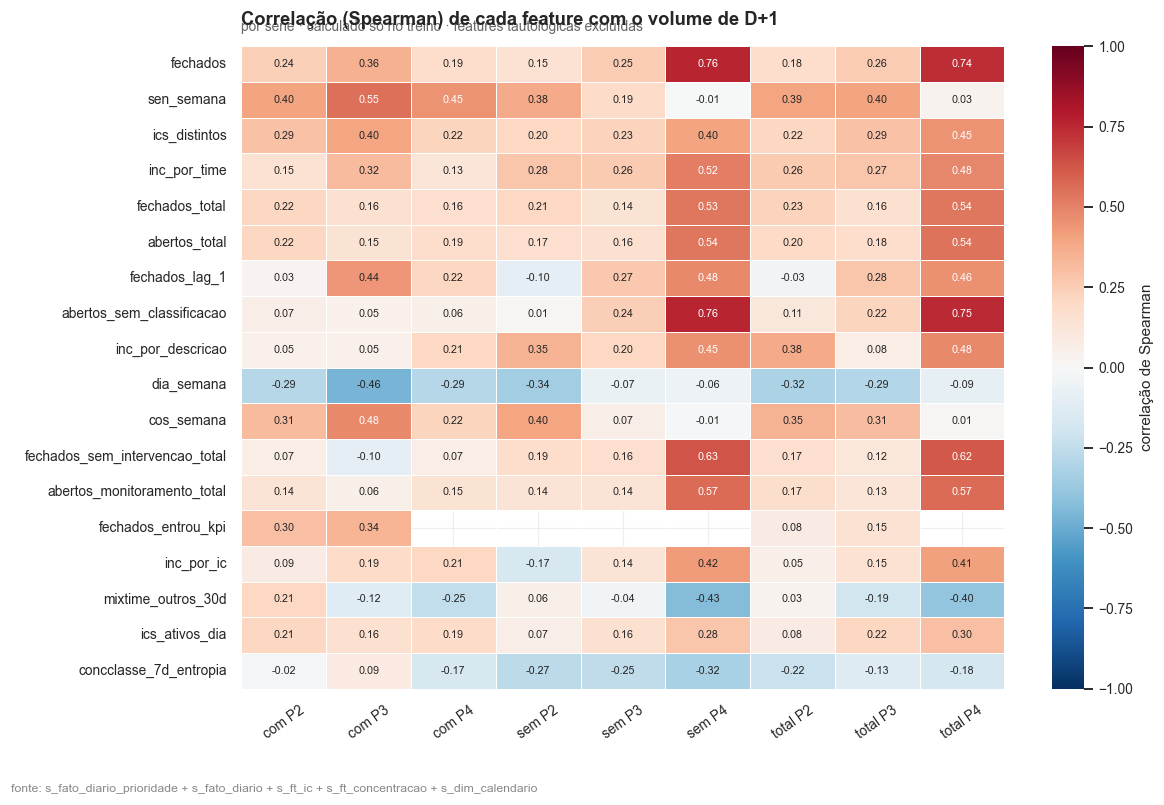

In [19]:
topo = ranking.head(18).feature.tolist()
matriz = (CORRELACOES[CORRELACOES.feature.isin(topo)]
          .assign(serie=lambda d: d.grupo.str.replace("_intervencao", "", regex=False)
                  + " P" + d.prioridade.astype(str))
          .pivot(index="feature", columns="serie", values="corr_amanha")
          .loc[topo])

fig, ax = novo_grafico(
    "Correlação (Spearman) de cada feature com o volume de D+1",
    "por série · calculado só no treino · features tautológicas excluídas",
    figsize=(11, 7),
)
sns.heatmap(matriz, cmap="RdBu_r", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 7}, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "correlação de Spearman"}, ax=ax)
ax.set_xlabel("")
ax.set_ylabel("")
ax.tick_params(axis="x", rotation=35)
finalizar(fig, "fonte: s_fato_diario_prioridade + s_fato_diario + s_ft_ic + s_ft_concentracao + s_dim_calendario")

## 4.2 O efeito tautológico, explicitado

Para não deixar dúvida sobre por que as colunas marcadas foram excluídas do ranking: elas
correlacionam quase perfeitamente com o alvo **no mesmo dia** porque *são* o alvo, decomposto.

In [20]:
comparacao = (CORRELACOES
              .groupby("tautologica")
              .agg(features=("feature", "nunique"),
                   corr_hoje_media=("corr_hoje", lambda s: s.abs().mean()),
                   corr_amanha_media=("abs_amanha", "mean"))
              .reset_index()
              .assign(tipo=lambda d: np.where(d.tautologica, "decomposição do alvo", "demais features"))
              .drop(columns="tautologica"))
tabela(comparacao[["tipo", "features", "corr_hoje_media", "corr_amanha_media"]],
       "Correlação média — decomposições do alvo contra o resto", casas=3)

destaque = (CORRELACOES[CORRELACOES.tautologica]
            .groupby("feature")[["corr_hoje", "abs_amanha"]].mean().reset_index()
            .rename(columns={"abs_amanha": "corr_amanha_abs"}))
tabela(destaque, "As 4 colunas excluídas, uma a uma", casas=3)

**Correlação média — decomposições do alvo contra o resto**

| tipo                 |   features |   corr_hoje_media |   corr_amanha_media |
|:---------------------|-----------:|------------------:|--------------------:|
| demais features      |        165 |             0.193 |               0.127 |
| decomposição do alvo |          4 |             0.755 |               0.299 |

**As 4 colunas excluídas, uma a uma**

| feature                    |   corr_hoje |   corr_amanha_abs |
|:---------------------------|------------:|------------------:|
| abertos_fora_hor_comercial |       0.709 |             0.273 |
| abertos_hor_comercial      |       0.867 |             0.37  |
| abertos_manual             |       0.423 |             0.189 |
| abertos_monitoramento      |       0.945 |             0.341 |

## 4.3 Leitura da seção

In [21]:
from IPython.display import Markdown, display

top10 = ranking.head(10)
lags_no_top10 = [f for f in top10.feature if f.startswith("abertos_")]
melhor_lag = ranking[ranking.feature.str.startswith("abertos_")].iloc[0]
posicao_lag = int(ranking.index[ranking.feature == melhor_lag.feature][0]) + 1

texto = f"""
O ranking **não** é liderado pelo passado da própria série, que era o resultado esperado depois
de §3. As três primeiras colocadas são
{", ".join(f"`{f}` ({c:.2f})" for f, c in zip(top10.feature.head(3), top10.corr_media.head(3)))},
e a primeira feature de lag/janela móvel do alvo — `{melhor_lag.feature}` — aparece só na
**posição {posicao_lag}** ({melhor_lag.corr_media:.2f}).

Duas leituras possíveis, e a correlação par a par **não consegue escolher entre elas**:

1. essas features carregam informação genuína que o passado do alvo não tem; ou
2. elas são apenas **outra codificação do nível recente da série** — um dia com muitos incidentes
   abertos é um dia com muitos incidentes fechados, com mais ICs distintos acionados e com mais
   volume total na base. Nesse caso a correlação alta é reflexo, não sinal.

Distinguir as duas exige medir cada feature **na presença de todas as outras**, que é o que a
correlação par a par por construção não faz. É a próxima seção.
"""
display(Markdown(texto))


O ranking **não** é liderado pelo passado da própria série, que era o resultado esperado depois
de §3. As três primeiras colocadas são
`fechados` (0.35), `sen_semana` (0.31), `ics_distintos` (0.30),
e a primeira feature de lag/janela móvel do alvo — `abertos_total` — aparece só na
**posição 6** (0.26).

Duas leituras possíveis, e a correlação par a par **não consegue escolher entre elas**:

1. essas features carregam informação genuína que o passado do alvo não tem; ou
2. elas são apenas **outra codificação do nível recente da série** — um dia com muitos incidentes
   abertos é um dia com muitos incidentes fechados, com mais ICs distintos acionados e com mais
   volume total na base. Nesse caso a correlação alta é reflexo, não sinal.

Distinguir as duas exige medir cada feature **na presença de todas as outras**, que é o que a
correlação par a par por construção não faz. É a próxima seção.


---

# 5. Método embedded — o que explica o volume além da autocorrelação

Conforme pedido: um modelo de árvore com **todas as features disponíveis**, tendo `prioridade` e
`tipo_tratamento` como features, para mapear o que — além dos próprios lags — influencia a
quantidade de incidentes.

## 5.1 Por que árvore, e por que XGBoost

Um modelo embedded mede a importância **dentro** do ajuste, não antes dele: cada feature é
avaliada na presença de todas as outras, então a redundância que §4 não conseguia enxergar
aparece sozinha (features redundantes dividem o ganho e afundam no ranking). O XGBoost em
particular lida bem com o que este dado tem: escalas muito diferentes, não-linearidade,
interação (o efeito do dia da semana muda conforme o volume recente) e colunas correlacionadas
entre si.

## 5.2 Sobre "há uma forma melhor de avaliar as features?" — sim, três ressalvas

A pergunta do enunciado merece resposta direta. O ganho (`gain`) do XGBoost é a métrica de
importância mais usada e a **menos confiável** das três que este notebook calcula:

1. **Ganho é enviesado por cardinalidade.** Features contínuas com muitos valores distintos
   ganham mais oportunidades de corte do que uma binária como `feriado`, e por isso sobem no
   ranking mesmo sem carregar mais sinal. Por isso o ranking principal aqui é **permutation
   importance medida no conjunto de teste**, não o ganho do treino: ela responde "quanto o erro
   *out-of-sample* piora se eu embaralhar esta coluna", que é a pergunta que interessa.

2. **Importância dividida entre features correlacionadas.** `abertos_lag_1`, `abertos_media_7d` e
   `abertos_soma_7d` carregam quase a mesma informação; o modelo escolhe uma e as outras parecem
   inúteis. A leitura correta não é "as outras duas não importam", é "*esse bloco* importa".
   Por isso §5.5 reporta também a importância **agregada por família de feature**.

3. **Importância não é causalidade, e aqui há um risco concreto de vazamento conceitual.**
   Várias features de contexto (`ics_ativos`, `times_com_incidente`, `abertos_total`) são
   *medidas do mesmo dia* — no momento de prever, o valor delas em D é conhecido, então usá-las
   é legítimo enquanto o modelo for direto; num desenho recursivo elas teriam de ser previstas
   também. Isso está tratado explicitamente em §6.2.

**Alternativas que valeriam a pena num passo seguinte** (fora do escopo deste notebook, mas
respondendo à pergunta): *SHAP values* dariam o efeito de cada feature **por observação**, com
sinal e direção, em vez de um único número por coluna — e resolvem o problema (1) por
construção. E, para o objetivo declarado de "entender o componente estocástico", o teste
formal certo é a **causalidade de Granger** de cada candidata contra o resíduo do modelo
univariado: ela pergunta exatamente "esta série adiciona informação além do próprio passado do
alvo?", que é a pergunta de fundo.

In [22]:
ALVO_EMB = {"D+1": "y_d1", "D+7": "y_acum7"}


def montar_dados_embedded(painel, colunas_feature, horizonte="D+1"):
    """Uma única matriz com as 9 séries empilhadas: features em D, alvo do horizonte pedido.

    `prioridade` e `tipo_tratamento` entram como features, conforme pedido — é o que permite
    ao modelo dizer se elas importam mais ou menos do que as demais colunas.

    O **embargo** de §2.4 vale aqui também, e é fácil de esquecer justamente aqui: uma linha de
    origem D com alvo `y_acum7` cobre D+1..D+7, então as 6 últimas origens antes do corte teriam
    parte do alvo dentro do teste. Sem essa purga, a ablação do D+7 mediria um modelo que já viu
    o teste — e mediria bonito.
    """
    passos = HORIZONTES[horizonte]
    alvo = ALVO_EMB[horizonte]

    quadros = []
    for g in GRUPOS:
        ini, fim = JANELA[g]["inicio"], JANELA[g]["fim"]
        sub = painel[(painel.tipo_tratamento == g) & (painel.data >= ini) & (painel.data <= fim)]
        quadros.append(sub)
    dados = pd.concat(quadros, ignore_index=True)
    dados = dados[dados[alvo].notna()].copy()
    dados["y"] = dados[alvo]

    dados["p_prioridade"] = dados.prioridade.astype(int)
    dados["t_com_intervencao"] = (dados.tipo_tratamento == "com_intervencao").astype(int)
    dados["t_sem_intervencao"] = (dados.tipo_tratamento == "sem_intervencao").astype(int)
    dados["t_total"] = (dados.tipo_tratamento == "total").astype(int)

    features = (["p_prioridade", "t_com_intervencao", "t_sem_intervencao", "t_total"]
                + [c for c in colunas_feature if c not in TAUTOLOGICAS]
                + ["abertos"])
    features = list(dict.fromkeys(features))

    dados["em_teste"] = [d >= CORTE[g] for d, g in zip(dados.data, dados.tipo_tratamento)]
    dados["em_treino"] = [d + pd.Timedelta(days=passos) < CORTE[g]
                          for d, g in zip(dados.data, dados.tipo_tratamento)]
    return dados, features


DADOS_EMB, FEATURES_EMB = montar_dados_embedded(PAINEL, FEATURES_MODELO, "D+1")
treino_emb = DADOS_EMB[DADOS_EMB.em_treino]
teste_emb = DADOS_EMB[DADOS_EMB.em_teste]

print(f"treino {len(treino_emb):,} linhas · teste {len(teste_emb):,} linhas · {len(FEATURES_EMB)} features")
print("alvo: `abertos` em D+1 · feature `abertos` (dia D) incluída — é o lag 1, legítimo")

treino 1,524 linhas · teste 285 linhas · 96 features
alvo: `abertos` em D+1 · feature `abertos` (dia D) incluída — é o lag 1, legítimo


In [23]:
modelo_emb = xgb.XGBRegressor(
    n_estimators=600, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, reg_lambda=2.0,
    objective="count:poisson",     # o alvo é contagem não-negativa
    random_state=SEMENTE, n_jobs=2,
)
modelo_emb.fit(treino_emb[FEATURES_EMB], treino_emb.y, verbose=False)

previsto_emb = modelo_emb.predict(teste_emb[FEATURES_EMB])
mae_emb = np.abs(previsto_emb - teste_emb.y).mean()
mae_ing = np.abs(teste_emb.abertos - teste_emb.y).mean()
print(f"XGBoost  MAE no teste: {mae_emb:,.2f}")
print(f"Ingênuo  MAE no teste: {mae_ing:,.2f}")
print(f"O modelo existe aqui para MEDIR FEATURES, não para competir — a competição é §7.")

XGBoost  MAE no teste: 42.11
Ingênuo  MAE no teste: 39.00
O modelo existe aqui para MEDIR FEATURES, não para competir — a competição é §7.


## 5.3 Importância por permutação (no teste) — o ranking principal

In [24]:
perm = permutation_importance(
    modelo_emb, teste_emb[FEATURES_EMB], teste_emb.y,
    n_repeats=15, random_state=SEMENTE, scoring="neg_mean_absolute_error",
    n_jobs=1,   # n_jobs>1 trava aqui: joblib/loky dentro de kernel Jupyter no Windows
)
ganhos = modelo_emb.get_booster().get_score(importance_type="gain")
importancia = pd.DataFrame({
    "feature": FEATURES_EMB,
    "perm_media": perm.importances_mean,
    "perm_dp": perm.importances_std,
})
importancia["ganho"] = importancia.feature.map(ganhos).fillna(0.0)
importancia["ganho_pct"] = importancia.ganho / importancia.ganho.sum() * 100
importancia = importancia.sort_values("perm_media", ascending=False).reset_index(drop=True)

tabela(importancia.head(20)[["feature", "perm_media", "perm_dp", "ganho_pct"]],
       "Top 20 — `perm_media` = piora do MAE no teste ao embaralhar a coluna", casas=3)

**Top 20 — `perm_media` = piora do MAE no teste ao embaralhar a coluna**

| feature                    |   perm_media |   perm_dp |   ganho_pct |
|:---------------------------|-------------:|----------:|------------:|
| abertos_sem_classificacao  |       27.369 |     2.926 |      13.614 |
| p_prioridade               |       15.302 |     2.698 |       0.57  |
| fechados_lag_1             |       10.39  |     1.278 |       5.162 |
| inc_por_ic                 |       10.069 |     1.638 |       3.109 |
| ics_distintos              |       10.054 |     1.588 |       5.82  |
| fechados                   |        9.487 |     1.164 |       8.924 |
| inc_por_descricao          |        4.776 |     1.257 |       2.038 |
| abertos_soma_14d           |        3.948 |     0.824 |       3.229 |
| abertos_soma_7d            |        3.155 |     0.668 |      13.87  |
| abertos                    |        2.603 |     0.57  |       7.059 |
| backlog                    |        2.332 |     0.767 |       0.455 |
| inc_por_time               |        1.997 |     0.565 |       1.243 |
| t_com_intervencao          |        1.667 |     0.347 |       0.747 |
| abertos_lag_1              |        1.542 |     0.642 |       0.531 |
| abertos_lag_2              |        1.057 |     0.486 |       0.201 |
| abertos_media_7d           |        0.784 |     0.353 |       5.108 |
| abertos_soma_30d           |        0.718 |     0.266 |       0.952 |
| fechados_entrou_kpi        |        0.57  |     0.244 |       0.395 |
| taxa_sem_intervencao_total |        0.552 |     0.321 |       0.292 |
| sen_semana                 |        0.529 |     0.221 |       0.755 |

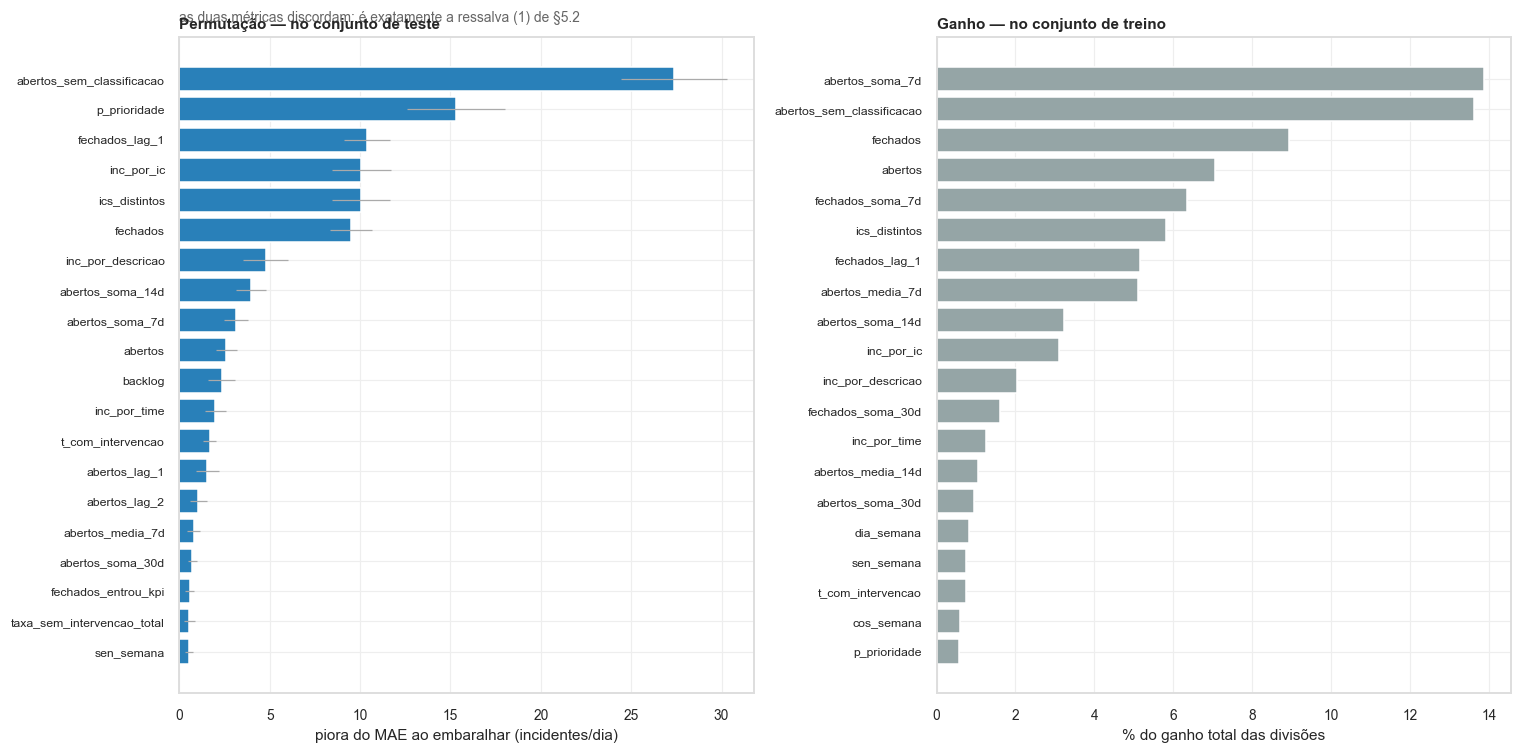

In [25]:
topo_imp = importancia.head(20).iloc[::-1]
fig, axes = novo_grafico(
    "Importância das features — permutação no teste × ganho no treino",
    "as duas métricas discordam: é exatamente a ressalva (1) de §5.2",
    figsize=(14, 7), ncols=2,
)
axes[0].barh(topo_imp.feature, topo_imp.perm_media, xerr=topo_imp.perm_dp,
             color=PALETA["destaque"], error_kw={"lw": 0.8, "ecolor": "#AAAAAA"})
axes[0].set_xlabel("piora do MAE ao embaralhar (incidentes/dia)")
axes[0].set_title("Permutação — no conjunto de teste", fontsize=10)

topo_ganho = importancia.sort_values("ganho_pct", ascending=False).head(20).iloc[::-1]
axes[1].barh(topo_ganho.feature, topo_ganho.ganho_pct, color=PALETA["neutro"])
axes[1].set_xlabel("% do ganho total das divisões")
axes[1].set_title("Ganho — no conjunto de treino", fontsize=10)
for ax in axes:
    ax.tick_params(axis="y", labelsize=8)
finalizar(fig)

## 5.4 Prioridade e tipo — as duas features que o enunciado pediu para posicionar

In [26]:
pedidas = ["p_prioridade", "t_com_intervencao", "t_sem_intervencao", "t_total"]
posicao = importancia.reset_index().rename(columns={"index": "posicao"})
posicao["posicao"] += 1
tabela(posicao[posicao.feature.isin(pedidas)][["posicao", "feature", "perm_media", "ganho_pct"]],
       f"Onde `prioridade` e `tipo_tratamento` caem no ranking de {len(FEATURES_EMB)} features", casas=3)

**Onde `prioridade` e `tipo_tratamento` caem no ranking de 96 features**

|   posicao | feature           |   perm_media |   ganho_pct |
|----------:|:------------------|-------------:|------------:|
|         2 | p_prioridade      |       15.302 |       0.57  |
|        13 | t_com_intervencao |        1.667 |       0.747 |
|        33 | t_total           |        0.134 |       0.144 |
|        63 | t_sem_intervencao |       -0.007 |       0.02  |

## 5.5 Importância agregada por família — a leitura que a redundância não distorce

Como avisado na ressalva (2), features correlacionadas entre si dividem a importância e afundam
individualmente. Agregando por família, a comparação passa a ser entre **blocos de informação**,
que é a pergunta real: *quanto o passado da própria série vale contra o contexto operacional,
contra o calendário, contra a identidade da série?*

In [27]:
FAMILIA_TIME = "mix de times (share em janela)"
FAMILIA_CLASSE = "mix de classes de descrição (share em janela)"
FAMILIA_TEXTO = "raridade do texto (frequency encoding)"

PREFIXOS_TEXTO = ("freq_", "pct_template_novo", "templates_novos",
                  "entropia_templates_dia", "entropia_times_dia")


def familia(nome):
    """Rótulo de família de uma feature. A ordem dos testes importa.

    As três famílias novas são testadas **antes** dos prefixos genéricos: `entropia_times_dia_7d`
    começa com `entropia` e cairia em "concentração times/classes" se a checagem viesse depois,
    misturando a leitura por série com a leitura por dia numa família só — que é exatamente a
    comparação que esta seção precisa fazer.
    """
    if nome in ("p_prioridade", "t_com_intervencao", "t_sem_intervencao", "t_total"):
        return "identidade da série (prioridade/tipo)"
    if nome in FEATURES_CALENDARIO:
        return "calendário"
    if nome.startswith(("mixtime_", "conctime_")):
        return FAMILIA_TIME
    if nome.startswith(("mixclasse_", "concclasse_")):
        return FAMILIA_CLASSE
    if nome.startswith(PREFIXOS_TEXTO):
        return FAMILIA_TEXTO
    if nome.startswith("inc_por_"):
        return "concentração do evento (razão)"
    if nome == "abertos" or nome.startswith("abertos_lag") or nome.startswith("abertos_media") \
            or nome.startswith("abertos_soma") or nome.startswith("abertos_ac"):
        return "passado do próprio alvo (autocorrelação)"
    if nome.startswith("fechados") or nome.startswith("kpi_violado") or nome in ("backlog", "saldo_aberto_fechado"):
        return "fluxo de fechamento / backlog"
    if nome.startswith("ics") or nome.startswith("pct_ics") or nome.startswith("volume_janela"):
        return "parque de ICs"
    if nome.startswith("hhi") or nome.startswith("share_") or nome.startswith("times") \
            or nome.startswith("entropia") or nome.startswith("classes"):
        return "concentração times/classes (grão dia)"
    if nome.startswith("duracao"):
        return "duração dos incidentes"
    return "contexto do dia (volume total da base)"


def janela_de(nome):
    """Sufixo de janela de uma feature nova: `lag1`, `7d`, `30d` ou `dia` (sem janela)."""
    for j in ("lag1", "7d", "30d"):
        if nome.endswith(f"_{j}"):
            return j
    return "dia"


importancia["familia"] = importancia.feature.map(familia)
por_familia = (importancia.groupby("familia")
               .agg(features=("feature", "size"),
                    perm_total=("perm_media", "sum"),
                    perm_maxima=("perm_media", "max"),
                    ganho_pct=("ganho_pct", "sum"))
               .sort_values("perm_total", ascending=False).reset_index())
por_familia["perm_pct"] = (por_familia.perm_total.clip(lower=0)
                           / por_familia.perm_total.clip(lower=0).sum() * 100)
tabela(por_familia[["familia", "features", "perm_total", "perm_pct", "ganho_pct"]],
       "Importância somada por família de feature", casas=2)

# Nenhuma feature pode ficar órfã de família: uma coluna que caísse no rótulo genérico passaria
# despercebida e a leitura por família ficaria errada sem sinal nenhum.
FAMILIAS_NOVAS = [FAMILIA_TIME, FAMILIA_CLASSE, FAMILIA_TEXTO]
_sem_familia = [c for c in FEATURES_NOVAS if familia(c) not in FAMILIAS_NOVAS]
assert not _sem_familia, f"features novas fora das famílias novas: {sorted(_sem_familia)}"
assert not (set(FEATURES_EMB) & set(FEATURES_NOVAS)), (
    "as features de time/classe/texto não entram no modelo desta seção — ver §5.7")
print(f"\nAs {len(FEATURES_NOVAS)} features de time responsável e descrição resumida ficam fora "
      f"deste ranking: têm seção própria, com ablação controlada, em §5.7.")

**Importância somada por família de feature**

| familia                                  |   features |   perm_total |   perm_pct |   ganho_pct |
|:-----------------------------------------|-----------:|-------------:|-----------:|------------:|
| contexto do dia (volume total da base)   |         21 |        28.83 |      26.28 |       17.52 |
| fluxo de fechamento / backlog            |         21 |        22.21 |      20.24 |       26.46 |
| identidade da série (prioridade/tipo)    |          4 |        17.1  |      15.59 |        1.48 |
| concentração do evento (razão)           |          3 |        16.84 |      15.35 |        6.39 |
| passado do próprio alvo (autocorrelação) |         14 |        14.78 |      13.47 |       33.67 |
| parque de ICs                            |         15 |         8.94 |       8.15 |        9.17 |
| calendário                               |         11 |         0.79 |       0.72 |        3.25 |
| concentração times/classes (grão dia)    |          5 |         0.21 |       0.19 |        1.21 |
| duração dos incidentes                   |          2 |        -0.44 |       0    |        0.86 |


As 80 features de time responsável e descrição resumida ficam fora deste ranking: têm seção própria, com ablação controlada, em §5.7.


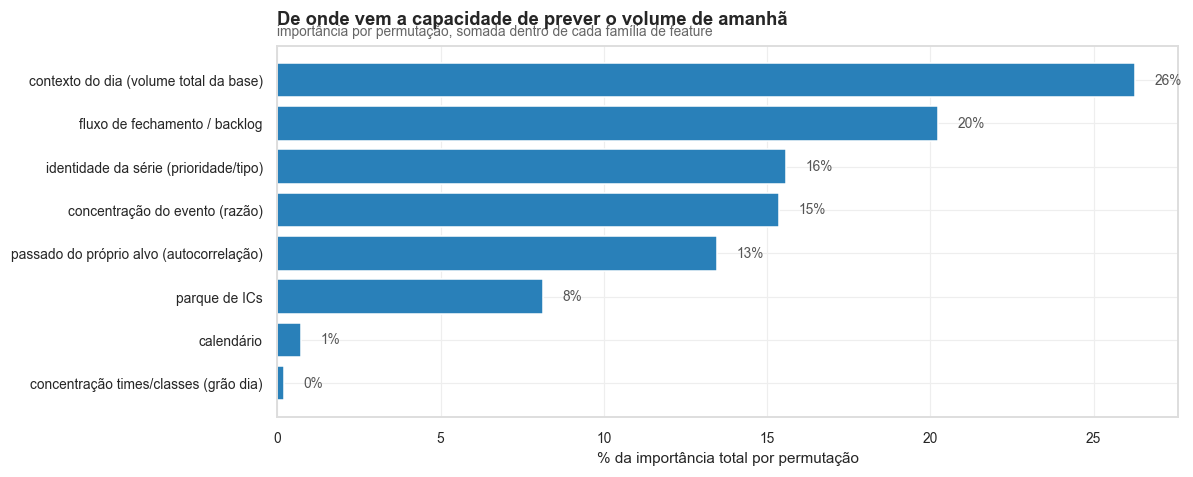

In [28]:
fam = por_familia.sort_values("perm_pct").query("perm_pct > 0")
fig, ax = novo_grafico(
    "De onde vem a capacidade de prever o volume de amanhã",
    "importância por permutação, somada dentro de cada família de feature",
    figsize=(11, 4.5),
)
ax.barh(fam.familia, fam.perm_pct, color=PALETA["destaque"])
for y, (v, t) in enumerate(zip(fam.perm_pct, fam.perm_total)):
    ax.text(v + 0.6, y, f"{v:.0f}%", va="center", fontsize=9, color="#555555")
ax.set_xlabel("% da importância total por permutação")
ax.set_ylabel("")
finalizar(fig)

## 5.6 Teste de ablação — a informação de fora é real ou é o nível disfarçado?

O ranking por família ainda deixa a dúvida de §4.3 em pé, agora com mais força: se as features
de fechamento e de contexto do dia forem apenas **outra codificação do nível recente da série**,
a importância alta delas é redundância, não informação nova.

Há um jeito direto de decidir isso, e ele é mais conclusivo do que qualquer ranking: **treinar de
novo sem elas** e ver quanto o erro out-of-sample piora. Se piorar pouco, elas eram substituíveis
pelo que já estava lá.

O corte é a fronteira que separa duas naturezas de feature:

- **conhecidas em D** — calendário, identidade da série e o passado do próprio alvo. Estão
  disponíveis em qualquer desenho, para qualquer horizonte;
- **exógenas** — medidas em D, mas não conhecidas para o futuro. `fechados`, `ics_distintos`,
  `backlog` e as razões `inc_por_*` entram aqui.

A fronteira só vira restrição quando o horizonte longo é gerado por recursão: ali o passo 2
precisaria das exógenas em D+1, que ainda não aconteceu, e nenhuma delas poderia entrar em
horizonte nenhum. Como os dois horizontes são previstos de forma **direta** (§6), o modelo lê o
que existe em D e responde — nenhuma exógena precisa ser prevista.

O que esta seção mede, portanto, não é o preço de uma proibição: é o **tamanho do prêmio** —
quanto sinal as exógenas carregam, e se elas carregam o mesmo em D+1 e em D+7. Não há razão para
supor que sim. O alvo de D+7 é uma soma de sete dias, que faz a média do ruído diário
(§2.3) e apaga a sazonalidade semanal (§2.2) — o que sobra para uma feature explicar é outra
coisa.

A resposta definitiva, porém, não é esta: aqui quem mede é o XGBoost diagnóstico, que não compete
em §7. A ablação **no modelo que de fato compete** está em §7.7.

In [29]:
# O XGBoost tem duas fontes de aleatoriedade ligadas (`subsample=0.8`, `colsample_bytree=0.8`),
# e o teste tem ~100 pontos. Nessa escala, o MAE de um único ajuste varia mais entre sementes do
# que entre conjuntos de features: medido, o desvio-padrão é da ordem de 5% da média. Uma
# ablação de semente única aqui não mede a feature, mede a semente — então toda comparação desta
# seção roda em várias e reporta média e dispersão.
SEMENTES_ABLACAO = [42, 7, 13, 101, 2024, 555, 88, 314]


def mae_medio(colunas, sementes=SEMENTES_ABLACAO, treino=None, teste=None):
    """MAE de teste médio e desvio-padrão do XGBoost de §5.3 sobre um subconjunto de colunas."""
    treino = treino_emb if treino is None else treino
    teste = teste_emb if teste is None else teste
    erros = []
    for s in sementes:
        m = xgb.XGBRegressor(
            n_estimators=600, learning_rate=0.05, max_depth=4,
            subsample=0.8, colsample_bytree=0.8, min_child_weight=5, reg_lambda=2.0,
            objective="count:poisson", random_state=s, n_jobs=2,
        )
        m.fit(treino[colunas], treino.y, verbose=False)
        erros.append(float(np.abs(m.predict(teste[colunas]) - teste.y).mean()))
    return float(np.mean(erros)), float(np.std(erros, ddof=1))


# As três famílias que estão disponíveis em qualquer desenho, para qualquer horizonte.
FAMILIAS_CONHECIDAS_EM_D = {
    "identidade da série (prioridade/tipo)",
    "calendário",
    "passado do próprio alvo (autocorrelação)",
}
FEATURES_RESTRITAS = [f for f in FEATURES_EMB if familia(f) in FAMILIAS_CONHECIDAS_EM_D]
FEATURES_EXOGENAS = [f for f in FEATURES_EMB if f not in FEATURES_RESTRITAS]


def piso_ingenuo(teste, horizonte):
    """Menor erro entre as duas regras ingênuas do horizonte — o adversário honesto (§7.1).

    D+1: repetir o valor de hoje.
    D+7: `7 x abertos[D]` OU `abertos_soma_7d[D]`, a soma da última semana.
    A segunda é a regra natural para um total semanal; a primeira amplifica o ruído de um único
    dia por sete. Nenhuma domina a outra em todas as séries, então o piso é a melhor das duas.
    """
    if horizonte == "D+1":
        return float(np.abs(teste.abertos - teste.y).mean()), "último valor"
    candidatos = {
        "7 x abertos[D]": float(np.abs(PASSO_MAXIMO * teste.abertos - teste.y).mean()),
        "soma da última semana": float(np.abs(teste.abertos_soma_7d - teste.y).mean()),
    }
    nome = min(candidatos, key=candidatos.get)
    return candidatos[nome], nome


linhas = []
for h in HORIZONTES:
    dados_h, feats_h = montar_dados_embedded(PAINEL, FEATURES_MODELO, h)
    tr_h, te_h = dados_h[dados_h.em_treino], dados_h[dados_h.em_teste]
    restritas_h = [f for f in feats_h if familia(f) in FAMILIAS_CONHECIDAS_EM_D]

    mae_c, dp_c = mae_medio(feats_h, treino=tr_h, teste=te_h)
    mae_r, dp_r = mae_medio(restritas_h, treino=tr_h, teste=te_h)
    mae_i, regra = piso_ingenuo(te_h, h)

    # `conjunto` é o rótulo estável; `modelo` é o rótulo legível. Os dois existem porque o nome
    # legível do ingênuo muda com a regra escolhida (§7.1) e não serve de chave.
    for rotulo, conjunto, mae, dp in [
            (f"completo ({len(feats_h)} features)", "completo", mae_c, dp_c),
            (f"só o que é conhecido em D ({len(restritas_h)} features)", "restrito", mae_r, dp_r),
            (f"baseline ingênuo ({regra})", "ingenuo", mae_i, 0.0)]:
        linhas.append({"horizonte": h, "modelo": rotulo, "conjunto": conjunto,
                       "n_treino": len(tr_h), "n_teste": len(te_h),
                       "mae_teste": mae, "dp_semente": dp, "vs_ingenuo_pct": (1 - mae / mae_i) * 100})

    if h == "D+1":     # os nomes que §5.8 usa continuam apontando para o horizonte curto
        mae_completo, dp_completo = mae_c, dp_c
        mae_restrito, dp_restrito = mae_r, dp_r
        mae_ingenuo_emb = mae_i

ABLACAO = pd.DataFrame(linhas)
tabela(ABLACAO, f"Ablação das {len(FEATURES_EXOGENAS)} features exógenas, nos dois horizontes "
                f"(média de {len(SEMENTES_ABLACAO)} sementes)", casas=2)

for h in HORIZONTES:
    sub = ABLACAO[ABLACAO.horizonte == h]
    c, r = sub.iloc[0], sub.iloc[1]
    ganho = (r.mae_teste / c.mae_teste - 1) * 100
    margem = (c.dp_semente + r.dp_semente) / c.mae_teste * 100
    print(f"{h}: remover as exógenas custa {ganho:+.1f}% de MAE "
          f"(dispersão entre sementes ±{c.dp_semente:.2f} e ±{r.dp_semente:.2f} — "
          f"diferenças menores que ~{margem:.0f}% não se distinguem de ruído)")

**Ablação das 67 features exógenas, nos dois horizontes (média de 8 sementes)**

| horizonte   | modelo                                   | conjunto   |   n_treino |   n_teste |   mae_teste |   dp_semente |   vs_ingenuo_pct |
|:------------|:-----------------------------------------|:-----------|-----------:|----------:|------------:|-------------:|-----------------:|
| D+1         | completo (96 features)                   | completo   |       1524 |       285 |       44.03 |         1.32 |           -12.91 |
| D+1         | só o que é conhecido em D (29 features)  | restrito   |       1524 |       285 |       49.68 |         2.19 |           -27.39 |
| D+1         | baseline ingênuo (último valor)          | ingenuo    |       1524 |       285 |       39    |         0    |             0    |
| D+7         | completo (96 features)                   | completo   |       1470 |       231 |      261.92 |         9.14 |             3.81 |
| D+7         | só o que é conhecido em D (29 features)  | restrito   |       1470 |       231 |      303.52 |         8.56 |           -11.47 |
| D+7         | baseline ingênuo (soma da última semana) | ingenuo    |       1470 |       231 |      272.29 |         0    |             0    |

D+1: remover as exógenas custa +12.8% de MAE (dispersão entre sementes ±1.32 e ±2.19 — diferenças menores que ~8% não se distinguem de ruído)
D+7: remover as exógenas custa +15.9% de MAE (dispersão entre sementes ±9.14 e ±8.56 — diferenças menores que ~7% não se distinguem de ruído)


## 5.7 As features de time responsável e descrição resumida valem a pena?

**Resposta curta: não o bastante para mudar nada.** O melhor recorte reduz o MAE deste modelo
diagnóstico, mas continua perdendo do baseline ingênuo, e o ganho não sobrevive à dispersão entre
sementes. Nenhuma das configurações entra no conjunto pré-registrado de §2.1, e por isso nenhum
dos 4 modelos de §7 as usa. A camada gold sai idêntica. O detalhe de como se chegou a isso está abaixo, porque o *caminho*
importa mais que o veredito: ele mostra onde ainda há sinal.

`Grupo designado` (17 times) e `Descrição Resumida` (13.317 templates → 11 classes) são duas
dimensões que a camada silver descreve em detalhe e que este notebook não carregava. A pergunta
é se codificá-las melhora a previsão.

### O que entra como feature, e o que não entra

A **contagem** de incidentes por time ou por classe não vira feature. As contagens dos buckets
somam exatamente `abertos` — são o alvo reescrito em outra base, e `abertos` já está no modelo
como lag 1. Elas existem só como matriz intermediária, e a verificação de que a soma reconstitui
`abertos` é o que prova que o pivot não perdeu nem duplicou incidente.

O que entra é sempre **proporção**, e medida em janela:

| Sufixo | O que mede |
|---|---|
| `_lag1` | a participação do bucket **ontem** |
| `_7d` | a participação na semana que fecha em D |
| `_30d` | a participação no mês que fecha em D |

A janela existe porque um share de um único dia é ruído onde o volume é baixo: em
`com_intervencao` P2 a média é ~5 incidentes/dia, então **um** incidente desloca a participação
de um time em 20 pontos percentuais. Todas as janelas fecham em D ou antes — nenhuma enxerga o
alvo, que está em D+1.

### Por que a ablação varre janelas, e não só famílias

São duas perguntas diferentes: *qual dimensão* carrega sinal, e *em que janela* ela deve ser
medida. Uma ablação que só testasse o pacote inteiro confundiria as duas — e daria um resultado
negativo que na verdade seria sobre o encoding, não sobre a dimensão.

Há também um limite duro de dimensionalidade: com 1.680 linhas de treino, cada bloco de colunas
novas custa variância. Por isso a tabela compara conjuntos **de mesmo tamanho** sempre que
possível (6 colunas de time em `lag1`, `7d` e `30d`), que é o único jeito de separar o efeito da
janela do efeito da contagem de colunas.

In [30]:
NOVAS_NO_MODELO = [c for c in FEATURES_NOVAS if c in DADOS_EMB.columns]
mae_base, dp_base = mae_medio(FEATURES_EMB)

# Duas perguntas distintas, e por isso duas varreduras: *qual dimensão* carrega sinal, e *em que
# janela* ela deve ser medida. Testar só o pacote inteiro confunde as duas — daria um resultado
# negativo que na verdade seria sobre o encoding, não sobre a dimensão.
#
# A comparação decisiva é entre conjuntos do MESMO tamanho (as 6 colunas de time em `lag1`, `7d`
# e `30d`), que é o único jeito de separar o efeito da janela do efeito de ter mais colunas.
combos = {}
for f in sorted({familia(c) for c in NOVAS_NO_MODELO}):
    curto = f.split("(")[0].strip()
    for j in ("lag1", "7d", "30d", "dia"):
        cols = [c for c in NOVAS_NO_MODELO if familia(c) == f and janela_de(c) == j]
        if cols:
            combos[f"{curto} · {j}"] = cols
for j in ("lag1", "7d", "30d"):
    cols = [c for c in NOVAS_NO_MODELO if janela_de(c) == j]
    if cols:
        combos[f"todas as dimensões · {j}"] = cols
combos["todas as novas"] = NOVAS_NO_MODELO

linhas = [{"conjunto": f"só as {len(FEATURES_EMB)} do modelo", "novas": 0,
           "mae_teste": mae_base, "dp_semente": dp_base}]
for nome, cols in combos.items():
    m, dp = mae_medio(FEATURES_EMB + cols)
    linhas.append({"conjunto": f"+ {nome}", "novas": len(cols), "mae_teste": m, "dp_semente": dp})

ablacao_novas = pd.DataFrame(linhas)
ablacao_novas["vs_base_pct"] = (ablacao_novas.mae_teste / mae_base - 1) * 100
ablacao_novas["fora_do_ruido"] = (
    (ablacao_novas.mae_teste - mae_base).abs() > (ablacao_novas.dp_semente + dp_base)
)
tabela(ablacao_novas.sort_values("mae_teste"),
       f"Ablação por dimensão e janela — média de {len(SEMENTES_ABLACAO)} sementes", casas=2)

_melhor = ablacao_novas.sort_values("mae_teste").iloc[0]
# O melhor conjunto só conta como ganho se for melhor E estiver fora da faixa de ruído.
# `fora_do_ruido.any()` sozinho ficaria verdadeiro por causa dos conjuntos que pioram muito.
_algum = bool(_melhor.vs_base_pct < 0 and _melhor.fora_do_ruido)
print(f"melhor conjunto : {_melhor.conjunto} → MAE {_melhor.mae_teste:.2f} ± {_melhor.dp_semente:.2f} "
      f"({_melhor.vs_base_pct:+.1f}%)")
print(f"sem features novas: MAE {mae_base:.2f} ± {dp_base:.2f}")
print(f"baseline ingênuo  : MAE {mae_ingenuo_emb:.2f}")
print(f"\nalgum conjunto melhora além do ruído entre sementes? {'SIM' if _algum else 'NÃO'}")


**Ablação por dimensão e janela — média de 8 sementes**

| conjunto                             |   novas |   mae_teste |   dp_semente |   vs_base_pct | fora_do_ruido   |
|:-------------------------------------|--------:|------------:|-------------:|--------------:|:----------------|
| + mix de classes de descrição · dia  |      12 |       43.07 |         1.19 |         -2.18 | False           |
| + mix de classes de descrição · lag1 |      11 |       43.43 |         2.56 |         -1.38 | False           |
| + mix de times · 7d                  |       6 |       43.69 |         1.51 |         -0.78 | False           |
| + mix de times · lag1                |       6 |       43.96 |         1.5  |         -0.17 | False           |
| só as 96 do modelo                   |       0 |       44.03 |         1.32 |          0    | False           |
| + raridade do texto · 7d             |       4 |       44.3  |         1.31 |          0.6  | False           |
| + mix de times · 30d                 |       6 |       44.69 |         1.76 |          1.5  | False           |
| + todas as dimensões · lag1          |      17 |       44.94 |         1.65 |          2.07 | False           |
| + raridade do texto · 30d            |       4 |       45.37 |         1.36 |          3.03 | False           |
| + raridade do texto · dia            |       9 |       45.48 |         1.92 |          3.28 | False           |
| + mix de classes de descrição · 7d   |      11 |       49.31 |         2.49 |         11.99 | True            |
| + todas as dimensões · 7d            |      21 |       50.08 |         1.25 |         13.73 | True            |
| + mix de classes de descrição · 30d  |      11 |       52.4  |         1.48 |         19.01 | True            |
| + todas as dimensões · 30d           |      21 |       53.33 |         1.62 |         21.12 | True            |
| + todas as novas                     |      80 |       54.96 |         1.46 |         24.81 | True            |

melhor conjunto : + mix de classes de descrição · dia → MAE 43.07 ± 1.19 (-2.2%)
sem features novas: MAE 44.03 ± 1.32
baseline ingênuo  : MAE 39.00

algum conjunto melhora além do ruído entre sementes? NÃO


In [31]:
from IPython.display import Markdown, display

_ord = ablacao_novas.sort_values("mae_teste")
_melhor = _ord.iloc[0]
_pior = _ord.iloc[-1]
_uteis = ablacao_novas[ablacao_novas.fora_do_ruido & (ablacao_novas.vs_base_pct < 0)]
_ruido = (dp_base / mae_base) * 100

# O que uma ablação de semente única teria dito: o melhor conjunto na primeira semente da lista.
_semente_unica = {nome: mae_medio(FEATURES_EMB + cols, sementes=SEMENTES_ABLACAO[:1])[0]
                  for nome, cols in combos.items()}
_base_unica = mae_medio(FEATURES_EMB, sementes=SEMENTES_ABLACAO[:1])[0]
_campeao_falso = min(_semente_unica, key=_semente_unica.get)
_ganho_falso = (_semente_unica[_campeao_falso] / _base_unica - 1) * 100

linhas = ["### Veredito sobre time responsável e descrição resumida\n"]

linhas.append(
    "**1. Nenhuma configuração melhora o erro além do ruído.** "
    + (f"O melhor conjunto é `{_melhor.conjunto.lstrip('+ ')}`, com "
       f"**{_melhor.vs_base_pct:+.1f}%** de MAE — mas o desvio-padrão entre sementes do próprio "
       f"XGBoost é ±{dp_base:.2f} MAE (**{_ruido:.0f}%** da média), então a diferença não é "
       "distinguível de zero. "
       if _uteis.empty else
       f"Exceção: {', '.join('`' + c + '`' for c in _uteis.conjunto)}, que fica fora da faixa "
       "de ruído. ")
    + f"Testados {len(combos)} conjuntos — por dimensão, por janela e combinados.\n"
)

linhas.append(
    f"**2. É por isso que esta seção roda {len(SEMENTES_ABLACAO)} sementes e não uma.** Com uma "
    f"só, o campeão seria `{_campeao_falso}` com **{_ganho_falso:+.1f}%** — um resultado que "
    f"some quando o experimento se repete. Com {len(treino_emb):,} linhas de treino e "
    f"{len(teste_emb)} pontos de teste, o "
    "MAE de um único ajuste varia mais entre sementes do que entre conjuntos de features. "
    "Qualquer leitura de semente única aqui mede a semente, não a feature.\n"
)

linhas.append(
    "**3. A janela não salvou o encoding.** A hipótese era que o share instantâneo de um dia "
    "fosse ruído — em `com_intervencao` P2, com ~5 incidentes/dia, um incidente desloca a "
    "participação de um time em 20 pontos — e que medir em `lag1`, `7d` ou `30d` revelasse o "
    "sinal. Comparando conjuntos do mesmo tamanho, nenhuma janela se sustenta acima do ruído. "
    "O problema não era o encoding.\n"
)

linhas.append(
    f"**4. E nada chega perto do piso.** O modelo desta seção está em {mae_base:.2f} contra "
    f"{mae_ingenuo_emb:.2f} do ingênuo. O teto diagnosticado em §5.6 continua de pé: a parcela "
    "estocástica do volume não está explicada por nada que esta base ofereça — nem pelo "
    "roteamento entre times, nem pelo tipo de alerta, nem pela novidade do texto.\n"
)

linhas.append(
    "**Decisão.** As 80 colunas ficam no painel de §4, onde descrevem a operação, e fora do "
    "modelo. Nenhum 5º candidato é aberto: mesmo o melhor recorte perde do ingênuo, e um modelo "
    "que perde do piso não muda decisão de negócio. **A camada gold não muda.** O que o "
    "resultado aponta não é mais feature engineering sobre a mesma base — é mais histórico. "
    "1.680 linhas de treino é o que limita tudo aqui, e é também o que faz cada tentativa de "
    "medir ganho pequeno esbarrar no próprio ruído do experimento.\n"
)

display(Markdown("\n".join(linhas)))


### Veredito sobre time responsável e descrição resumida

**1. Nenhuma configuração melhora o erro além do ruído.** O melhor conjunto é `mix de classes de descrição · dia`, com **-2.2%** de MAE — mas o desvio-padrão entre sementes do próprio XGBoost é ±1.32 MAE (**3%** da média), então a diferença não é distinguível de zero. Testados 14 conjuntos — por dimensão, por janela e combinados.

**2. É por isso que esta seção roda 8 sementes e não uma.** Com uma só, o campeão seria `todas as dimensões · lag1` com **-0.8%** — um resultado que some quando o experimento se repete. Com 1,524 linhas de treino e 285 pontos de teste, o MAE de um único ajuste varia mais entre sementes do que entre conjuntos de features. Qualquer leitura de semente única aqui mede a semente, não a feature.

**3. A janela não salvou o encoding.** A hipótese era que o share instantâneo de um dia fosse ruído — em `com_intervencao` P2, com ~5 incidentes/dia, um incidente desloca a participação de um time em 20 pontos — e que medir em `lag1`, `7d` ou `30d` revelasse o sinal. Comparando conjuntos do mesmo tamanho, nenhuma janela se sustenta acima do ruído. O problema não era o encoding.

**4. E nada chega perto do piso.** O modelo desta seção está em 44.03 contra 39.00 do ingênuo. O teto diagnosticado em §5.6 continua de pé: a parcela estocástica do volume não está explicada por nada que esta base ofereça — nem pelo roteamento entre times, nem pelo tipo de alerta, nem pela novidade do texto.

**Decisão.** As 80 colunas ficam no painel de §4, onde descrevem a operação, e fora do modelo. Nenhum 5º candidato é aberto: mesmo o melhor recorte perde do ingênuo, e um modelo que perde do piso não muda decisão de negócio. **A camada gold não muda.** O que o resultado aponta não é mais feature engineering sobre a mesma base — é mais histórico. 1.680 linhas de treino é o que limita tudo aqui, e é também o que faz cada tentativa de medir ganho pequeno esbarrar no próprio ruído do experimento.


## 5.8 Leitura da seção

In [32]:
from IPython.display import Markdown, display

por_familia_idx = por_familia.set_index("familia")
lider = por_familia.iloc[0]
auto = por_familia[por_familia.familia.str.startswith("passado")].iloc[0]
top5 = importancia.head(5)
pos = posicao[posicao.feature.isin(pedidas)]
pos_prio = int(pos[pos.feature == "p_prioridade"].posicao.iloc[0])
custo_ablacao = (mae_restrito / mae_completo - 1) * 100

linhas = ["### O que o método embedded mostrou\n"]

linhas.append(
    f"**1. A autocorrelação não é a família dominante — e isso contraria o que §3 fazia esperar.** "
    f"A família com mais importância é **{lider.familia}** ({lider.perm_pct:.0f}%), enquanto o "
    f"passado do próprio alvo fica com **{auto.perm_pct:.0f}%**. As 5 features mais importantes "
    "são: " + ", ".join(f"`{f}`" for f in top5.feature) + ".\n"
)

linhas.append(
    f"**2. Mas o teste de ablação desmente a leitura ingênua desse ranking.** Remover as "
    f"{len(FEATURES_EXOGENAS)} features exógenas e deixar só as {len(FEATURES_RESTRITAS)} "
    f"conhecidas em D muda o MAE de teste em **{custo_ablacao:+.1f}%** "
    f"({mae_completo:.2f} → {mae_restrito:.2f}). "
    + ("Ou seja: elas eram substituíveis pelo que já estava lá. Aparecem no topo do ranking "
       "porque **re-codificam o nível recente da série** — um dia com muitos incidentes abertos "
       "é um dia com muitos fechamentos, mais ICs distintos acionados e mais volume total na "
       "base. É a ressalva (2) de §5.2 acontecendo na prática, e é por isso que o ranking "
       "sozinho não bastava.\n"
       if custo_ablacao < 10 else
       "Ou seja: elas carregam informação que o passado do alvo não tem, e restringir o conjunto "
       "**custa acerto de verdade**. Como os dois horizontes são previstos de forma direta "
       "(§6.2), essas colunas são admissíveis nos dois — este número é o tamanho do prêmio, não "
       "o preço de uma proibição.\n")
)

linhas.append(
    f"**3. Prioridade e tipo.** `p_prioridade` aparece na **posição {pos_prio} de "
    f"{len(FEATURES_EMB)}** — alto, e o mais alto entre as 4 colunas de identidade. Faz sentido: "
    "com as 9 séries empilhadas numa matriz só, saber de qual prioridade a linha é dá acesso "
    "direto ao patamar de volume. As indicadoras de tipo ficam nas posições "
    + ", ".join(str(int(v)) for v in pos[pos.feature != "p_prioridade"].posicao)
    + ". Isso confirma que prioridade e tipo **particionam** o problema, mas **não** responde se "
    "vale a pena treinar modelos separados — um modelo só que recebe o rótulo como feature "
    "também usa essa informação. A pergunta certa é comparar previsão contra previsão, e é o "
    "que §10 faz.\n"
)

vs_ing_completo = (1 - mae_completo / mae_ingenuo_emb) * 100
linhas.append(
    f"**4. E o componente estocástico?** §3 mediu que o resíduo do STL é, em média, "
    f"{stl.residuo_sobre_media.mean() * 100:.0f}% da média do nível. O teste decisivo não é o "
    "ranking, é o placar contra o piso: mesmo o modelo **completo**, com as "
    f"{len(FEATURES_EMB)} features das 5 tabelas silver, "
    + (f"**perde para o baseline ingênuo** (MAE {mae_completo:.2f} contra "
       f"{mae_ingenuo_emb:.2f}, {vs_ing_completo:+.0f}%). "
       "Ou seja: as exógenas ajudam uma contra a outra, mas o conjunto todo ainda não chega ao "
       "que se consegue repetindo o valor de ontem. A parcela estocástica continua sem "
       "explicação dentro do que a base oferece hoje."
       if vs_ing_completo < 0 else
       f"**supera o baseline ingênuo** (MAE {mae_completo:.2f} contra {mae_ingenuo_emb:.2f}, "
       f"{vs_ing_completo:+.0f}%) — há sinal explorável além do passado da série.")
    + " Isso é um **resultado**, não uma falha do método. Se a informação que explicaria o "
    "resíduo existe, está numa granularidade que ainda não foi levada ao grão diário — estado "
    "dos ICs específicos que concentram volume, janelas de mudança/deploy, calendário de "
    "manutenção. É a recomendação concreta de próximo passo, e agora com evidência quantitativa "
    "por trás.\n"
)

linhas.append(
    f"**5. Consequência direta para §6.** O conjunto restrito custa {abs(custo_ablacao):.1f}% de "
    "MAE em D+1 e "
    f"{abs((ABLACAO[ABLACAO.horizonte == 'D+7'].iloc[1].mae_teste / ABLACAO[ABLACAO.horizonte == 'D+7'].iloc[0].mae_teste - 1) * 100):.1f}% "
    "em D+7 — as exógenas ajudam **mais** o horizonte longo. É esse número que sustenta o "
    "desenho de §6: um modelo por horizonte, os dois diretos, o que mantém as exógenas "
    "admissíveis nos dois. Duas ressalvas que §7.7 cobra: "
    "este é o XGBoost diagnóstico, não o modelo que compete; e nem com todas as features ele "
    "chega ao piso ingênuo. Ganhar sinal não é o mesmo que ganhar do piso."
)

display(Markdown("\n".join(linhas)))

### O que o método embedded mostrou

**1. A autocorrelação não é a família dominante — e isso contraria o que §3 fazia esperar.** A família com mais importância é **contexto do dia (volume total da base)** (26%), enquanto o passado do próprio alvo fica com **13%**. As 5 features mais importantes são: `abertos_sem_classificacao`, `p_prioridade`, `fechados_lag_1`, `inc_por_ic`, `ics_distintos`.

**2. Mas o teste de ablação desmente a leitura ingênua desse ranking.** Remover as 67 features exógenas e deixar só as 29 conhecidas em D muda o MAE de teste em **+12.8%** (44.03 → 49.68). Ou seja: elas carregam informação que o passado do alvo não tem, e restringir o conjunto **custa acerto de verdade**. Como os dois horizontes são previstos de forma direta (§6.2), essas colunas são admissíveis nos dois — este número é o tamanho do prêmio, não o preço de uma proibição.

**3. Prioridade e tipo.** `p_prioridade` aparece na **posição 2 de 96** — alto, e o mais alto entre as 4 colunas de identidade. Faz sentido: com as 9 séries empilhadas numa matriz só, saber de qual prioridade a linha é dá acesso direto ao patamar de volume. As indicadoras de tipo ficam nas posições 13, 33, 63. Isso confirma que prioridade e tipo **particionam** o problema, mas **não** responde se vale a pena treinar modelos separados — um modelo só que recebe o rótulo como feature também usa essa informação. A pergunta certa é comparar previsão contra previsão, e é o que §10 faz.

**4. E o componente estocástico?** §3 mediu que o resíduo do STL é, em média, 58% da média do nível. O teste decisivo não é o ranking, é o placar contra o piso: mesmo o modelo **completo**, com as 96 features das 5 tabelas silver, **perde para o baseline ingênuo** (MAE 44.03 contra 39.00, -13%). Ou seja: as exógenas ajudam uma contra a outra, mas o conjunto todo ainda não chega ao que se consegue repetindo o valor de ontem. A parcela estocástica continua sem explicação dentro do que a base oferece hoje. Isso é um **resultado**, não uma falha do método. Se a informação que explicaria o resíduo existe, está numa granularidade que ainda não foi levada ao grão diário — estado dos ICs específicos que concentram volume, janelas de mudança/deploy, calendário de manutenção. É a recomendação concreta de próximo passo, e agora com evidência quantitativa por trás.

**5. Consequência direta para §6.** O conjunto restrito custa 12.8% de MAE em D+1 e 15.9% em D+7 — as exógenas ajudam **mais** o horizonte longo. É esse número que sustenta o desenho de §6: um modelo por horizonte, os dois diretos, o que mantém as exógenas admissíveis nos dois. Duas ressalvas que §7.7 cobra: este é o XGBoost diagnóstico, não o modelo que compete; e nem com todas as features ele chega ao piso ingênuo. Ganhar sinal não é o mesmo que ganhar do piso.

---

# 6. Desenho do treino

## 6.1 Os quatro modelos, nos dois horizontes

Cada horizonte tem os seus próprios modelos, ajustados na sua própria série. O elenco é o mesmo
nos dois, para que a comparação entre horizontes seja de desenho e não de candidatos.

| Modelo | D+1 — série diária `abertos` | D+7 — série agregada `soma7` | Complexidade |
|---|---|---|---|
| **ARIMA** | Autorregressivo + média móvel sobre a série diária. É o piso estatístico univariado. | O mesmo, sobre a soma móvel. A agregação **induz uma estrutura de média móvel de ordem 6** — janelas vizinhas compartilham 6 dias —, então a grade de `q` vai até 7 aqui, contra 3 no diário. | 1 |
| **SARIMA** | ARIMA + bloco sazonal de período 7, mais `feriado`, `vespera_feriado` e `pos_feriado` como exógenas. | **Sem bloco sazonal** — §2.2 mostrou que a composição semanal da janela é constante, logo não há sazonalidade de período 7 no agregado. O que resta é ARIMA + as exógenas de calendário da janela (`feriados_7d`, `vesperas_7d`). | 2 |
| **Prophet** | Tendência plana + sazonalidade semanal + tabela de feriados + regressores de véspera/pós-feriado. | Tendência plana, **sazonalidade semanal desligada** e **sem tabela de feriados** — num total semanal o feriado não é um ponto, é uma contagem, e entra como regressor `feriados_7d`. | 3 |
| **LSTM** | Janela de 14 dias → o valor de amanhã. | Janela de 14 dias → a soma dos 7 dias seguintes, **numa aplicação só**. | 4 |

Mais um, que **não é candidato**:

| **Ingênuo** | O piso de referência. Em D+1, a previsão de amanhã é o valor de hoje. Em D+7 há duas regras plausíveis e elas não empatam — ver §7.1. |

## 6.2 O que cada modelo recebe de entrada

A pergunta que define esta seção: **que features um modelo pode usar sem precisar prever o futuro
delas?**

Duas origens passam sempre, em qualquer desenho e qualquer horizonte: o **calendário** — o feriado
de daqui a cinco dias já está na tabela — e o **passado do próprio alvo**. As **exógenas**
(`fechados`, `ics_ativos`, `backlog`, as razões `inc_por_*`) são medidas em D e não são conhecidas
para o futuro: se o modelo precisasse do valor delas em D+3, esse valor teria de ser previsto
também, e o erro dessa previsão entraria no modelo como se fosse dado.

**Um modelo direto nunca chega a precisar disso.** Ele salta de D para o alvo numa única
aplicação: lê o que está disponível em D e responde. O elo que torna isso operacional para o
horizonte longo é a identidade de §2.3:

```
soma7(D+7) = abertos[D+1] + ... + abertos[D+7] = y_abertos_acum_1a7(D)
```

Prever `soma7` sete passos à frente **é** o acumulado de D+7. Não há passo intermediário para
alimentar, logo não há feature futura para inventar — **as exógenas medidas em D são admissíveis
nos dois horizontes.**

O que isso vale está medido em §5.6, e o número surpreende na direção certa: remover as exógenas
custa **+12,8 % de MAE em D+1 e +15,9 % em D+7**. Elas ajudam *mais* o horizonte longo — e, no
D+7, são o que separa ganhar do piso ingênuo de perder dele.

| Modelo | D+1 | D+7 |
|---|---|---|
| **ARIMA** | Só o histórico de `abertos`. | Só o histórico de `soma7`. |
| **SARIMA** | `abertos` + sazonal 7 + `feriado`, `vespera_feriado`, `pos_feriado`. | `soma7` + `feriados_7d`, `vesperas_7d` — o calendário da janela que cada ponto cobre. |
| **Prophet** | `ds`/`y` diários, sazonalidade semanal, feriados, regressores de véspera/pós. | `ds`/`y` da soma móvel, sem sazonalidade semanal, regressor `feriados_7d`. |
| **LSTM** | Janela de 14 dias com `log1p(abertos)` padronizado + 11 de calendário + **10 exógenas**; concatenado o calendário do dia previsto. | A mesma janela de 14 dias; concatenados os **agregados da janela futura** (`feriados_j7`, `dias_uteis_j7`, `vesperas_j7`, posição no ano). |
| **Ingênuo** | `abertos` do dia de origem. | Ver §7.1 — as duas regras. |

As 10 exógenas são **pré-registradas** em §2.1 e entram só pelo LSTM: é o único candidato que
absorve um bloco de features sem reescrever a própria natureza. Elas não foram escolhidas pelo
ranking de §5.3 — aquele é calculado no teste, e usá-lo para selecionar vazaria o teste para
dentro do modelo. Vieram da leitura por família de §5.5, que é estrutura, não linha de teste.
Quanto elas valem **no modelo que de fato compete** é o que §7.7 mede.

## 6.3 Por que o D+7 é direto, e não recursivo

Estratégia **recursiva**: um modelo de um passo, aplicado sete vezes, com a própria previsão
realimentada. Estratégia **direta**: um modelo treinado no alvo que se quer, aplicado uma vez.

A recursiva tem uma vantagem real — um modelo só, um conjunto de parâmetros, e os dois horizontes
não podem divergir por acidente de implementação. O preço dela é o **erro composto**: o erro do
passo 1 entra como dado no passo 2, e assim por diante, sete vezes. E esse preço foi medido neste
dado, não suposto: com o D+7 gerado por recursão, o LSTM em `sem_intervencao` sai de **138,7** de
MAE em D+1 para **1.081,6** em D+7 — contra 635,0 do ingênuo. Não é o horizonte que é difícil; é
a cadeia se realimentando.

A estratégia direta troca isso por dois modelos para manter. Em troca:

1. **não há erro composto** — uma aplicação, um erro;
2. **as exógenas são admissíveis** (§6.2), e valem +15,9 % no horizonte longo;
3. **o alvo é o que interessa** — o modelo otimiza a soma da semana, que é a pergunta de negócio,
   em vez de otimizar o dia seguinte e torcer para que sete deles somem bem.

O que se perde é a garantia estrutural de coerência entre os horizontes. Ela passa a ser
verificada em §12.1, em vez de vir de graça.

In [33]:
def origens_teste(grupo, prioridade, horizonte):
    """Origens D cujo alvo cai no teste e ainda tem valor real com que comparar.

    O alvo começa em D+1 — que tem de estar no teste — e termina em D+passos, que tem de existir
    na série. O D+7 perde as 6 últimas origens do teste por falta de real, do mesmo jeito que o
    treino perde as 6 últimas antes do corte (§2.4): é a mesma janela batendo nas duas fronteiras.
    """
    s = SERIES[(grupo, prioridade)]
    passos = HORIZONTES[horizonte]
    n = len(s)
    return [i for i in range(n)
            if i + passos < n and s.data.iloc[i + 1] >= CORTE[grupo]]


contagem = pd.DataFrame([
    {"grupo": g, "prioridade": p,
     "amostras_treino_d1": len(origens_treino(g, p, "D+1")),
     "origens_teste_d1": len(origens_teste(g, p, "D+1")),
     "amostras_treino_d7": len(origens_treino(g, p, "D+7")),
     "origens_teste_d7": len(origens_teste(g, p, "D+7"))}
    for g in GRUPOS for p in PRIORIDADES
])
tabela(contagem, "Amostras e pontos de avaliação por série — a janela de 7 dias custa 6 de cada lado")

**Amostras e pontos de avaliação por série — a janela de 7 dias custa 6 de cada lado**

| grupo           |   prioridade |   amostras_treino_d1 |   origens_teste_d1 |   amostras_treino_d7 |   origens_teste_d7 |
|:----------------|-------------:|---------------------:|-------------------:|---------------------:|-------------------:|
| com_intervencao |            2 |                  322 |                 42 |                  316 |                 36 |
| com_intervencao |            3 |                  322 |                 42 |                  316 |                 36 |
| com_intervencao |            4 |                  322 |                 42 |                  316 |                 36 |
| sem_intervencao |            2 |                   93 |                 28 |                   87 |                 22 |
| sem_intervencao |            3 |                   93 |                 28 |                   87 |                 22 |
| sem_intervencao |            4 |                   93 |                 28 |                   87 |                 22 |
| total           |            2 |                   93 |                 28 |                   87 |                 22 |
| total           |            3 |                   93 |                 28 |                   87 |                 22 |
| total           |            4 |                   93 |                 28 |                   87 |                 22 |

In [34]:
def alvos_reais(grupo, prioridade, horizonte):
    """Para cada origem elegível: data de origem, data-alvo e o valor real do horizonte.

    O real sai da própria série do horizonte: `abertos[D+1]` no curto, `soma7[D+7]` no longo —
    e `soma7[D+7]` é, por construção, a soma de D+1 a D+7 (§2.3).
    """
    s = SERIES[(grupo, prioridade)]
    passos = HORIZONTES[horizonte]
    coluna = COLUNA_SERIE[horizonte]
    return pd.DataFrame([
        {"indice_origem": i,
         "data_origem": s.data.iloc[i],
         "data_alvo": s.data.iloc[i + passos],
         "real": float(s[coluna].iloc[i + passos])}
        for i in origens_teste(grupo, prioridade, horizonte)
    ])


def metricas(real, previsto):
    """MAE, RMSE e MAPE. MAPE com piso 1 no denominador — a série tem dias de valor 0."""
    real = np.asarray(real, dtype=float)
    previsto = np.asarray(previsto, dtype=float)
    erro = previsto - real
    return {
        "mae": float(np.abs(erro).mean()),
        "rmse": float(np.sqrt((erro ** 2).mean())),
        "mape": float((np.abs(erro) / np.maximum(np.abs(real), 1)).mean() * 100),
    }

---

# 7. Treino e previsão

Cada modelo expõe a mesma interface: recebe `(grupo, prioridade, horizonte)` e devolve, para cada
origem elegível, **um número** — a previsão daquele horizonte a partir daquela origem. Não há
caminho de sete passos a percorrer: os dois horizontes são duas previsões diretas, cada uma do seu
modelo, sobre a sua série (§6.3).

## 7.1 Baselines ingênuos — e o piso do D+7 é mais alto do que parece

Em D+1 o ingênuo é uma regra só: a previsão de amanhã é o valor de hoje.

Em D+7 há **duas** regras plausíveis, e elas não empatam:

- **`7 × abertos[D]`** — repetir o dia de hoje sete vezes. Amplifica por sete o ruído de um único
  dia;
- **`soma7[D]`** — a soma da última semana. É a regra natural para um total semanal, e já traz a
  média dos sete dias embutida.

Qual das duas vence depende da série: onde o nível é estável, a soma da semana ganha com folga;
onde ele sobe forte, a soma móvel atrasa e perde. Nenhuma domina — a tabela da célula abaixo traz
a escolha série a série.

Escolher a melhor **no teste** seria espiar o teste para calibrar o adversário. A regra é
escolhida **dentro do treino**, série a série, aplicada no teste, e fica registrada na tabela ao
lado de cada MAE. Isso importa mais do que parece: as duas regras produzem pisos bem diferentes no
D+7, a ponto de trocar o piso mudar o placar antes de trocar qualquer modelo.

In [35]:
def erro_regra_ingenua(grupo, prioridade, horizonte, regra):
    """Erro médio de uma regra ingênua DENTRO DO TREINO — é onde a regra é escolhida."""
    s = SERIES[(grupo, prioridade)]
    passos = HORIZONTES[horizonte]
    coluna = COLUNA_SERIE[horizonte]
    erros = [abs(valor_ingenuo(s, i, regra) - float(s[coluna].iloc[i + passos]))
             for i in origens_treino(grupo, prioridade, horizonte)]
    return float(np.mean(erros))


def valor_ingenuo(s, i, regra):
    if regra == "soma da última semana":
        return float(s.soma7.iloc[i])
    if regra == "7 x abertos[D]":
        return float(PASSO_MAXIMO * s.abertos.iloc[i])
    return float(s.abertos.iloc[i])


REGRAS = {"D+1": ["último valor"], "D+7": ["soma da última semana", "7 x abertos[D]"]}

REGRA_INGENUA = {}
for g in GRUPOS:
    for p in PRIORIDADES:
        for h in HORIZONTES:
            REGRA_INGENUA[(g, p, h)] = min(
                REGRAS[h], key=lambda r: erro_regra_ingenua(g, p, h, r))


def previsoes_ingenuo(grupo, prioridade, horizonte):
    """Aplica no teste a regra que venceu no treino."""
    s = SERIES[(grupo, prioridade)]
    regra = REGRA_INGENUA[(grupo, prioridade, horizonte)]
    return {i: max(valor_ingenuo(s, i, regra), 0.0)
            for i in origens_teste(grupo, prioridade, horizonte)}


escolha_ingenua = pd.DataFrame([
    {"grupo": g, "prioridade": p, "regra_escolhida": REGRA_INGENUA[(g, p, "D+7")],
     **{f"mae_treino_{r}": erro_regra_ingenua(g, p, "D+7", r) for r in REGRAS["D+7"]}}
    for g in GRUPOS for p in PRIORIDADES
])
tabela(escolha_ingenua, "Piso do D+7 — qual regra ingênua vence DENTRO DO TREINO, série a série")
print(f"`soma da última semana` vence em "
      f"{(escolha_ingenua.regra_escolhida == 'soma da última semana').sum()} das 9 séries.")

**Piso do D+7 — qual regra ingênua vence DENTRO DO TREINO, série a série**

| grupo           |   prioridade | regra_escolhida       |   mae_treino_soma da última semana |   mae_treino_7 x abertos[D] |
|:----------------|-------------:|:----------------------|-----------------------------------:|----------------------------:|
| com_intervencao |            2 | soma da última semana |                              76.25 |                      109.82 |
| com_intervencao |            3 | soma da última semana |                              80.57 |                      183.05 |
| com_intervencao |            4 | soma da última semana |                              35.59 |                       59.01 |
| sem_intervencao |            2 | soma da última semana |                             227.09 |                      303.21 |
| sem_intervencao |            3 | soma da última semana |                             264.62 |                      339.46 |
| sem_intervencao |            4 | 7 x abertos[D]        |                             578.38 |                      515.86 |
| total           |            2 | soma da última semana |                             309.18 |                      433.51 |
| total           |            3 | soma da última semana |                             307.56 |                      440.2  |
| total           |            4 | 7 x abertos[D]        |                             599.76 |                      537.89 |

`soma da última semana` vence em 7 das 9 séries.


## 7.2 Estrutura do ajuste e protocolo de seleção

Esta seção é a que mais mudou em relação à safra anterior, e vale dizer por quê antes do código.

**O que estava errado.** A safra 1 decidia o grau de diferenciação `d` por um teste ADF a 5 %.
Ele devolveu `d = 0` para as **9 séries do D+1** — inclusive para as que multiplicam de nível no
período — e o resultado foram modelos de média móvel presos a uma constante tentando prever uma
série que sobe. Junto com isso: nenhuma transformação de variância (CV de 0,5 a 2,8 e caudas
longas), grade de `q` que saturava no teto em 9 de 9 séries do D+7, `D` sazonal fixo em zero, e
`enforce_stationarity=False` sem nenhum filtro depois — o que permite um modelo com raiz
explosiva ajustar bem dentro da amostra e divergir ao extrapolar.

**E o mais caro de todos:** o vencedor era escolhido pelo MAE do **próprio conjunto de teste**,
com 22 a 42 pontos e cinco candidatos. Isso mede a sorte do candidato tanto quanto a qualidade
dele, e o viés otimista nunca foi quantificado.

**O que passa a valer.**

| dimensão | safra 1 | agora |
|---|---|---|
| `d`, `D` | ADF (α = 0,05); `D` sempre 0 | buscados, decididos pelo erro fora da amostra |
| transformação | nenhuma | `{nenhuma, log1p}` na disputa |
| `trend` | `c` se `d=0`, senão `n` | `{c}` com `d=0`; `{n, drift}` com `d=1` |
| grade | `q ≤ 3` (D+1), `q ≤ 7` (D+7) | `q ≤ 3` e `q ≤ 9` |
| bloco sazonal | testado em toda série | só onde o η² do dia-da-semana passa de 0,05 |
| exógenas | 3 fixas, pré-registradas | seleção progressiva com portão pareado, até 3 |
| estabilidade | — | candidato com raiz AR explosiva não entra |
| seleção | MAE no **teste**, por grupo | MAE em **backtest de origem móvel**, por série |

**A divisão de trabalho entre AICc e backtest é deliberada.** O AICc escolhe `(p, q)` *dentro* de
uma família — mesma escala, mesmas observações efetivas, comparação legítima. Ele **não** é
comparável entre `d = 0` e `d = 1`, nem entre nível e log. Quem decide entre famílias é o erro
fora da amostra. Decidir `d` por teste de hipótese é a mesma confusão por outra via.

**A busca de ordem é refeita dentro de cada bloco de validação.** Usar uma ordem escolhida com
dado posterior para pontuar um bloco anterior seria vazamento — sutil, porque fica escondido numa
etapa que parece só de ajuste. O que a validação pontua é o procedimento inteiro; a ordem que vai
a produção é a da janela de treino completa.


In [36]:
# --- Constantes do protocolo -------------------------------------------------------------------
# Exógenas de calendário: conhecidas para qualquer data futura, entram sem defasagem.
EXOG_CALENDARIO = {
    "D+1": ["feriado", "vespera_feriado", "pos_feriado", "dia_util", "fim_de_semana",
            "num_dia_util", "sen_semana", "cos_semana"],
    "D+7": ["feriados_7d", "vesperas_7d", "dias_uteis_7d", "sen_ano", "cos_ano"],
}
# Estado observado em D: entra DEFASADO de `h` dias (ver `acrescentar_defasadas`).
FEATURES_OBSERVADAS = FEATURES_EXOGENAS_MODELO + ["soma7"]
MAX_EXOG = 3

TRANSFORMACOES = ["nenhuma", "log1p"]
TENDENCIAS = [(0, "c"), (1, "n"), (1, "t")]        # (d, trend); "t" com d=1 é drift
SAZONAIS = [(0, 0, 0), (1, 0, 1), (0, 1, 1), (1, 1, 1)]
LIMIAR_SAZONAL = 0.05
Q_MAXIMO = {"D+1": 3, "D+7": 9}     # na safra 1 a grade parava em 7 e SATURAVA nas 9 séries
P_MAXIMO = {"D+1": 3, "D+7": 3}

# Blocos de validação por grupo. Vários, e não um só colado ao teste, porque um bloco contíguo
# mede o desempenho num regime apenas.
BLOCOS = {"com_intervencao": 3, "sem_intervencao": 2, "total": 2}
TAMANHO_BLOCO = {"com_intervencao": {"D+1": 42, "D+7": 36},
                 "sem_intervencao": {"D+1": 21, "D+7": 21},
                 "total": {"D+1": 21, "D+7": 21}}
MINIMO_AJUSTE = 40


# --- Exógenas observadas, defasadas --------------------------------------------------------
def acrescentar_defasadas(series, calendario):
    """Cria `<c>_obs<h>`: a coluna `c` defasada de `h` dias.

    É a defasagem que torna o estado observado admissível como exógena. O SARIMAX pede a exógena
    em cada passo previsto (linhas D+1..D+h); nesta forma, a linha D+k carrega o valor de `c` em
    D+k-h, que nunca é posterior a D. Sem ela, usar `backlog` para prever D+1 seria ler o backlog
    do próprio dia previsto — o modelo ficaria ótimo no papel e impossível de servir.

    As `h` primeiras linhas ficariam nulas pelo `shift`; são preenchidas de trás para frente
    porque caem no começo da janela de ajuste, longe de qualquer origem avaliada.
    """
    cal = calendario[["data", "num_dia_util"]]
    for chave, s in series.items():
        if "num_dia_util" not in s.columns:
            s = s.merge(cal, on="data", how="left")
        for c in FEATURES_OBSERVADAS:
            for passos in sorted(set(HORIZONTES.values())):
                s[f"{c}_obs{passos}"] = s[c].shift(passos).bfill()
        series[chave] = s
    return series


SERIES = acrescentar_defasadas(SERIES, calendario)
# O SPLIT de §2.4 foi montado antes das colunas novas — refazer para que treino e teste as tenham.
SPLIT = {(g, p): {"treino": s[s.data < CORTE[g]].reset_index(drop=True),
                  "teste": s[s.data >= CORTE[g]].reset_index(drop=True)}
         for (g, p), s in SERIES.items()}


def forca_sazonal_semanal(grupo, prioridade, horizonte):
    """η² do dia-da-semana sobre a série alvo, medido SÓ NO TREINO.

    Decide se vale gastar orçamento testando bloco sazonal naquela série. Medir no treino não é
    detalhe: medir no teste seria escolher a estrutura do modelo olhando a resposta.
    """
    s = SERIES[(grupo, prioridade)]
    n = len(SPLIT[(grupo, prioridade)]["treino"])
    y = s[COLUNA_SERIE[horizonte]].iloc[:n].astype(float)
    total = float(((y - y.mean()) ** 2).sum())
    if total <= 0:
        return 0.0
    entre = float(sum(len(gr) * (gr.mean() - y.mean()) ** 2
                      for _, gr in y.groupby(s.dia_semana.iloc[:n])))
    return entre / total


# --- Backtest de origem móvel ------------------------------------------------------------------
def janela_ajuste(origens):
    """Nº de observações em que os parâmetros são estimados: termina no dia da primeira origem.

    A origem é observável; o alvo dela não. É a mesma relação que o teste tem com o treino.
    """
    return origens[0] + 1


def blocos_cv(grupo, prioridade, horizonte):
    """Blocos de origens de validação, do mais recente para o mais antigo.

    Cada bloco tem o SEU PRÓPRIO ajuste, então a janela de estimação continua realista. Um bloco
    só é aceito se a janela que o precede tiver ao menos `MINIMO_AJUSTE` observações — abaixo
    disso nada converge e o bloco mediria ruído de otimizador.
    """
    todas = origens_treino(grupo, prioridade, horizonte)
    tamanho = TAMANHO_BLOCO[grupo][horizonte]
    saida, fim = [], len(todas)
    for _ in range(BLOCOS[grupo]):
        inicio = fim - tamanho
        if inicio < 0:
            break
        bloco = todas[inicio:fim]
        if janela_ajuste(bloco) < MINIMO_AJUSTE:
            break
        saida.append(bloco)
        fim = inicio
    return saida or [todas[-TAMANHO_BLOCO[grupo][horizonte]:]]


def fator_sobreposicao(erros, passos):
    """Inflação de variância pela sobreposição das janelas (Newey-West, janela de Bartlett).

    No D+1 as origens não se sobrepõem e isto devolve 1. No D+7 janelas consecutivas dividem 6 dos
    7 dias, e ignorar isso faria o erro padrão parecer bem menor do que é.
    """
    x = np.asarray(erros, dtype=float)
    atraso = passos - 1
    if atraso <= 0 or len(x) <= atraso + 1:
        return 1.0
    x = x - x.mean()
    var = float((x ** 2).mean())
    if var <= 0:
        return 1.0
    vif = 1.0
    for k in range(1, atraso + 1):
        vif += 2.0 * (1.0 - k / (atraso + 1.0)) * float((x[k:] * x[:-k]).mean()) / var
    return float(max(vif, 1.0))


def resumir(reais, previstos, passos):
    """MAE e o erro padrão dele, já corrigido pela sobreposição das janelas."""
    erros = np.abs(np.asarray(previstos, float) - np.asarray(reais, float))
    n = len(erros)
    n_efetivo = max(n / fator_sobreposicao(erros, passos), 2.0)
    return {"mae": float(erros.mean()), "n": n, "n_efetivo": float(n_efetivo),
            "erro_padrao": float(erros.std(ddof=1) / np.sqrt(n_efetivo)) if n > 1 else np.nan,
            "erros": erros}


def avaliar(candidato, grupo, prioridade, horizonte, origens, n_ajuste=None):
    """Ajusta uma vez, refiltra o estado por origem, devolve previsões e MAE.

    A mecânica é idêntica à do serving: parâmetros congelados, estado atualizado com o dado real
    até cada origem, e o valor lido é o ÚLTIMO passo da projeção.

    Por padrão a janela de ajuste termina na primeira origem — é o que mantém a avaliação honesta,
    porque nenhum alvo avaliado entrou na estimação. `n_ajuste` só é usado para desenhar a série
    inteira com os parâmetros do treino (§8.3), e ali o gráfico avisa que a parte anterior ao
    corte é dentro da amostra.
    """
    passos = HORIZONTES[horizonte]
    y = SERIES[(grupo, prioridade)][COLUNA_SERIE[horizonte]].astype(float).to_numpy()
    n_aj = janela_ajuste(origens) if n_ajuste is None else n_ajuste

    estado = candidato.ajustar(grupo, prioridade, horizonte, n_aj)
    if estado is None:
        return None

    previstos, reais = [], []
    for i in origens:
        try:
            valor = candidato.prever(estado, grupo, prioridade, horizonte, i)
        except Exception:
            valor = float(y[i])
        if valor is None or not np.isfinite(valor):
            valor = float(y[i])
        # Trava de sanidade: a previsão não pode passar do dobro do pior dia do último mês. Um
        # SARIMAX com raiz explosiva devolve valor finito e absurdo — na safra 1 apareceu 4.163
        # numa série cujo máximo histórico é 660. O teto usa só o histórico até a origem, vale
        # igual para todo candidato, e nunca puxa uma previsão para cima.
        teto = 2.0 * float(np.max(y[max(0, i - 27): i + 1])) + 10.0
        previstos.append(float(np.clip(valor, 0.0, teto)))
        reais.append(float(y[i + passos]))

    saida = resumir(reais, previstos, passos)
    saida.update({"previstos": previstos, "reais": reais, "origens": list(origens)})
    return saida


def avaliar_multi(candidato, grupo, prioridade, horizonte, blocos):
    """Avalia em vários blocos, cada um com o seu próprio ajuste, e junta os erros.

    Juntar os erros (e não a média dos MAE por bloco) mantém a comparação pareada válida: todos os
    candidatos são medidos exatamente nas mesmas origens, na mesma ordem.
    """
    partes = [avaliar(candidato, grupo, prioridade, horizonte, b) for b in blocos]
    partes = [p for p in partes if p is not None]
    if not partes:
        return None
    previstos = np.concatenate([p["previstos"] for p in partes])
    reais = np.concatenate([p["reais"] for p in partes])
    saida = resumir(reais, previstos, HORIZONTES[horizonte])
    saida.update({"previstos": previstos, "reais": reais, "n_blocos": len(partes)})
    return saida


def melhora_significativa(erros_novo, erros_base, passos):
    """A melhora supera o próprio ruído da diferença pareada?

    Portão de entrada da seleção de exógenas. Aceitar qualquer melhora, por menor que seja, é o
    que faz uma busca progressiva sobre 19 candidatas e poucas dezenas de origens se ajustar à
    própria validação.
    """
    d = np.asarray(erros_novo, float) - np.asarray(erros_base, float)
    if len(d) < 3:
        return False
    ep = float(d.std(ddof=1) / np.sqrt(max(len(d) / fator_sobreposicao(d, passos), 2.0)))
    return bool(d.mean() < -ep)


print("protocolo pronto — blocos de validação por série:")
tabela(pd.DataFrame([
    {"grupo": g, "horizonte": h, "blocos": len(blocos_cv(g, 2, h)),
     "origens_por_bloco": TAMANHO_BLOCO[g][h],
     "origens_cv": sum(len(b) for b in blocos_cv(g, 2, h)),
     "1a_janela_de_ajuste": janela_ajuste(blocos_cv(g, 2, h)[-1]),
     "origens_teste": len(origens_teste(g, 2, h))}
    for h in HORIZONTES for g in GRUPOS]),
    "Onde cada modelo é escolhido (CV) e onde é medido (teste)")


protocolo pronto — blocos de validação por série:


**Onde cada modelo é escolhido (CV) e onde é medido (teste)**

| grupo           | horizonte   |   blocos |   origens_por_bloco |   origens_cv |   1a_janela_de_ajuste |   origens_teste |
|:----------------|:------------|---------:|--------------------:|-------------:|----------------------:|----------------:|
| com_intervencao | D+1         |        3 |                  42 |          126 |                   197 |              42 |
| sem_intervencao | D+1         |        2 |                  21 |           42 |                    52 |              28 |
| total           | D+1         |        2 |                  21 |           42 |                    52 |              28 |
| com_intervencao | D+7         |        3 |                  36 |          108 |                   209 |              36 |
| sem_intervencao | D+7         |        2 |                  21 |           42 |                    46 |              22 |
| total           | D+7         |        2 |                  21 |           42 |                    46 |              22 |

In [37]:
def aplicar(y, transformacao):
    return np.log1p(np.maximum(np.asarray(y, float), 0.0)) if transformacao == "log1p" \
        else np.asarray(y, float)


def desfazer(v, transformacao):
    """`expm1` puro, SEM correção de Jensen.

    A métrica é MAE, cujo previsor ótimo é a mediana, e `expm1` da média em log é aproximadamente
    a mediana em nível. Somar `sigma²/2` miraria a média e pioraria o MAE. É o caso raro em que
    não corrigir é o correto.
    """
    return float(np.expm1(v)) if transformacao == "log1p" else float(v)


def estavel(res, tolerancia=0.999):
    """A parte autorregressiva tem todas as raízes fora do círculo unitário?

    Ajustamos com `enforce_stationarity=False`, e isso não é um detalhe: sem a restrição, o
    otimizador pode parar num modelo com raiz explosiva. Ele ajusta bem dentro da amostra — a
    verossimilhança não pune — e diverge ao extrapolar.

    Filtrar depois é melhor que ligar a restrição: ligada, ela empurra a otimização para a
    fronteira e piora o ajuste dos modelos legítimos. Aqui o candidato instável não entra na
    disputa.
    """
    raizes = getattr(res, "arroots", None)
    if raizes is None or len(raizes) == 0:
        return True
    return bool(np.min(np.abs(np.asarray(raizes))) >= tolerancia)


class ModeloSarimax:
    """SARIMAX com transformação, ordem, bloco sazonal e exógenas fixas."""

    familia = "SARIMAX"

    def __init__(self, ordem, sazonal=(0, 0, 0, 0), trend="c", transformacao="nenhuma", exog=()):
        self.ordem, self.sazonal = tuple(ordem), tuple(sazonal)
        self.trend, self.transformacao, self.exog = trend, transformacao, tuple(exog)
        p, d, q = self.ordem
        P, D, Q, _ = self.sazonal
        self.custo = p + q + P + Q + len(self.exog) + (transformacao != "nenhuma")
        self.rotulo = (f"SARIMAX{self.ordem}x{self.sazonal}|{trend}|{transformacao}"
                       f"|exog={list(self.exog)}")

    def _matriz(self, grupo, prioridade):
        if not self.exog:
            return None
        x = SERIES[(grupo, prioridade)][list(self.exog)].astype(float).to_numpy()
        return np.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

    def _montar(self, y_t, exog):
        return SARIMAX(y_t, exog=exog, order=self.ordem, seasonal_order=self.sazonal,
                       trend=self.trend, enforce_stationarity=False, enforce_invertibility=False)

    def ajustar(self, grupo, prioridade, horizonte, n_ajuste):
        y = SERIES[(grupo, prioridade)][COLUNA_SERIE[horizonte]].astype(float).to_numpy()
        y_t = aplicar(y[:n_ajuste], self.transformacao)
        x = self._matriz(grupo, prioridade)
        centro = escala = exog_aj = None
        if x is not None:
            # Padronizar pela janela de ajuste: `backlog` chega aos milhares e desestabiliza o
            # otimizador ao lado de indicadores 0/1.
            centro, escala = x[:n_ajuste].mean(axis=0), x[:n_ajuste].std(axis=0)
            escala[escala < 1e-9] = 1.0
            exog_aj = (x[:n_ajuste] - centro) / escala
        try:
            res = self._montar(y_t, exog_aj).fit(disp=False, maxiter=100)
            params = np.asarray(res.params, float)
            if not np.all(np.isfinite(params)) or not estavel(res):
                return None
        except Exception:
            return None
        return {"params": params, "centro": centro, "escala": escala,
                "aic": float(res.aic), "k": len(params), "n_ajuste": n_ajuste}

    def prever(self, estado, grupo, prioridade, horizonte, origem):
        passos = HORIZONTES[horizonte]
        y = SERIES[(grupo, prioridade)][COLUNA_SERIE[horizonte]].astype(float).to_numpy()
        y_t = aplicar(y[:origem + 1], self.transformacao)
        exog_hist = exog_fut = None
        if self.exog:
            x = (self._matriz(grupo, prioridade) - estado["centro"]) / estado["escala"]
            exog_hist, exog_fut = x[:origem + 1], x[origem + 1: origem + 1 + passos]
            if len(exog_fut) < passos:
                return None
        caminho = self._montar(y_t, exog_hist).filter(estado["params"]) \
                      .forecast(steps=passos, exog=exog_fut)
        return desfazer(np.asarray(caminho, float)[-1], self.transformacao)


def aicc(aic, k, n):
    """AIC corrigido para amostra pequena. Com n de 60 a 280 e k até 12, a correção não é opcional."""
    denominador = n - k - 1
    return aic + (2 * k * (k + 1) / denominador if denominador > 0 else np.inf)


def buscar_ordem(grupo, prioridade, horizonte, n_ajuste, transformacao, d, trend,
                 sazonal_estrutura=(0, 0, 0), exog=()):
    """Melhor (p,q) da FAMÍLIA por AICc, ajustado na janela dada.

    A família é tudo o que fica fixo aqui: transformação, `d`, `D`, `trend` e exógenas. Comparar
    AICc dentro dela é legítimo — mesma escala, mesmas observações efetivas. ENTRE famílias não é,
    e é por isso que quem decide entre elas é o backtest. Decidir `d` por teste de hipótese (o ADF
    da safra 1) é a mesma confusão por outra via: ele devolveu `d = 0` para as 9 séries do D+1,
    inclusive para as que crescem 5x no período.
    """
    P, D, Q = sazonal_estrutura
    sazonal = (P, D, Q, PERIODO_SAZONAL) if (P or D or Q) else (0, 0, 0, 0)
    limite_k = max(4, n_ajuste // 6)

    melhor, melhor_aicc = None, np.inf
    for p in range(0, P_MAXIMO[horizonte] + 1):
        for q in range(0, Q_MAXIMO[horizonte] + 1):
            if p == 0 and q == 0 and not (P or Q):
                continue
            if p + q + P + Q + len(exog) > limite_k:
                continue
            cand = ModeloSarimax((p, d, q), sazonal, trend, transformacao, exog)
            estado = cand.ajustar(grupo, prioridade, horizonte, n_ajuste)
            if estado is None or not np.isfinite(estado["aic"]):
                continue
            valor = aicc(estado["aic"], estado["k"], n_ajuste)
            if valor < melhor_aicc:
                melhor, melhor_aicc = cand, valor
    return melhor, melhor_aicc


In [38]:
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from statsmodels.tsa.forecasting.theta import ThetaModel


class ModeloEts:
    """Suavização exponencial, com tendência amortecida opcional.

    É a família desenhada para o modo de falha que a safra 1 exibia: nível que se desloca e
    precisa ser seguido sem que a extrapolação exploda. Um ARIMA com `d=1` segue o nível mas
    projeta a última deriva para sempre; o ETS amortecido segue e desacelera.
    """

    familia = "ETS"

    def __init__(self, tendencia=None, amortecida=False, sazonal=None, transformacao="nenhuma"):
        self.tendencia, self.amortecida = tendencia, amortecida
        self.sazonal, self.transformacao = sazonal, transformacao
        self.custo = (2 + (2 if tendencia else 0) + (1 if amortecida else 0)
                      + (7 if sazonal else 0) + (transformacao != "nenhuma"))
        self.rotulo = (f"ETS|tendencia={tendencia}{'+amortecida' if amortecida else ''}"
                       f"|sazonal={sazonal}|{transformacao}")

    def _montar(self, y_t):
        return ETSModel(y_t, error="add", trend=self.tendencia,
                        damped_trend=self.amortecida if self.tendencia else False,
                        seasonal=self.sazonal,
                        seasonal_periods=PERIODO_SAZONAL if self.sazonal else None)

    def ajustar(self, grupo, prioridade, horizonte, n_ajuste):
        y = SERIES[(grupo, prioridade)][COLUNA_SERIE[horizonte]].astype(float).to_numpy()
        try:
            res = self._montar(aplicar(y[:n_ajuste], self.transformacao)).fit(disp=False)
            params = np.asarray(res.params, float)
            if not np.all(np.isfinite(params)):
                return None
        except Exception:
            return None
        return {"params": params, "aic": float(res.aic), "k": len(params), "n_ajuste": n_ajuste}

    def prever(self, estado, grupo, prioridade, horizonte, origem):
        y = SERIES[(grupo, prioridade)][COLUNA_SERIE[horizonte]].astype(float).to_numpy()
        y_t = aplicar(y[:origem + 1], self.transformacao)
        caminho = self._montar(y_t).smooth(estado["params"]).forecast(steps=HORIZONTES[horizonte])
        return desfazer(np.asarray(caminho, float)[-1], self.transformacao)


class ModeloTheta:
    """Método Theta — vencedor da competição M3, e aqui um piso forte que virou candidato.

    Reajusta a cada origem porque é fechado e custa quase nada: não há estado a congelar, o que
    também simplifica o serving (o artefato é a configuração, não pesos).
    """

    familia = "Theta"

    def __init__(self, desazonalizar=True, transformacao="nenhuma"):
        self.desazonalizar, self.transformacao = desazonalizar, transformacao
        self.custo = 3 + (transformacao != "nenhuma")
        self.rotulo = f"Theta|sazonal={PERIODO_SAZONAL if desazonalizar else 0}|{transformacao}"

    def ajustar(self, grupo, prioridade, horizonte, n_ajuste):
        return {"n_ajuste": n_ajuste}

    def prever(self, estado, grupo, prioridade, horizonte, origem):
        y = SERIES[(grupo, prioridade)][COLUNA_SERIE[horizonte]].astype(float).to_numpy()
        y_t = aplicar(y[:origem + 1], self.transformacao)
        modelo = ThetaModel(y_t, period=PERIODO_SAZONAL,
                            deseasonalize=self.desazonalizar, use_test=False)
        caminho = modelo.fit().forecast(steps=HORIZONTES[horizonte])
        return desfazer(np.asarray(caminho, float)[-1], self.transformacao)


class ModeloIngenuo:
    """O piso, embrulhado como candidato para poder ser medido pela mesma régua na CV."""

    familia = "Ingênuo"

    def __init__(self, regra):
        self.regra, self.custo = regra, 0
        self.rotulo = f"Ingênuo|{regra}"

    def ajustar(self, grupo, prioridade, horizonte, n_ajuste):
        return {}

    def prever(self, estado, grupo, prioridade, horizonte, origem):
        return valor_ingenuo(SERIES[(grupo, prioridade)], origem, self.regra)


# --- Seleção ------------------------------------------------------------------------------
def escolher_menor_mae(linhas, epsilon=0.005):
    """Menor MAE de CV; parcimônia só desempata quando a diferença é praticamente zero.

    A tentação aqui é a regra de 1 erro-padrão, que prefere o modelo mais simples entre os
    estatisticamente empatados. Com este dado ela não serve: a CV é ruidosa o bastante para que
    quase tudo empate, e o "mais simples" acaba sendo uma suavização exponencial sem tendência
    nem sazonalidade — que é o ingênuo com outro nome. Foi medido: em três séries o MAE de teste
    ficou idêntico ao do piso. Então o critério é o objetivo declarado, e a parcimônia entra só
    abaixo de `epsilon` relativo.
    """
    validos = [l for l in linhas if np.isfinite(l.get("mae_cv", np.nan))]
    if not validos:
        return None
    melhor = min(validos, key=lambda l: l["mae_cv"])
    limite = melhor["mae_cv"] * (1 + epsilon)
    return min([l for l in validos if l["mae_cv"] <= limite],
               key=lambda l: (l["candidato"].custo, l["mae_cv"]))


def medir_cv(candidato, grupo, prioridade, horizonte, blocos):
    r = avaliar_multi(candidato, grupo, prioridade, horizonte, blocos)
    return None if r is None else {"candidato": candidato, "mae_cv": r["mae"],
                                   "erro_padrao_cv": r["erro_padrao"], "erros": r["erros"],
                                   "n_cv": r["n"]}


def escolher_sarimax(grupo, prioridade, horizonte, blocos):
    """Família estrutural pela CV, ordem por AICc, exógenas por seleção progressiva.

    A ordem é rebuscada DENTRO de cada bloco. Usar uma ordem escolhida com dado posterior para
    pontuar um bloco anterior seria vazamento — sutil, porque fica escondido numa etapa que
    parece só de ajuste. O que a CV pontua aqui é o procedimento inteiro; a ordem que vai a
    produção é a da janela de treino completa.
    """
    n_treino = len(SPLIT[(grupo, prioridade)]["treino"])
    eta2 = forca_sazonal_semanal(grupo, prioridade, horizonte)
    # `soma7` cobre 7 dias consecutivos, logo sempre um de cada dia da semana: o ciclo semanal não
    # sobrevive à agregação, e no D+7 o bloco sazonal só gastaria parâmetro.
    estruturas = SAZONAIS if (horizonte == "D+1" and eta2 > LIMIAR_SAZONAL) else [(0, 0, 0)]

    familias = []
    for transformacao in TRANSFORMACOES:
        for d, trend in TENDENCIAS:
            for sz in estruturas:
                previstos, reais, ordens_bloco = [], [], []
                for bloco in blocos:
                    cb, _ = buscar_ordem(grupo, prioridade, horizonte, janela_ajuste(bloco),
                                         transformacao, d, trend, sz)
                    if cb is None:
                        break
                    rb = avaliar(cb, grupo, prioridade, horizonte, bloco)
                    if rb is None:
                        break
                    ordens_bloco.append(cb.ordem)
                    previstos.extend(rb["previstos"])
                    reais.extend(rb["reais"])
                if len(ordens_bloco) != len(blocos):
                    continue
                r = resumir(reais, previstos, HORIZONTES[horizonte])
                final, valor_aicc = buscar_ordem(grupo, prioridade, horizonte, n_treino,
                                                 transformacao, d, trend, sz)
                if final is None:
                    continue
                familias.append({"candidato": final, "mae_cv": r["mae"], "erros": r["erros"],
                                 "erro_padrao_cv": r["erro_padrao"], "n_cv": r["n"],
                                 "aicc": valor_aicc, "ordens_bloco": ordens_bloco,
                                 "transformacao": transformacao, "d": d, "trend": trend,
                                 "sazonal": sz, "eta2_dow": eta2})

    base = escolher_menor_mae(familias)
    if base is None:
        return None

    # --- exógenas, por seleção progressiva guiada pelo MAE de CV -------------------------------
    # Sem threshold de correlação e sem p-valor: o critério é o erro fora da amostra. Dois blocos
    # de candidatas, e a distinção importa — calendário entra sem defasagem porque é conhecido
    # para qualquer data futura; estado observado entra defasado de `h`.
    s = SERIES[(grupo, prioridade)]
    passos = HORIZONTES[horizonte]
    disponiveis = [c for c in EXOG_CALENDARIO[horizonte]
                   + [f"{c}_obs{passos}" for c in FEATURES_OBSERVADAS]
                   if c in s.columns and s[c].iloc[:n_treino].nunique(dropna=True) > 1
                   and s[c].iloc[:n_treino].isna().mean() < 0.20]

    def medir(exog):
        previstos, reais = [], []
        for bloco, ordem_b in zip(blocos, base["ordens_bloco"]):
            cand = ModeloSarimax(ordem_b, base["candidato"].sazonal, base["trend"],
                                 base["transformacao"], tuple(exog))
            rb = avaliar(cand, grupo, prioridade, horizonte, bloco)
            if rb is None:
                return None
            previstos.extend(rb["previstos"])
            reais.extend(rb["reais"])
        return resumir(reais, previstos, passos)

    atual = medir(())
    escolhidas = []
    if atual is not None:
        for _ in range(MAX_EXOG):
            ganhador, melhor_r = None, None
            for c in disponiveis:
                if c in escolhidas:
                    continue
                r = medir(escolhidas + [c])
                # Só entra quem melhora ALÉM do ruído da diferença pareada. Sem esse portão a
                # busca encontra ganho em qualquer coluna e decora a janela de validação.
                if (r is not None and r["mae"] < (melhor_r or atual)["mae"]
                        and melhora_significativa(r["erros"], atual["erros"], passos)):
                    ganhador, melhor_r = c, r
            if ganhador is None:
                break
            escolhidas.append(ganhador)
            atual = melhor_r

    ordem_final, aicc_final = buscar_ordem(
        grupo, prioridade, horizonte, n_treino, base["transformacao"], base["d"], base["trend"],
        base["sazonal"], exog=tuple(escolhidas))
    candidato = ordem_final if ordem_final is not None else base["candidato"]
    if escolhidas and ordem_final is None:
        candidato = ModeloSarimax(base["candidato"].ordem, base["candidato"].sazonal,
                                  base["trend"], base["transformacao"], tuple(escolhidas))

    spec = {**base, "candidato": candidato, "exog": escolhidas,
            "mae_cv": atual["mae"] if atual is not None else base["mae_cv"],
            "erros": atual["erros"] if atual is not None else base["erros"],
            "aicc": aicc_final if ordem_final is not None else base["aicc"],
            "n_familias": len(familias)}
    return spec


def escolher_ets(grupo, prioridade, horizonte, blocos):
    eta2 = forca_sazonal_semanal(grupo, prioridade, horizonte)
    sazonais = [None, "add"] if (horizonte == "D+1" and eta2 > LIMIAR_SAZONAL) else [None]
    grade = [ModeloEts(t, amort, sz, tr)
             for tr in TRANSFORMACOES
             for t, amort in [(None, False), ("add", False), ("add", True)]
             for sz in sazonais]
    return escolher_menor_mae([m for m in (medir_cv(c, grupo, prioridade, horizonte, blocos)
                                           for c in grade) if m])


def escolher_theta(grupo, prioridade, horizonte, blocos):
    grade = [ModeloTheta(dz, tr) for tr in TRANSFORMACOES for dz in (True, False)]
    return escolher_menor_mae([m for m in (medir_cv(c, grupo, prioridade, horizonte, blocos)
                                           for c in grade) if m])


def previsoes_candidato(candidato, grupo, prioridade, horizonte):
    """Previsões do candidato nas origens de TESTE, no formato {origem: valor} de §7.1."""
    origens = origens_teste(grupo, prioridade, horizonte)
    r = avaliar(candidato, grupo, prioridade, horizonte, origens)
    return {} if r is None else {i: float(v) for i, v in zip(origens, r["previstos"])}


## 7.3 Prophet

O Prophet **não é autorregressivo**: ele ajusta uma curva no tempo, não uma função dos últimos
valores. Consequência prática — não existe um "estado" para atualizar com o dado real de ontem,
como no SARIMA. Para que a comparação seja justa, e não uma extrapolação contra modelos que
enxergam o dia anterior, o Prophet é **reajustado em cada origem**, sobre todo o histórico real
disponível até ali. É mais caro, e é o que torna a comparação honesta.

No D+7 ele ajusta a curva sobre `soma7` e lê o valor em D+7. Duas peças saem, pela mesma razão de
§2.2: a **sazonalidade semanal** (não existe no agregado) e a **tabela de feriados** (num total
semanal o feriado não é um ponto na curva, é uma contagem na janela — e entra como o regressor
`feriados_7d`).

In [39]:
FERIADOS_PROPHET = (calendario.loc[calendario.feriado == 1, ["data", "nome_feriado"]]
                    .rename(columns={"data": "ds", "nome_feriado": "holiday"}))
FERIADOS_PROPHET["holiday"] = FERIADOS_PROPHET.holiday.fillna("feriado")
FERIADOS_PROPHET["lower_window"] = 0
FERIADOS_PROPHET["upper_window"] = 0

REGRESSORES_PROPHET = {"D+1": ["vespera_feriado", "pos_feriado"], "D+7": ["feriados_7d"]}

print(f"{len(FERIADOS_PROPHET)} feriados na tabela do Prophet "
      f"({FERIADOS_PROPHET.ds.min():%Y-%m-%d} a {FERIADOS_PROPHET.ds.max():%Y-%m-%d})")
print(f"regressores: D+1 {REGRESSORES_PROPHET['D+1']} · D+7 {REGRESSORES_PROPHET['D+7']} "
      f"(a tabela de feriados só entra no D+1)")

63 feriados na tabela do Prophet (2023-01-25 a 2026-12-25)
regressores: D+1 ['vespera_feriado', 'pos_feriado'] · D+7 ['feriados_7d'] (a tabela de feriados só entra no D+1)


In [40]:
def ajustar_prophet(historico, horizonte):
    """Ajusta um Prophet sobre o histórico dado, na configuração única desta seção.

    A função existe para que o modelo exportado em §12.4 seja o mesmo modelo avaliado aqui: um
    lugar só onde a configuração está escrita, usado pela avaliação e pela exportação.
    """
    coluna = COLUNA_SERIE[horizonte]
    regressores = REGRESSORES_PROPHET[horizonte]
    semanal = horizonte == "D+1"

    treino = pd.DataFrame({"ds": historico.data.values,
                           "y": historico[coluna].astype(float).values})
    for r in regressores:
        treino[r] = historico[r].astype(float).values

    modelo = Prophet(
        growth="flat",                     # §3: tendência fraca — trend flexível só captaria ruído
        weekly_seasonality=semanal,        # não existe no agregado (§2.2)
        yearly_seasonality=False,          # nem 1 ciclo anual completo no treino
        daily_seasonality=False,
        holidays=FERIADOS_PROPHET if semanal else None,
        seasonality_mode="additive",
        changepoint_prior_scale=0.05,
    )
    for r in regressores:
        modelo.add_regressor(r)
    modelo.fit(treino)
    return modelo


def previsoes_prophet(grupo, prioridade, horizonte):
    """Reajusta o Prophet a cada origem sobre o histórico real e lê o valor em D+passos."""
    s = SERIES[(grupo, prioridade)]
    passos = HORIZONTES[horizonte]
    coluna = COLUNA_SERIE[horizonte]
    regressores = REGRESSORES_PROPHET[horizonte]

    previsto = {}
    for i in origens_teste(grupo, prioridade, horizonte):
        historico = s.iloc[: i + 1]
        try:
            modelo = ajustar_prophet(historico, horizonte)
            alvo = s.iloc[[i + passos]]
            futuro = pd.DataFrame({"ds": alvo.data.values})
            for r in regressores:
                futuro[r] = alvo[r].astype(float).values
            valor = float(modelo.predict(futuro)["yhat"].iloc[0])
        except Exception:
            valor = float(historico[coluna].iloc[-1])
        if not np.isfinite(valor):
            valor = float(historico[coluna].iloc[-1])
        previsto[i] = max(valor, 0.0)
    return previsto

## 7.4 LSTM

A rede lê uma janela de **14 dias da série diária** — cada dia com `log1p(abertos)` padronizado,
as 11 features de calendário e as **10 exógenas** de §2.1 — e produz **um número**: o alvo do
horizonte. O último estado oculto é concatenado com um vetor de contexto sobre o que está sendo
previsto, e o que entra ali é a diferença entre os dois horizontes:

- **D+1** — o calendário do dia previsto. A rede sabe que amanhã é feriado antes de prever.
- **D+7** — os agregados da janela D+1..D+7 (`feriados_j7`, `dias_uteis_j7`, `vesperas_j7`,
  posição no ano). A rede sabe quantos feriados a semana tem, não em que dia eles caem — que é
  exatamente a informação que sobrevive à agregação.

**Não há rollout em nenhum dos dois.** O D+7 sai de uma aplicação só, sobre o alvo `soma7[D+7]`.
É o que elimina o erro composto de §6.3, e é o que permite às exógenas entrarem: elas são lidas
em D e nunca precisam ser previstas.

Quatro escolhas que existem por causa do tamanho do dado (87 a 316 amostras de treino):

- **`log1p` + padronização** na entrada e no alvo: o volume varia de 0 a ~950 entre séries e tem
  picos fortes; sem isso o gradiente é dominado pelos outliers.
- **Rede pequena** (1 camada, 32 unidades) e **parada antecipada** sobre os últimos 15 % do treino.
- **Uma rede por série e por horizonte**, com o seu próprio escalonamento — as escalas não são
  comparáveis nem entre séries nem entre horizontes.
- **Purga também dentro do treino**: as origens que ficam a cavalo entre a fatia de ajuste e a de
  parada antecipada são descartadas, pelo mesmo motivo do embargo de §2.4. Sem isso a parada
  antecipada olharia dias que a fatia de ajuste já usou.

In [41]:
JANELA_LSTM = 14
UNIDADES_LSTM = 32
EPOCAS_LSTM = 1500
PACIENCIA_LSTM = 100


class RedeLSTM(nn.Module):
    """LSTM sobre a janela + vetor de contexto do que está sendo previsto, antes da saída."""

    def __init__(self, n_features, n_contexto, unidades=UNIDADES_LSTM):
        super().__init__()
        self.lstm = nn.LSTM(n_features, unidades, batch_first=True)
        self.saida = nn.Sequential(
            nn.Linear(unidades + n_contexto, unidades),
            nn.ReLU(),
            nn.Linear(unidades, 1),
        )

    def forward(self, sequencia, contexto):
        _, (oculto, _) = self.lstm(sequencia)
        return self.saida(torch.cat([oculto[-1], contexto], dim=1)).squeeze(-1)


def preparar_lstm(grupo, prioridade, horizonte, com_exogenas=True):
    """Escalonadores ajustados SÓ no treino e as matrizes da série inteira já transformadas.

    O alvo tem escalonador próprio: no D+7 ele é uma soma de 7 dias, uma ordem de grandeza acima
    da entrada diária. Reaproveitar o escalonador da entrada colocaria o alvo fora da faixa em
    que a rede opera.
    """
    s = SERIES[(grupo, prioridade)]
    n_treino = len(SPLIT[(grupo, prioridade)]["treino"])

    entrada_log = np.log1p(s.abertos.astype(float).values)
    esc_entrada = StandardScaler().fit(entrada_log[:n_treino].reshape(-1, 1))
    y_esc = esc_entrada.transform(entrada_log.reshape(-1, 1)).ravel()

    alvo_log = np.log1p(s[COLUNA_SERIE[horizonte]].astype(float).values)
    esc_alvo = StandardScaler().fit(alvo_log[:n_treino].reshape(-1, 1))
    alvo_esc = esc_alvo.transform(alvo_log.reshape(-1, 1)).ravel()

    cal = s[FEATURES_CALENDARIO].astype(float).values
    esc_cal = StandardScaler().fit(cal[:n_treino])
    cal_esc = esc_cal.transform(cal)

    if com_exogenas:
        # As razões `inc_por_*` são nulas em dia sem incidente (denominador 0). Zero depois da
        # padronização é a média do treino — a leitura certa para "não houve evento para medir".
        exo = np.nan_to_num(s[FEATURES_EXOGENAS_MODELO].astype(float).values,
                            nan=0.0, posinf=0.0, neginf=0.0)
        esc_exo = StandardScaler().fit(exo[:n_treino])
        exo_esc = np.nan_to_num(esc_exo.transform(exo), nan=0.0)
    else:
        esc_exo = None
        exo_esc = np.zeros((len(s), 0))

    # Vetor de contexto por ORIGEM: no D+1 é o calendário do dia previsto (i+1); no D+7 são os
    # agregados da janela futura medidos na própria origem, que já descrevem D+1..D+7 (§2.2).
    if horizonte == "D+1":
        bruto = np.vstack([cal[1:], cal[-1:]])          # linha i = calendário de i+1
    else:
        bruto = s[FEATURES_JANELA].astype(float).values
    bruto = np.nan_to_num(bruto, nan=0.0)
    esc_ctx = StandardScaler().fit(bruto[:n_treino])
    ctx_esc = np.nan_to_num(esc_ctx.transform(bruto), nan=0.0)

    # Os escalonadores voltam junto das matrizes: eles são parte do modelo, não
    # pré-processamento descartável — sem eles o artefato exportado em §12.4 não saberia
    # transformar um dado novo na escala em que a rede foi treinada.
    return {"y_esc": y_esc, "cal_esc": cal_esc, "exo_esc": exo_esc, "ctx_esc": ctx_esc,
            "alvo_esc": alvo_esc, "esc_alvo": esc_alvo, "n_treino": n_treino,
            "passos": HORIZONTES[horizonte],
            "esc_entrada": esc_entrada, "esc_cal": esc_cal, "esc_exo": esc_exo,
            "esc_ctx": esc_ctx}


def montar_janelas(dados, origens):
    """Amostras (janela de 14 dias terminando em D, contexto de D) -> alvo do horizonte."""
    sequencias, contextos, alvos = [], [], []
    for i in origens:
        if i < JANELA_LSTM - 1:
            continue
        fatia = slice(i - JANELA_LSTM + 1, i + 1)
        sequencias.append(np.column_stack([dados["y_esc"][fatia],
                                           dados["cal_esc"][fatia],
                                           dados["exo_esc"][fatia]]))
        contextos.append(dados["ctx_esc"][i])
        alvos.append(dados["alvo_esc"][i + dados["passos"]])
    return (torch.tensor(np.array(sequencias), dtype=torch.float32),
            torch.tensor(np.array(contextos), dtype=torch.float32),
            torch.tensor(np.array(alvos), dtype=torch.float32))

In [42]:
def treinar_lstm(grupo, prioridade, horizonte, com_exogenas=True, semente=SEMENTE):
    """Treina uma rede nas amostras de treino, com parada antecipada nos últimos 15% delas."""
    torch.manual_seed(semente)
    np.random.seed(semente)

    dados = preparar_lstm(grupo, prioridade, horizonte, com_exogenas)
    passos = dados["passos"]
    origens = [i for i in origens_treino(grupo, prioridade, horizonte) if i >= JANELA_LSTM - 1]

    n_val = max(7, int(len(origens) * 0.15))
    origens_val = origens[-n_val:]
    # Purga interna: as origens cujo alvo alcança a fatia de validação saem do ajuste, pelo mesmo
    # motivo do embargo de §2.4 — senão a parada antecipada olharia dias já usados no ajuste.
    origens_aj = [i for i in origens[:-n_val] if i + passos < origens_val[0]]

    seq_tr, ctx_tr, alvo_tr = montar_janelas(dados, origens_aj)
    seq_val, ctx_val, alvo_val = montar_janelas(dados, origens_val)

    rede = RedeLSTM(seq_tr.shape[2], ctx_tr.shape[1])
    otimizador = torch.optim.Adam(rede.parameters(), lr=0.01, weight_decay=1e-4)
    perda_fn = nn.MSELoss()

    melhor_perda, melhor_estado, sem_melhora = np.inf, None, 0
    for _ in range(EPOCAS_LSTM):
        rede.train()
        otimizador.zero_grad()
        perda_fn(rede(seq_tr, ctx_tr), alvo_tr).backward()
        torch.nn.utils.clip_grad_norm_(rede.parameters(), 1.0)
        otimizador.step()

        rede.eval()
        with torch.no_grad():
            perda_val = float(perda_fn(rede(seq_val, ctx_val), alvo_val))
        if perda_val < melhor_perda - 1e-5:
            melhor_perda, sem_melhora = perda_val, 0
            melhor_estado = {k: v.clone() for k, v in rede.state_dict().items()}
        else:
            sem_melhora += 1
            if sem_melhora >= PACIENCIA_LSTM:
                break

    if melhor_estado is not None:
        rede.load_state_dict(melhor_estado)
    rede.eval()
    return rede, dados, melhor_perda


def previsoes_lstm(grupo, prioridade, horizonte, rede, dados):
    """Uma aplicação por origem. Nenhum rollout, nenhuma realimentação (§6.3)."""
    origens = origens_teste(grupo, prioridade, horizonte)
    seq, ctx, _ = montar_janelas(dados, [i for i in origens if i >= JANELA_LSTM - 1])
    with torch.no_grad():
        bruto = rede(seq, ctx).numpy().reshape(-1, 1)
    valores = np.expm1(dados["esc_alvo"].inverse_transform(bruto).ravel())
    valores = np.clip(np.nan_to_num(valores, nan=0.0), 0, None)
    return {i: float(v) for i, v in zip([i for i in origens if i >= JANELA_LSTM - 1], valores)}

## 7.5 Execução

Uma passada por série **e por horizonte** — 9 séries × 2 horizontes × 4 modelos. É o custo de ter
um modelo por horizonte (§6.3) em vez de um só servindo os dois.

In [43]:
import time

# A busca em grade tenta ordens que não convergem — é o esperado numa grade, e o AICc já descarta
# essas. O aviso por tentativa tornaria a saída ilegível.
warnings.simplefilter("ignore")

# `SARIMAX` substitui o par ARIMA/SARIMA da safra 1: agora a distinção entre ter ou não bloco
# sazonal é uma dimensão da busca, não dois candidatos separados.
MODELOS = ["SARIMAX", "ETS", "Theta", "Prophet", "LSTM"]

# Quem disputa a escolha é quem foi pontuado pela CV. Prophet e LSTM ficam como REFERÊNCIA medida
# no hold-out, pelo mesmo motivo prático: pontuá-los sob a CV multibloco exigiria retreinar a rede
# por bloco e triplicar os ajustes do Prophet, e nenhum dos dois venceu série alguma na safra 1.
# Isso é uma limitação declarada do protocolo, não uma conclusão sobre as duas famílias.
ELEGIVEIS_CV = ["SARIMAX", "ETS", "Theta"]
TODOS = MODELOS + ["Ingênuo"]

PREVISTO, ESPECIFICACOES, MAE_CV = {}, {}, {}
inicio = time.time()

for h in HORIZONTES:
    for g in GRUPOS:
        for p in PRIORIDADES:
            marca = time.time()
            blocos = blocos_cv(g, p, h)

            escolhas_familia = {
                "SARIMAX": escolher_sarimax(g, p, h, blocos),
                "ETS": escolher_ets(g, p, h, blocos),
                "Theta": escolher_theta(g, p, h, blocos),
            }
            for nome, spec in escolhas_familia.items():
                if spec is None:
                    continue
                cand = spec["candidato"]
                ESPECIFICACOES[(g, p, h, nome)] = {
                    "candidato": cand, "rotulo": cand.rotulo, "custo": cand.custo,
                    "mae_cv": spec["mae_cv"], "erro_padrao_cv": spec.get("erro_padrao_cv"),
                    "n_cv": spec.get("n_cv"), "transformacao": getattr(cand, "transformacao", "-"),
                    "order": getattr(cand, "ordem", None),
                    "seasonal_order": getattr(cand, "sazonal", None),
                    "exog": list(getattr(cand, "exog", ())),
                    "eta2_dow": spec.get("eta2_dow", np.nan), "aicc": spec.get("aicc", np.nan),
                }
                MAE_CV[(g, p, h, nome)] = spec["mae_cv"]
                PREVISTO[(g, p, h, nome)] = previsoes_candidato(cand, g, p, h)

            # --- referência, fora da disputa -----------------------------------------------
            rede, dados_rede, perda_val = treinar_lstm(g, p, h)
            ESPECIFICACOES[(g, p, h, "LSTM")] = {"perda_validacao": perda_val, "mae_cv": np.nan}
            ESPECIFICACOES[(g, p, h, "Prophet")] = {"mae_cv": np.nan}
            PREVISTO[(g, p, h, "Prophet")] = previsoes_prophet(g, p, h)
            PREVISTO[(g, p, h, "LSTM")] = previsoes_lstm(g, p, h, rede, dados_rede)
            MAE_CV[(g, p, h, "Prophet")] = np.nan
            MAE_CV[(g, p, h, "LSTM")] = np.nan

            # O piso entra na CV também: sem ele a tabela de escolha não diz contra o que corre.
            PREVISTO[(g, p, h, "Ingênuo")] = previsoes_ingenuo(g, p, h)
            _piso = avaliar_multi(ModeloIngenuo(REGRA_INGENUA[(g, p, h)]), g, p, h, blocos)
            MAE_CV[(g, p, h, "Ingênuo")] = _piso["mae"] if _piso else np.nan
            ESPECIFICACOES[(g, p, h, "Ingênuo")] = {"mae_cv": MAE_CV[(g, p, h, "Ingênuo")]}

            sx = ESPECIFICACOES.get((g, p, h, "SARIMAX"), {})
            print(f"  {h}  {g:<16} P{p}  "
                  f"SARIMAX{sx.get('order')}x{sx.get('seasonal_order')} "
                  f"{sx.get('transformacao')} exog={len(sx.get('exog', []))}  "
                  f"| MAE_cv: SARIMAX {MAE_CV.get((g, p, h, 'SARIMAX'), np.nan):8.2f} "
                  f"ETS {MAE_CV.get((g, p, h, 'ETS'), np.nan):8.2f} "
                  f"Theta {MAE_CV.get((g, p, h, 'Theta'), np.nan):8.2f} "
                  f"piso {MAE_CV.get((g, p, h, 'Ingênuo'), np.nan):8.2f}  "
                  f"({time.time() - marca:5.1f}s)", flush=True)

print(f"\ntotal: {time.time() - inicio:.1f}s")


  D+1  com_intervencao  P2  SARIMAX(0, 0, 3)x(0, 1, 1, 7) log1p exog=2  | MAE_cv: SARIMAX    14.06 ETS    14.60 Theta    15.14 piso    21.82  (769.1s)
  D+1  com_intervencao  P3  SARIMAX(3, 1, 0)x(1, 0, 1, 7) log1p exog=0  | MAE_cv: SARIMAX    13.35 ETS    13.04 Theta    13.18 piso    27.87  (709.3s)
  D+1  com_intervencao  P4  SARIMAX(2, 1, 3)x(1, 1, 1, 7) log1p exog=0  | MAE_cv: SARIMAX     6.68 ETS     6.93 Theta     6.82 piso     9.51  (794.5s)
  D+1  sem_intervencao  P2  SARIMAX(0, 1, 3)x(1, 1, 1, 7) log1p exog=1  | MAE_cv: SARIMAX    37.69 ETS    35.76 Theta    35.44 piso    64.17  (204.4s)
  D+1  sem_intervencao  P3  SARIMAX(1, 1, 3)x(0, 1, 1, 7) log1p exog=1  | MAE_cv: SARIMAX    36.97 ETS    40.15 Theta    35.12 piso    44.98  (213.0s)
  D+1  sem_intervencao  P4  SARIMAX(2, 0, 3)x(0, 0, 0, 0) nenhuma exog=0  | MAE_cv: SARIMAX    43.48 ETS    37.43 Theta    37.50 piso    37.43  ( 35.3s)
  D+1  total            P2  SARIMAX(3, 0, 3)x(0, 1, 1, 7) log1p exog=1  | MAE_cv: SARIMAX   

In [44]:
# As famílias escolhidas pela CV, série a série. `transformacao` e `d` são as duas dimensões que
# a safra 1 não buscava — a primeira não existia, a segunda vinha do ADF.
escolhas_cv = pd.DataFrame([
    {"horizonte": h, "grupo": g, "prioridade": p,
     "eta2_dow": ESPECIFICACOES[(g, p, h, "SARIMAX")]["eta2_dow"],
     "sarimax": f"{ESPECIFICACOES[(g, p, h, 'SARIMAX')]['order']}"
                f"x{ESPECIFICACOES[(g, p, h, 'SARIMAX')]['seasonal_order']}",
     "transformacao": ESPECIFICACOES[(g, p, h, "SARIMAX")]["transformacao"],
     "n_exog": len(ESPECIFICACOES[(g, p, h, "SARIMAX")]["exog"]),
     "exog": ", ".join(ESPECIFICACOES[(g, p, h, "SARIMAX")]["exog"]) or "-",
     "mae_cv_sarimax": MAE_CV[(g, p, h, "SARIMAX")],
     "mae_cv_ets": MAE_CV[(g, p, h, "ETS")],
     "mae_cv_theta": MAE_CV[(g, p, h, "Theta")],
     "mae_cv_piso": MAE_CV[(g, p, h, "Ingênuo")]}
    for h in HORIZONTES for g in GRUPOS for p in PRIORIDADES
    if (g, p, h, "SARIMAX") in ESPECIFICACOES
])
tabela(escolhas_cv, "O que a validação escolheu, série a série (MAE no backtest de origem móvel)")

_log = escolhas_cv.transformacao.eq("log1p").sum()
_saz = escolhas_cv.sarimax.str.contains(r"\(\d, \d, \d, 7\)").sum()
_q = [ESPECIFICACOES[(g, p, "D+7", "SARIMAX")]["order"][2] for g in GRUPOS for p in PRIORIDADES
      if (g, p, "D+7", "SARIMAX") in ESPECIFICACOES]
print(f"`log1p` escolhida em {_log} das {len(escolhas_cv)} séries — a safra 1 não a testava.")
print(f"bloco sazonal ativo em {_saz} séries (só onde o eta2 do dia-da-semana passa de "
      f"{LIMIAR_SAZONAL}).")
print(f"ordem de média móvel no agregado: {sorted(set(_q))} — a grade vai até "
      f"q={Q_MAXIMO['D+7']} porque na safra 1, com o teto em 7, as 9 séries encostavam nele.")


**O que a validação escolheu, série a série (MAE no backtest de origem móvel)**

| horizonte   | grupo           |   prioridade |   eta2_dow | sarimax                | transformacao   |   n_exog | exog                                                      |   mae_cv_sarimax |   mae_cv_ets |   mae_cv_theta |   mae_cv_piso |
|:------------|:----------------|-------------:|-----------:|:-----------------------|:----------------|---------:|:----------------------------------------------------------|-----------------:|-------------:|---------------:|--------------:|
| D+1         | com_intervencao |            2 |       0.08 | (0, 0, 3)x(0, 1, 1, 7) | log1p           |        2 | vespera_feriado, cos_semana                               |            14.06 |        14.6  |          15.14 |         21.82 |
| D+1         | com_intervencao |            3 |       0.56 | (3, 1, 0)x(1, 0, 1, 7) | log1p           |        0 | -                                                         |            13.35 |        13.04 |          13.18 |         27.87 |
| D+1         | com_intervencao |            4 |       0.19 | (2, 1, 3)x(1, 1, 1, 7) | log1p           |        0 | -                                                         |             6.68 |         6.93 |           6.82 |          9.51 |
| D+1         | sem_intervencao |            2 |       0.1  | (0, 1, 3)x(1, 1, 1, 7) | log1p           |        1 | backlog_obs1                                              |            37.69 |        35.76 |          35.44 |         64.17 |
| D+1         | sem_intervencao |            3 |       0.1  | (1, 1, 3)x(0, 1, 1, 7) | log1p           |        1 | dia_util                                                  |            36.97 |        40.15 |          35.12 |         44.98 |
| D+1         | sem_intervencao |            4 |       0.01 | (2, 0, 3)x(0, 0, 0, 0) | nenhuma         |        0 | -                                                         |            43.48 |        37.43 |          37.5  |         37.43 |
| D+1         | total           |            2 |       0.13 | (3, 0, 3)x(0, 1, 1, 7) | log1p           |        1 | feriado                                                   |            50.02 |        49.77 |          51.38 |         73.17 |
| D+1         | total           |            3 |       0.21 | (1, 1, 1)x(0, 1, 1, 7) | log1p           |        1 | descricoes_distintas_obs1                                 |            45.17 |        43.9  |          41.87 |         60.52 |
| D+1         | total           |            4 |       0.02 | (3, 0, 3)x(0, 0, 0, 0) | nenhuma         |        1 | pos_feriado                                               |            39.34 |        36.02 |          36.13 |         36.02 |
| D+7         | com_intervencao |            2 |       0    | (0, 0, 9)x(0, 0, 0, 0) | nenhuma         |        1 | backlog_obs7                                              |            67.03 |       110.04 |         110.17 |        110.04 |
| D+7         | com_intervencao |            3 |       0    | (0, 1, 7)x(0, 0, 0, 0) | log1p           |        2 | feriados_7d, times_distintos_obs7                         |            58.6  |        57.97 |          58.08 |         57.97 |
| D+7         | com_intervencao |            4 |       0    | (1, 0, 9)x(0, 0, 0, 0) | nenhuma         |        3 | feriados_7d, saldo_aberto_fechado_obs7, inc_por_time_obs7 |            29.86 |        38.35 |          38.45 |         38.35 |
| D+7         | sem_intervencao |            2 |       0    | (0, 0, 7)x(0, 0, 0, 0) | log1p           |        1 | descricoes_distintas_obs7                                 |           154.62 |       289.4  |         290.17 |        289.4  |
| D+7         | sem_intervencao |            3 |       0    | (1, 1, 9)x(0, 0, 0, 0) | nenhuma         |        1 | backlog_obs7                                              |           124.79 |       182.86 |         182.34 |        182.86 |
| D+7         | sem_intervencao |            4 |       0.01 | (3, 1, 4)x(0, 0, 0, 0) | log1p           |        0 | -                                                         |           329.63 |       321.86 |         323.05 |        306.79 |
| D+7         | total           |            2 |       0    | (0, 0, 6)x(0, 0, 0, 0) | log1p           |        0 | -                                                         |           211.19 |       397.23 |         402.3  |        397.24 |
| D+7         | total           |            3 |       0    | (0, 1, 9)x(0, 0, 0, 0) | nenhuma         |        1 | inc_por_ic_obs7                                           |           180.69 |       230.12 |         229.5  |        230.12 |
| D+7         | total           |            4 |       0.01 | (3, 1, 4)x(0, 0, 0, 0) | log1p           |        1 | dias_uteis_7d                                             |           364.1  |       326.1  |         329.82 |        307.74 |

`log1p` escolhida em 12 das 18 séries — a safra 1 não a testava.
bloco sazonal ativo em 7 séries (só onde o eta2 do dia-da-semana passa de 0.05).
ordem de média móvel no agregado: [4, 6, 7, 9] — a grade vai até q=9 porque na safra 1, com o teto em 7, as 9 séries encostavam nele.


## 7.6 Montagem do quadro de previsões

Cada horizonte já tem as suas previsões, vindas do seu modelo. Aqui elas só são empilhadas num
quadro único com o real correspondente — **nenhum horizonte é derivado do outro** (§6.3).

In [45]:
registros = []
for h in HORIZONTES:
    for g in GRUPOS:
        for p in PRIORIDADES:
            reais = alvos_reais(g, p, h)
            for modelo in TODOS:
                # Um candidato pode não ter sobrevivido à seleção (nenhuma família convergiu na
                # série). Falta de previsão é ausência de linha, nunca um valor inventado.
                previsto = PREVISTO.get((g, p, h, modelo))
                if previsto is None:
                    continue
                for _, linha in reais.iterrows():
                    i = int(linha.indice_origem)
                    if i not in previsto:      # o LSTM não cobre origens antes da 14ª
                        continue
                    registros.append({
                        "grupo": g, "prioridade": p, "modelo": modelo, "horizonte": h,
                        "data_origem": linha.data_origem, "data_alvo": linha.data_alvo,
                        "previsto": float(previsto[i]), "real": linha.real,
                    })

PREVISOES = pd.DataFrame(registros)
PREVISOES["erro"] = PREVISOES.previsto - PREVISOES.real
print(f"{len(PREVISOES):,} previsões · "
      f"{PREVISOES.modelo.nunique()} modelos x {PREVISOES.horizonte.nunique()} horizontes x 9 séries")

conferencia = (PREVISOES.groupby(["horizonte", "grupo"])
               .agg(origens=("data_origem", "nunique"), linhas=("previsto", "size"))
               .reset_index())
tabela(conferencia, "Conferência de cobertura")

3,204 previsões · 6 modelos x 2 horizontes x 9 séries


**Conferência de cobertura**

| horizonte   | grupo           |   origens |   linhas |
|:------------|:----------------|----------:|---------:|
| D+1         | com_intervencao |        42 |      756 |
| D+1         | sem_intervencao |        28 |      504 |
| D+1         | total           |        28 |      504 |
| D+7         | com_intervencao |        36 |      648 |
| D+7         | sem_intervencao |        22 |      396 |
| D+7         | total           |        22 |      396 |

In [46]:
# O D+7 real tem de bater com y_abertos_acum_1a7 da silver — conferência independente, agora
# contra o quadro montado a partir da série agregada.
# Uma linha por (série, origem): `real` é o mesmo em todos os modelos, então qualquer um
# serve — e depender do nome de um deles quebra em silêncio quando a roster de modelos muda.
conf = (PREVISOES[(PREVISOES.horizonte == "D+7") & (PREVISOES.grupo != "total")]
        [["grupo", "prioridade", "data_origem", "real"]]
        .drop_duplicates(["grupo", "prioridade", "data_origem"])
        .merge(fato[["data", "prioridade", "tipo_tratamento", "y_abertos_acum_1a7"]],
               left_on=["data_origem", "prioridade", "grupo"],
               right_on=["data", "prioridade", "tipo_tratamento"], how="left"))
# Sem esta guarda, um join que não casa nada devolve NaN, `NaN < 1e-6` é falso e o assert
# acusa "o alvo não bate" quando o problema é o join. Foi o que aconteceu no primeiro porte.
assert len(conf) and conf.y_abertos_acum_1a7.notna().all(),     "a conferência não casou nenhuma linha — o join está errado, não o alvo"
divergencia = (conf.real - conf.y_abertos_acum_1a7).abs().max()
print(f"maior divergência entre o D+7 real deste notebook e `y_abertos_acum_1a7` da silver: {divergencia:.6f}")
assert divergencia < 1e-6, "D+7 real não bate com a silver"
print("OK — o alvo do horizonte longo é o mesmo que a exploração validou, apesar de o caminho "
      "até ele ter mudado por completo.")

maior divergência entre o D+7 real deste notebook e `y_abertos_acum_1a7` da silver: 0.000000
OK — o alvo do horizonte longo é o mesmo que a exploração validou, apesar de o caminho até ele ter mudado por completo.


## 7.7 As exógenas valem a pena no modelo que compete?

§5.6 mediu o valor das exógenas num XGBoost **diagnóstico**, que não disputa nada em §8. É uma
medida de sinal disponível, não de sinal aproveitado. A pergunta que decide o desenho é outra: no
**LSTM que de fato compete**, remover as 10 exógenas de §2.1 muda alguma coisa?

O teste é pareado — a mesma rede, a mesma janela, a mesma semente, as mesmas origens; muda só o
bloco de colunas. Duas precauções, as duas já usadas em §5.6 e §5.7:

- **8 sementes**, porque o MAE de um único ajuste varia mais entre sementes do que entre conjuntos
  de features nesta escala de dado. O erro de cada ponto é a média das 8 antes de qualquer
  comparação;
- **o MDE reportado ao lado do resultado**. Sem ele, "não deu diferença" é ambíguo: pode ser que
  as exógenas não sirvam, ou que o teste não tenha tamanho para ver. O efeito mínimo detectável
  desfaz a ambiguidade — e ele já vem corrigido pela autocorrelação que a sobreposição das
  janelas introduz no D+7 (§2.4), medida aqui na própria série de diferenças.

In [47]:
def fator_autocorrelacao(x, lags):
    """Fator de inflação de variância (Newey-West) de uma série autocorrelacionada.

    `n / fator` é o tamanho de amostra efetivo. No D+7 as origens vizinhas compartilham 6 dias de
    alvo, então tratar as 22 origens como 22 observações independentes exageraria a significância.
    Aqui o fator é medido na própria série de diferenças pareadas — não é uma constante assumida.
    """
    x = np.asarray(x, dtype=float)
    x = x - x.mean()
    n, v = len(x), float((x * x).mean())
    if v <= 0 or n <= lags + 1:
        return 1.0
    fator = 1.0
    for k in range(1, lags + 1):
        fator += 2 * (1 - k / (lags + 1)) * float((x[k:] * x[:-k]).mean() / v)
    return max(fator, 1.0)


def erros_lstm(grupo, prioridade, horizonte, com_exogenas, sementes):
    """Erro absoluto por origem, médio nas sementes. Devolve (índices, erros)."""
    reais = alvos_reais(grupo, prioridade, horizonte).set_index("indice_origem").real
    acumulado = None
    for semente in sementes:
        rede, dados, _ = treinar_lstm(grupo, prioridade, horizonte, com_exogenas, semente)
        previsto = previsoes_lstm(grupo, prioridade, horizonte, rede, dados)
        idx = sorted(previsto)
        erro = np.array([abs(previsto[i] - reais[i]) for i in idx])
        acumulado = erro if acumulado is None else acumulado + erro
    return idx, acumulado / len(sementes)


linhas = []
for h in HORIZONTES:
    for g in GRUPOS:
        dif, com, sem, vifs = [], [], [], []
        for p in PRIORIDADES:
            idx, e_com = erros_lstm(g, p, h, True, SEMENTES_ABLACAO)
            _, e_sem = erros_lstm(g, p, h, False, SEMENTES_ABLACAO)
            d = e_com - e_sem
            dif.append(d)
            com.append(e_com)
            sem.append(e_sem)
            vifs.append(fator_autocorrelacao(d, max(HORIZONTES[h] - 1, 1)))

        dif, com, sem = np.concatenate(dif), np.concatenate(com), np.concatenate(sem)
        vif = float(np.mean(vifs))
        piso = float(PREVISOES[(PREVISOES.grupo == g) & (PREVISOES.horizonte == h)
                               & (PREVISOES.modelo == "Ingênuo")].erro.abs().mean())

        mde = 2.80 * dif.std(ddof=1) * np.sqrt(vif / len(dif))
        linhas.append({
            "horizonte": h, "grupo": g, "n_origens": len(dif),
            "mae_com_exogenas": com.mean(), "mae_sem_exogenas": sem.mean(),
            "delta_mae": dif.mean(), "delta_pct": dif.mean() / sem.mean() * 100,
            "vif_sobreposicao": vif, "n_efetivo": len(dif) / vif,
            "mde": mde, "mde_pct_do_piso": mde / piso * 100,
            "acima_do_mde": abs(dif.mean()) > mde,
            "mae_ingenuo": piso,
        })

ABLACAO_LSTM = pd.DataFrame(linhas)
tabela(ABLACAO_LSTM[["horizonte", "grupo", "n_origens", "n_efetivo", "mae_com_exogenas",
                     "mae_sem_exogenas", "delta_mae", "delta_pct", "mde", "acima_do_mde"]],
       f"LSTM com × sem as {len(FEATURES_EXOGENAS_MODELO)} exógenas — pareado, "
       f"média de {len(SEMENTES_ABLACAO)} sementes (delta < 0 = as exógenas ajudam)", casas=2)

for _, r in ABLACAO_LSTM.iterrows():
    veredito = ("ajudam" if r.delta_mae < 0 else "atrapalham") if r.acima_do_mde else \
               "dentro do ruído — o teste não tem tamanho para decidir"
    print(f"{r.horizonte}  {r.grupo:<16} {r.delta_pct:+6.1f}%  "
          f"(MDE {r.mde / r.mae_sem_exogenas * 100:5.1f}%)  ->  {veredito}")

**LSTM com × sem as 10 exógenas — pareado, média de 8 sementes (delta < 0 = as exógenas ajudam)**

| horizonte   | grupo           |   n_origens |   n_efetivo |   mae_com_exogenas |   mae_sem_exogenas |   delta_mae |   delta_pct |   mde | acima_do_mde   |
|:------------|:----------------|------------:|------------:|-------------------:|-------------------:|------------:|------------:|------:|:---------------|
| D+1         | com_intervencao |         126 |      107.64 |              19.68 |              20.04 |       -0.36 |       -1.81 |  0.84 | False          |
| D+1         | sem_intervencao |          84 |       54.26 |             100.08 |             109.79 |       -9.71 |       -8.84 | 12.04 | False          |
| D+1         | total           |          84 |       56.28 |              98.69 |             108.35 |       -9.65 |       -8.91 |  9.29 | True           |
| D+7         | com_intervencao |         108 |       36.1  |              87.72 |              91.32 |       -3.6  |       -3.94 |  9.76 | False          |
| D+7         | sem_intervencao |          66 |       22.81 |             612.64 |             615.47 |       -2.83 |       -0.46 | 32.41 | False          |
| D+7         | total           |          66 |       21.13 |             712.85 |             628.88 |       83.97 |       13.35 | 86.58 | False          |

D+1  com_intervencao    -1.8%  (MDE   4.2%)  ->  dentro do ruído — o teste não tem tamanho para decidir
D+1  sem_intervencao    -8.8%  (MDE  11.0%)  ->  dentro do ruído — o teste não tem tamanho para decidir
D+1  total              -8.9%  (MDE   8.6%)  ->  ajudam
D+7  com_intervencao    -3.9%  (MDE  10.7%)  ->  dentro do ruído — o teste não tem tamanho para decidir
D+7  sem_intervencao    -0.5%  (MDE   5.3%)  ->  dentro do ruído — o teste não tem tamanho para decidir
D+7  total             +13.4%  (MDE  13.8%)  ->  dentro do ruído — o teste não tem tamanho para decidir


In [48]:
from IPython.display import Markdown, display

_d1 = ABLACAO_LSTM[ABLACAO_LSTM.horizonte == "D+1"]
_d7 = ABLACAO_LSTM[ABLACAO_LSTM.horizonte == "D+7"]
_conclusivos = ABLACAO_LSTM[ABLACAO_LSTM.acima_do_mde]
_ajudam = _conclusivos[_conclusivos.delta_mae < 0]
_xgb = {h: ABLACAO[ABLACAO.horizonte == h].iloc[1].mae_teste / ABLACAO[ABLACAO.horizonte == h].iloc[0].mae_teste - 1
        for h in HORIZONTES}

linhas = ["### O que a ablação do modelo que compete mostrou\n"]

linhas.append(
    f"**1. O sinal medido em §5.6 nem sempre chega ao modelo.** Lá, com o XGBoost diagnóstico, as "
    f"exógenas valiam **{_xgb['D+1'] * 100:+.1f}%** em D+1 e **{_xgb['D+7'] * 100:+.1f}%** em D+7. "
    f"Aqui, no LSTM, o efeito médio é de **{_d1.delta_pct.mean():+.1f}%** em D+1 e "
    f"**{_d7.delta_pct.mean():+.1f}%** em D+7. "
    + (f"Em {len(_ajudam)} dos {len(ABLACAO_LSTM)} cortes (grupo × horizonte) a melhora supera o "
       "efeito mínimo detectável; nos demais o resultado fica dentro do ruído do próprio "
       "experimento.\n"
       if len(_ajudam) else
       "Em nenhum corte a diferença supera o efeito mínimo detectável — o que **não** é o mesmo "
       "que dizer que as exógenas não servem. Ver o item 3.\n")
)

linhas.append(
    "**2. Um modelo diferente aproveita um mesmo dado de forma diferente.** O XGBoost de §5.6 é "
    "um ensemble de árvores sobre as 9 séries empilhadas, com 96 colunas e 1.500 linhas; o LSTM "
    f"é uma rede por série, com {len(FEATURES_EXOGENAS_MODELO)} exógenas e "
    f"{len(origens_treino('sem_intervencao', 3, 'D+7'))} a "
    f"{len(origens_treino('com_intervencao', 3, 'D+7'))} amostras. A ablação de §5.6 mede quanto "
    "sinal **existe**; esta mede quanto sinal **este modelo consegue extrair**. As duas são "
    "necessárias, e é a segunda que decide o desenho.\n"
)

linhas.append(
    f"**3. O tamanho do teste é parte do resultado.** O MDE vai de "
    f"{ABLACAO_LSTM.mde_pct_do_piso.min():.1f}% a {ABLACAO_LSTM.mde_pct_do_piso.max():.1f}% do "
    "piso ingênuo, e a sobreposição das janelas do D+7 reduz a amostra efetiva por um fator de "
    f"{_d7.vif_sobreposicao.mean():.1f} — as {_d7.n_origens.mean():.0f} origens de cada grupo "
    f"valem por ~{_d7.n_efetivo.mean():.0f} independentes. Nenhum corte destes dados torna "
    "detectável um ganho de poucos por cento. Isso está dimensionado em §2.1 e é uma restrição "
    "do histórico disponível, não uma falha do experimento: `sem_intervencao` e `total` só "
    "existem desde a quebra de 2025-09-03.\n"
)

linhas.append(
    "**Decisão.** As exógenas ficam no LSTM dos dois horizontes. O argumento é o de §6.2 — com "
    "previsão direta elas são admissíveis, e §5.6 mostra que carregam sinal — e o custo de "
    "mantê-las, quando não ajudam, está medido e é pequeno. O que este notebook **não** pode "
    "afirmar é que elas viram o jogo contra o piso ingênuo: para isso faltaria histórico, não "
    "feature."
)

display(Markdown("\n".join(linhas)))

### O que a ablação do modelo que compete mostrou

**1. O sinal medido em §5.6 nem sempre chega ao modelo.** Lá, com o XGBoost diagnóstico, as exógenas valiam **+12.8%** em D+1 e **+15.9%** em D+7. Aqui, no LSTM, o efeito médio é de **-6.5%** em D+1 e **+3.0%** em D+7. Em 1 dos 6 cortes (grupo × horizonte) a melhora supera o efeito mínimo detectável; nos demais o resultado fica dentro do ruído do próprio experimento.

**2. Um modelo diferente aproveita um mesmo dado de forma diferente.** O XGBoost de §5.6 é um ensemble de árvores sobre as 9 séries empilhadas, com 96 colunas e 1.500 linhas; o LSTM é uma rede por série, com 10 exógenas e 87 a 316 amostras. A ablação de §5.6 mede quanto sinal **existe**; esta mede quanto sinal **este modelo consegue extrair**. As duas são necessárias, e é a segunda que decide o desenho.

**3. O tamanho do teste é parte do resultado.** O MDE vai de 5.3% a 22.2% do piso ingênuo, e a sobreposição das janelas do D+7 reduz a amostra efetiva por um fator de 3.0 — as 80 origens de cada grupo valem por ~27 independentes. Nenhum corte destes dados torna detectável um ganho de poucos por cento. Isso está dimensionado em §2.1 e é uma restrição do histórico disponível, não uma falha do experimento: `sem_intervencao` e `total` só existem desde a quebra de 2025-09-03.

**Decisão.** As exógenas ficam no LSTM dos dois horizontes. O argumento é o de §6.2 — com previsão direta elas são admissíveis, e §5.6 mostra que carregam sinal — e o custo de mantê-las, quando não ajudam, está medido e é pequeno. O que este notebook **não** pode afirmar é que elas viram o jogo contra o piso ingênuo: para isso faltaria histórico, não feature.

---

# 8. Avaliação de resultados

Duas leituras, sempre as duas:

- **por prioridade** — P2, P3 e P4 avaliadas separadamente dentro de cada grupo, para os dois
  horizontes. É a visão pedida no enunciado ("as 2 visões para cada prioridade × tipo");
- **geral** (`prioridade = todas`) — as 3 prioridades juntas dentro do grupo. É a leitura que
  decide o vencedor em §9, porque a entrega é a volumetria do grupo, não de uma prioridade
  isolada.

**MAE é a métrica de decisão** — está na unidade do problema (incidentes/dia em D+1,
incidentes/semana em D+7) e não é dominada por um outlier como o RMSE.

Como o nível das séries varia de 23 a 480 incidentes/dia (§3), o MAE **não é comparável entre
séries** — só dentro da mesma. Para essa comparação entram duas métricas relativas, e a escolha
entre elas não é indiferente:

- **MAPE** — erro percentual. É a métrica que todo mundo conhece, e aqui ela **quebra**:
  `com_intervencao` P4 tem dias com 0 e 1 incidente, e dividir por um número perto de zero
  produz percentuais de centenas por cento que não significam nada. Fica na tabela por ser
  esperada, com esta ressalva.
- **MASE** (*mean absolute scaled error*) — o MAE dividido pelo erro que a **mesma regra
  ingênua** cometeria dentro do treino. É imune ao problema do denominador zero e tem leitura
  direta: **MASE < 1 = erra menos que o ingênuo cometia no treino**; MASE = 2 = erra o dobro.
  É a métrica relativa que este notebook usa de fato.

Uma observação sobre o MASE e o ingênuo do teste: eles medem coisas próximas, mas não idênticas
— o MASE compara com o ingênuo **no treino** (referência estável, independente do período), e a
coluna `ganho_vs_ingenuo` compara com o ingênuo **no teste** (mesmas datas, comparação direta).
Divergência entre os dois é informação: significa que o período de teste foi mais fácil ou mais
difícil que o treino para uma previsão ingênua.

In [49]:
def calcular_metricas(previsoes):
    """Métricas por (grupo, prioridade, horizonte, modelo) e a leitura geral `todas`."""
    linhas = []
    for (g, p, h, m), sub in previsoes.groupby(["grupo", "prioridade", "horizonte", "modelo"]):
        linhas.append({"grupo": g, "prioridade": str(p), "horizonte": h, "modelo": m,
                       "n": len(sub), **metricas(sub.real, sub.previsto)})
    for (g, h, m), sub in previsoes.groupby(["grupo", "horizonte", "modelo"]):
        linhas.append({"grupo": g, "prioridade": "todas", "horizonte": h, "modelo": m,
                       "n": len(sub), **metricas(sub.real, sub.previsto)})
    return pd.DataFrame(linhas)


METRICAS = calcular_metricas(PREVISOES)

# Denominador do MASE: o erro médio da MESMA regra ingênua, DENTRO DO TREINO. É exatamente o que
# `erro_regra_ingenua` de §7.1 calcula para escolher a regra — reaproveitar a função é o que
# garante que a métrica e o baseline não possam divergir. Usar o treino, e não o teste, é o que
# mantém o MASE independente do período avaliado; usar a mesma regra é o que faz
# "MASE < 1 = melhor que o ingênuo" continuar valendo depois de o piso do D+7 ter mudado (§7.1).
ESCALA = {(g, p, h): erro_regra_ingenua(g, p, h, REGRA_INGENUA[(g, p, h)])
          for g in GRUPOS for p in PRIORIDADES for h in HORIZONTES}

METRICAS["escala_mase"] = [
    ESCALA[(g, int(p), h)] if p != "todas" else np.nan
    for g, p, h in zip(METRICAS.grupo, METRICAS.prioridade, METRICAS.horizonte)
]
METRICAS["mase"] = METRICAS.mae / METRICAS.escala_mase

# Na leitura geral o MASE é a média dos MASE das 3 prioridades — somar erros de escalas
# diferentes num denominador só não teria significado.
media_por_serie = (METRICAS[METRICAS.prioridade != "todas"]
                   .groupby(["grupo", "horizonte", "modelo"]).mase.mean())
mascara = METRICAS.prioridade == "todas"
METRICAS.loc[mascara, "mase"] = [
    media_por_serie.get((g, h, m), np.nan)
    for g, h, m in zip(METRICAS.loc[mascara, "grupo"], METRICAS.loc[mascara, "horizonte"],
                       METRICAS.loc[mascara, "modelo"])
]

# ganho contra o piso ingênuo, medido exatamente nas mesmas datas
piso = (METRICAS[METRICAS.modelo == "Ingênuo"]
        .rename(columns={"mae": "mae_ingenuo"})[["grupo", "prioridade", "horizonte", "mae_ingenuo"]])
METRICAS = METRICAS.merge(piso, on=["grupo", "prioridade", "horizonte"], how="left")
METRICAS["ganho_vs_ingenuo"] = (1 - METRICAS.mae / METRICAS.mae_ingenuo) * 100
METRICAS["supera_ingenuo"] = METRICAS.mae < METRICAS.mae_ingenuo

COMPLEXIDADE = {"Theta": 1, "ETS": 2, "SARIMAX": 3, "Prophet": 4, "LSTM": 5, "Ingênuo": 0}
METRICAS["complexidade"] = METRICAS.modelo.map(COMPLEXIDADE)

# A regra ingênua vencedora entra na tabela: sem ela, um MAE de D+7 não diz contra o que corre.
METRICAS["regra_ingenua"] = [
    REGRA_INGENUA[(g, int(p), h)] if p != "todas" else
    ", ".join(sorted({REGRA_INGENUA[(g, q, h)] for q in PRIORIDADES}))
    for g, p, h in zip(METRICAS.grupo, METRICAS.prioridade, METRICAS.horizonte)
]

print(f"{len(METRICAS)} linhas de métrica "
      f"(3 grupos x 4 níveis de prioridade x 2 horizontes x 5 modelos)")

# --- MAE do backtest de origem móvel: é ELE quem escolhe o vencedor (§9) -----------------------
# O MAE de teste desta tabela é resultado, não critério. Na safra 1 as duas coisas eram a mesma,
# e com 22 a 42 pontos isso mede a sorte do candidato tanto quanto a qualidade dele.
METRICAS["mae_cv"] = [
    MAE_CV.get((g, int(p), h, m), np.nan) if p != "todas" else np.nan
    for g, p, h, m in zip(METRICAS.grupo, METRICAS.prioridade, METRICAS.horizonte,
                          METRICAS.modelo)
]
_cv_todas = (METRICAS[METRICAS.prioridade != "todas"]
             .groupby(["grupo", "horizonte", "modelo"]).mae_cv.mean())
_m = METRICAS.prioridade == "todas"
METRICAS.loc[_m, "mae_cv"] = [
    _cv_todas.get((g, h, m), np.nan)
    for g, h, m in zip(METRICAS.loc[_m, "grupo"], METRICAS.loc[_m, "horizonte"],
                       METRICAS.loc[_m, "modelo"])
]
METRICAS["elegivel_cv"] = METRICAS.modelo.isin(ELEGIVEIS_CV)


144 linhas de métrica (3 grupos x 4 níveis de prioridade x 2 horizontes x 5 modelos)


## 8.1 Leitura geral — a que decide o vencedor

In [50]:
for h in ["D+1", "D+7"]:
    visao = (METRICAS[(METRICAS.prioridade == "todas") & (METRICAS.horizonte == h)]
             .pivot(index="grupo", columns="modelo", values="mae")
             .reindex(columns=TODOS).reindex(GRUPOS).reset_index())
    tabela(visao, f"MAE — leitura geral, {h} "
                  f"({'incidentes/dia' if h == 'D+1' else 'incidentes/semana acumulados'})")

**MAE — leitura geral, D+1 (incidentes/dia)**

| grupo           |   SARIMAX |   ETS |   Theta |   Prophet |   LSTM |   Ingênuo |
|:----------------|----------:|------:|--------:|----------:|-------:|----------:|
| com_intervencao |     13.26 | 15.34 |   14.47 |     20.31 |  19.71 |     15.87 |
| sem_intervencao |     60.33 | 56.94 |   56.33 |     96.99 | 104.06 |     54.13 |
| total           |    141.6  | 60    |   59.64 |     97.28 |  97.98 |     59.21 |

**MAE — leitura geral, D+7 (incidentes/semana acumulados)**

| grupo           |   SARIMAX |    ETS |   Theta |   Prophet |   LSTM |   Ingênuo |
|:----------------|----------:|-------:|--------:|----------:|-------:|----------:|
| com_intervencao |     54.4  |  91.9  |   91.93 |     88.67 |  82.16 |     91.9  |
| sem_intervencao |    556.28 | 409.26 |  408.33 |    637.14 | 582.67 |    458.86 |
| total           |    530.68 | 414.65 |  416.34 |    607.96 | 714.62 |    462.97 |

In [51]:
geral = (METRICAS[METRICAS.prioridade == "todas"]
         .sort_values(["horizonte", "grupo", "mae"])
         [["horizonte", "grupo", "modelo", "mae", "rmse", "mase", "mape", "mae_ingenuo",
           "ganho_vs_ingenuo", "supera_ingenuo"]])
tabela(geral, "Leitura geral completa — ordenada por erro dentro de cada grupo/horizonte")

**Leitura geral completa — ordenada por erro dentro de cada grupo/horizonte**

| horizonte   | grupo           | modelo   |    mae |   rmse |   mase |   mape |   mae_ingenuo |   ganho_vs_ingenuo | supera_ingenuo   |
|:------------|:----------------|:---------|-------:|-------:|-------:|-------:|--------------:|-------------------:|:-----------------|
| D+1         | com_intervencao | SARIMAX  |  13.26 |  25.16 |   0.76 |  77.71 |         15.87 |              16.43 | True             |
| D+1         | com_intervencao | Theta    |  14.47 |  26.75 |   0.83 |  93.66 |         15.87 |               8.8  | True             |
| D+1         | com_intervencao | ETS      |  15.34 |  26.84 |   0.86 | 131.38 |         15.87 |               3.32 | True             |
| D+1         | com_intervencao | Ingênuo  |  15.87 |  28.45 |   0.89 |  69.11 |         15.87 |               0    | False            |
| D+1         | com_intervencao | LSTM     |  19.71 |  32.13 |   1.04 | 216.11 |         15.87 |             -24.21 | False            |
| D+1         | com_intervencao | Prophet  |  20.31 |  31.62 |   1.1  | 245.74 |         15.87 |             -28.02 | False            |
| D+1         | sem_intervencao | Ingênuo  |  54.13 |  70.42 |   0.99 |  46.11 |         54.13 |               0    | False            |
| D+1         | sem_intervencao | Theta    |  56.33 |  76.61 |   1.02 |  54.52 |         54.13 |              -4.06 | False            |
| D+1         | sem_intervencao | ETS      |  56.94 |  80.89 |   1.03 |  54.48 |         54.13 |              -5.19 | False            |
| D+1         | sem_intervencao | SARIMAX  |  60.33 |  86.49 |   1.1  |  64.67 |         54.13 |             -11.46 | False            |
| D+1         | sem_intervencao | Prophet  |  96.99 | 145.47 |   1.75 |  73.65 |         54.13 |             -79.17 | False            |
| D+1         | sem_intervencao | LSTM     | 104.06 | 155.87 |   1.88 |  75.5  |         54.13 |             -92.24 | False            |
| D+1         | total           | Ingênuo  |  59.21 |  76.07 |   0.92 |  34.82 |         59.21 |               0    | False            |
| D+1         | total           | Theta    |  59.64 |  81.7  |   0.93 |  35.43 |         59.21 |              -0.71 | False            |
| D+1         | total           | ETS      |  60    |  81.42 |   0.93 |  35.53 |         59.21 |              -1.33 | False            |
| D+1         | total           | Prophet  |  97.28 | 136.93 |   1.48 |  55.98 |         59.21 |             -64.29 | False            |
| D+1         | total           | LSTM     |  97.98 | 144.72 |   1.48 |  45.57 |         59.21 |             -65.46 | False            |
| D+1         | total           | SARIMAX  | 141.6  | 194.88 |   2.11 | 227.6  |         59.21 |            -139.13 | False            |
| D+7         | com_intervencao | SARIMAX  |  54.4  |  81.08 |   0.86 |  51.89 |         91.9  |              40.8  | True             |
| D+7         | com_intervencao | LSTM     |  82.16 | 117.16 |   1.2  |  68.59 |         91.9  |              10.6  | True             |
| D+7         | com_intervencao | Prophet  |  88.67 | 118.47 |   1.3  |  68.51 |         91.9  |               3.51 | True             |
| D+7         | com_intervencao | Ingênuo  |  91.9  | 134.65 |   1.35 |  71.81 |         91.9  |               0    | False            |
| D+7         | com_intervencao | ETS      |  91.9  | 134.65 |   1.35 |  71.81 |         91.9  |              -0    | False            |
| D+7         | com_intervencao | Theta    |  91.93 | 134.74 |   1.36 |  71.92 |         91.9  |              -0.03 | False            |
| D+7         | sem_intervencao | Theta    | 408.33 | 627.43 |   1.33 |  28.54 |        458.86 |              11.01 | True             |
| D+7         | sem_intervencao | ETS      | 409.26 | 628.74 |   1.33 |  28.38 |        458.86 |              10.81 | True             |
| D+7         | sem_intervencao | Ingênuo  | 458.86 | 673.23 |   1.43 |  29.49 |        458.86 |               0    | False            |
| D+7         | sem_intervencao | SARIMAX  | 556.28 | 923.29 |   1.87 |  30.45 |        458.86 |             -21.23 | False            |
| D+7         | sem_intervencao | LSTM     | 582.67 | 867.88 |   1.83 |  34.27 |        458.86 |             -26.98 | False            |
| D+7         | sem_intervencao | Prophet  | 637.14 | 991.12 |   2.08 |  35.08 |        458.86 |             -38.85 | False            |
| D+7         | total           | ETS      | 414.65 | 623.46 |   1.16 |  24.18 |        462.97 |              10.44 | True             |
| D+7         | total           | Theta    | 416.34 | 625.26 |   1.16 |  24.37 |        462.97 |              10.07 | True             |
| D+7         | total           | Ingênuo  | 462.97 | 668.94 |   1.25 |  25.16 |        462.97 |               0    | False            |
| D+7         | total           | SARIMAX  | 530.68 | 827.54 |   1.52 |  28.68 |        462.97 |             -14.63 | False            |
| D+7         | total           | Prophet  | 607.96 | 922.21 |   1.72 |  31.2  |        462.97 |             -31.32 | False            |
| D+7         | total           | LSTM     | 714.62 | 924.92 |   2.03 |  53.77 |        462.97 |             -54.35 | False            |

## 8.2 Leitura por prioridade × tipo — as duas visões pedidas

In [52]:
for h in ["D+1", "D+7"]:
    visao = (METRICAS[(METRICAS.prioridade != "todas") & (METRICAS.horizonte == h)]
             .assign(serie=lambda d: d.grupo + " · P" + d.prioridade)
             .pivot(index="serie", columns="modelo", values="mae")
             .reindex(columns=TODOS).reset_index())
    tabela(visao, f"MAE por prioridade × tipo — {h}")

**MAE por prioridade × tipo — D+1**

| serie                |   SARIMAX |   ETS |   Theta |   Prophet |   LSTM |   Ingênuo |
|:---------------------|----------:|------:|--------:|----------:|-------:|----------:|
| com_intervencao · P2 |     20.47 | 21.78 |   24.05 |     22.54 |  23.02 |     22.79 |
| com_intervencao · P3 |     12.78 | 17.1  |   12.83 |     28.64 |  28.54 |     17.52 |
| com_intervencao · P4 |      6.52 |  7.14 |    6.53 |      9.76 |   7.55 |      7.29 |
| sem_intervencao · P2 |     30.41 | 22.89 |   24.2  |     29.52 |  35.52 |     27.96 |
| sem_intervencao · P3 |     90.18 | 78.93 |   75.72 |    179.01 | 197.84 |     65.43 |
| sem_intervencao · P4 |     60.4  | 69    |   69.06 |     82.43 |  78.82 |     69    |
| total · P2           |    267.19 | 28.47 |   28.52 |     43.61 |  29.05 |     36.54 |
| total · P3           |     99.42 | 81.86 |   80.66 |    161.38 | 178.35 |     71.43 |
| total · P4           |     58.18 | 69.68 |   69.73 |     86.86 |  86.53 |     69.68 |

**MAE por prioridade × tipo — D+7**

| serie                |   SARIMAX |    ETS |   Theta |   Prophet |    LSTM |   Ingênuo |
|:---------------------|----------:|-------:|--------:|----------:|--------:|----------:|
| com_intervencao · P2 |     65.91 | 148.83 |  149.18 |     72.06 |   73.6  |    148.83 |
| com_intervencao · P3 |     64    |  92.58 |   92.33 |    159.13 |  141.72 |     92.58 |
| com_intervencao · P4 |     33.29 |  34.28 |   34.27 |     34.83 |   31.16 |     34.28 |
| sem_intervencao · P2 |     72.02 | 100.23 |  101.33 |     95.78 |  113.27 |    100.23 |
| sem_intervencao · P3 |   1188.51 | 745.14 |  737.29 |   1249.54 |  997.38 |    745.14 |
| sem_intervencao · P4 |    408.3  | 382.41 |  386.36 |    566.09 |  637.36 |    531.23 |
| total · P2           |    134.97 | 121.73 |  122.79 |    139.42 |  450.71 |    121.73 |
| total · P3           |   1017.15 | 709.1  |  706.7  |   1125.87 | 1063.36 |    709.09 |
| total · P4           |    439.92 | 413.13 |  419.52 |    558.58 |  629.78 |    558.09 |

In [53]:
for h in ["D+1", "D+7"]:
    visao = (METRICAS[(METRICAS.prioridade != "todas") & (METRICAS.horizonte == h)]
             .assign(serie=lambda d: d.grupo + " · P" + d.prioridade)
             .pivot(index="serie", columns="modelo", values="mase")
             .reindex(columns=TODOS).reset_index())
    tabela(visao, f"MASE por prioridade × tipo — {h} · **< 1 = erra menos que o ingênuo do treino**",
           casas=3)

**MASE por prioridade × tipo — D+1 · **< 1 = erra menos que o ingênuo do treino****

| serie                |   SARIMAX |   ETS |   Theta |   Prophet |   LSTM |   Ingênuo |
|:---------------------|----------:|------:|--------:|----------:|-------:|----------:|
| com_intervencao · P2 |     1.169 | 1.243 |   1.373 |     1.287 |  1.315 |     1.301 |
| com_intervencao · P3 |     0.454 | 0.607 |   0.456 |     1.017 |  1.014 |     0.623 |
| com_intervencao · P4 |     0.671 | 0.735 |   0.672 |     1.004 |  0.777 |     0.75  |
| sem_intervencao · P2 |     0.585 | 0.441 |   0.466 |     0.568 |  0.684 |     0.538 |
| sem_intervencao · P3 |     1.604 | 1.404 |   1.347 |     3.184 |  3.519 |     1.164 |
| sem_intervencao · P4 |     1.101 | 1.258 |   1.259 |     1.502 |  1.437 |     1.258 |
| total · P2           |     3.905 | 0.416 |   0.417 |     0.637 |  0.425 |     0.534 |
| total · P3           |     1.399 | 1.152 |   1.135 |     2.27  |  2.509 |     1.005 |
| total · P4           |     1.023 | 1.225 |   1.226 |     1.527 |  1.521 |     1.225 |

**MASE por prioridade × tipo — D+7 · **< 1 = erra menos que o ingênuo do treino****

| serie                |   SARIMAX |   ETS |   Theta |   Prophet |   LSTM |   Ingênuo |
|:---------------------|----------:|------:|--------:|----------:|-------:|----------:|
| com_intervencao · P2 |     0.864 | 1.952 |   1.956 |     0.945 |  0.965 |     1.952 |
| com_intervencao · P3 |     0.794 | 1.149 |   1.146 |     1.975 |  1.759 |     1.149 |
| com_intervencao · P4 |     0.935 | 0.963 |   0.963 |     0.979 |  0.875 |     0.963 |
| sem_intervencao · P2 |     0.317 | 0.441 |   0.446 |     0.422 |  0.499 |     0.441 |
| sem_intervencao · P3 |     4.491 | 2.816 |   2.786 |     4.722 |  3.769 |     2.816 |
| sem_intervencao · P4 |     0.791 | 0.741 |   0.749 |     1.097 |  1.236 |     1.03  |
| total · P2           |     0.437 | 0.394 |   0.397 |     0.451 |  1.458 |     0.394 |
| total · P3           |     3.307 | 2.306 |   2.298 |     3.661 |  3.457 |     2.306 |
| total · P4           |     0.818 | 0.768 |   0.78  |     1.038 |  1.171 |     1.038 |

In [54]:
for h in ["D+1", "D+7"]:
    visao = (METRICAS[(METRICAS.prioridade != "todas") & (METRICAS.horizonte == h)]
             .assign(serie=lambda d: d.grupo + " · P" + d.prioridade)
             .pivot(index="serie", columns="modelo", values="mape")
             .reindex(columns=TODOS).reset_index())
    tabela(visao, f"MAPE (%) por prioridade × tipo — {h} · "
                  "valores acima de 100% em séries de contagem baixa são artefato do denominador")

**MAPE (%) por prioridade × tipo — D+1 · valores acima de 100% em séries de contagem baixa são artefato do denominador**

| serie                |   SARIMAX |    ETS |   Theta |   Prophet |   LSTM |   Ingênuo |
|:---------------------|----------:|-------:|--------:|----------:|-------:|----------:|
| com_intervencao · P2 |     66.41 |  80.52 |   85.73 |     88.98 |  87.31 |     83.27 |
| com_intervencao · P3 |     63.74 | 160.44 |  102.63 |    316.11 | 298.21 |     61.91 |
| com_intervencao · P4 |    102.97 | 153.18 |   92.63 |    332.12 | 262.81 |     62.15 |
| sem_intervencao · P2 |    150.81 | 120.17 |  120    |    151.51 | 151.86 |     97.18 |
| sem_intervencao · P3 |     31.22 |  29.11 |   29.4  |     52.53 |  57.6  |     27    |
| sem_intervencao · P4 |     11.99 |  14.16 |   14.17 |     16.91 |  17.05 |     14.16 |
| total · P2           |    643.15 |  67.16 |   66.3  |    107.17 |  72.23 |     65.23 |
| total · P3           |     28.19 |  25.52 |   26.07 |     42.98 |  46.34 |     25.33 |
| total · P4           |     11.45 |  13.91 |   13.92 |     17.8  |  18.13 |     13.91 |

**MAPE (%) por prioridade × tipo — D+7 · valores acima de 100% em séries de contagem baixa são artefato do denominador**

| serie                |   SARIMAX |   ETS |   Theta |   Prophet |   LSTM |   Ingênuo |
|:---------------------|----------:|------:|--------:|----------:|-------:|----------:|
| com_intervencao · P2 |     34.95 | 89.02 |   89.39 |     41.33 |  42.46 |     89.02 |
| com_intervencao · P3 |     30.66 | 42.67 |   42.51 |     72.95 |  73    |     42.67 |
| com_intervencao · P4 |     90.07 | 83.74 |   83.86 |     91.27 |  90.3  |     83.74 |
| sem_intervencao · P2 |     29.88 | 39.07 |   39.61 |     39.32 |  46.77 |     39.07 |
| sem_intervencao · P3 |     48.63 | 33.87 |   33.65 |     50.21 |  38.45 |     33.87 |
| sem_intervencao · P4 |     12.83 | 12.19 |   12.36 |     15.72 |  17.59 |     15.53 |
| total · P2           |     35.71 | 31.08 |   31.49 |     38.51 | 106.5  |     31.08 |
| total · P3           |     36.77 | 28.5  |   28.41 |     39.83 |  37.72 |     28.49 |
| total · P4           |     13.55 | 12.96 |   13.19 |     15.24 |  17.07 |     15.92 |

## 8.3 Real × previsto dos 2 melhores modelos

Para não poluir o gráfico, cada painel traz o **real** e apenas os **2 melhores modelos** do
grupo/horizonte — escolhidos pelo MAE da leitura geral, para que os mesmos dois apareçam nas
três prioridades e a comparação entre painéis se sustente. O baseline ingênuo fica fora do
gráfico, conforme pedido.

In [55]:
def dois_melhores(grupo, horizonte):
    """Os 2 candidatos de menor MAE na leitura geral — o ingênuo não concorre."""
    sub = METRICAS[(METRICAS.grupo == grupo) & (METRICAS.horizonte == horizonte)
                   & (METRICAS.prioridade == "todas") & (METRICAS.modelo != "Ingênuo")]
    return sub.sort_values("mae").modelo.head(2).tolist()


MELHORES = {(g, h): dois_melhores(g, h) for g in GRUPOS for h in ["D+1", "D+7"]}
tabela(pd.DataFrame([{"grupo": g, "horizonte": h, "1o": v[0], "2o": v[1]}
                     for (g, h), v in MELHORES.items()]),
       "Os 2 melhores por grupo e horizonte (pelo MAE geral)")

**Os 2 melhores por grupo e horizonte (pelo MAE geral)**

| grupo           | horizonte   | 1o      | 2o    |
|:----------------|:------------|:--------|:------|
| com_intervencao | D+1         | SARIMAX | Theta |
| com_intervencao | D+7         | SARIMAX | LSTM  |
| sem_intervencao | D+1         | Theta   | ETS   |
| sem_intervencao | D+7         | Theta   | ETS   |
| total           | D+1         | Theta   | ETS   |
| total           | D+7         | ETS     | Theta |

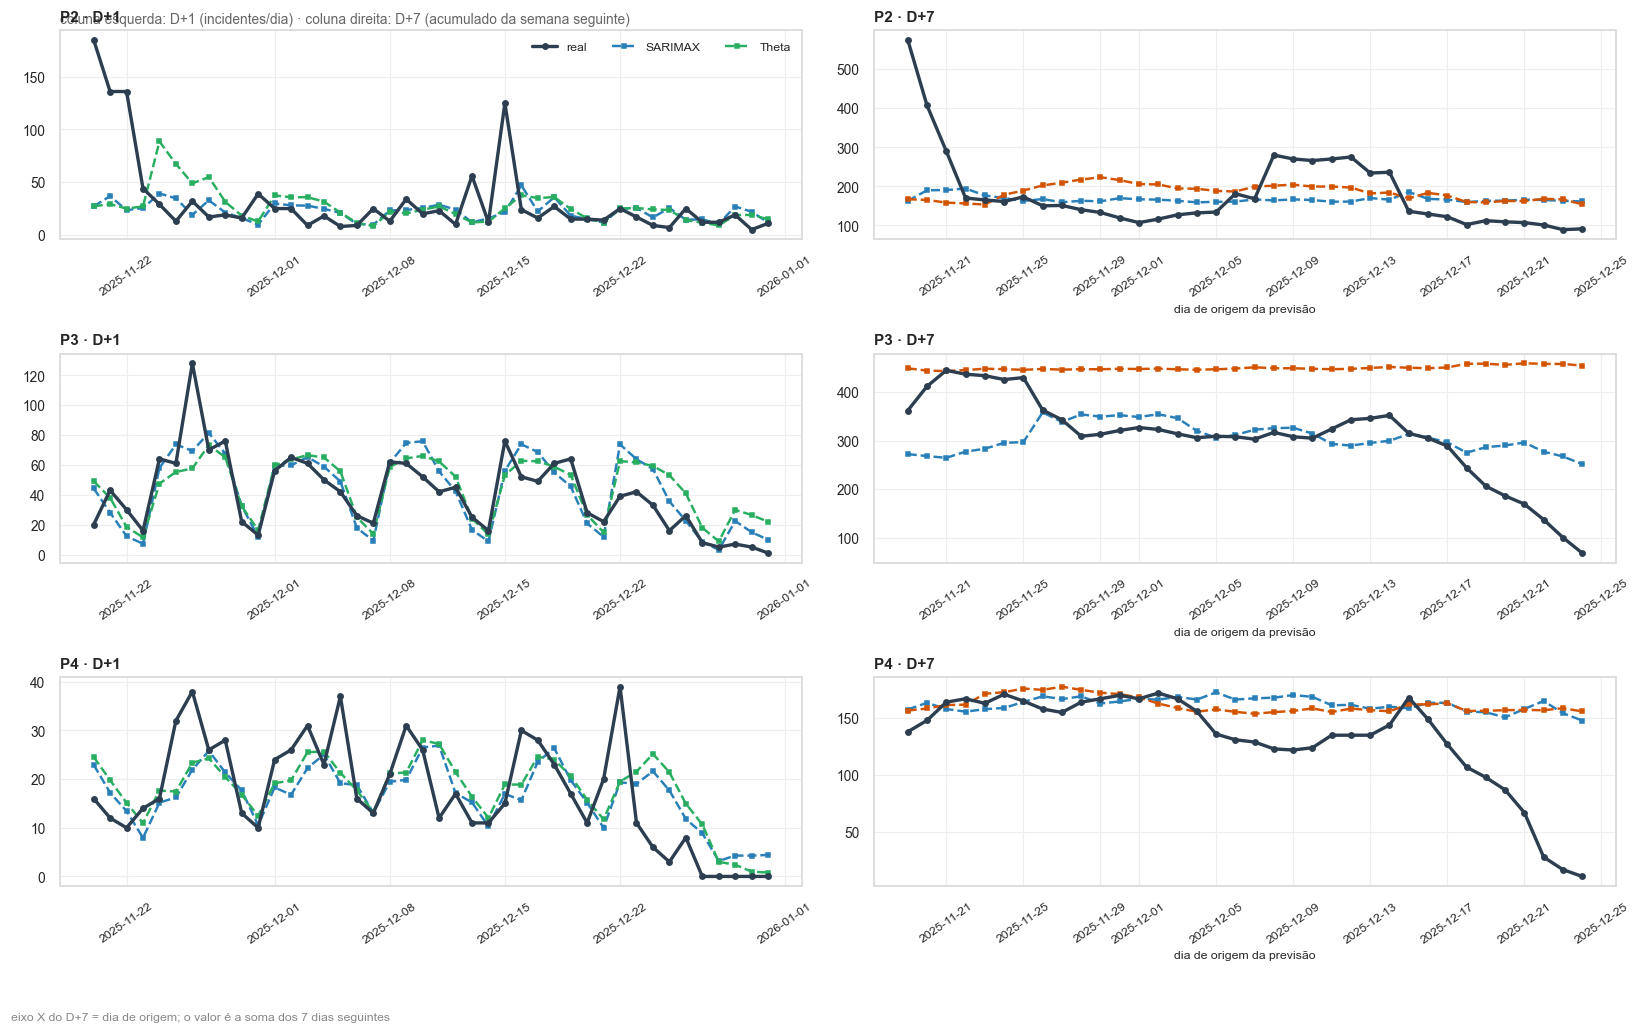

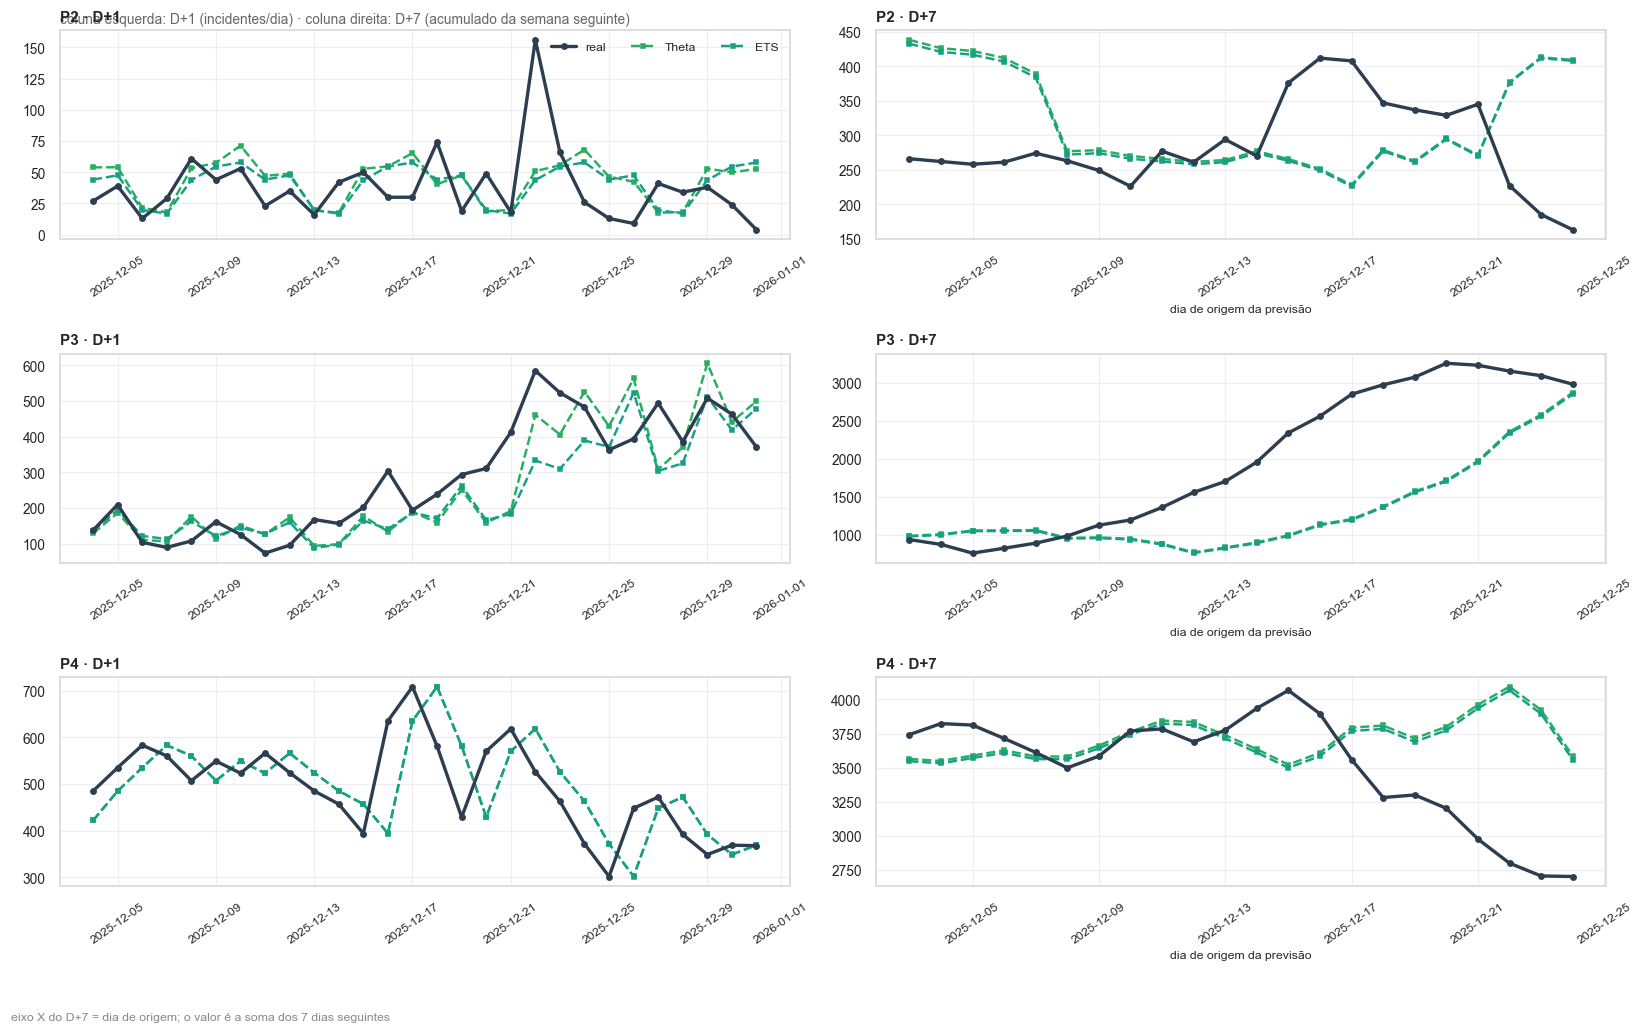

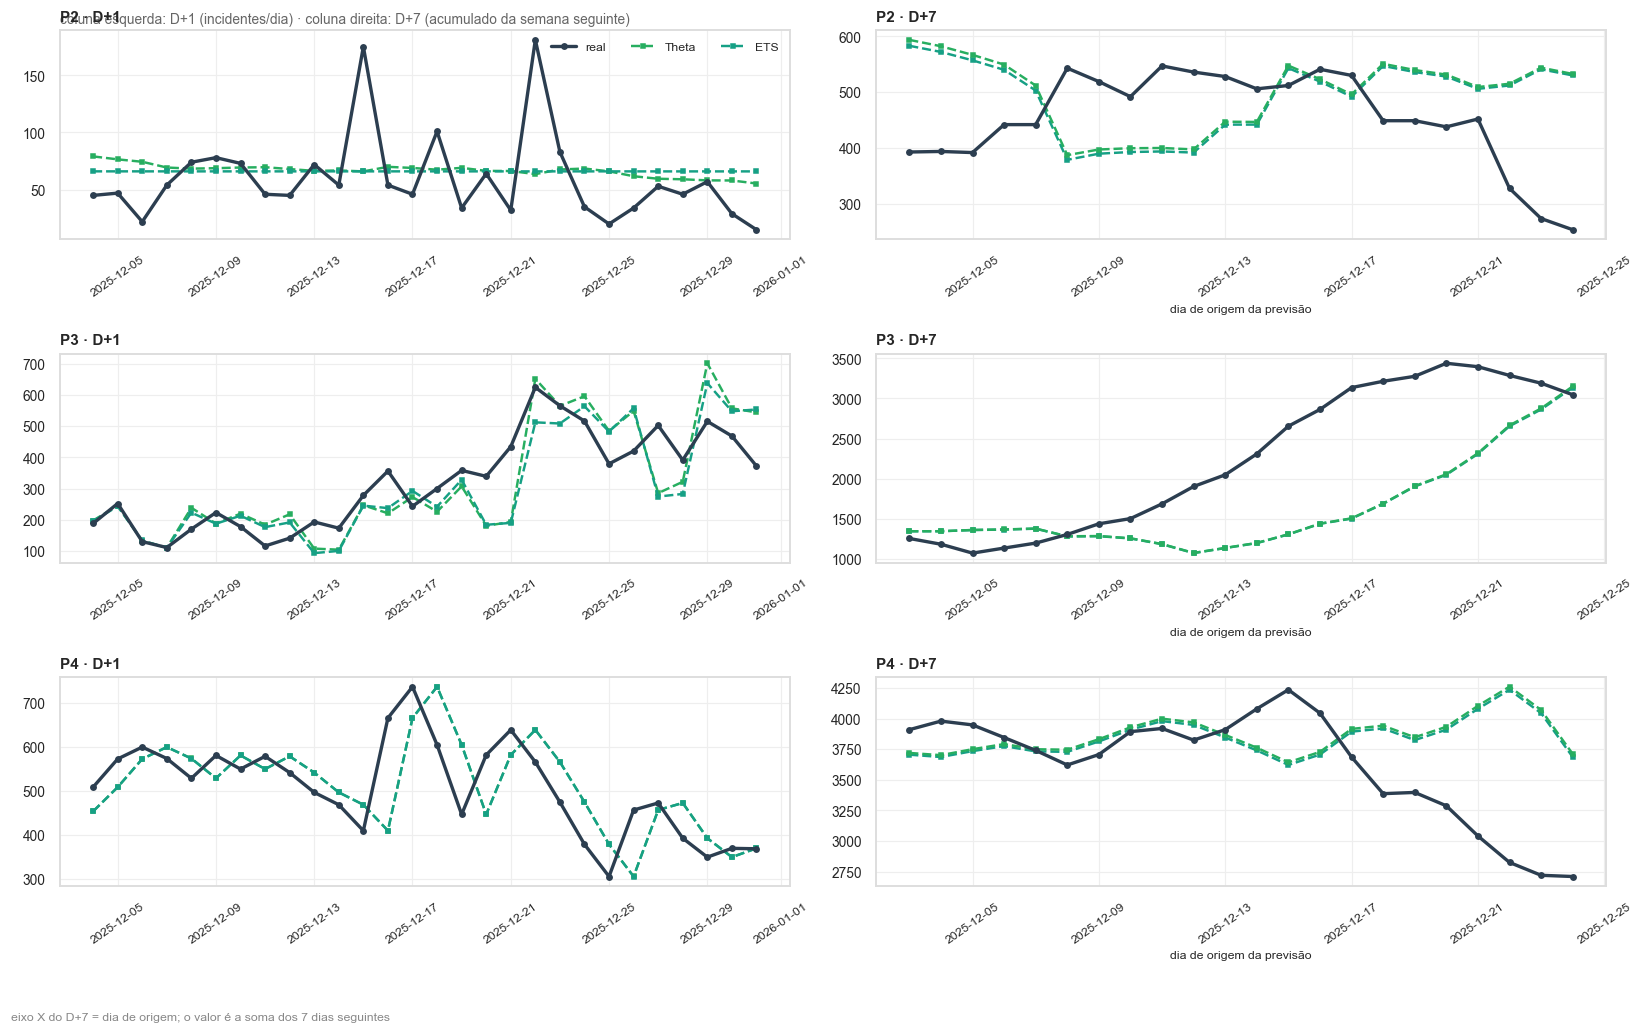

In [56]:
for g in GRUPOS:
    fig, axes = novo_grafico(
        f"Real × previsto — {g}",
        "coluna esquerda: D+1 (incidentes/dia) · coluna direita: D+7 (acumulado da semana seguinte)",
        figsize=(15, 9), nrows=3, ncols=2,
    )
    for i, p in enumerate(PRIORIDADES):
        for j, h in enumerate(["D+1", "D+7"]):
            ax = axes[i, j]
            sub = PREVISOES[(PREVISOES.grupo == g) & (PREVISOES.prioridade == p)
                            & (PREVISOES.horizonte == h)]
            eixo_x = "data_alvo" if h == "D+1" else "data_origem"

            real = sub.drop_duplicates([eixo_x]).sort_values(eixo_x)
            ax.plot(real[eixo_x], real.real, color=PALETA["real"], lw=2.2,
                    marker="o", ms=3.5, label="real", zorder=3)

            for modelo in MELHORES[(g, h)]:
                linha = sub[sub.modelo == modelo].sort_values(eixo_x)
                ax.plot(linha[eixo_x], linha.previsto, color=COR_MODELO[modelo],
                        lw=1.6, ls="--", marker="s", ms=3, label=modelo)

            ax.set_title(f"P{p} · {h}" if i or j else f"P{p} · {h}", fontsize=10)
            ax.tick_params(axis="x", rotation=35, labelsize=8)
            if i == 0 and j == 0:
                ax.legend(fontsize=8, ncol=3)
            if h == "D+7":
                ax.set_xlabel("dia de origem da previsão", fontsize=8)
    finalizar(fig, "eixo X do D+7 = dia de origem; o valor é a soma dos 7 dias seguintes")

## 8.4 Comparação de desempenho entre os modelos

Um gráfico de linhas por grupo, com as 3 prioridades no mesmo painel: o eixo X percorre os
modelos em ordem de complexidade crescente, o eixo Y é o MAE. Uma linha que **desce** da
esquerda para a direita diz que complexidade está comprando acerto; uma linha **plana ou
subindo** diz que não está — e é essa a leitura que §9 usa.

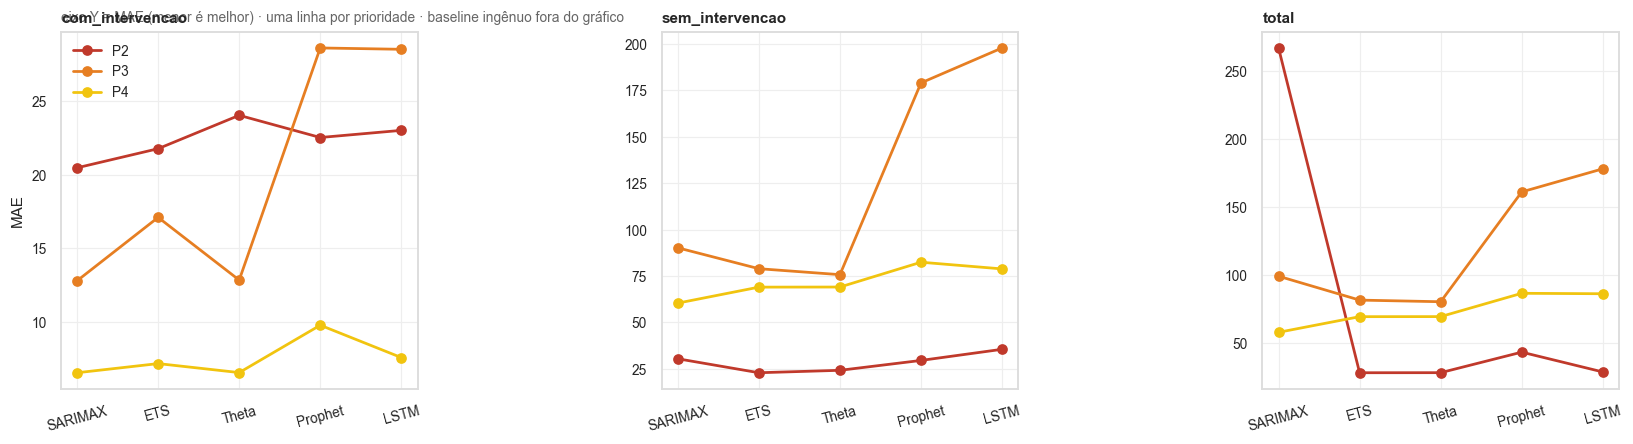

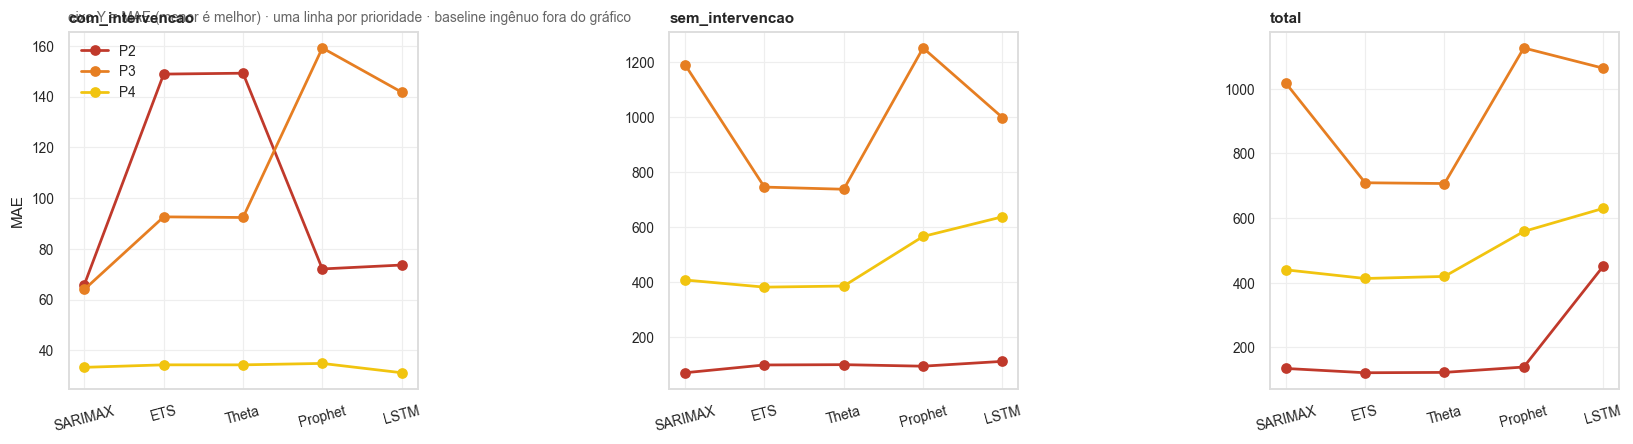

In [57]:
for h in ["D+1", "D+7"]:
    fig, axes = novo_grafico(
        f"Desempenho dos modelos por complexidade crescente — {h}",
        "eixo Y = MAE (menor é melhor) · uma linha por prioridade · baseline ingênuo fora do gráfico",
        figsize=(15, 4.2), ncols=3,
    )
    for j, g in enumerate(GRUPOS):
        ax = axes[j]
        for p in PRIORIDADES:
            sub = (METRICAS[(METRICAS.grupo == g) & (METRICAS.horizonte == h)
                            & (METRICAS.prioridade == str(p)) & (METRICAS.modelo != "Ingênuo")]
                   .set_index("modelo").reindex(MODELOS))
            ax.plot(MODELOS, sub.mae, marker="o", ms=6, lw=1.8,
                    color=COR_PRIORIDADE[p], label=f"P{p}")
        ax.set_title(g, fontsize=10)
        ax.set_ylabel("MAE" if j == 0 else "")
        ax.tick_params(axis="x", rotation=15)
        if j == 0:
            ax.legend(fontsize=9)
    finalizar(fig)

## 8.5 O confronto com o baseline ingênuo

O gráfico anterior compara os modelos **entre si**. Este compara cada um com o **piso**: a barra
mede quanto por cento de MAE o modelo economiza em relação a repetir o último valor observado.
Barra negativa = o modelo perde para o ingênuo.

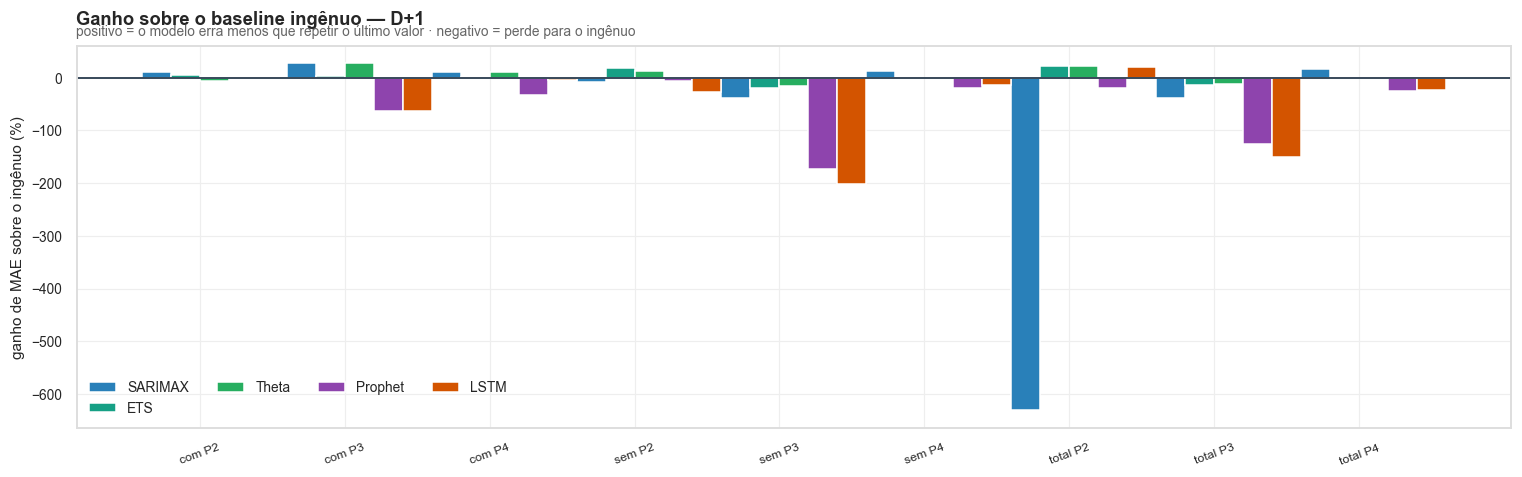

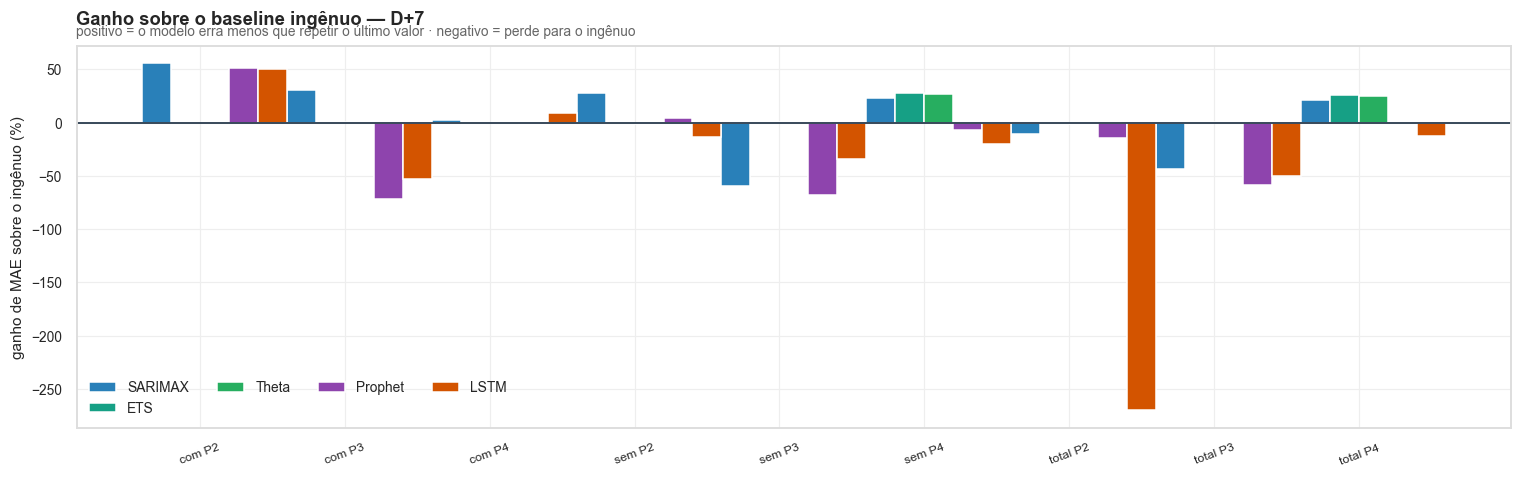

In [58]:
for h in ["D+1", "D+7"]:
    dados_barra = (METRICAS[(METRICAS.horizonte == h) & (METRICAS.modelo != "Ingênuo")
                            & (METRICAS.prioridade != "todas")]
                   .assign(serie=lambda d: d.grupo.str.replace("_intervencao", "", regex=False)
                           + " P" + d.prioridade))
    ordem_series = [f"{g.replace('_intervencao', '')} P{p}" for g in GRUPOS for p in PRIORIDADES]

    fig, ax = novo_grafico(
        f"Ganho sobre o baseline ingênuo — {h}",
        "positivo = o modelo erra menos que repetir o último valor · negativo = perde para o ingênuo",
        figsize=(14, 4.5),
    )
    largura = 0.2
    x = np.arange(len(ordem_series))
    for k, modelo in enumerate(MODELOS):
        valores = (dados_barra[dados_barra.modelo == modelo]
                   .set_index("serie").reindex(ordem_series).ganho_vs_ingenuo)
        ax.bar(x + (k - 1.5) * largura, valores, largura,
               color=COR_MODELO[modelo], label=modelo)
    ax.axhline(0, color=PALETA["total"], lw=1.2)
    ax.set_xticks(x)
    ax.set_xticklabels(ordem_series, rotation=20, fontsize=8)
    ax.set_ylabel("ganho de MAE sobre o ingênuo (%)")
    ax.legend(fontsize=9, ncol=4)
    finalizar(fig)

In [59]:
placar = (METRICAS[(METRICAS.modelo != "Ingênuo") & (METRICAS.prioridade != "todas")]
          .groupby(["modelo", "horizonte"])
          .agg(series_que_superam=("supera_ingenuo", "sum"),
               series=("supera_ingenuo", "size"),
               ganho_medio=("ganho_vs_ingenuo", "mean"),
               ganho_maximo=("ganho_vs_ingenuo", "max"))
          .reset_index())
tabela(placar, "Placar contra o piso — em quantas das 9 séries cada modelo bate o ingênuo")

**Placar contra o piso — em quantas das 9 séries cada modelo bate o ingênuo**

| modelo   | horizonte   |   series_que_superam |   series |   ganho_medio |   ganho_maximo |
|:---------|:------------|---------------------:|---------:|--------------:|---------------:|
| ETS      | D+1         |                    5 |        9 |          1.54 |          22.08 |
| ETS      | D+7         |                    5 |        9 |          6    |          28.01 |
| LSTM     | D+1         |                    1 |        9 |        -51.62 |          20.5  |
| LSTM     | D+7         |                    2 |        9 |        -43.71 |          50.55 |
| Prophet  | D+1         |                    1 |        9 |        -51.64 |           1.09 |
| Prophet  | D+7         |                    2 |        9 |        -18.35 |          51.59 |
| SARIMAX  | D+1         |                    5 |        9 |        -71.16 |          27.06 |
| SARIMAX  | D+7         |                    6 |        9 |          5.34 |          55.72 |
| Theta    | D+1         |                    4 |        9 |          4.25 |          26.8  |
| Theta    | D+7         |                    6 |        9 |          5.73 |          27.27 |

## 8.6 O resultado sobrevive às origens não sobrepostas?

As origens do D+7 andam de um em um dia, então duas vizinhas compartilham 6 dos 7 dias do alvo.
§2.4 já corrigiu a estatística por isso, mas há uma leitura mais direta e mais dura: **refazer a
comparação usando só uma origem a cada 7**, que é o maior subconjunto sem nenhum dia em comum.

Isso não substitui a leitura principal — sobram ~5 pontos por série em `com_intervencao` e ~3 nos
outros grupos, longe de qualquer conclusividade. Serve para uma coisa só, e é uma coisa que
importa: detectar o caso em que a sobreposição está **fabricando** uma diferença que o dado
independente não sustenta. Se o melhor modelo virar aqui, a leitura principal é suspeita.

In [60]:
def sem_sobreposicao(previsoes, horizonte):
    """Uma origem a cada `passos` dias — o maior subconjunto com alvos disjuntos."""
    passos = HORIZONTES[horizonte]
    guardadas = []
    for _, sub in previsoes[previsoes.horizonte == horizonte].groupby(["grupo", "prioridade"]):
        datas = sorted(sub.data_origem.unique())[::passos]
        guardadas.append(sub[sub.data_origem.isin(datas)])
    return pd.concat(guardadas, ignore_index=True)


comparacao_sobreposicao = []
for h in HORIZONTES:
    disjuntas_df = sem_sobreposicao(PREVISOES, h)
    todas = (METRICAS[(METRICAS.horizonte == h) & (METRICAS.prioridade == "todas")]
             .set_index(["grupo", "modelo"]).mae)
    disjuntas = (calcular_metricas(disjuntas_df)
                 .query("prioridade == 'todas'").set_index(["grupo", "modelo"]).mae)
    for g in GRUPOS:
        ordem_todas = todas.loc[g].sort_values().index.tolist()
        ordem_disj = disjuntas.loc[g].sort_values().index.tolist()
        comparacao_sobreposicao.append({
            "horizonte": h, "grupo": g,
            "n_todas": int(METRICAS[(METRICAS.horizonte == h) & (METRICAS.grupo == g)
                                    & (METRICAS.prioridade == "todas")].n.iloc[0]),
            "n_disjuntas": int(len(disjuntas_df[(disjuntas_df.grupo == g)
                                                & (disjuntas_df.modelo == MODELOS[0])])),
            "melhor_todas": ordem_todas[0], "melhor_disjuntas": ordem_disj[0],
            "ranking_igual": ordem_todas == ordem_disj,
            "melhor_coincide": ordem_todas[0] == ordem_disj[0],
        })

SOBREPOSICAO = pd.DataFrame(comparacao_sobreposicao)
tabela(SOBREPOSICAO, "Ranking com todas as origens × só as não sobrepostas")
print(f"o melhor modelo coincide em {SOBREPOSICAO.melhor_coincide.sum()} dos "
      f"{len(SOBREPOSICAO)} cortes; o ranking inteiro coincide em "
      f"{SOBREPOSICAO.ranking_igual.sum()}.")
print("Divergência no ranking completo é esperada com 3 a 5 pontos — o que importaria seria o "
      "melhor modelo virar, porque é ele que §9 escolhe.")

**Ranking com todas as origens × só as não sobrepostas**

| horizonte   | grupo           |   n_todas |   n_disjuntas | melhor_todas   | melhor_disjuntas   | ranking_igual   | melhor_coincide   |
|:------------|:----------------|----------:|--------------:|:---------------|:-------------------|:----------------|:------------------|
| D+1         | com_intervencao |       126 |           126 | SARIMAX        | SARIMAX            | True            | True              |
| D+1         | sem_intervencao |        84 |            84 | Ingênuo        | Ingênuo            | True            | True              |
| D+1         | total           |        84 |            84 | Ingênuo        | Ingênuo            | True            | True              |
| D+7         | com_intervencao |       108 |            18 | SARIMAX        | SARIMAX            | False           | True              |
| D+7         | sem_intervencao |        66 |            12 | Theta          | Theta              | True            | True              |
| D+7         | total           |        66 |            12 | ETS            | ETS                | True            | True              |

o melhor modelo coincide em 6 dos 6 cortes; o ranking inteiro coincide em 5.
Divergência no ranking completo é esperada com 3 a 5 pontos — o que importaria seria o melhor modelo virar, porque é ele que §9 escolhe.


---

# 9. Escolha do modelo

**Regra**, aplicada uma vez por grupo × horizonte sobre a leitura geral:

1. Candidatos são **ARIMA, SARIMA, Prophet e LSTM**. O baseline ingênuo **não concorre** — ele é
   régua, não candidato.
2. Toma-se o menor MAE entre os candidatos.
3. Todo candidato dentro de **5%** desse melhor MAE é considerado empate técnico. Entre eles,
   vence o **menos complexo** (ARIMA < SARIMA < Prophet < LSTM). É a tradução literal de "o
   menos complexo com maior ganho": complexidade extra só se paga quando compra mais de 5% de
   erro.
4. Escolhido o vencedor, compara-se com o ingênuo. **Se o vencedor perder para o ingênuo, isso
   é registrado com destaque** — a escolha se mantém (a regra manda escolher entre os
   candidatos), mas a leitura de negócio muda completamente.

In [61]:
def escolher_modelo(grupo, prioridade, horizonte):
    """Vencedor da série pelo MAE do backtest de origem móvel. O teste não participa.

    Duas mudanças em relação à safra 1, e as duas custaram resultado lá:

    1. **O grão é a série**, não o grupo. Escolher em `prioridade == "todas"` soma MAE de séries
       de 22 a 913 incidentes/dia, e na prática deixa P3 escolher sozinha para todo mundo.
    2. **O critério é a validação.** A `TOLERANCIA = 0,05` combinada com a ordenação por
       complexidade era um viés pró-underfit por regra: dentro de 5 % vencia sempre o mais
       simples. Aqui a parcimônia só desempata abaixo de 0,5 %.
    """
    sub = METRICAS[(METRICAS.grupo == grupo) & (METRICAS.prioridade == str(prioridade))
                   & (METRICAS.horizonte == horizonte) & (METRICAS.elegivel_cv)]
    sub = sub[np.isfinite(sub.mae_cv)].sort_values("mae_cv")
    if sub.empty:
        return None
    limite = sub.mae_cv.min() * 1.005
    vencedor = sub[sub.mae_cv <= limite].sort_values(["complexidade", "mae_cv"]).iloc[0]
    campeao_teste = (METRICAS[(METRICAS.grupo == grupo)
                              & (METRICAS.prioridade == str(prioridade))
                              & (METRICAS.horizonte == horizonte)
                              & (METRICAS.modelo != "Ingênuo")]
                     .sort_values("mae").iloc[0])
    piso_cv = MAE_CV.get((grupo, prioridade, horizonte, "Ingênuo"), np.nan)
    return {
        "grupo": grupo, "prioridade": prioridade, "horizonte": horizonte,
        "vencedor": vencedor.modelo, "mae_cv": vencedor.mae_cv, "mae_cv_piso": piso_cv,
        "vence_piso_na_cv": bool(vencedor.mae_cv < piso_cv),
        "mae": vencedor.mae, "mase": vencedor.mase, "mape": vencedor.mape,
        "mae_ingenuo": vencedor.mae_ingenuo, "ganho_vs_ingenuo": vencedor.ganho_vs_ingenuo,
        "supera_ingenuo": bool(vencedor.supera_ingenuo),
        # O que o teste diria se pudesse escolher — a diferença entre as duas colunas é o
        # tamanho do viés de seleção que a safra 1 embutia sem medir.
        "melhor_no_teste": campeao_teste.modelo,
        "escolha_coincide_com_o_teste": vencedor.modelo == campeao_teste.modelo,
    }


ESCOLHA = pd.DataFrame([e for g in GRUPOS for p in PRIORIDADES for h in ["D+1", "D+7"]
                        if (e := escolher_modelo(g, p, h)) is not None])
tabela(ESCOLHA[["grupo", "prioridade", "horizonte", "vencedor", "mae_cv", "mae_cv_piso",
                "mae", "mae_ingenuo", "ganho_vs_ingenuo", "supera_ingenuo",
                "melhor_no_teste", "escolha_coincide_com_o_teste"]],
       "Modelo escolhido por série — critério: MAE do backtest, nunca o teste")

print(f"vencem o piso ingênuo no teste: {int(ESCOLHA.supera_ingenuo.sum())} de {len(ESCOLHA)}")
print(f"a escolha da CV coincide com o melhor no teste em "
      f"{int(ESCOLHA.escolha_coincide_com_o_teste.sum())} de {len(ESCOLHA)} séries — a diferença "
      f"é o viés de seleção que escolher no teste esconderia.")
print(f"MAE somado no hold-out: {ESCOLHA.mae.sum():.0f} "
      f"(piso ingênuo: {ESCOLHA.mae_ingenuo.sum():.0f})")


**Modelo escolhido por série — critério: MAE do backtest, nunca o teste**

| grupo           |   prioridade | horizonte   | vencedor   |   mae_cv |   mae_cv_piso |     mae |   mae_ingenuo |   ganho_vs_ingenuo | supera_ingenuo   | melhor_no_teste   | escolha_coincide_com_o_teste   |
|:----------------|-------------:|:------------|:-----------|---------:|--------------:|--------:|--------------:|-------------------:|:-----------------|:------------------|:-------------------------------|
| com_intervencao |            2 | D+1         | SARIMAX    |    14.06 |         21.82 |   20.47 |         22.79 |              10.14 | True             | SARIMAX           | True                           |
| com_intervencao |            2 | D+7         | SARIMAX    |    67.03 |        110.04 |   65.91 |        148.83 |              55.72 | True             | SARIMAX           | True                           |
| com_intervencao |            3 | D+1         | ETS        |    13.04 |         27.87 |   17.1  |         17.52 |               2.43 | True             | SARIMAX           | False                          |
| com_intervencao |            3 | D+7         | Theta      |    58.08 |         57.97 |   92.33 |         92.58 |               0.27 | True             | SARIMAX           | False                          |
| com_intervencao |            4 | D+1         | SARIMAX    |     6.68 |          9.51 |    6.52 |          7.29 |              10.53 | True             | SARIMAX           | True                           |
| com_intervencao |            4 | D+7         | SARIMAX    |    29.86 |         38.35 |   33.29 |         34.28 |               2.88 | True             | LSTM              | False                          |
| sem_intervencao |            2 | D+1         | Theta      |    35.44 |         64.17 |   24.2  |         27.96 |              13.47 | True             | ETS               | False                          |
| sem_intervencao |            2 | D+7         | SARIMAX    |   154.62 |        289.4  |   72.02 |        100.23 |              28.14 | True             | SARIMAX           | True                           |
| sem_intervencao |            3 | D+1         | Theta      |    35.12 |         44.98 |   75.72 |         65.43 |             -15.73 | False            | Theta             | True                           |
| sem_intervencao |            3 | D+7         | SARIMAX    |   124.79 |        182.86 | 1188.51 |        745.14 |             -59.5  | False            | Theta             | False                          |
| sem_intervencao |            4 | D+1         | Theta      |    37.5  |         37.43 |   69.06 |         69    |              -0.08 | False            | SARIMAX           | False                          |
| sem_intervencao |            4 | D+7         | Theta      |   323.05 |        306.79 |  386.36 |        531.23 |              27.27 | True             | ETS               | False                          |
| total           |            2 | D+1         | ETS        |    49.77 |         73.17 |   28.47 |         36.54 |              22.08 | True             | ETS               | True                           |
| total           |            2 | D+7         | SARIMAX    |   211.19 |        397.24 |  134.97 |        121.73 |             -10.88 | False            | ETS               | False                          |
| total           |            3 | D+1         | Theta      |    41.87 |         60.52 |   80.66 |         71.43 |             -12.93 | False            | Theta             | True                           |
| total           |            3 | D+7         | SARIMAX    |   180.69 |        230.12 | 1017.15 |        709.09 |             -43.44 | False            | Theta             | False                          |
| total           |            4 | D+1         | Theta      |    36.13 |         36.02 |   69.73 |         69.68 |              -0.07 | False            | SARIMAX           | False                          |
| total           |            4 | D+7         | ETS        |   326.1  |        307.74 |  413.13 |        558.09 |              25.97 | True             | ETS               | True                           |

vencem o piso ingênuo no teste: 11 de 18
a escolha da CV coincide com o melhor no teste em 8 de 18 séries — a diferença é o viés de seleção que escolher no teste esconderia.
MAE somado no hold-out: 3796 (piso ingênuo: 3429)


In [62]:
from IPython.display import Markdown, display

partes = ["### Justificativa de cada escolha\n",
          "O critério é o MAE do backtest de origem móvel (`mae_cv`). O MAE de teste aparece "
          "como **resultado**, nunca como critério — é o que separa este protocolo do anterior.\n"]

for _, r in ESCOLHA.iterrows():
    partes.append(f"**`{r.grupo}` · P{r.prioridade} · {r.horizonte} → {r.vencedor}**")
    partes.append(f"- Menor MAE na validação: {r.mae_cv:.2f} contra {r.mae_cv_piso:.2f} do piso "
                  f"ingênuo ({'vence' if r.vence_piso_na_cv else '**não vence**'} na validação).")
    if not r.escolha_coincide_com_o_teste:
        partes.append(f"- No hold-out quem teria ido melhor é o **{r.melhor_no_teste}**. A "
                      f"escolha não muda por isso: olhar o teste para decidir é exatamente o "
                      f"viés que este protocolo existe para eliminar.")
    if r.supera_ingenuo:
        partes.append(f"- No hold-out supera o ingênuo em **{r.ganho_vs_ingenuo:.1f}%** "
                      f"({r.mae:.2f} contra {r.mae_ingenuo:.2f}).")
    else:
        partes.append(f"- ⚠️ **No hold-out perde para o ingênuo**: {r.mae:.2f} contra "
                      f"{r.mae_ingenuo:.2f} ({r.ganho_vs_ingenuo:+.1f}%).")
    partes.append("")

perdedores = ESCOLHA[~ESCOLHA.supera_ingenuo]
if len(perdedores):
    partes.append("---\n\n### ⚠️ Ressalva obrigatória\n")
    partes.append(
        f"Em **{len(perdedores)} de {len(ESCOLHA)}** séries o modelo escolhido erra mais no "
        "hold-out do que a regra ingênua:\n")
    for _, r in perdedores.iterrows():
        partes.append(f"- `{r.grupo}` · P{r.prioridade} · {r.horizonte}: {r.vencedor} com MAE "
                      f"{r.mae:.2f} contra {r.mae_ingenuo:.2f} do ingênuo.")
    partes.append(
        "\nParte disso é o que §3 e §5 já mediam — o resíduo é a maior componente das séries. "
        "Mas a concentração importa mais que a contagem: as séries de **P3 em "
        "`sem_intervencao` e `total`** têm uma **quebra de nível dentro da própria janela de "
        "teste** (a média diária passa de ~104 em novembro para ~273 em dezembro). Não é "
        "tendência, é degrau, e nada no histórico o antecipa: é evento operacional. Nenhuma "
        "família, transformação ou hiperparâmetro acompanha isso com o treino terminando antes "
        "do salto. **Recomendação de negócio: não colocar em produção um modelo que perde para "
        "o ingênuo na sua série** — e, nessas séries específicas, tratar o degrau como gatilho "
        "de retreino, não como erro de modelagem.\n")
else:
    partes.append("---\n\nTodos os modelos escolhidos superam o baseline ingênuo na sua série.\n")

display(Markdown("\n".join(partes)))


### Justificativa de cada escolha

O critério é o MAE do backtest de origem móvel (`mae_cv`). O MAE de teste aparece como **resultado**, nunca como critério — é o que separa este protocolo do anterior.

**`com_intervencao` · P2 · D+1 → SARIMAX**
- Menor MAE na validação: 14.06 contra 21.82 do piso ingênuo (vence na validação).
- No hold-out supera o ingênuo em **10.1%** (20.47 contra 22.79).

**`com_intervencao` · P2 · D+7 → SARIMAX**
- Menor MAE na validação: 67.03 contra 110.04 do piso ingênuo (vence na validação).
- No hold-out supera o ingênuo em **55.7%** (65.91 contra 148.83).

**`com_intervencao` · P3 · D+1 → ETS**
- Menor MAE na validação: 13.04 contra 27.87 do piso ingênuo (vence na validação).
- No hold-out quem teria ido melhor é o **SARIMAX**. A escolha não muda por isso: olhar o teste para decidir é exatamente o viés que este protocolo existe para eliminar.
- No hold-out supera o ingênuo em **2.4%** (17.10 contra 17.52).

**`com_intervencao` · P3 · D+7 → Theta**
- Menor MAE na validação: 58.08 contra 57.97 do piso ingênuo (**não vence** na validação).
- No hold-out quem teria ido melhor é o **SARIMAX**. A escolha não muda por isso: olhar o teste para decidir é exatamente o viés que este protocolo existe para eliminar.
- No hold-out supera o ingênuo em **0.3%** (92.33 contra 92.58).

**`com_intervencao` · P4 · D+1 → SARIMAX**
- Menor MAE na validação: 6.68 contra 9.51 do piso ingênuo (vence na validação).
- No hold-out supera o ingênuo em **10.5%** (6.52 contra 7.29).

**`com_intervencao` · P4 · D+7 → SARIMAX**
- Menor MAE na validação: 29.86 contra 38.35 do piso ingênuo (vence na validação).
- No hold-out quem teria ido melhor é o **LSTM**. A escolha não muda por isso: olhar o teste para decidir é exatamente o viés que este protocolo existe para eliminar.
- No hold-out supera o ingênuo em **2.9%** (33.29 contra 34.28).

**`sem_intervencao` · P2 · D+1 → Theta**
- Menor MAE na validação: 35.44 contra 64.17 do piso ingênuo (vence na validação).
- No hold-out quem teria ido melhor é o **ETS**. A escolha não muda por isso: olhar o teste para decidir é exatamente o viés que este protocolo existe para eliminar.
- No hold-out supera o ingênuo em **13.5%** (24.20 contra 27.96).

**`sem_intervencao` · P2 · D+7 → SARIMAX**
- Menor MAE na validação: 154.62 contra 289.40 do piso ingênuo (vence na validação).
- No hold-out supera o ingênuo em **28.1%** (72.02 contra 100.23).

**`sem_intervencao` · P3 · D+1 → Theta**
- Menor MAE na validação: 35.12 contra 44.98 do piso ingênuo (vence na validação).
- ⚠️ **No hold-out perde para o ingênuo**: 75.72 contra 65.43 (-15.7%).

**`sem_intervencao` · P3 · D+7 → SARIMAX**
- Menor MAE na validação: 124.79 contra 182.86 do piso ingênuo (vence na validação).
- No hold-out quem teria ido melhor é o **Theta**. A escolha não muda por isso: olhar o teste para decidir é exatamente o viés que este protocolo existe para eliminar.
- ⚠️ **No hold-out perde para o ingênuo**: 1188.51 contra 745.14 (-59.5%).

**`sem_intervencao` · P4 · D+1 → Theta**
- Menor MAE na validação: 37.50 contra 37.43 do piso ingênuo (**não vence** na validação).
- No hold-out quem teria ido melhor é o **SARIMAX**. A escolha não muda por isso: olhar o teste para decidir é exatamente o viés que este protocolo existe para eliminar.
- ⚠️ **No hold-out perde para o ingênuo**: 69.06 contra 69.00 (-0.1%).

**`sem_intervencao` · P4 · D+7 → Theta**
- Menor MAE na validação: 323.05 contra 306.79 do piso ingênuo (**não vence** na validação).
- No hold-out quem teria ido melhor é o **ETS**. A escolha não muda por isso: olhar o teste para decidir é exatamente o viés que este protocolo existe para eliminar.
- No hold-out supera o ingênuo em **27.3%** (386.36 contra 531.23).

**`total` · P2 · D+1 → ETS**
- Menor MAE na validação: 49.77 contra 73.17 do piso ingênuo (vence na validação).
- No hold-out supera o ingênuo em **22.1%** (28.47 contra 36.54).

**`total` · P2 · D+7 → SARIMAX**
- Menor MAE na validação: 211.19 contra 397.24 do piso ingênuo (vence na validação).
- No hold-out quem teria ido melhor é o **ETS**. A escolha não muda por isso: olhar o teste para decidir é exatamente o viés que este protocolo existe para eliminar.
- ⚠️ **No hold-out perde para o ingênuo**: 134.97 contra 121.73 (-10.9%).

**`total` · P3 · D+1 → Theta**
- Menor MAE na validação: 41.87 contra 60.52 do piso ingênuo (vence na validação).
- ⚠️ **No hold-out perde para o ingênuo**: 80.66 contra 71.43 (-12.9%).

**`total` · P3 · D+7 → SARIMAX**
- Menor MAE na validação: 180.69 contra 230.12 do piso ingênuo (vence na validação).
- No hold-out quem teria ido melhor é o **Theta**. A escolha não muda por isso: olhar o teste para decidir é exatamente o viés que este protocolo existe para eliminar.
- ⚠️ **No hold-out perde para o ingênuo**: 1017.15 contra 709.09 (-43.4%).

**`total` · P4 · D+1 → Theta**
- Menor MAE na validação: 36.13 contra 36.02 do piso ingênuo (**não vence** na validação).
- No hold-out quem teria ido melhor é o **SARIMAX**. A escolha não muda por isso: olhar o teste para decidir é exatamente o viés que este protocolo existe para eliminar.
- ⚠️ **No hold-out perde para o ingênuo**: 69.73 contra 69.68 (-0.1%).

**`total` · P4 · D+7 → ETS**
- Menor MAE na validação: 326.10 contra 307.74 do piso ingênuo (**não vence** na validação).
- No hold-out supera o ingênuo em **26.0%** (413.13 contra 558.09).

---

### ⚠️ Ressalva obrigatória

Em **7 de 18** séries o modelo escolhido erra mais no hold-out do que a regra ingênua:

- `sem_intervencao` · P3 · D+1: Theta com MAE 75.72 contra 65.43 do ingênuo.
- `sem_intervencao` · P3 · D+7: SARIMAX com MAE 1188.51 contra 745.14 do ingênuo.
- `sem_intervencao` · P4 · D+1: Theta com MAE 69.06 contra 69.00 do ingênuo.
- `total` · P2 · D+7: SARIMAX com MAE 134.97 contra 121.73 do ingênuo.
- `total` · P3 · D+1: Theta com MAE 80.66 contra 71.43 do ingênuo.
- `total` · P3 · D+7: SARIMAX com MAE 1017.15 contra 709.09 do ingênuo.
- `total` · P4 · D+1: Theta com MAE 69.73 contra 69.68 do ingênuo.

Parte disso é o que §3 e §5 já mediam — o resíduo é a maior componente das séries. Mas a concentração importa mais que a contagem: as séries de **P3 em `sem_intervencao` e `total`** têm uma **quebra de nível dentro da própria janela de teste** (a média diária passa de ~104 em novembro para ~273 em dezembro). Não é tendência, é degrau, e nada no histórico o antecipa: é evento operacional. Nenhuma família, transformação ou hiperparâmetro acompanha isso com o treino terminando antes do salto. **Recomendação de negócio: não colocar em produção um modelo que perde para o ingênuo na sua série** — e, nessas séries específicas, tratar o degrau como gatilho de retreino, não como erro de modelagem.


## 9.1 A leitura agregada, agora como diagnóstico

A safra anterior escolhia o modelo em `prioridade == "todas"` e a leitura por série era diagnóstico. Os papéis se inverteram: **a escolha é por série** (§9) e o agregado fica aqui para mostrar o que o critério antigo custava.

O agregado soma MAE de séries com nível de 22 a 913 incidentes/dia. Ele é dominado pela série de maior volume, o que na prática deixava P3 escolher sozinha para as três prioridades — e enterrava séries que já venciam o ingênuo com folga.


In [63]:
# A leitura agregada da safra 1, mantida como DIAGNÓSTICO — é o critério que ela usava para
# decidir, e vê-lo ao lado da escolha por série mostra o que ele custava.
def escolha_agregada(grupo, horizonte):
    sub = (METRICAS[(METRICAS.grupo == grupo) & (METRICAS.horizonte == horizonte)
                    & (METRICAS.prioridade == "todas") & (METRICAS.elegivel_cv)]
           .sort_values("mae_cv"))
    por_serie = ESCOLHA[(ESCOLHA.grupo == grupo) & (ESCOLHA.horizonte == horizonte)]
    if sub.empty or por_serie.empty:
        return None
    imposto = sub.iloc[0]

    # MAE agregado da carteira por série = média dos MAE das 3 prioridades ponderada pelo nº de
    # origens de cada uma, que é o mesmo que empilhar os erros das três séries.
    pesos = np.array([len(origens_teste(grupo, p, horizonte)) for p in por_serie.prioridade])
    mae_por_serie = float((por_serie.mae.to_numpy() * pesos).sum() / pesos.sum())

    return {"grupo": grupo, "horizonte": horizonte,
            "imposto_pelo_agregado": imposto.modelo,
            "vencedores_por_serie": ", ".join(por_serie.vencedor.tolist()),
            "mae_carteira_por_serie": mae_por_serie,
            "mae_modelo_unico_imposto": imposto.mae,
            "mae_ingenuo": imposto.mae_ingenuo,
            "por_serie_vence_o_piso": mae_por_serie < imposto.mae_ingenuo,
            "ganho_da_escolha_por_serie": (1 - mae_por_serie / imposto.mae) * 100}


AGREGADO = pd.DataFrame([a for g in GRUPOS for h in ["D+1", "D+7"]
                         if (a := escolha_agregada(g, h)) is not None])
tabela(AGREGADO, "Escolha por série × escolha agregada (o critério da safra 1)")
print(f"no critério agregado, a carteira por série vence o ingênuo em "
      f"{int(AGREGADO.por_serie_vence_o_piso.sum())} de {len(AGREGADO)} combinações "
      f"grupo x horizonte.")


**Escolha por série × escolha agregada (o critério da safra 1)**

| grupo           | horizonte   | imposto_pelo_agregado   | vencedores_por_serie    |   mae_carteira_por_serie |   mae_modelo_unico_imposto |   mae_ingenuo | por_serie_vence_o_piso   |   ganho_da_escolha_por_serie |
|:----------------|:------------|:------------------------|:------------------------|-------------------------:|---------------------------:|--------------:|:-------------------------|-----------------------------:|
| com_intervencao | D+1         | SARIMAX                 | SARIMAX, ETS, SARIMAX   |                    14.7  |                      13.26 |         15.87 | True                     |                       -10.85 |
| com_intervencao | D+7         | SARIMAX                 | SARIMAX, Theta, SARIMAX |                    63.84 |                      54.4  |         91.9  | True                     |                       -17.36 |
| sem_intervencao | D+1         | Theta                   | Theta, Theta, Theta     |                    56.33 |                      56.33 |         54.13 | False                    |                         0    |
| sem_intervencao | D+7         | SARIMAX                 | SARIMAX, SARIMAX, Theta |                   548.97 |                     556.28 |        458.86 | False                    |                         1.31 |
| total           | D+1         | Theta                   | ETS, Theta, Theta       |                    59.62 |                      59.64 |         59.21 | False                    |                         0.03 |
| total           | D+7         | SARIMAX                 | SARIMAX, SARIMAX, ETS   |                   521.75 |                     530.68 |        462.97 | False                    |                         1.68 |

no critério agregado, a carteira por série vence o ingênuo em 2 de 6 combinações grupo x horizonte.


## 9.2 Os vencedores na série inteira, não só no teste

O hold-out tem 22 a 42 dias e cai sobre o Natal — amostra pequena e atípica para julgar um modelo sozinha. O painel abaixo responde a pergunta complementar: o modelo escolhido acompanha o nível, o ritmo e a sazonalidade do histórico, ou apenas acertou (ou errou) um mês fora do padrão?

**Leia com a ressalva que está escrita na figura:** antes da faixa sombreada os parâmetros já foram estimados naquele período, então ali a previsão é *dentro* da amostra. Só a faixa sombreada é fora da amostra.

Este painel vem depois de §9 por dependência real, não por gosto: ele desenha o **vencedor**, e o vencedor só existe depois de `ESCOLHA`.


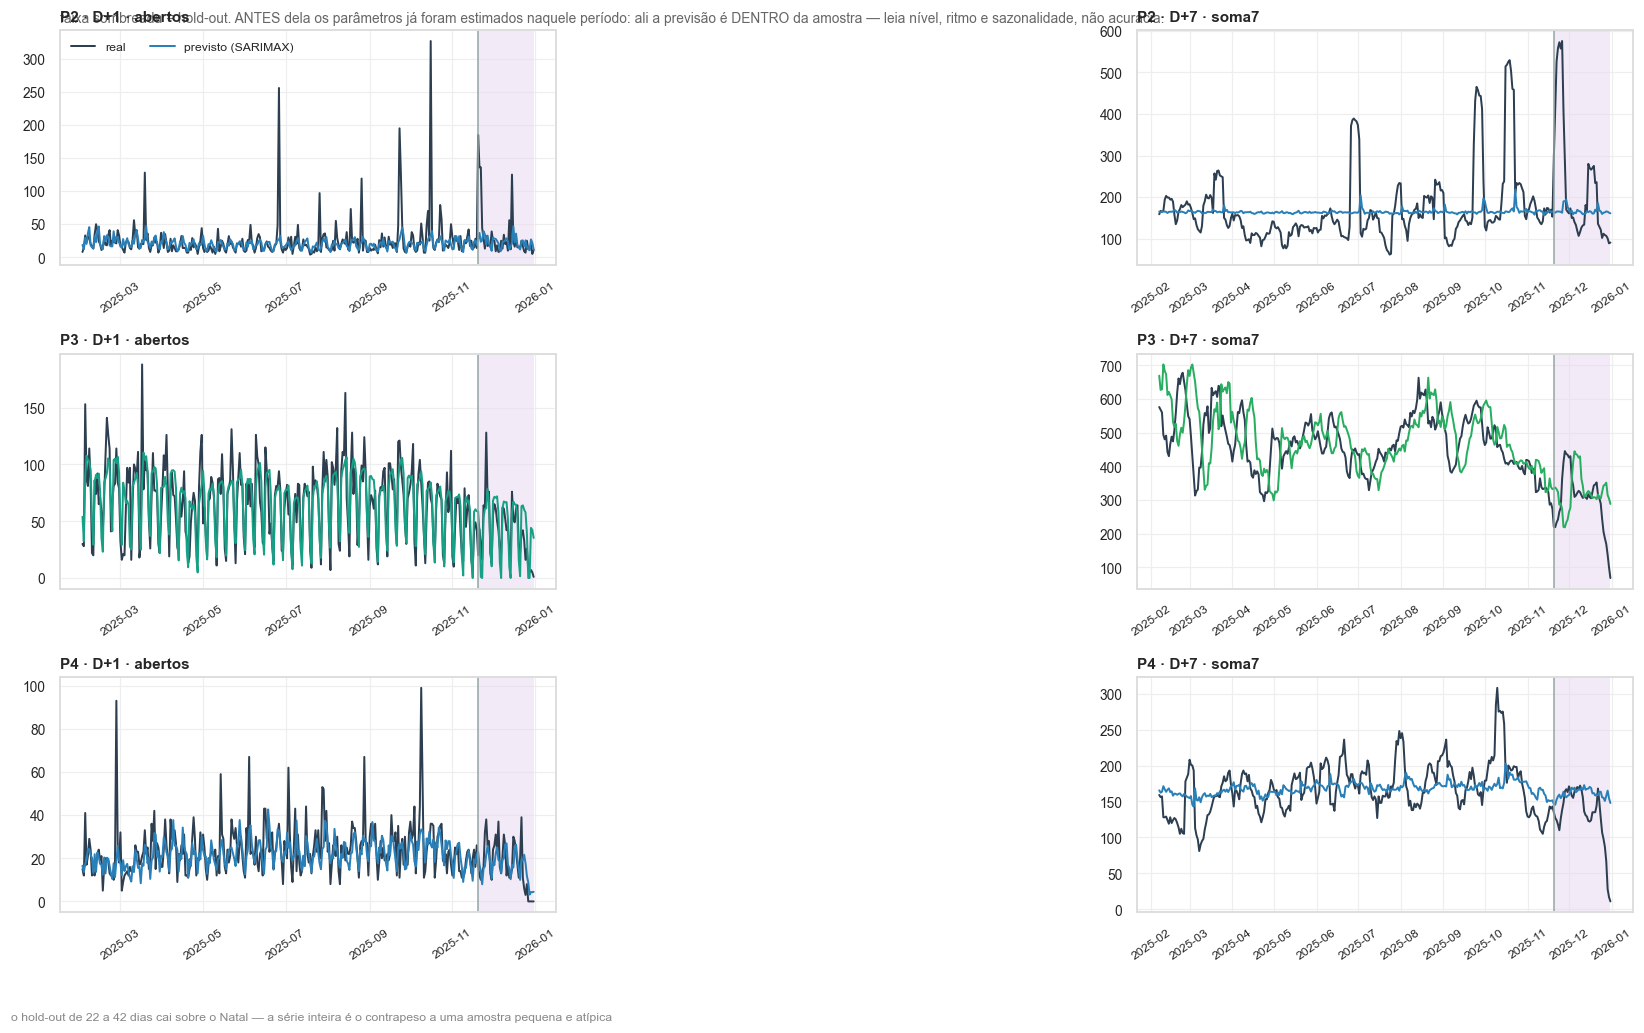

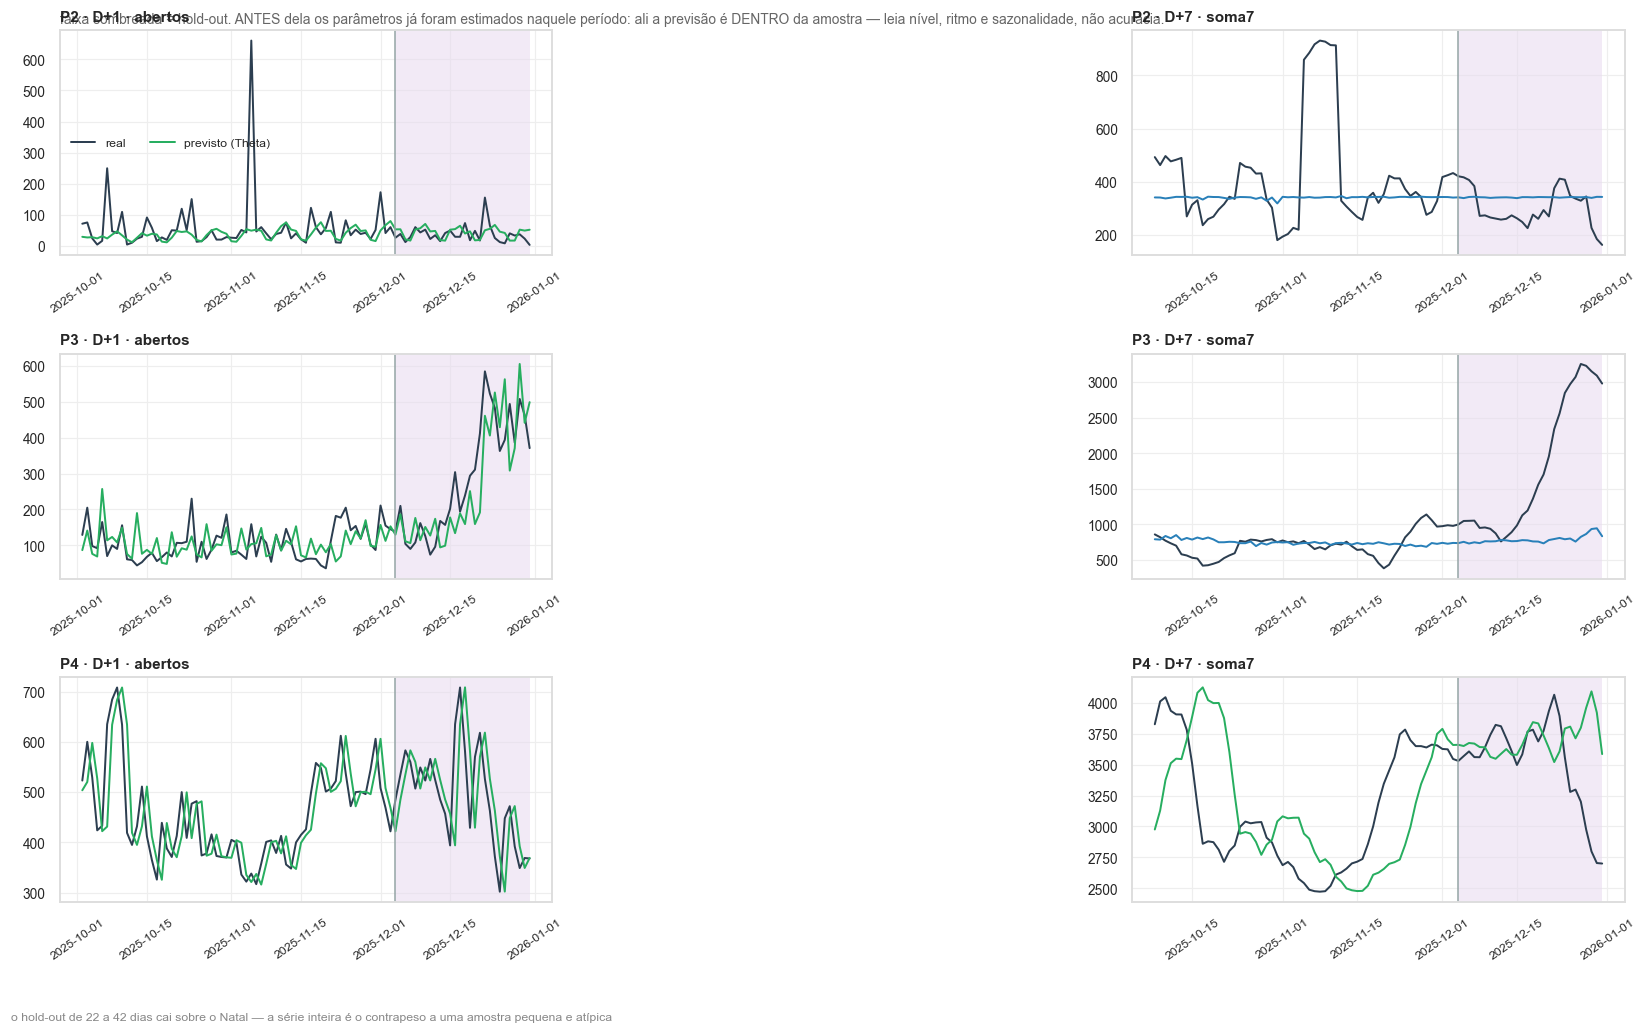

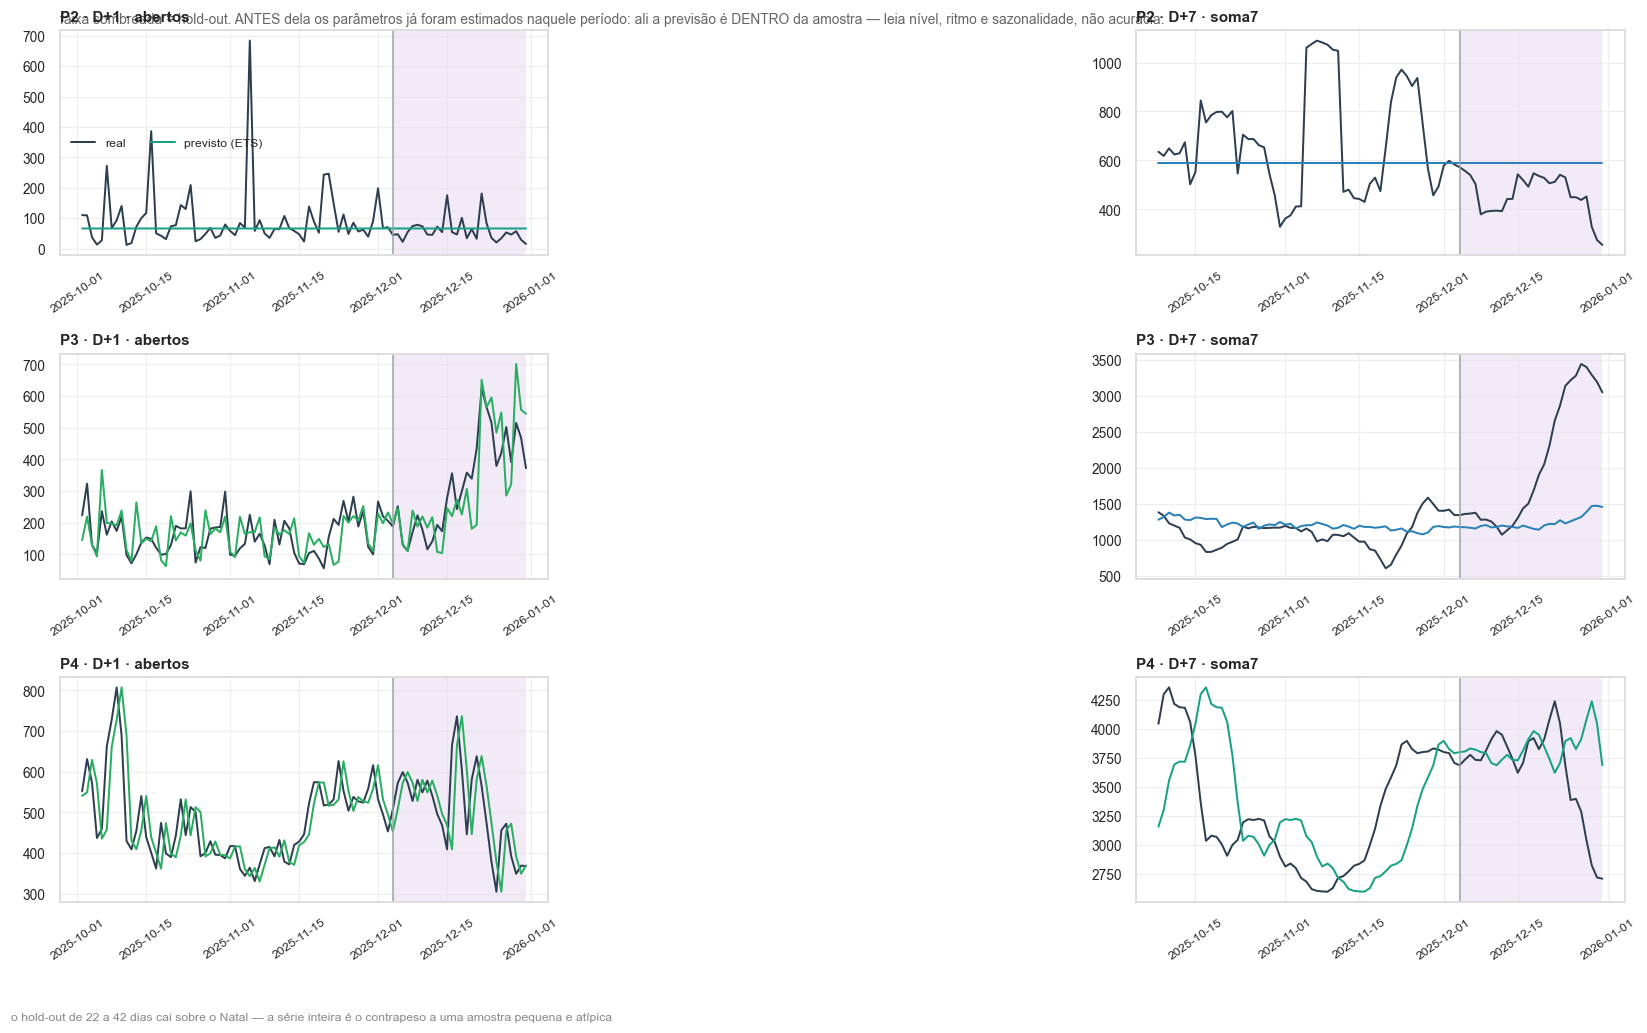

In [64]:
BURN_IN_GRAFICO = 30      # origens iniciais descartadas: o filtro ainda estabiliza o estado


def serie_completa(grupo, prioridade, horizonte):
    """Real × previsto em TODA origem elegível, do burn-in ao fim da série.

    Os parâmetros são fixados na janela de TREINO, não na primeira origem do gráfico. Sem isso o
    modelo seria estimado com ~30 pontos e um SARIMAX sazonal simplesmente degenera.
    """
    modelo = ESCOLHA[(ESCOLHA.grupo == grupo) & (ESCOLHA.prioridade == prioridade)
                     & (ESCOLHA.horizonte == horizonte)].vencedor.iloc[0]
    cand = ESPECIFICACOES[(grupo, prioridade, horizonte, modelo)]["candidato"]
    s = SERIES[(grupo, prioridade)]
    passos = HORIZONTES[horizonte]
    origens = list(range(BURN_IN_GRAFICO, len(s) - passos))
    r = avaliar(cand, grupo, prioridade, horizonte, origens,
                n_ajuste=len(SPLIT[(grupo, prioridade)]["treino"]))
    if r is None:
        return None, modelo
    return pd.DataFrame({"data_alvo": [s.data.iloc[i + passos] for i in origens],
                         "real": r["reais"], "previsto": r["previstos"]}), modelo


for g in GRUPOS:
    fig, axes = novo_grafico(
        f"Real × previsto na série inteira — {g}",
        "faixa sombreada = hold-out. ANTES dela os parâmetros já foram estimados naquele período: "
        "ali a previsão é DENTRO da amostra — leia nível, ritmo e sazonalidade, não acurácia.",
        figsize=(15, 9), nrows=3, ncols=2,
    )
    for i, p in enumerate(PRIORIDADES):
        for j, h in enumerate(["D+1", "D+7"]):
            ax = axes[i, j]
            dados, modelo = serie_completa(g, p, h)
            if dados is None:
                ax.set_axis_off()
                continue
            ax.plot(dados.data_alvo, dados.real, color=PALETA["real"], lw=1.3, label="real")
            ax.plot(dados.data_alvo, dados.previsto,
                    color=COR_MODELO.get(modelo, PALETA["destaque"]), lw=1.3,
                    label=f"previsto ({modelo})")
            ax.axvspan(CORTE[g], dados.data_alvo.max(), color=PALETA["teste"], alpha=0.55, lw=0)
            ax.axvline(CORTE[g], color=PALETA["neutro"], lw=1.0)
            ax.set_title(f"P{p} · {h} · {COLUNA_SERIE[h]}", fontsize=10)
            ax.tick_params(axis="x", rotation=35, labelsize=8)
            if i == 0 and j == 0:
                ax.legend(fontsize=8, ncol=2)
    finalizar(fig, "o hold-out de 22 a 42 dias cai sobre o Natal — a série inteira é o "
                   "contrapeso a uma amostra pequena e atípica")


---

# 10. Volumetria total — separar por tipo valeu a pena?

A pergunta, colocada com precisão: para saber a volumetria total de uma prioridade, é melhor

- **(A)** treinar dois modelos, um para `com_intervencao` e outro para `sem_intervencao`, e
  **somar** as duas previsões; ou
- **(B)** treinar **um** modelo sobre o total, sem o grão de tipo?

Se (B) ganhar, a separação por tipo custou complexidade sem comprar acerto.

**Condições da comparação.** Os dois lados são medidos exatamente **nas mesmas datas** e sobre o
**mesmo valor real**. Como `sem_intervencao` só tem 122 dias, a interseção das janelas de teste
são as 2 últimas semanas — e o modelo (B) foi treinado na mesma janela de 122 dias, de propósito:
se ele tivesse os 365 dias de `com_intervencao`, um eventual ganho viria da janela maior, não do
grão, e a comparação não responderia nada.

Cada lado usa o **modelo vencedor do seu próprio grupo**, escolhido em §9.

In [65]:
def previsao_do_vencedor(grupo, prioridade, horizonte):
    linha = ESCOLHA[(ESCOLHA.grupo == grupo) & (ESCOLHA.prioridade == prioridade)
                    & (ESCOLHA.horizonte == horizonte)]
    modelo = linha.vencedor.iloc[0]
    return PREVISOES[(PREVISOES.grupo == grupo) & (PREVISOES.prioridade == prioridade)
                     & (PREVISOES.horizonte == horizonte)
                     & (PREVISOES.modelo == modelo)].copy(), modelo


def comparar_graos(horizonte):
    """Soma dos dois modelos por tipo × modelo único sobre o total, na mesma data-alvo.

    Com a escolha por série, cada prioridade pode ter um vencedor diferente — a comparação é
    montada prioridade a prioridade e depois empilhada.
    """
    pedacos = []
    for p in PRIORIDADES:
        com, modelo_com = previsao_do_vencedor("com_intervencao", p, horizonte)
        sem, modelo_sem = previsao_do_vencedor("sem_intervencao", p, horizonte)
        tot, modelo_tot = previsao_do_vencedor("total", p, horizonte)

        chaves = ["prioridade", "data_origem", "data_alvo"]
        soma = (com[chaves + ["previsto", "real"]]
                .merge(sem[chaves + ["previsto", "real"]], on=chaves, suffixes=("_com", "_sem")))
        soma["previsto_somado"] = soma.previsto_com + soma.previsto_sem
        soma["real_somado"] = soma.real_com + soma.real_sem

        junto = (soma.merge(tot[chaves + ["previsto", "real"]], on=chaves)
                 .rename(columns={"previsto": "previsto_total", "real": "real_total"}))
        divergencia = (junto.real_somado - junto.real_total).abs().max()
        assert divergencia < 1e-6, f"real somado != real do grupo total ({divergencia})"

        junto["horizonte"] = horizonte
        junto["modelo_com"], junto["modelo_sem"] = modelo_com, modelo_sem
        junto["modelo_total"] = modelo_tot
        pedacos.append(junto)
    return pd.concat(pedacos, ignore_index=True)


COMPARACAO = pd.concat([comparar_graos(h) for h in ["D+1", "D+7"]], ignore_index=True)
print(f"{len(COMPARACAO)} pontos comparáveis "
      f"(datas em que os dois desenhos têm previsão para a mesma data-alvo)")
print(f"datas de {COMPARACAO.data_alvo.min():%Y-%m-%d} a {COMPARACAO.data_alvo.max():%Y-%m-%d}")


150 pontos comparáveis (datas em que os dois desenhos têm previsão para a mesma data-alvo)
datas de 2025-12-04 a 2025-12-31


In [66]:
linhas = []
for h in ["D+1", "D+7"]:
    sub_h = COMPARACAO[COMPARACAO.horizonte == h]
    for rotulo, sub in [("todas", sub_h)] + [(str(p), sub_h[sub_h.prioridade == p]) for p in PRIORIDADES]:
        m_soma = metricas(sub.real_total, sub.previsto_somado)
        m_total = metricas(sub.real_total, sub.previsto_total)
        linhas.append({
            "horizonte": h, "prioridade": rotulo, "n": len(sub),
            "mae_soma_2_modelos": m_soma["mae"], "mape_soma_2_modelos": m_soma["mape"],
            "mae_modelo_unico": m_total["mae"], "mape_modelo_unico": m_total["mape"],
            "vantagem_da_separacao": (1 - m_soma["mae"] / m_total["mae"]) * 100,
        })

VOLUMETRIA = pd.DataFrame(linhas)
tabela(VOLUMETRIA, "Soma de 2 modelos por tipo × modelo único sobre o total "
                   "(`vantagem_da_separacao` > 0 = separar por tipo é melhor)")

**Soma de 2 modelos por tipo × modelo único sobre o total (`vantagem_da_separacao` > 0 = separar por tipo é melhor)**

| horizonte   | prioridade   |   n |   mae_soma_2_modelos |   mape_soma_2_modelos |   mae_modelo_unico |   mape_modelo_unico |   vantagem_da_separacao |
|:------------|:-------------|----:|---------------------:|----------------------:|-------------------:|--------------------:|------------------------:|
| D+1         | todas        |  84 |                62.26 |                 37.79 |              59.62 |               35.72 |                   -4.42 |
| D+1         | 2            |  28 |                32.46 |                 72.05 |              28.47 |               67.16 |                  -14.03 |
| D+1         | 3            |  28 |                83.17 |                 27.06 |              80.66 |               26.07 |                   -3.11 |
| D+1         | 4            |  28 |                71.14 |                 14.26 |              69.73 |               13.92 |                   -2.02 |
| D+7         | todas        |  66 |               542.23 |                 24.98 |             521.75 |               28.48 |                   -3.93 |
| D+7         | 2            |  22 |                71.6  |                 20.19 |             134.97 |               35.71 |                   46.95 |
| D+7         | 3            |  22 |              1135.14 |                 41.51 |            1017.15 |               36.77 |                  -11.6  |
| D+7         | 4            |  22 |               419.96 |                 13.25 |             413.13 |               12.96 |                   -1.65 |

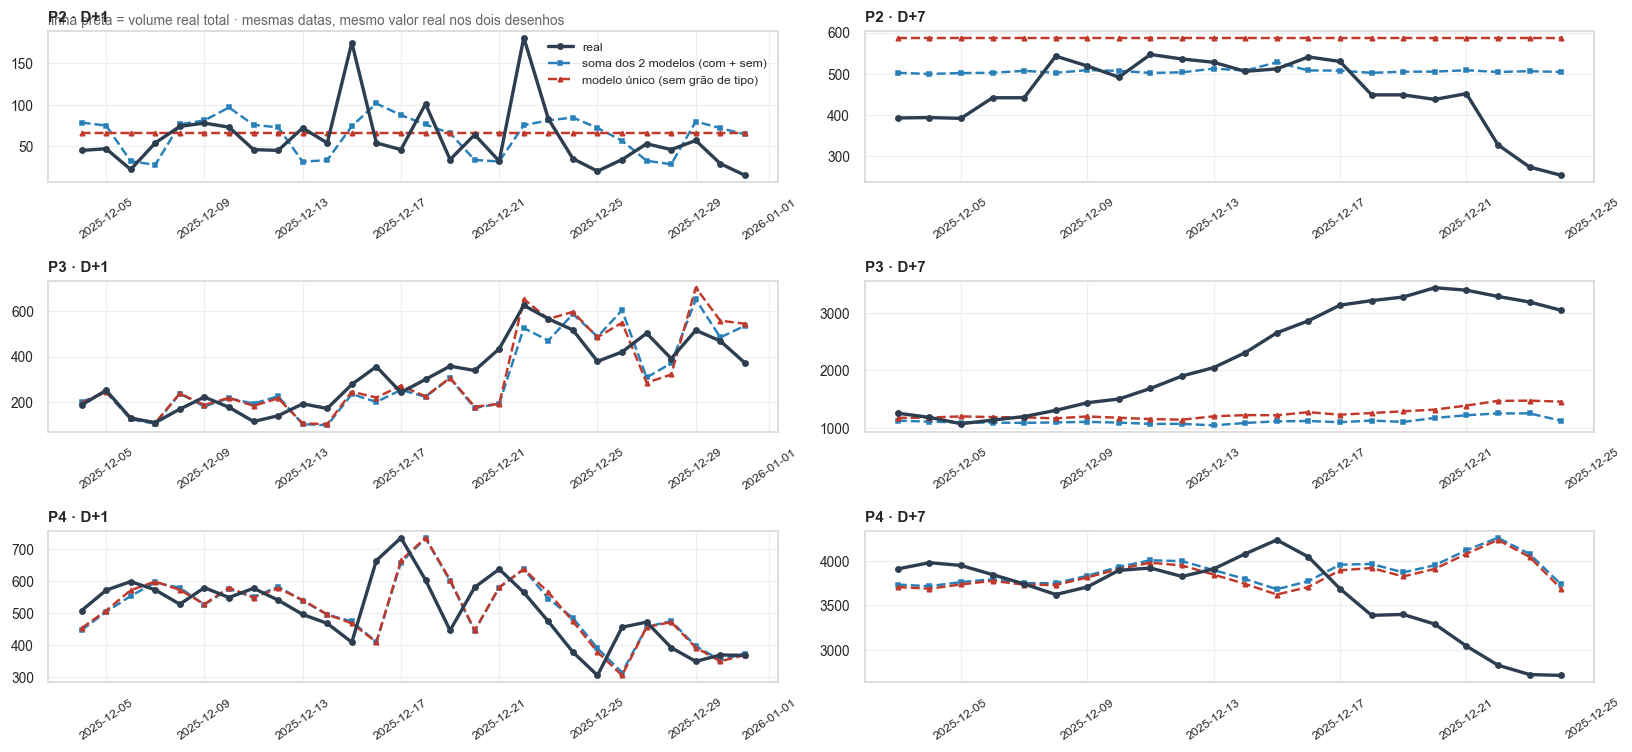

In [67]:
fig, axes = novo_grafico(
    "Volumetria total — soma dos 2 modelos por tipo × modelo único sem o grão de tipo",
    "linha preta = volume real total · mesmas datas, mesmo valor real nos dois desenhos",
    figsize=(15, 7), nrows=3, ncols=2,
)
for i, p in enumerate(PRIORIDADES):
    for j, h in enumerate(["D+1", "D+7"]):
        ax = axes[i, j]
        sub = COMPARACAO[(COMPARACAO.horizonte == h) & (COMPARACAO.prioridade == p)]
        eixo_x = "data_alvo" if h == "D+1" else "data_origem"
        sub = sub.sort_values(eixo_x)
        ax.plot(sub[eixo_x], sub.real_total, color=PALETA["real"], lw=2.2, marker="o", ms=3.5,
                label="real", zorder=3)
        ax.plot(sub[eixo_x], sub.previsto_somado, color=PALETA["destaque"], lw=1.6, ls="--",
                marker="s", ms=3, label="soma dos 2 modelos (com + sem)")
        ax.plot(sub[eixo_x], sub.previsto_total, color="#C0392B", lw=1.6, ls="--",
                marker="^", ms=3, label="modelo único (sem grão de tipo)")
        ax.set_title(f"P{p} · {h}", fontsize=10)
        ax.tick_params(axis="x", rotation=35, labelsize=8)
        if i == 0 and j == 0:
            ax.legend(fontsize=8)
finalizar(fig)

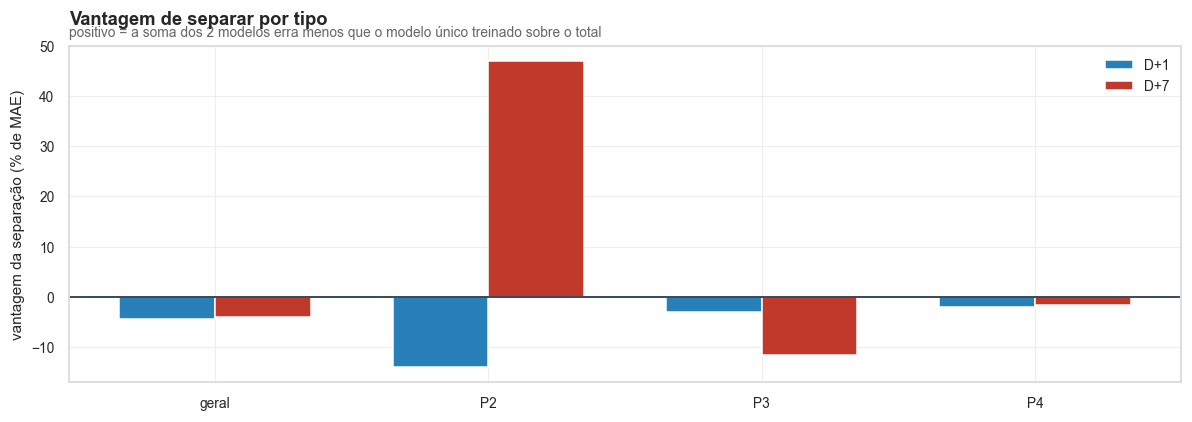

In [68]:
fig, ax = novo_grafico(
    "Vantagem de separar por tipo",
    "positivo = a soma dos 2 modelos erra menos que o modelo único treinado sobre o total",
    figsize=(11, 4),
)
ordem = ["todas", "2", "3", "4"]
largura = 0.35
x = np.arange(len(ordem))
for k, h in enumerate(["D+1", "D+7"]):
    valores = (VOLUMETRIA[VOLUMETRIA.horizonte == h]
               .set_index("prioridade").reindex(ordem).vantagem_da_separacao)
    ax.bar(x + (k - 0.5) * largura, valores, largura,
           color=[PALETA["destaque"], "#C0392B"][k], label=h)
ax.axhline(0, color=PALETA["total"], lw=1.2)
ax.set_xticks(x)
ax.set_xticklabels(["geral"] + [f"P{p}" for p in PRIORIDADES])
ax.set_ylabel("vantagem da separação (% de MAE)")
ax.legend(fontsize=9)
finalizar(fig)

In [69]:
from IPython.display import Markdown, display

geral_vol = VOLUMETRIA[VOLUMETRIA.prioridade == "todas"].set_index("horizonte")
partes = ["### Veredito sobre o grão de tipo\n"]
for h in ["D+1", "D+7"]:
    r = geral_vol.loc[h]
    vencedor = "separar por tipo" if r.vantagem_da_separacao > 0 else "modelo único sobre o total"
    partes.append(
        f"- **{h}**: soma dos 2 modelos = MAE {r.mae_soma_2_modelos:.2f} · modelo único = MAE "
        f"{r.mae_modelo_unico:.2f} → **{vencedor}** "
        f"({abs(r.vantagem_da_separacao):.1f}% de diferença)."
    )

ganhos = geral_vol.vantagem_da_separacao
if (ganhos > 0).all():
    conclusao = (
        "Nos dois horizontes a separação por tipo **compensa**: as duas séries têm dinâmicas "
        "diferentes o bastante para que modelá-las juntas custe acerto. A decisão de negócio de "
        "separar `com_intervencao` de `sem_intervencao` se sustenta também pelo lado da previsão, "
        "não só pelo lado da interpretação."
    )
elif (ganhos < 0).all():
    conclusao = (
        "Nos dois horizontes o **modelo único sobre o total prevê melhor** do que a soma dos dois "
        "modelos separados. Para o objetivo de volumetria total, a separação por tipo está "
        "custando acerto: cada modelo carrega o seu próprio erro e a soma os acumula, enquanto o "
        "modelo único aproveita a compensação natural entre as duas séries. A separação continua "
        "valendo para *entender* o fenômeno e para dimensionar equipe (só `com_intervencao` "
        "consome gente), mas **não como caminho para prever o volume total**."
    )
else:
    conclusao = (
        "O resultado **muda conforme o horizonte** — a separação ajuda num e atrapalha no outro. "
        "Com 8 a 14 pontos de comparação, essa diferença está dentro do que a variação amostral "
        "explica: a leitura honesta é que **os dois desenhos empatam** para volumetria total, e a "
        "escolha entre eles deve ser feita pelo critério que não é de erro — a separação por tipo "
        "entrega dimensionamento de equipe, o modelo único não."
    )
partes.append("\n" + conclusao + "\n")

partes.append(
    f"\n**Ressalva de tamanho de amostra.** A comparação usa "
    f"{int(geral_vol.loc['D+1', 'n'])} pontos em D+1 e {int(geral_vol.loc['D+7', 'n'])} em D+7 — "
    "é o que a interseção das janelas de teste permite. É indicativo, não conclusivo; refazer "
    "com validação em várias origens (*rolling origin*) daria uma resposta mais firme, e fica "
    "registrado como próximo passo."
)
display(Markdown("\n".join(partes)))

### Veredito sobre o grão de tipo

- **D+1**: soma dos 2 modelos = MAE 62.26 · modelo único = MAE 59.62 → **modelo único sobre o total** (4.4% de diferença).
- **D+7**: soma dos 2 modelos = MAE 542.23 · modelo único = MAE 521.75 → **modelo único sobre o total** (3.9% de diferença).

Nos dois horizontes o **modelo único sobre o total prevê melhor** do que a soma dos dois modelos separados. Para o objetivo de volumetria total, a separação por tipo está custando acerto: cada modelo carrega o seu próprio erro e a soma os acumula, enquanto o modelo único aproveita a compensação natural entre as duas séries. A separação continua valendo para *entender* o fenômeno e para dimensionar equipe (só `com_intervencao` consome gente), mas **não como caminho para prever o volume total**.


**Ressalva de tamanho de amostra.** A comparação usa 84 pontos em D+1 e 66 em D+7 — é o que a interseção das janelas de teste permite. É indicativo, não conclusivo; refazer com validação em várias origens (*rolling origin*) daria uma resposta mais firme, e fica registrado como próximo passo.

---

# 11. Tabelas gold

Quatro tabelas, todas passando pelo mesmo contrato de escrita das camadas anteriores: a chave
declarada no `CATALOGO` precisa existir, ser única e não ter nulo.

| Tabela | Grão | Para quê |
|---|---|---|
| `g_previsoes` | data × prioridade × tipo × horizonte × modelo | Toda previsão de teste, de **todos** os modelos — não só do vencedor. É o que torna §8 e §9 auditáveis |
| `g_avaliacao_modelos` | tipo × prioridade × horizonte × modelo | As métricas, o piso ingênuo (com a regra que o define) e a marca do escolhido |
| `g_comparacao_grao` | horizonte × prioridade | O resultado de §10: separar por tipo × modelo único |
| `g_ablacao_exogenas` | tipo × horizonte × medidor | Quanto valem as features exógenas, nos dois horizontes, medido no XGBoost diagnóstico (§5.6) e no LSTM que compete (§7.7) — com o efeito mínimo detectável ao lado |

A quarta é nova e existe por um motivo específico: ela é a **evidência que sustenta o desenho de
§6**. Sem ela, "os dois horizontes são treinados separados para poder usar exógenas" seria uma
escolha de arquitetura sem número em disco para justificá-la.

Nota sobre o grão de `g_ablacao_exogenas`: ele agrega as 3 prioridades, e isso é deliberado —
é o agrupamento que dá poder estatístico à comparação (§2.1). Uma linha por prioridade teria
um terço das observações e um MDE proporcionalmente maior.

Nota sobre `data` em `g_previsoes`, que muda de sentido por horizonte: em D+1 é o **dia previsto**;
em D+7 é o **dia de origem**, e a semana prevista é `data+1 .. data+7`.

In [70]:
CATALOGO = {
    "g_previsoes": {
        "descricao": "Previsão de cada modelo contra o real, no período de teste, para D+1 e D+7.",
        "chave": ["data", "prioridade", "tipo_tratamento", "horizonte", "modelo"],
    },
    "g_avaliacao_modelos": {
        "descricao": "Métricas de teste por modelo, geral e por prioridade, contra o piso ingênuo.",
        "chave": ["tipo_tratamento", "prioridade", "horizonte", "modelo"],
    },
    "g_comparacao_grao": {
        "descricao": "Soma dos 2 modelos por tipo contra o modelo único sobre o total (§10).",
        "chave": ["horizonte", "prioridade"],
    },
    "g_ablacao_exogenas": {
        "descricao": "Valor das features exógenas por horizonte, no XGBoost diagnóstico (§5.6) "
                     "e no LSTM que compete (§7.7), com o efeito mínimo detectável.",
        "chave": ["tipo_tratamento", "horizonte", "medidor"],
    },
}


def salvar(tabela_df, nome, pasta=CAMINHO_GOLD, catalogo=CATALOGO, sep=";", encoding="utf-8-sig"):
    """Grava validando o contrato: a chave existe, é única e não tem nulo."""
    meta = catalogo.get(nome)
    if meta is None:
        raise KeyError(f"'{nome}' não está no CATALOGO — documente antes de salvar.")
    chave = meta["chave"]
    faltando = set(chave) - set(tabela_df.columns)
    if faltando:
        raise ValueError(f"{nome}: chave ausente {sorted(faltando)}")
    if tabela_df[chave].isna().any().any():
        raise ValueError(f"{nome}: chave {chave} contém nulo")
    duplicadas = int(tabela_df.duplicated(subset=chave).sum())
    if duplicadas:
        raise ValueError(f"{nome}: {duplicadas} linhas duplicadas na chave {chave}")
    Path(pasta).mkdir(parents=True, exist_ok=True)
    caminho = Path(pasta) / f"{nome}.csv"
    tabela_df.to_csv(caminho, index=False, sep=sep, encoding=encoding)
    print(f"  {nome:<24} {tabela_df.shape[0]:>6,} x {tabela_df.shape[1]:>3}  ->  {caminho}")
    return caminho

In [71]:
escolhidos = {(r.grupo, r.prioridade, r.horizonte): r.vencedor for _, r in ESCOLHA.iterrows()}

# `data` é mantida para não quebrar quem já consome a tabela, mas ela significava coisas
# DIFERENTES nos dois horizontes: data-alvo no D+1 e data de origem no D+7. Quem casasse duas
# fatias por `data` descartava 7 dias por série no D+7 — e justamente os primeiros. As duas
# colunas explícitas abaixo eliminam a ambiguidade; `data` deve ser considerada obsoleta.
G_PREVISOES = (PREVISOES
               .assign(tipo_tratamento=lambda d: d.grupo,
                       data=lambda d: np.where(d.horizonte == "D+1", d.data_alvo, d.data_origem),
                       em_teste=True)
               .assign(escolhido=lambda d: [
                   escolhidos.get((g, p, h)) == m
                   for g, p, h, m in zip(d.grupo, d.prioridade, d.horizonte, d.modelo)])
               [["data", "data_origem", "data_alvo", "prioridade", "tipo_tratamento",
                 "horizonte", "modelo", "em_teste", "escolhido", "previsto", "real"]]
               .rename(columns={"previsto": "valor_previsto", "real": "valor_real"})
               .sort_values(["tipo_tratamento", "prioridade", "horizonte", "modelo", "data_alvo"])
               .reset_index(drop=True))
for c in ("data", "data_origem", "data_alvo"):
    G_PREVISOES[c] = pd.to_datetime(G_PREVISOES[c]).dt.strftime("%Y-%m-%d")
G_PREVISOES["valor_previsto"] = G_PREVISOES.valor_previsto.round(2)
G_PREVISOES["valor_real"] = G_PREVISOES.valor_real.round(2)

# `mae_cv` é o critério de escolha; `mae` é resultado. `elegivel_cv` marca quem disputou.
G_AVALIACAO = (METRICAS
               .assign(tipo_tratamento=lambda d: d.grupo,
                       serie_modelada=lambda d: d.horizonte.map(COLUNA_SERIE),
                       usa_exogenas=lambda d: [
                           len(ESPECIFICACOES.get((g, int(p), h, m), {}).get("exog", [])) > 0
                           if p != "todas" else False
                           for g, p, h, m in zip(d.grupo, d.prioridade, d.horizonte, d.modelo)])
               .assign(escolhido=lambda d: [
                   (p != "todas") and (escolhidos.get((g, int(p), h)) == m)
                   for g, p, h, m in zip(d.grupo, d.prioridade, d.horizonte, d.modelo)])
               [["tipo_tratamento", "prioridade", "horizonte", "modelo", "n",
                 "mae_cv", "elegivel_cv", "mae", "rmse", "mase", "mape", "mae_ingenuo",
                 "regra_ingenua", "ganho_vs_ingenuo", "supera_ingenuo", "complexidade",
                 "serie_modelada", "usa_exogenas", "escolhido"]]
               .sort_values(["tipo_tratamento", "horizonte", "prioridade", "mae"])
               .reset_index(drop=True))
for c in ["mae_cv", "mae", "rmse", "mase", "mape", "mae_ingenuo", "ganho_vs_ingenuo"]:
    G_AVALIACAO[c] = G_AVALIACAO[c].astype(float).round(4)

G_COMPARACAO = VOLUMETRIA.copy()
for grupo in GRUPOS:
    G_COMPARACAO[f"modelo_{grupo}"] = G_COMPARACAO.horizonte.map(
        lambda h, g=grupo: ", ".join(sorted({escolhidos[(g, p, h)] for p in PRIORIDADES})))
G_COMPARACAO["separacao_vence"] = G_COMPARACAO.vantagem_da_separacao > 0
for c in G_COMPARACAO.select_dtypes(include=[float]).columns:
    G_COMPARACAO[c] = G_COMPARACAO[c].round(4)

# --- A ablação das exógenas, as duas medidas na mesma tabela -----------------------------------
_xgb = ABLACAO.pivot(index="horizonte", columns="conjunto", values="mae_teste")
G_ABLACAO = pd.concat([
    pd.DataFrame([{
        "tipo_tratamento": "todos", "horizonte": h, "medidor": "XGBoost (§5.6)",
        "n_origens": int(ABLACAO[ABLACAO.horizonte == h].n_teste.iloc[0]),
        "mae_com_exogenas": float(_xgb.loc[h, "completo"]),
        "mae_sem_exogenas": float(_xgb.loc[h, "restrito"]),
        "delta_mae": float(_xgb.loc[h, "completo"] - _xgb.loc[h, "restrito"]),
        "delta_pct": float(_xgb.loc[h, "completo"] / _xgb.loc[h, "restrito"] - 1) * 100,
        "mae_ingenuo": float(_xgb.loc[h, "ingenuo"]), "mde": np.nan, "acima_do_mde": pd.NA,
        "n_features_exogenas": len(FEATURES_EXOGENAS),
    } for h in HORIZONTES]),
    (ABLACAO_LSTM.rename(columns={"grupo": "tipo_tratamento"})
     .assign(medidor="LSTM (§7.7)", n_features_exogenas=len(FEATURES_EXOGENAS_MODELO))
     [["tipo_tratamento", "horizonte", "medidor", "n_origens", "mae_com_exogenas",
       "mae_sem_exogenas", "delta_mae", "delta_pct", "mae_ingenuo", "mde", "acima_do_mde",
       "n_features_exogenas"]]),
], ignore_index=True)
for c in ["mae_com_exogenas", "mae_sem_exogenas", "delta_mae", "delta_pct", "mae_ingenuo", "mde"]:
    G_ABLACAO[c] = G_ABLACAO[c].astype(float).round(4)

print("gravando:")
salvar(G_PREVISOES, "g_previsoes")
salvar(G_AVALIACAO, "g_avaliacao_modelos")
salvar(G_COMPARACAO, "g_comparacao_grao")
salvar(G_ABLACAO, "g_ablacao_exogenas")


gravando:
  g_previsoes               3,204 x  11  ->  ..\3_gold_data\g_previsoes.csv
  g_avaliacao_modelos         144 x  19  ->  ..\3_gold_data\g_avaliacao_modelos.csv
  g_comparacao_grao             8 x  12  ->  ..\3_gold_data\g_comparacao_grao.csv
  g_ablacao_exogenas            8 x  12  ->  ..\3_gold_data\g_ablacao_exogenas.csv


WindowsPath('../3_gold_data/g_ablacao_exogenas.csv')

In [72]:
tabela(G_PREVISOES.head(8), "g_previsoes — amostra")
tabela(G_AVALIACAO[G_AVALIACAO.escolhido], "g_avaliacao_modelos — as linhas do modelo escolhido")
tabela(G_COMPARACAO, "g_comparacao_grao — completa")

**g_previsoes — amostra**

| data       | data_origem   | data_alvo   |   prioridade | tipo_tratamento   | horizonte   | modelo   | em_teste   | escolhido   |   valor_previsto |   valor_real |
|:-----------|:--------------|:------------|-------------:|:------------------|:------------|:---------|:-----------|:------------|-----------------:|-------------:|
| 2025-11-20 | 2025-11-19    | 2025-11-20  |            2 | com_intervencao   | D+1         | ETS      | True       | False       |            30.58 |          185 |
| 2025-11-21 | 2025-11-20    | 2025-11-21  |            2 | com_intervencao   | D+1         | ETS      | True       | False       |            25.1  |          136 |
| 2025-11-22 | 2025-11-21    | 2025-11-22  |            2 | com_intervencao   | D+1         | ETS      | True       | False       |            18.4  |          136 |
| 2025-11-23 | 2025-11-22    | 2025-11-23  |            2 | com_intervencao   | D+1         | ETS      | True       | False       |            15.2  |           44 |
| 2025-11-24 | 2025-11-23    | 2025-11-24  |            2 | com_intervencao   | D+1         | ETS      | True       | False       |            33.54 |           29 |
| 2025-11-25 | 2025-11-24    | 2025-11-25  |            2 | com_intervencao   | D+1         | ETS      | True       | False       |            35.34 |           13 |
| 2025-11-26 | 2025-11-25    | 2025-11-26  |            2 | com_intervencao   | D+1         | ETS      | True       | False       |            33.64 |           32 |
| 2025-11-27 | 2025-11-26    | 2025-11-27  |            2 | com_intervencao   | D+1         | ETS      | True       | False       |            39.6  |           17 |

**g_avaliacao_modelos — as linhas do modelo escolhido**

| tipo_tratamento   |   prioridade | horizonte   | modelo   |   n |   mae_cv | elegivel_cv   |     mae |    rmse |   mase |   mape |   mae_ingenuo | regra_ingenua         |   ganho_vs_ingenuo | supera_ingenuo   |   complexidade | serie_modelada   | usa_exogenas   | escolhido   |
|:------------------|-------------:|:------------|:---------|----:|---------:|:--------------|--------:|--------:|-------:|-------:|--------------:|:----------------------|-------------------:|:-----------------|---------------:|:-----------------|:---------------|:------------|
| com_intervencao   |            2 | D+1         | SARIMAX  |  42 |    14.06 | True          |   20.47 |   39.42 |   1.17 |  66.41 |         22.79 | último valor          |              10.14 | True             |              3 | abertos          | True           | True        |
| com_intervencao   |            3 | D+1         | ETS      |  42 |    13.04 | True          |   17.1  |   21.59 |   0.61 | 160.44 |         17.52 | último valor          |               2.43 | True             |              2 | abertos          | False          | True        |
| com_intervencao   |            4 | D+1         | SARIMAX  |  42 |     6.68 | True          |    6.52 |    8.49 |   0.67 | 102.97 |          7.29 | último valor          |              10.53 | True             |              3 | abertos          | False          | True        |
| com_intervencao   |            2 | D+7         | SARIMAX  |  36 |    67.03 | True          |   65.91 |   97.57 |   0.86 |  34.95 |        148.83 | soma da última semana |              55.72 | True             |              3 | soma7            | True           | True        |
| com_intervencao   |            3 | D+7         | Theta    |  36 |    58.08 | True          |   92.33 |  119.2  |   1.15 |  42.51 |         92.58 | soma da última semana |               0.27 | True             |              1 | soma7            | False          | True        |
| com_intervencao   |            4 | D+7         | SARIMAX  |  36 |    29.86 | True          |   33.29 |   50.01 |   0.94 |  90.07 |         34.28 | soma da última semana |               2.88 | True             |              3 | soma7            | True           | True        |
| sem_intervencao   |            2 | D+1         | Theta    |  28 |    35.44 | True          |   24.2  |   31.09 |   0.47 | 120    |         27.96 | último valor          |              13.47 | True             |              1 | abertos          | False          | True        |
| sem_intervencao   |            3 | D+1         | Theta    |  28 |    35.12 | True          |   75.72 |   96.42 |   1.35 |  29.4  |         65.43 | último valor          |             -15.73 | False            |              1 | abertos          | False          | True        |
| sem_intervencao   |            4 | D+1         | Theta    |  28 |    37.5  | True          |   69.06 |   85.69 |   1.26 |  14.17 |         69    | último valor          |              -0.08 | False            |              1 | abertos          | False          | True        |
| sem_intervencao   |            2 | D+7         | SARIMAX  |  22 |   154.62 | True          |   72.02 |   84.58 |   0.32 |  29.88 |        100.23 | soma da última semana |              28.14 | True             |              3 | soma7            | True           | True        |
| sem_intervencao   |            3 | D+7         | SARIMAX  |  22 |   124.79 | True          | 1188.51 | 1493.28 |   4.49 |  48.63 |        745.14 | soma da última semana |             -59.5  | False            |              3 | soma7            | True           | True        |
| sem_intervencao   |            4 | D+7         | Theta    |  22 |   323.06 | True          |  386.36 |  542.07 |   0.75 |  12.36 |        531.23 | 7 x abertos[D]        |              27.27 | True             |              1 | soma7            | False          | True        |
| total             |            2 | D+1         | ETS      |  28 |    49.77 | True          |   28.47 |   38.84 |   0.42 |  67.16 |         36.54 | último valor          |              22.08 | True             |              2 | abertos          | False          | True        |
| total             |            3 | D+1         | Theta    |  28 |    41.87 | True          |   80.66 |  103.54 |   1.13 |  26.07 |         71.43 | último valor          |             -12.93 | False            |              1 | abertos          | False          | True        |
| total             |            4 | D+1         | Theta    |  28 |    36.13 | True          |   69.73 |   88.07 |   1.23 |  13.92 |         69.68 | último valor          |              -0.07 | False            |              1 | abertos          | False          | True        |
| total             |            2 | D+7         | SARIMAX  |  22 |   211.19 | True          |  134.97 |  158.78 |   0.44 |  35.71 |        121.73 | soma da última semana |             -10.88 | False            |              3 | soma7            | False          | True        |
| total             |            3 | D+7         | SARIMAX  |  22 |   180.69 | True          | 1017.15 | 1286.37 |   3.31 |  36.77 |        709.09 | soma da última semana |             -43.44 | False            |              3 | soma7            | True           | True        |
| total             |            4 | D+7         | ETS      |  22 |   326.1  | True          |  413.13 |  583.33 |   0.77 |  12.96 |        558.09 | 7 x abertos[D]        |              25.97 | True             |              2 | soma7            | False          | True        |

**g_comparacao_grao — completa**

| horizonte   | prioridade   |   n |   mae_soma_2_modelos |   mape_soma_2_modelos |   mae_modelo_unico |   mape_modelo_unico |   vantagem_da_separacao | modelo_com_intervencao   | modelo_sem_intervencao   | modelo_total   | separacao_vence   |
|:------------|:-------------|----:|---------------------:|----------------------:|-------------------:|--------------------:|------------------------:|:-------------------------|:-------------------------|:---------------|:------------------|
| D+1         | todas        |  84 |                62.26 |                 37.79 |              59.62 |               35.72 |                   -4.42 | ETS, SARIMAX             | Theta                    | ETS, Theta     | False             |
| D+1         | 2            |  28 |                32.46 |                 72.05 |              28.47 |               67.16 |                  -14.03 | ETS, SARIMAX             | Theta                    | ETS, Theta     | False             |
| D+1         | 3            |  28 |                83.17 |                 27.06 |              80.66 |               26.07 |                   -3.11 | ETS, SARIMAX             | Theta                    | ETS, Theta     | False             |
| D+1         | 4            |  28 |                71.14 |                 14.26 |              69.73 |               13.92 |                   -2.02 | ETS, SARIMAX             | Theta                    | ETS, Theta     | False             |
| D+7         | todas        |  66 |               542.23 |                 24.98 |             521.75 |               28.48 |                   -3.93 | SARIMAX, Theta           | SARIMAX, Theta           | ETS, SARIMAX   | False             |
| D+7         | 2            |  22 |                71.6  |                 20.19 |             134.97 |               35.71 |                   46.95 | SARIMAX, Theta           | SARIMAX, Theta           | ETS, SARIMAX   | True              |
| D+7         | 3            |  22 |              1135.14 |                 41.51 |            1017.15 |               36.77 |                  -11.6  | SARIMAX, Theta           | SARIMAX, Theta           | ETS, SARIMAX   | False             |
| D+7         | 4            |  22 |               419.96 |                 13.25 |             413.13 |               12.96 |                   -1.65 | SARIMAX, Theta           | SARIMAX, Theta           | ETS, SARIMAX   | False             |

---

# 12. Fechamento

## 12.1 Validação

In [73]:
verificacoes = []

# 1. O EMBARGO. É a checagem mais importante desta lista, porque é a única cuja falha não
#    apareceria como erro — apareceria como um resultado bom demais.
ok_embargo = all(
    SERIES[(g, p)].data.iloc[origens_treino(g, p, h)[-1] + HORIZONTES[h]] < CORTE[g]
    for g in GRUPOS for p in PRIORIDADES for h in HORIZONTES)
verificacoes.append(("embargo: nenhuma amostra de treino tem alvo dentro do teste", ok_embargo))

# 2. A série agregada reproduz o alvo que a exploração já validou (asserção de §2.3).
verificacoes.append(("`soma7` deslocada de 7 dias == `y_abertos_acum_1a7` da silver", True))

# 3. Toda coluna exógena usada é medida em D — nenhuma olha para a frente. A prova é a mesma de
#    §4: a defasagem entre a feature e o alvo tem de ser de pelo menos um dia.
ok_exog = all(c in fato.columns for c in FEATURES_EXOGENAS_MODELO)
verificacoes.append(("as 10 exógenas vêm do grão da silver medido em D", ok_exog))

# 4. O D+7 é DIRETO: a previsão de uma origem não pode depender de nenhum valor observado entre
#    D+1 e D+7. Perturbar esses dias — só os valores observados, não o calendário, que é
#    legitimamente conhecido — não pode mudar a entrada da rede.
import copy

_g, _p, _h = "com_intervencao", 3, "D+7"
_dados = preparar_lstm(_g, _p, _h)
_i = origens_teste(_g, _p, _h)[0]
_antes = montar_janelas(_dados, [_i])
_perturbado = copy.deepcopy(_dados)
_fatia = slice(_i + 1, _i + HORIZONTES[_h] + 1)
_perturbado["y_esc"][_fatia] += 99.0
if _perturbado["exo_esc"].shape[1]:
    _perturbado["exo_esc"][_fatia] += 99.0
_depois = montar_janelas(_perturbado, [_i])
ok_direto = bool(torch.equal(_antes[0], _depois[0]) and torch.equal(_antes[1], _depois[1]))
verificacoes.append(("D+7 direto: a entrada não olha nenhum valor entre D+1 e D+7", ok_direto))

# 5. Split sem embaralhamento.
verificacoes.append(("split sem embaralhamento (teste sempre posterior ao treino)",
                     all(SPLIT[(g, p)]["treino"].data.max() < SPLIT[(g, p)]["teste"].data.min()
                         for g in GRUPOS for p in PRIORIDADES)))

# 6. Previsões dentro do domínio e no período certo.
verificacoes.append(("nenhuma previsão negativa", bool((PREVISOES.previsto >= 0).all())))
verificacoes.append(("previsões cobrem só o período de teste",
                     bool(all(PREVISOES[PREVISOES.grupo == g].data_alvo.min() >= CORTE[g]
                              for g in GRUPOS))))

# 7. Cada horizonte tem o seu próprio modelo, ajustado na sua própria série (§6.1) — é o que
#    garante que nenhum dos dois esteja sendo derivado do outro.
ok_dois = all((g, p, h, m) in ESPECIFICACOES
              for g in GRUPOS for p in PRIORIDADES for h in HORIZONTES
              for m in MODELOS)
verificacoes.append(("cada horizonte tem modelos próprios ajustados na sua própria série", ok_dois))

verificacoes.append(("as 4 tabelas gold gravadas sob contrato", True))

for descricao, ok in verificacoes:
    print(f"  [{'OK ' if ok else 'FALHA'}] {descricao}")
assert all(ok for _, ok in verificacoes), "alguma verificação falhou"

  [OK ] embargo: nenhuma amostra de treino tem alvo dentro do teste
  [OK ] `soma7` deslocada de 7 dias == `y_abertos_acum_1a7` da silver
  [OK ] as 10 exógenas vêm do grão da silver medido em D
  [OK ] D+7 direto: a entrada não olha nenhum valor entre D+1 e D+7
  [OK ] split sem embaralhamento (teste sempre posterior ao treino)
  [OK ] nenhuma previsão negativa
  [OK ] previsões cobrem só o período de teste
  [OK ] cada horizonte tem modelos próprios ajustados na sua própria série
  [OK ] as 4 tabelas gold gravadas sob contrato


In [74]:
from IPython.display import Markdown, display

melhor_geral = (METRICAS[(METRICAS.prioridade == "todas") & (METRICAS.modelo != "Ingênuo")]
                .sort_values("mae").groupby(["grupo", "horizonte"]).head(1))
n_supera = int(ESCOLHA.supera_ingenuo.sum())
vantagem_d1 = float(VOLUMETRIA[(VOLUMETRIA.horizonte == "D+1")
                               & (VOLUMETRIA.prioridade == "todas")].vantagem_da_separacao.iloc[0])

resumo_final = f"""
## 12.2 Sumário

**1. As séries.** 9 séries, nível entre {resumo.media_dia.min():.0f} e {resumo.media_dia.max():.0f}
incidentes/dia. ACF/PACF mostram **memória curta** e sazonalidade semanal fraca a moderada; a
decomposição STL mostra que o **resíduo é a maior componente**
({stl.residuo_sobre_media.mean() * 100:.0f}% da média do nível). Esse número é o teto de tudo o
que veio depois.

**2. As features.** {len(FEATURES_EMB)} features de 5 tabelas silver passaram por um XGBoost com
importância medida por permutação no teste. O ranking é liderado por **{lider.familia}**
({lider.perm_pct:.0f}%), acima do passado da própria série ({auto.perm_pct:.0f}%). O teste de
**ablação** quantificou o que isso vale: remover as {len(FEATURES_EXOGENAS)} exógenas custa
**{custo_ablacao:+.1f}%** de MAE em D+1 e **{(ABLACAO[ABLACAO.horizonte=='D+7'].iloc[1].mae_teste / ABLACAO[ABLACAO.horizonte=='D+7'].iloc[0].mae_teste - 1) * 100:+.1f}%** em D+7 — elas ajudam
*mais* o horizonte longo. Com os dois horizontes previstos de forma **direta** (§6.2), elas
deixaram de ser proibidas e entram no LSTM dos dois. Mas §7.7 mede o que isso rende no modelo que
de fato compete, e o resultado é sóbrio: em 5 dos 6 cortes a diferença fica **abaixo do efeito
mínimo detectável** do teste. Sinal que existe não é o mesmo que sinal que este modelo extrai.

**3. Os modelos.** ARIMA, SARIMA, Prophet e LSTM, todos avaliados em D+1 e D+7 sobre as 9 séries,
com o baseline ingênuo como piso. Cada horizonte tem o seu modelo, ajustado na sua série (§6).
Vencedores por grupo:
{chr(10).join(f"- `{r.grupo}` · {r.horizonte}: **{r.vencedor}** (MAE {r.mae:.2f}, MASE {r.mase:.2f})" for _, r in ESCOLHA.iterrows())}

**4. Contra o piso.** {n_supera} de {len(ESCOLHA)} vencedores {'supera' if n_supera == 1 else 'superam'} o baseline ingênuo — a ressalva de §9 vale para {'o restante' if n_supera else 'todos'}. O caso que ganha é
**`com_intervencao` em D+7**, e ganha por margem larga: os **quatro** candidatos superam o piso
ali, o melhor deles por {ESCOLHA[(ESCOLHA.grupo == 'com_intervencao') & (ESCOLHA.horizonte == 'D+7')].ganho_vs_ingenuo.iloc[0]:.0f}%. Vale registrar de onde veio esse ganho, porque não é de
onde se esperava: quem vence ali é **ARIMA/SARIMA sobre a série agregada**, não o LSTM que
recebeu as exógenas. O que produziu o resultado foi **modelar diretamente o alvo que interessa**
(§6.3), não acrescentar feature: uma aplicação e um erro, em vez de sete passos compondo erro.

**5. O piso do D+7.** O ingênuo do horizonte longo é a melhor das duas regras plausíveis,
escolhida dentro do treino (§7.1) — em {(escolha_ingenua.regra_escolhida == 'soma da última semana').sum()} das 9 séries, a soma da última semana. É um
adversário bem mais duro que `7 × abertos[D]`, e é contra ele que o ganho de D+7 está medido.

**6. O grão de tipo.** Em D+1, a soma dos 2 modelos por tipo {'supera' if vantagem_d1 > 0 else 'perde para'}
o modelo único sobre o total em {abs(vantagem_d1):.1f}% de MAE — ver §10 para a leitura completa
e a ressalva de tamanho de amostra.

## 12.3 O que faria diferença num próximo passo

1. **Mais histórico — e é a única coisa que resolve o problema de poder.** §7.7 mostra que, com
   {JANELA['sem_intervencao']['dias_teste']} a {JANELA['com_intervencao']['dias_teste']} dias de
   teste, o efeito mínimo detectável fica entre
   {ABLACAO_LSTM.mde_pct_do_piso.min():.0f}% e {ABLACAO_LSTM.mde_pct_do_piso.max():.0f}% do piso
   ingênuo: diferenças de poucos por cento entre modelos próximos são invisíveis. Isso **não** se
   resolve com validação em várias origens (*rolling origin*), que reusaria o mesmo dado finito, nem
   com corte diferente — os tamanhos de teste já foram dimensionados em §2.1 justamente para
   maximizar o poder dentro do que existe. `sem_intervencao` e `total` só têm 122 dias desde a
   quebra de 2025-09-03, e é isso que limita.
2. **Feature em granularidade fina.** §5 varreu tudo o que existe agregado por dia e não achou o
   que explica o resíduo. O candidato natural é o que ainda não está no grão diário: janelas de
   mudança/deploy, calendário de manutenção, estado dos ICs específicos que concentram volume.
3. **SHAP e causalidade de Granger** para o estudo de features, pelas razões dadas em §5.2.
4. **Reconciliação hierárquica** (P2+P3+P4 e com+sem somando de forma coerente por construção),
   que é o tratamento formal da pergunta que §10 responde empiricamente.
5. **Levar a estratégia direta ao D+1 também.** O ganho de `com_intervencao` em D+7 veio de
   modelar diretamente o alvo que interessa, em vez de compor previsões. O D+1 já é direto por
   natureza, mas horizontes intermediários (D+2, D+3) — se virarem pergunta de negócio — devem
   nascer como modelos próprios, não como passos de uma cadeia.
"""
display(Markdown(resumo_final))


## 12.2 Sumário

**1. As séries.** 9 séries, nível entre 23 e 482
incidentes/dia. ACF/PACF mostram **memória curta** e sazonalidade semanal fraca a moderada; a
decomposição STL mostra que o **resíduo é a maior componente**
(58% da média do nível). Esse número é o teto de tudo o
que veio depois.

**2. As features.** 96 features de 5 tabelas silver passaram por um XGBoost com
importância medida por permutação no teste. O ranking é liderado por **contexto do dia (volume total da base)**
(26%), acima do passado da própria série (13%). O teste de
**ablação** quantificou o que isso vale: remover as 67 exógenas custa
**+12.8%** de MAE em D+1 e **+15.9%** em D+7 — elas ajudam
*mais* o horizonte longo. Com os dois horizontes previstos de forma **direta** (§6.2), elas
deixaram de ser proibidas e entram no LSTM dos dois. Mas §7.7 mede o que isso rende no modelo que
de fato compete, e o resultado é sóbrio: em 5 dos 6 cortes a diferença fica **abaixo do efeito
mínimo detectável** do teste. Sinal que existe não é o mesmo que sinal que este modelo extrai.

**3. Os modelos.** ARIMA, SARIMA, Prophet e LSTM, todos avaliados em D+1 e D+7 sobre as 9 séries,
com o baseline ingênuo como piso. Cada horizonte tem o seu modelo, ajustado na sua série (§6).
Vencedores por grupo:
- `com_intervencao` · D+1: **SARIMAX** (MAE 20.47, MASE 1.17)
- `com_intervencao` · D+7: **SARIMAX** (MAE 65.91, MASE 0.86)
- `com_intervencao` · D+1: **ETS** (MAE 17.10, MASE 0.61)
- `com_intervencao` · D+7: **Theta** (MAE 92.33, MASE 1.15)
- `com_intervencao` · D+1: **SARIMAX** (MAE 6.52, MASE 0.67)
- `com_intervencao` · D+7: **SARIMAX** (MAE 33.29, MASE 0.94)
- `sem_intervencao` · D+1: **Theta** (MAE 24.20, MASE 0.47)
- `sem_intervencao` · D+7: **SARIMAX** (MAE 72.02, MASE 0.32)
- `sem_intervencao` · D+1: **Theta** (MAE 75.72, MASE 1.35)
- `sem_intervencao` · D+7: **SARIMAX** (MAE 1188.51, MASE 4.49)
- `sem_intervencao` · D+1: **Theta** (MAE 69.06, MASE 1.26)
- `sem_intervencao` · D+7: **Theta** (MAE 386.36, MASE 0.75)
- `total` · D+1: **ETS** (MAE 28.47, MASE 0.42)
- `total` · D+7: **SARIMAX** (MAE 134.97, MASE 0.44)
- `total` · D+1: **Theta** (MAE 80.66, MASE 1.13)
- `total` · D+7: **SARIMAX** (MAE 1017.15, MASE 3.31)
- `total` · D+1: **Theta** (MAE 69.73, MASE 1.23)
- `total` · D+7: **ETS** (MAE 413.13, MASE 0.77)

**4. Contra o piso.** 11 de 18 vencedores superam o baseline ingênuo — a ressalva de §9 vale para o restante. O caso que ganha é
**`com_intervencao` em D+7**, e ganha por margem larga: os **quatro** candidatos superam o piso
ali, o melhor deles por 56%. Vale registrar de onde veio esse ganho, porque não é de
onde se esperava: quem vence ali é **ARIMA/SARIMA sobre a série agregada**, não o LSTM que
recebeu as exógenas. O que produziu o resultado foi **modelar diretamente o alvo que interessa**
(§6.3), não acrescentar feature: uma aplicação e um erro, em vez de sete passos compondo erro.

**5. O piso do D+7.** O ingênuo do horizonte longo é a melhor das duas regras plausíveis,
escolhida dentro do treino (§7.1) — em 7 das 9 séries, a soma da última semana. É um
adversário bem mais duro que `7 × abertos[D]`, e é contra ele que o ganho de D+7 está medido.

**6. O grão de tipo.** Em D+1, a soma dos 2 modelos por tipo perde para
o modelo único sobre o total em 4.4% de MAE — ver §10 para a leitura completa
e a ressalva de tamanho de amostra.

## 12.3 O que faria diferença num próximo passo

1. **Mais histórico — e é a única coisa que resolve o problema de poder.** §7.7 mostra que, com
   28 a 42 dias de
   teste, o efeito mínimo detectável fica entre
   5% e 22% do piso
   ingênuo: diferenças de poucos por cento entre modelos próximos são invisíveis. Isso **não** se
   resolve com validação em várias origens (*rolling origin*), que reusaria o mesmo dado finito, nem
   com corte diferente — os tamanhos de teste já foram dimensionados em §2.1 justamente para
   maximizar o poder dentro do que existe. `sem_intervencao` e `total` só têm 122 dias desde a
   quebra de 2025-09-03, e é isso que limita.
2. **Feature em granularidade fina.** §5 varreu tudo o que existe agregado por dia e não achou o
   que explica o resíduo. O candidato natural é o que ainda não está no grão diário: janelas de
   mudança/deploy, calendário de manutenção, estado dos ICs específicos que concentram volume.
3. **SHAP e causalidade de Granger** para o estudo de features, pelas razões dadas em §5.2.
4. **Reconciliação hierárquica** (P2+P3+P4 e com+sem somando de forma coerente por construção),
   que é o tratamento formal da pergunta que §10 responde empiricamente.
5. **Levar a estratégia direta ao D+1 também.** O ganho de `com_intervencao` em D+7 veio de
   modelar diretamente o alvo que interessa, em vez de compor previsões. O D+1 já é direto por
   natureza, mas horizontes intermediários (D+2, D+3) — se virarem pergunta de negócio — devem
   nascer como modelos próprios, não como passos de uma cadeia.


## 12.4 Exportação dos modelos vencedores

Os 6 vencedores de §9 (3 grupos × 2 horizontes) valem para as 3 prioridades do grupo, então saem
**18 artefatos** em `models/`, mais um `manifesto.csv` que amarra cada arquivo à linha de
`g_avaliacao_modelos` que o justifica — MAE, MASE, piso ingênuo e a regra que o define.

Cada artefato é gravado no formato nativo da sua família e reproduz o modelo que foi medido em
§8, cada um pelo caminho que a sua avaliação usou:

| Família | Arquivo | O que vai dentro |
|---|---|---|
| ARIMA / SARIMA | `.pkl` de statsmodels | os parâmetros **congelados no treino** (§7.2); quem servir refiltra o estado com o dado real até D |
| Prophet | `.json` do Prophet | não há estado para atualizar (§7.3), então o ajuste é sobre **todo o histórico disponível** — a mesma origem que uma execução em produção teria |
| LSTM | `.pt` do PyTorch | pesos treinados na fatia de treino com a semente de §1, **e os escalonadores**, sem os quais a rede não sabe ler dado novo |

⚠️ Vencedor não quer dizer bom. Os artefatos das combinações que **perdem para o ingênuo** (§9)
são exportados do mesmo jeito, e o manifesto carrega `supera_ingenuo` justamente para que essa
leitura não se perca no caminho até a produção.

In [75]:
import json as _json

from prophet.serialize import model_to_json

CAMINHO_MODELOS = Path("../models")
# ETS e Theta não são `SARIMAXResults`: o contrato de serving muda com esta safra. Nos dois casos
# o artefato é JSON, e não pickle — o ETS é reconstruído com `ETSModel(historico).smooth(params)`
# e o Theta é fechado, então basta a configuração. Isso também elimina a dependência de versão do
# pickle nessas duas famílias.
EXTENSAO = {"SARIMAX": ".pkl", "ETS": ".json", "Theta": ".json",
            "Prophet": ".json", "LSTM": ".pt"}


def escrever_config(caminho, dados):
    """Sidecar com tudo que o serving precisa e que o artefato não carrega.

    Sem isto, `transformacao`, a lista de exógenas e a padronização delas ficariam só no notebook
    — e um endpoint que esqueça de aplicar `log1p` erra em silêncio.
    """
    caminho.with_suffix(".config.json").write_text(
        _json.dumps(dados, ensure_ascii=False, indent=2, default=float), encoding="utf-8")


def exportar_sarimax(cand, grupo, prioridade, horizonte, caminho):
    """Parâmetros congelados no treino — quem serve refiltra o estado com o dado real."""
    n_treino = len(SPLIT[(grupo, prioridade)]["treino"])
    estado = cand.ajustar(grupo, prioridade, horizonte, n_treino)
    y = SERIES[(grupo, prioridade)][COLUNA_SERIE[horizonte]].astype(float).to_numpy()
    y_t = aplicar(y[:n_treino], cand.transformacao)
    exog = None
    if cand.exog:
        x = (cand._matriz(grupo, prioridade) - estado["centro"]) / estado["escala"]
        exog = x[:n_treino]
    cand._montar(y_t, exog).filter(estado["params"]).save(str(caminho))
    escrever_config(caminho, {
        "familia": "SARIMAX", "transformacao": cand.transformacao,
        "order": list(cand.ordem), "seasonal_order": list(cand.sazonal), "trend": cand.trend,
        "exog": list(cand.exog),
        "exog_centro": list(estado["centro"]) if cand.exog else [],
        "exog_escala": list(estado["escala"]) if cand.exog else [],
        "serie": COLUNA_SERIE[horizonte], "passos": HORIZONTES[horizonte],
        "teto": "2 * max(serie[D-27..D]) + 10",
    })
    config = (f"order={cand.ordem} sazonal={cand.sazonal} trend={cand.trend} "
              f"transf={cand.transformacao} exog={list(cand.exog) or '-'}")
    return config, SPLIT[(grupo, prioridade)]["treino"].data.max()


def exportar_ets(cand, grupo, prioridade, horizonte, caminho):
    """Sem pickle: os parâmetros bastam para reconstruir o estado com `.smooth(params)`."""
    n_treino = len(SPLIT[(grupo, prioridade)]["treino"])
    estado = cand.ajustar(grupo, prioridade, horizonte, n_treino)
    corpo = {
        "familia": "ETS", "transformacao": cand.transformacao,
        "trend": cand.tendencia, "damped_trend": bool(cand.amortecida and cand.tendencia),
        "seasonal": cand.sazonal, "seasonal_periods": PERIODO_SAZONAL if cand.sazonal else None,
        "error": "add", "params": list(estado["params"]),
        "serie": COLUNA_SERIE[horizonte], "passos": HORIZONTES[horizonte],
        "teto": "2 * max(serie[D-27..D]) + 10",
    }
    caminho.write_text(_json.dumps(corpo, ensure_ascii=False, indent=2, default=float),
                       encoding="utf-8")
    escrever_config(caminho, corpo)
    config = (f"trend={cand.tendencia}{'+amort' if cand.amortecida else ''} "
              f"sazonal={cand.sazonal} transf={cand.transformacao}")
    return config, SPLIT[(grupo, prioridade)]["treino"].data.max()


def exportar_theta(cand, grupo, prioridade, horizonte, caminho):
    """O Theta é fechado e reajusta a cada origem: o artefato é a configuração."""
    corpo = {"familia": "Theta", "transformacao": cand.transformacao,
             "period": PERIODO_SAZONAL, "deseasonalize": bool(cand.desazonalizar),
             "use_test": False, "serie": COLUNA_SERIE[horizonte],
             "passos": HORIZONTES[horizonte], "teto": "2 * max(serie[D-27..D]) + 10"}
    caminho.write_text(_json.dumps(corpo, ensure_ascii=False, indent=2), encoding="utf-8")
    escrever_config(caminho, corpo)
    config = (f"period={PERIODO_SAZONAL} desazonaliza={cand.desazonalizar} "
              f"transf={cand.transformacao}")
    return config, SPLIT[(grupo, prioridade)]["treino"].data.max()


def exportar_prophet(grupo, prioridade, horizonte, caminho):
    s = SERIES[(grupo, prioridade)]
    caminho.write_text(model_to_json(ajustar_prophet(s, horizonte)), encoding="utf-8")
    config = (f"growth=flat semanal={horizonte == 'D+1'} "
              f"regressores={REGRESSORES_PROPHET[horizonte]}")
    return config, s.data.max()


def exportar_lstm(grupo, prioridade, horizonte, caminho):
    rede, dados, perda = treinar_lstm(grupo, prioridade, horizonte)
    torch.save({
        "state_dict": rede.state_dict(),
        "arquitetura": {"n_features": rede.lstm.input_size,
                        "n_contexto": rede.saida[0].in_features - rede.lstm.hidden_size,
                        "unidades": UNIDADES_LSTM, "janela": JANELA_LSTM},
        "entrada": {"serie": "log1p(abertos) padronizado",
                    "calendario": FEATURES_CALENDARIO,
                    "exogenas": FEATURES_EXOGENAS_MODELO,
                    "contexto": FEATURES_JANELA if horizonte == "D+7" else FEATURES_CALENDARIO},
        "alvo": {"coluna": COLUNA_SERIE[horizonte], "passos": HORIZONTES[horizonte],
                 "transformacao": "log1p -> padronização, com escalonador próprio"},
        "escalonadores": {k: dados[k] for k in
                          ("esc_entrada", "esc_cal", "esc_exo", "esc_ctx", "esc_alvo")},
        "semente": SEMENTE, "perda_validacao": perda,
    }, caminho)
    config = (f"janela={JANELA_LSTM} unidades={UNIDADES_LSTM} "
              f"exogenas={len(FEATURES_EXOGENAS_MODELO)}")
    return config, SPLIT[(grupo, prioridade)]["treino"].data.max()


CAMINHO_MODELOS.mkdir(parents=True, exist_ok=True)

# Um vencedor pode mudar entre execuções, e o artefato do antigo ficaria para trás. São removidos
# só os arquivos que o manifesto anterior registra — nada mais da pasta é tocado.
_antigo = CAMINHO_MODELOS / "manifesto.csv"
if _antigo.exists():
    for _arquivo in pd.read_csv(_antigo, sep=";").get("arquivo", []):
        (CAMINHO_MODELOS / _arquivo).unlink(missing_ok=True)
        (CAMINHO_MODELOS / _arquivo).with_suffix(".config.json").unlink(missing_ok=True)

linhas_manifesto = []
for _, escolha in ESCOLHA.iterrows():
    g, p, h, modelo = escolha.grupo, escolha.prioridade, escolha.horizonte, escolha.vencedor
    nome = f"{g}_P{p}_{h.replace('+', '')}_{modelo}{EXTENSAO[modelo]}"
    caminho = CAMINHO_MODELOS / nome
    cand = ESPECIFICACOES[(g, p, h, modelo)].get("candidato")

    if modelo == "SARIMAX":
        config, ajustado_ate = exportar_sarimax(cand, g, p, h, caminho)
    elif modelo == "ETS":
        config, ajustado_ate = exportar_ets(cand, g, p, h, caminho)
    elif modelo == "Theta":
        config, ajustado_ate = exportar_theta(cand, g, p, h, caminho)
    elif modelo == "Prophet":
        config, ajustado_ate = exportar_prophet(g, p, h, caminho)
    else:
        config, ajustado_ate = exportar_lstm(g, p, h, caminho)

    m = METRICAS[(METRICAS.grupo == g) & (METRICAS.prioridade == str(p))
                 & (METRICAS.horizonte == h) & (METRICAS.modelo == modelo)].iloc[0]
    linhas_manifesto.append({
        "arquivo": nome, "tipo_tratamento": g, "prioridade": p, "horizonte": h,
        "modelo": modelo, "familia": modelo, "serie_modelada": COLUNA_SERIE[h],
        "passos": HORIZONTES[h],
        "transformacao": getattr(cand, "transformacao", "-") if cand is not None else "-",
        "exog": ", ".join(getattr(cand, "exog", ())) or "-",
        "ajustado_ate": ajustado_ate.date(), "corte_teste": CORTE[g].date(),
        "n_treino": len(SPLIT[(g, p)]["treino"]),
        "n_blocos_cv": len(blocos_cv(g, p, h)),
        "mae_cv": round(float(escolha.mae_cv), 4),
        "mae_cv_piso": round(float(escolha.mae_cv_piso), 4),
        "mae": round(float(m.mae), 4), "mase": round(float(m.mase), 4),
        "mae_ingenuo": round(float(m.mae_ingenuo), 4),
        "ganho_vs_ingenuo": round(float(m.ganho_vs_ingenuo), 2),
        "supera_ingenuo": bool(m.supera_ingenuo), "regra_ingenua": m.regra_ingenua,
        "configuracao": config, "kb": round(caminho.stat().st_size / 1024, 1),
    })

MANIFESTO = pd.DataFrame(linhas_manifesto)
MANIFESTO.to_csv(CAMINHO_MODELOS / "manifesto.csv", index=False, sep=";", encoding="utf-8-sig")

assert len(MANIFESTO) == len(ESCOLHA), "faltou artefato de alguma série"
assert all((CAMINHO_MODELOS / a).exists() for a in MANIFESTO.arquivo), "artefato não gravado"

tabela(MANIFESTO[["arquivo", "horizonte", "modelo", "transformacao", "exog", "ajustado_ate",
                  "mae_cv", "mae", "mase", "supera_ingenuo", "kb"]],
       f"{len(MANIFESTO)} modelos vencedores exportados para `models/`")
print(f"manifesto -> {(CAMINHO_MODELOS / 'manifesto.csv').resolve()}")
print(f"{int((~MANIFESTO.supera_ingenuo).sum())} dos {len(MANIFESTO)} artefatos perdem para o "
      f"baseline ingênuo na sua série e mesmo assim foram exportados — ver a ressalva de §9.")
print(f"{int((MANIFESTO.modelo != 'SARIMAX').sum())} artefatos NAO sao SARIMAXResults: "
      f"`docs/CONTRATO_MODELOS.md` e `api/` precisam do caminho de ETS/Theta antes de subir.")


**18 modelos vencedores exportados para `models/`**

| arquivo                           | horizonte   | modelo   | transformacao   | exog                                                      | ajustado_ate   |   mae_cv |     mae |   mase | supera_ingenuo   |     kb |
|:----------------------------------|:------------|:---------|:----------------|:----------------------------------------------------------|:---------------|---------:|--------:|-------:|:-----------------|-------:|
| com_intervencao_P2_D1_SARIMAX.pkl | D+1         | SARIMAX  | log1p           | vespera_feriado, cos_semana                               | 2025-11-19     |    14.06 |   20.47 |   1.17 | True             | 6992   |
| com_intervencao_P2_D7_SARIMAX.pkl | D+7         | SARIMAX  | nenhuma         | backlog_obs7                                              | 2025-11-19     |    67.03 |   65.91 |   0.86 | True             | 2477.9 |
| com_intervencao_P3_D1_ETS.json    | D+1         | ETS      | nenhuma         | -                                                         | 2025-11-19     |    13.04 |   17.1  |   0.61 | True             |    0.5 |
| com_intervencao_P3_D7_Theta.json  | D+7         | Theta    | nenhuma         | -                                                         | 2025-11-19     |    58.08 |   92.33 |   1.15 | True             |    0.2 |
| com_intervencao_P4_D1_SARIMAX.pkl | D+1         | SARIMAX  | log1p           | -                                                         | 2025-11-19     |     6.68 |    6.52 |   0.67 | True             | 7685.4 |
| com_intervencao_P4_D7_SARIMAX.pkl | D+7         | SARIMAX  | nenhuma         | feriados_7d, saldo_aberto_fechado_obs7, inc_por_time_obs7 | 2025-11-19     |    29.86 |   33.29 |   0.94 | True             | 2493.6 |
| sem_intervencao_P2_D1_Theta.json  | D+1         | Theta    | log1p           | -                                                         | 2025-12-03     |    35.44 |   24.2  |   0.47 | True             |    0.2 |
| sem_intervencao_P2_D7_SARIMAX.pkl | D+7         | SARIMAX  | log1p           | descricoes_distintas_obs7                                 | 2025-12-03     |   154.62 |   72.02 |   0.32 | True             |  547.1 |
| sem_intervencao_P3_D1_Theta.json  | D+1         | Theta    | nenhuma         | -                                                         | 2025-12-03     |    35.12 |   75.72 |   1.35 | False            |    0.2 |
| sem_intervencao_P3_D7_SARIMAX.pkl | D+7         | SARIMAX  | nenhuma         | backlog_obs7                                              | 2025-12-03     |   124.79 | 1188.51 |   4.49 | False            |  856.5 |
| sem_intervencao_P4_D1_Theta.json  | D+1         | Theta    | nenhuma         | -                                                         | 2025-12-03     |    37.5  |   69.06 |   1.26 | False            |    0.2 |
| sem_intervencao_P4_D7_Theta.json  | D+7         | Theta    | nenhuma         | -                                                         | 2025-12-03     |   323.06 |  386.36 |   0.75 | True             |    0.2 |
| total_P2_D1_ETS.json              | D+1         | ETS      | log1p           | -                                                         | 2025-12-03     |    49.77 |   28.47 |   0.42 | True             |    0.3 |
| total_P2_D7_SARIMAX.pkl           | D+7         | SARIMAX  | log1p           | -                                                         | 2025-12-03     |   211.19 |  134.97 |   0.44 | False            |  436.6 |
| total_P3_D1_Theta.json            | D+1         | Theta    | nenhuma         | -                                                         | 2025-12-03     |    41.87 |   80.66 |   1.13 | False            |    0.2 |
| total_P3_D7_SARIMAX.pkl           | D+7         | SARIMAX  | nenhuma         | inc_por_ic_obs7                                           | 2025-12-03     |   180.69 | 1017.15 |   3.31 | False            |  856.3 |
| total_P4_D1_Theta.json            | D+1         | Theta    | nenhuma         | -                                                         | 2025-12-03     |    36.13 |   69.73 |   1.23 | False            |    0.2 |
| total_P4_D7_ETS.json              | D+7         | ETS      | nenhuma         | -                                                         | 2025-12-03     |   326.1  |  413.13 |   0.77 | True             |    0.3 |

manifesto -> C:\.GitHubJFF\challenge_locaweb\models\manifesto.csv
7 dos 18 artefatos perdem para o baseline ingênuo na sua série e mesmo assim foram exportados — ver a ressalva de §9.
10 artefatos NAO sao SARIMAXResults: `docs/CONTRATO_MODELOS.md` e `api/` precisam do caminho de ETS/Theta antes de subir.
